# HI-Large EDA 통합본 — 주제별 정리 (2026-09-30, 손은총)

- **무엇**: 09-07 ~ 09-29 에 한 HI-Large EDA 를 날짜순이 아니라 **주제순**으로 한 파일에 모았다. **Small·Medium 세트 EDA 는 넣지 않았다**(사용자 지시: HI-Large 만). 세 세트 Patterns.txt 를 같이 본 분석은 HI-Large 부분만 남겼다.
- **유효 판정**: `EDA_현황_20260929/EDA_진행현황_데이터형태_손은총_20260929.md` §2 표의 "지금" 열을 따른다. 대체·철회된 항목의 옛 수치는 본문에 쓰지 않는다. 부록 A 에 이유와 대체한 것만 적는다.
- **새 분석은 하지 않는다.** 기본 설정으로 돌리면 세 가지를 한다.
  1. 저장된 결과 파일을 실행 중에 읽어 표와 그림을 만든다.
  2. 패턴 원문(13.8 MB)·계좌 요약(84 MB 중 1열)·계좌 키 두 열만 쓰는 **가벼운 재계산**을 다시 돌려 저장값과 같은지 확인한다.
  3. 저장값끼리 더하고 나눈 파생값(병합판 비율 등)은 **[저장값에서 산술]** 로 표시하고 `out/` 에 CSV 로 남긴다.
- **무거운 원래 계산 코드**(원본을 푼 interim 파트, DuckDB, 하루 캐시)는 셀에 글자 그대로 옮겼지만 **스위치로 꺼 두었다.** 켜면 이 노트북 폴더의 `out/` 에만 쓴다. 기존 결과는 덮지 않는다. 1 GB 넘는 중간 배열 저장은 `SAVE_BIG` 스위치로 한 번 더 막았다.

### 읽는 법

| 표시 | 뜻 |
|---|---|
| **[무거움 · 꺼짐]** | 원래 계산 코드. 설정 셀의 `HEAVY['이름'] = True` 로 켠다. 셀 맨 위 주석에 원본 파일:줄과 바꾼 곳을 적었다 |
| **[가벼움 · 실행]** | 패턴 원문 같은 작은 파일로 다시 계산하고, 저장값과 같은지 `assert` 로 확인한다 |
| **[저장 결과]** | 저장된 결과 파일을 읽어 보여 준다. 셀 출력의 `읽음:` 줄이 출처 경로다 |
| **[저장값에서 산술]** | 저장된 값끼리 더하고 나눈 값. 결과를 `out/` 에 CSV 로 남긴다 |
| 색 | 파랑 = 패턴 세탁 · 주황 = 패턴 밖 세탁 · 회색 = 정상. 분할은 train 파랑 · val 주황 · test 청록. 유형 8종을 서로 구분해야 하는 그림(지속시간 · P1~P3)에서는 유형마다 같은 색을 쓴다. 그룹(정상 · 패턴 · 패턴 밖)과 유형을 한 막대그림에 함께 놓은 그림(4-5 · 5-1)은 유형 막대를 패턴 색 하나로 칠한다(유형 색이 그룹 색과 겹치지 않게) |

### 모집단이 여럿이다 — 수치를 볼 때 분모를 확인할 것

| 이름 | 행 | 무엇 | 주로 쓰는 곳 |
|---|---:|---|---|
| 원본 | 179,702,229 | 공식 원본 `HI-Large_Trans.csv` 전 행(165일) | §1 · §2 |
| DB | 179,702,079 | 태훈님 DuckDB(11열 완전 일치 중복 150 제거) | A0 · fix E1 |
| 주 기간(DB) | 179,661,360 | DB 의 08-01~11-05(97일) | §1 |
| 옛 모집단 | 179,650,681 | 09-17 내 전처리(센트 키 중복 10,829 제거 + 꼬리 절단). 09-17 결과(A·B·G·H·V·P 계열)의 분모 | §3 ~ §6 |
| 현행 85일 | 155,484,162 | 08-08~10-31, 옛 모집단 라벨, 51/17/17 | §7 · §8 |

- 09-17 결과 파일 일부에는 **옛 행 기준 분할(60/20/20)** 열·행이 남아 있다(L0 · T1 · B5b · B6b · B1c · G1 · G2 · V2 · V4). 이 노트북은 그 파일에서 `전체`·`주기간` 행만 쓴다. 현행 분할(51/17/17)의 값은 E1 · R2 · D2(fix) · M1 · M3 에서만 가져온다.
- **라벨 병합**(09-29 결정: 패턴 밖 세탁 → 정상 클래스 8, 9클래스): E1~E3 · M1~M3 는 **병합 전(패턴 밖 제외)** 정의다. 병합판 비율은 §7-2 에서 다시 센다.
- **test 수치**: 모델 지표는 val 만 보인다("팔 비교는 val 만, test 는 최종 하나만 연다"). E2e 의 test 행(09-29 옛 모델 값)은 이 노트북에서 보이지 않는다. 데이터 구성(E1 의 test 비율, M1·M3 의 test 겹침)은 모델 점수가 아니라 데이터 사실이라 그대로 쓴다.

### 목차
§0 요약 · §1 원본 형태·행·기간 · §2 라벨·패턴 8종·시도 · §3 계좌·은행·KYC·허브 · §4 결제·통화·금액·시각 · §5 흐름 구조 · §6 중복 · §7 분할·사전확률·시계 효과 · §8 계좌 재사용 · 부록 A 대체·철회 · 부록 B 안 한 EDA · 부록 C 정정 반영 · 부록 D 실행 기록

## 설정 — 경로 · 스위치 · 글꼴 · 공용 함수
- `RUN_HEAVY` 를 True 로 두면 무거운 셀이 모두 켜진다. 하나만 켜려면 `HEAVY['step1'] = True` 처럼 바꾼다.
- 무거운 셀은 원본 17 GB·DuckDB·캐시를 읽고 메모리를 많이 쓴다(09-17 실측: step1 anon 5.2 GiB, 09 H3 약 9 GiB). **다른 무거운 작업과 같이 돌리지 않는다.** 켤 때 필요한 입력(interim 파트, `/tmp/tree9_work`, `/tmp/gnn36_full`, `/tmp/lgb55`)이 있는지 먼저 확인한다(09-30 기준 `/tmp` 캐시 두 개는 없음).
- `SAVE_BIG = False` 이면 무거운 셀을 켜도 큰 중간 파일(L0 의 `raw_*.npy` 약 1.08 GB, step2 의 `account_stats.parquet` 84 MB)은 쓰지 않는다. 요약 CSV·JSON 만 `out/` 에 쓴다.
- `tree9_lib` 는 import 하지 않는다(import 할 때 `/tmp/tree9_work/code` 를 읽는다). 분할 날짜는 `tree9_lib.py:52-60` 에서 옮겨 적었다.

In [1]:
# ── 설정 ──
import os
for _k in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_k, '1')                      # 복구 연쇄와 같이 돌 때는 스레드 1
import sys, re, gc, json, time, itertools, math
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import Image, display

T0 = time.time()
RUN_HEAVY = False                                        # 무거운 셀 전체 스위치(기본 꺼짐)
HEAVY = {k: RUN_HEAVY for k in (
    'A0',             # §1  fix_20260927/code/fix_11_boundary.py:1-17      DuckDB 날짜별 행 수
    'T1',             # §1  notebooks/14 cell 1~7                          태훈님 값 파일 짝 맞추기(interim·new_new2key)
    'T3',             # §1  notebooks/16 cell 1~3                          엣지 샘플 값 대조(옛 X_tr.npy mmap)
    'T4',             # §1  notebooks/17 cell 1~3                          노드 값 집계 기간(interim 90파트)
    'L0',             # §2  HI-Large_EDA/build_labels.py                   interim 90파트 → 원본 행 라벨
    'V1_raw',         # §2  notebooks/13_V1 cell 16                        raw_*.npy(1.1 GB) 조각 읽기
    'A2',             # §2  fix_11_boundary.py:19-39                       경계에 걸친 시도(edges.parquet)
    'step2',          # §3  HI-Large_EDA/step2_accounts.py                 계좌 단위
    'V7',             # §3  notebooks/13_V7 cell 1~6                       KYC·국가·약한 후보(V7 · V8)
    'step1',          # §4  HI-Large_EDA/step1_scan.py                     결제·통화·금액·시각·은행 흐름
    'H2_H3',          # §4  notebooks/09 cell 1 · 9 · 11                   처음 쓰는 통화 × 같은 분 짝(약 9 GiB)
    'V3',             # §4  notebooks/13_V3 코드 셀 전부                   처음 통화 재집계·환전 시간차
    'step3',          # §5  HI-Large_EDA/step3_time.py                     넘기는 속도·처음 쌍·같은 분·패턴 밖 연결
    'E_same_minute',  # §5  fix_20260927/code/fix_01_E_same_minute.py      DuckDB 같은 분 동시 거래
    'V2',             # §5  notebooks/13_V2 코드 셀 전부                   받은 만큼 재송금 — 정상 기준
    'dedup',          # §6  HI-Large_EDA/reprocess/dedup_audit.py          중복 키 감사
    'E1',             # §7  EDA_현황_20260929/_builders/build_E1.py         현행 분할 사전확률(하루 캐시)
    'E3',             # §7  build_E3.py                                    36피처 시계 효과(/tmp/lgb55)
    'M1_M3',          # §7  review_leakage_20260929/측정_M1_M3.ipynb       시도·계좌 겹침(하루 캐시)
    'D2_batch',       # §7  tgnn36_20260928/_builders/build_nb_D.py        학습 배치 구성(하루 캐시)
    'E_ctx',          # §7  tgnn36_20260928/_builders/build_nb_E.py        문맥 10건 상한(하루 캐시)
    'D5',             # §7  build_nb_D.py H5 셀                            입력값 크기(하루 캐시 첫 train 날)
    'E2_part2',       # §8  build_E2.py 2부                                계좌 기억 기준선(캐시·/tmp/lgb55)
)}
SAVE_BIG = False     # 무거운 셀을 켜도 큰 중간 파일(L0 의 raw_*.npy 약 1.08 GB · step2 의 account_stats.parquet 84 MB)은 쓰지 않는다

# 이 노트북이 쓰는 곳(유일)
NB_DIR = Path('/workspace/Final_preprocess/통합본_20260930/EDA_HI-Large')
OUT = NB_DIR / 'out'                                     # 가벼운 재계산·무거운 셀의 결과
FIG = NB_DIR / '_figs'                                   # 그림 PNG(dpi 110)
OUT.mkdir(parents=True, exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)
OUT_NB = OUT                                             # 무거운 함수 안에서 OUT 을 이 값으로 다시 묶는다

# 읽기만 하는 곳
RAW = Path('/workspace/IBM_AML_dataset'); PAT_TXT = RAW / 'HI-Large_Patterns.txt'
EDA = Path('/workspace/Final_preprocess/HI-Large_EDA'); RES = EDA / 'results'; WORK = EDA / '_work'
FIX = Path('/workspace/Final_preprocess/fix_20260927'); FRES = FIX / 'results'
ERES = Path('/workspace/Final_preprocess/EDA_현황_20260929/results')
TRES = EDA / 'tgnn36_20260928' / 'results'
REV = EDA / 'review_leakage_20260929' / 'results'
M9 = Path('/workspace/feat_final_20260915')
NODES = Path('/workspace/processed_9class/_nb_scratch/interim/HI-Large/nodes.parquet')   # 원본 165일 전체의 계좌 표(eda_common.INTERIM, 25 MB)
sys.path.insert(0, str(EDA))                             # 무거운 셀이 eda_common 을 import 할 때만 쓰인다

# 분할 — tree9_lib.py:52-60 을 옮겨 적음(import 하지 않음)
SPLIT_DAYS = {'train': ('2022-08-08', '2022-09-27'), 'val': ('2022-09-28', '2022-10-14'), 'test': ('2022-10-15', '2022-10-31')}
TEST22_END = '2022-11-05'                                # 09-29 사용자 결정: 최종 평가만 test 를 11-05 까지(51/17/22)
CLASS_NAMES = ['FAN-OUT', 'FAN-IN', 'CYCLE', 'SCATTER-GATHER', 'GATHER-SCATTER', 'BIPARTITE', 'STACK', 'RANDOM']
def days_of(split):
    a, b = SPLIT_DAYS[split]
    return [str(d.date()) for d in pd.date_range(a, b, freq='D')]
SPLITS = ('train', 'val', 'test')
DAYS = [d for s in SPLITS for d in days_of(s)]
SPLIT_OF = {d: s for s in SPLITS for d in days_of(s)}
assert [len(days_of(s)) for s in SPLITS] == [51, 17, 17] and len(DAYS) == 85
MAIN_END = '2022-11-05'                                  # 공식 주 기간의 끝(fix [A])
TAIL_START = int(np.datetime64('2022-11-06', 'D').astype('datetime64[m]').astype(np.int64))   # eda_common.py:36 과 같은 값(에폭 분)
OLD_POP = 179_650_681                                    # 옛 모집단 행(09-17 전처리)

# 글꼴 — EDA_현황_20260929/_builders/common.py:33-39 과 같은 방식(파일만 /workspace/.fonts 의 같은 글꼴, md5 동일)
FONT = Path('/workspace/.fonts/NanumGothic-Regular.ttf')
fm.fontManager.addfont(str(FONT))
plt.rcParams.update({'font.family': fm.FontProperties(fname=str(FONT)).get_name(), 'axes.unicode_minus': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#b8bcc2', 'axes.labelcolor': '#333', 'xtick.color': '#555', 'ytick.color': '#555',
                     'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#e6e8eb', 'grid.linewidth': 0.8, 'lines.linewidth': 2,
                     'font.size': 10})
# 색 — dataviz 기본 팔레트(범주 8칸, 고정 순서). notebooks/12 cell 1 · fix make_figs.py:26-27 과 같은 값
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
INK, INK2, MUTED, GRID, BASE, REF = '#0b0b0b', '#52514e', '#898781', '#e4e3df', '#c3c2b7', '#b0402e'
C_PAT, C_OOP, C_NORM = SERIES[0], SERIES[1], MUTED       # 패턴 / 패턴 밖 / 정상 — 모든 그림에서 고정
C1, C2, C3, C4 = SERIES[:4]                              # fix make_figs.py 의 이름
SC = {'train': '#2a78d6', 'val': '#eb6834', 'test': '#1baf7a'}
SPLIT_KO = {'train': 'train 08-08~09-27', 'val': 'val 09-28~10-14', 'test': 'test 10-15~10-31'}
C_TYPE = dict(zip(CLASS_NAMES, SERIES))                  # 유형 8종 색(엔티티 고정)
CHAIN = ['CYCLE', 'RANDOM', 'STACK', 'SCATTER-GATHER', 'GATHER-SCATTER']   # 연속 홉이 있는 5종(노트북 12 순서)
FMT7 = ['ACH', 'Bitcoin', 'Cash', 'Cheque', 'Credit Card', 'Reinvestment', 'Wire']   # 결제 방식 어휘 순서
C_FMT = dict(zip(FMT7, SERIES))
pd.set_option('display.width', 250); pd.set_option('display.max_columns', 40); pd.set_option('display.max_colwidth', 120)


def anon_gib():
    """컨테이너 cgroup anon 메모리(GiB) — eda_common.py:54-58 과 같은 정의."""
    for l in open('/sys/fs/cgroup/memory.stat'):
        if l.startswith('anon '):
            return int(l.split()[1]) / 2**30
    return float('nan')


def rd(p, **kw):
    """저장 결과 읽기. BOM 을 벗기고, 출처 경로·크기·행 수를 찍는다."""
    p = Path(p)
    df = pd.read_csv(p, encoding='utf-8-sig', **kw)
    print(f'읽음: {p}  ({p.stat().st_size:,} B · {len(df):,}행)')
    return df


def rj(p):
    p = Path(p)
    print(f'읽음: {p}  ({p.stat().st_size:,} B)')
    return json.loads(p.read_text(encoding='utf-8'))


def savefig(fig, name):
    """그림은 노트북에 넣고 PNG 도 _figs/ 에 남긴다(dpi 110)."""
    p = FIG / name
    fig.savefig(p, dpi=110, bbox_inches='tight'); plt.close(fig)
    display(Image(filename=str(p)))


def ink_on(hex_color):
    """막대 안 글자색: 어두운 칸은 흰색, 밝은 칸은 먹색(대비 확보)."""
    r, g, b = (int(hex_color[i:i + 2], 16) / 255 for i in (1, 3, 5))
    return 'white' if 0.2126 * r + 0.7152 * g + 0.0722 * b < 0.5 else INK


num_fmt = plt.FuncFormatter(lambda v, _: f'{v:g}')      # 로그축 눈금을 10^-1 대신 0.1 로(한글 글꼴에 없는 빼기 기호 회피)


def maxdiff(a, b):
    """두 수 배열의 최대 절대 차(둘 다 결측인 칸은 뺌, 한쪽만 결측이면 inf)."""
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if (np.isnan(a) != np.isnan(b)).any():
        return float('inf')
    d = np.abs(a - b)[~np.isnan(a)]
    return float(d.max()) if len(d) else 0.0


def log_h(msg, logfile=None):
    """무거운 셀용 기록 — eda_common.log(:47-51)와 같은 모양, out/run.log 에만 덧붙인다."""
    line = f'[{time.strftime("%H:%M:%S", time.gmtime())}Z +{time.time() - T0:7.1f}s] {msg}'
    print(line, flush=True)
    with open(logfile or (OUT_NB / 'run.log'), 'a', encoding='utf-8') as f:
        f.write(line + '\n')


def save_csv_h(df, name):
    """무거운 셀용 저장 — eda_common.save_csv(:118-121)와 같고 out/ 에 쓴다."""
    p = OUT_NB / name
    df.to_csv(p, index=False)
    return p


def label_bars(ax, bars, fmt='{:.1f}', dx=0.0, dy=0.0, horiz=False, size=8.4):
    """막대 끝에 값 — notebooks/12 cell 1 에서 옮김."""
    for b in bars:
        v = b.get_width() if horiz else b.get_height()
        if horiz:
            ax.text(v + dx, b.get_y() + b.get_height() / 2, fmt.format(v), va='center', fontsize=size, color=INK2)
        else:
            ax.text(b.get_x() + b.get_width() / 2, v + dy, fmt.format(v), ha='center', va='bottom', fontsize=size, color=INK2)


def title(ax, t, sub=None):
    ax.set_title(t, loc='left', fontsize=11.5, color=INK, pad=22 if sub else 8)
    if sub:
        ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=9, color=INK2, va='bottom')


print(f'anon {anon_gib():.2f} GiB · 무거운 셀 켜짐: {[k for k, v in HEAVY.items() if v] or "없음"} · out = {OUT}')

anon 4.63 GiB · 무거운 셀 켜짐: 없음 · out = /workspace/Final_preprocess/통합본_20260930/EDA_HI-Large/out


## §0 요약 — 지금도 유효한 핵심 사실 13개

EDA 현황 §3 의 13개 사실을 뼈대로 삼았다. **값은 아래 셀이 결과 파일에서 실행 중에 읽어 채운다.** 각 행의 분모와 출처 파일을 함께 적었다. 근거와 그림은 괄호 안의 절에 있다.
- 1행의 EDA 현황 문구("꼬리 = 패턴 완결 거래만")는 파일과 대조해 고쳐 적었다(부록 C-2 #7).
- 11행의 "워밍업"은 **이력 피처가 비는 첫날**이라는 뜻이다. 08-01 의 세탁 비율이 낮은 것은 그날 거래가 많아서이므로 워밍업의 근거로 쓰지 않는다(§1-2).

In [2]:
# §0 — 핵심 사실 표. 결과 파일만 읽고, 읽은 값끼리 더하고 나누기만 한다(새 계산 없음).
hdr = open(RAW / 'HI-Large_Trans.csv', encoding='utf-8').readline().rstrip('\n').split(',')
A0 = rd(FRES / 'A0_일별_행수_세탁_165일.csv'); A0['day'] = pd.to_datetime(A0['day'])
mn, tl = A0[A0.day <= MAIN_END], A0[A0.day > MAIN_END]
L0 = rj(RES / 'L0_labels.json'); L0s = rd(RES / 'L0_labels_summary.csv').set_index('group')
V1s = rd(RES / 'V1_사건지속시간_요약.csv'); V1t = rd(RES / 'V1_사건지속시간_유형별.csv')
B6 = rd(RES / 'B6_처음만나는상대_일주별.csv')
A1 = rd(RES / 'A1_결제수단별_세탁비율.csv'); A2b = rd(RES / 'A2b_환전거래_세탁.csv')
B6b = rd(RES / 'B6b_처음만나는상대_그룹구간별.csv')
V3r = rd(RES / 'V3_처음통화_재집계.csv'); H3 = rd(RES / 'H3_처음통화_짝의_정체.csv')
H1 = rd(RES / 'H1_후보_종합표.csv').set_index('후보')
PS = rd('/workspace/model_blocks/pattern_structure_by_set.csv').query("세트 == 'HI-Large'").set_index('클래스')
A3 = rd(RES / 'A3_허브_대조표.csv'); FE1 = rd(FRES / 'E1_같은분_동시거래_비율.csv')
B1b = rd(RES / 'B1b_시각별_분포.csv'); E1d = rd(ERES / 'E1d_주별_패턴비율.csv')
T4 = rd(RES / 'T4_노드값_집계기간_판정.csv'); M1 = rd(REV / 'M1_시도겹침.csv'); M3 = rd(REV / 'M3_계좌겹침.csv')

v1 = V1s[(V1s.기준 == '꼬리 포함(기본)') & (V1s.구분 == '건수')].set_index('항목')
n_att = int(v1.loc['전체 시도 수', '값'])
dur = V1t[(V1t.기준 == '꼬리 포함(기본)') & (V1t.지표 == '지속시간') & (V1t.분모정의 == '(가) 전체 시도')].set_index('유형')
pm = A1[A1.범위 == '주기간(전처리 대상)'].set_index('결제수단')
xr = A2b[(A2b.범위 == '주기간(전처리 대상)') & (A2b['통화 관계'] == '환전(송금≠수취)')].iloc[0]
b6 = B6b[B6b.구간 == '전체'].set_index('그룹')
v3 = V3r.set_index('그룹'); h3 = H3.set_index('그룹')
hubs = A3[A3['우리 허브 순위'].notna()]
fe = FE1[FE1.period.str.startswith('2_')].set_index('key').loc['보낸 계좌(src)']
b1 = B1b[(B1b.범위 == '주기간(전처리 대상)') & (B1b.그룹 == '정상')].set_index('시')['그룹 내 비율(%)']
t4 = T4[T4.변형.str.startswith('(가)')]; t4c = T4.columns[3:]
t4_ok = int(sum(min(int(r[c].split('/')[0]) for c in t4c) for _, r in t4.iterrows())); t4_all = int(t4['계좌 수'].sum())
m1 = M1[M1.유형 == '패턴 8종 전체'].set_index('split')['행비율_train_아무행']
m3 = M3[M3.구분 == '패턴 8종 전체'].set_index('split')['둘다_train등장']
rv = H1.loc['역방향 이력 있음(누적)']
n_oop = L0['laundering_rows'] - L0['pattern_rows']
t_norm, t_pat, t_oop = (int(L0s.loc[g, '꼬리(제외)']) for g in ('정상', '패턴 세탁', '패턴 밖 세탁'))
wd_med = A0[(A0.day <= MAIN_END) & (A0.day.dt.weekday == A0.day[0].weekday())].rows.median()     # 주 기간 같은 요일(월) 중앙값
fp0 = B6[(B6['단위'] == '일') & (B6['그룹'] == '정상')].sort_values('번호')['처음 쌍 비율(%)'].to_numpy()

F = [
 ('원본은 11열 · 분 단위 시각. 165일 = 주 기간 97일 + 꼬리 68일(거래가 거의 끊긴 구간, 행의 약 60% 가 세탁)',
  f"열 {len(hdr)}개 · {A0.day.min():%Y-%m-%d}~{A0.day.max():%Y-%m-%d} {len(A0)}일 = 주 기간 {len(mn)}일 {int(mn.rows.sum()):,}행 + 꼬리 {len(tl)}일 {int(tl.rows.sum()):,}행"
  f" (꼬리 = 세탁 {t_pat + t_oop:,}({100 * (t_pat + t_oop) / int(tl.rows.sum()):.1f}%, 모두 패턴) + 정상 {t_norm:,}(거의 다 ACH))",
  '행: DB 기준(완전 중복 150 제거). 꼬리 구성: 원본 행 라벨(L0)', '원본 첫 줄 · fix_20260927/results/A0 · L0_labels_summary.csv (§1 · §2)'),
 ('세탁 = 패턴 8종(유형마다 시도 약 2천 개) + 패턴 밖',
  f"{L0['laundering_rows']:,} = 패턴 {L0['pattern_rows']:,}(시도 {n_att:,}) + 패턴 밖 {n_oop:,} · 원본의 {100 * L0['laundering_rows'] / 179_702_229:.4f}%",
  '원본 179,702,229행(꼬리 포함)', 'L0_labels.json · V1_사건지속시간_요약.csv (§2)'),
 ('패턴 세탁은 거의 전부 ACH. 환전 거래·Reinvestment 에는 세탁이 없다',
  f"ACH {int(pm.loc['ACH', '패턴 세탁']):,}/{int(pm['패턴 세탁'].sum()):,} = {100 * pm.loc['ACH', '패턴 세탁'] / pm['패턴 세탁'].sum():.2f}% · 환전 {int(xr['거래수']):,}행 중 세탁 {int(xr['세탁수'])} · Reinvestment {int(pm.loc['Reinvestment', '거래수']):,}행 중 세탁 {int(pm.loc['Reinvestment', '세탁수'])}",
  '주 기간 · 옛 모집단', 'A1_결제수단별_세탁비율.csv · A2b_환전거래_세탁.csv (§4)'),
 ('처음 거래하는 계좌쌍: 패턴은 약 87%. 정상은 몇 % 이고 관측이 쌓일수록 준다',
  f"패턴 {b6.loc['패턴 세탁', '처음 쌍 비율(%)']:.2f}% · 정상 {b6.loc['정상', '처음 쌍 비율(%)']:.2f}% · 패턴 밖 {b6.loc['패턴 밖 세탁', '처음 쌍 비율(%)']:.2f}%",
  '주 기간 97일 전체, 옛 모집단. 정상 값은 기간·정의에 따라 달라 숫자 하나로 인용하지 않는다', 'B6b(구간=전체) (§5)'),
 ('처음 쓰는 통화로 보내는 패턴 세탁에는 같은 분 자기 환전 짝이 붙는다(정상에도 같은 행동이 있다)',
  f"패턴 {v3.loc['패턴 세탁 전체', '비율(%)']:.2f}%({int(v3.loc['패턴 세탁 전체', '분자(플래그 행, 08 npz)']):,}행) · 정상 {v3.loc['정상', '비율(%)']:.4f}%({int(v3.loc['정상', '분자(플래그 행, 08 npz)']):,}행) · 패턴 밖 {v3.loc['패턴 밖 세탁', '비율(%)']:.0f}% · 패턴 짝에 환전 {h3.loc['패턴·처음 통화', '짝에 환전 있음(%)']:.0f}%",
  '분모 = 그룹 전체 행(옛 모집단)', 'V3_처음통화_재집계.csv · H3_처음통화_짝의_정체.csv (§4)'),
 ('되돌림(B→A 이력이 있는 A→B 거래)은 패턴 밖 세탁에 많다',
  f"정상 {rv['정상(%)']:.2f}% · 패턴 {rv['패턴(%)']:.2f}% · 패턴 밖 {rv['패턴 밖(%)']:.2f}%",
  '누적 · 엄격히 이전 분 · 자기송금 제외 · 옛 모집단', 'H1_후보_종합표.csv(V4 독립 재계산 불일치 0) (§5)'),
 ('시도 길이는 며칠~한 달. 8종 중 5종의 최대가 35.0일',
  f"지속 중앙값 {dur.loc['전체', 'p50_일']:.2f}일 · 최대: " + ' · '.join(f"{k} {dur.loc[k, '최대_일']:.2f}" for k in CLASS_NAMES),
  '분 단위 · 꼬리 포함 · 전체 시도 16,467 분모', 'V1_사건지속시간_유형별.csv (§2)'),
 ('BIPARTITE·STACK 은 시도 안에서 계좌가 이어지지 않는다(그래프 연결로 사건을 못 묶음)',
  f"평균 조각 BIPARTITE {PS.loc['BIPARTITE', '평균조각(계좌공유)']} · STACK {PS.loc['STACK', '평균조각(계좌공유)']} · 나머지 6종 {PS.drop(['BIPARTITE', 'STACK'])['평균조각(계좌공유)'].min()}~{PS.drop(['BIPARTITE', 'STACK'])['평균조각(계좌공유)'].max()}",
  '시도마다 계좌 공유로 이은 조각 수', 'model_blocks/pattern_structure_by_set.csv (§2)'),
 ('특수 허브 15개(전부 은행 070): 패턴 세탁 0, 패턴 밖 세탁 다수, 거래의 약 9.6% 에 관여',
  f"은행 {sorted(hubs.bank_raw.astype(str).str.zfill(3).unique())} · 패턴 {int(hubs[['out_pattern', 'in_pattern']].sum().sum())} · 패턴 밖 {int(hubs[['out_oop', 'in_oop']].sum().sum()):,} · 관여 ≈ {int(hubs.total.sum()):,}/{OLD_POP:,} = {100 * hubs.total.sum() / OLD_POP:.2f}%",
  '옛 모집단. 관여율은 허브끼리 거래가 없다고 보고 더한 근사', 'A3_허브_대조표.csv (§3)'),
 ('같은 분·같은 보낸 계좌에 2건 이상 — 세탁에 많다. 분 단위 엣지 피처는 서로를 못 본다',
  f"전체 {fe['pct_rows']:.2f}% · 세탁 {fe['pct_pos']:.2f}% · 한 분 최대 {int(fe['max_in_one_minute'])}건",
  'DB 08-08~11-05(90일) 164,728,353행 · 세탁은 패턴 밖 포함', 'fix_20260927/results/E1_같은분_동시거래_비율.csv (§5)'),
 ('정상 거래는 0시에 몰린다 · 주별 패턴 비율이 오른다 · 첫날(08-01)은 이력 피처가 빈 날(워밍업)이다',
  f"정상 0시 {b1.loc[0]:.2f}%(다른 시각 {b1.drop(0).min():.2f}~{b1.drop(0).max():.2f}%) · 주별 패턴 비율 {E1d.패턴비율_pct.min():.3f}~{E1d.패턴비율_pct.max():.3f}%"
  f" · 08-01 정상 처음 쌍 {fp0[0]:.1f}%(08-02 {fp0[1]:.1f}%) · 08-01 거래 {int(A0.rows[0]):,}행(월요일 중앙값의 {A0.rows[0] / wd_med:.1f}배) · 세탁 {int(A0.pos[0]):,}(08-02 {int(A0.pos[1]):,})",
  '0시: 주 기간 정상(옛 모집단) · 주별: 현행 85일 채점 행 · 처음 쌍: B6 날짜별(옛 모집단) · 08-01 행·세탁: DB(패턴 밖 포함). 08-01 의 세탁 "비율"이 낮은 것은 거래가 많아서다(세탁 건수는 평소와 같음)',
  'B1b · EDA_현황 E1d · B6 · A0 (§4 · §7 · §5 · §1)'),
 ('태훈님 노드 피처는 D일 당일 전체를 본다(일 마감 조건에서 정당 — 09-29 결정)',
  f"(가) D−29~D 당일 포함: {t4_ok:,}/{t4_all:,} 계좌-날짜가 모든 열에서 일치",
  '태훈님 노드 값 파일 08-08·08-09', 'T4_노드값_집계기간_판정.csv (§1)'),
 ('현행 분할: test 패턴 행 일부가 train 에서 본 시도에 속하고, 패턴 계좌는 거의 다 train 에 나온다',
  f"test 패턴 행 중 train 시도 {100 * m1['test']:.1f}%(val {100 * m1['val']:.1f}%) · 패턴 행의 두 계좌가 모두 train 에 나온 비율 val {100 * m3['val']:.1f}% · test {100 * m3['test']:.1f}%",
  '병합 전(패턴 밖 제외) 채점 행', 'review_leakage_20260929/results/M1 · M3 (§7)'),
]
FACTS = pd.DataFrame(F, columns=['사실', '값(실행 중 읽음)', '분모·정의', '출처(절)'], index=pd.RangeIndex(1, len(F) + 1, name='#'))
display(FACTS)

읽음: /workspace/Final_preprocess/fix_20260927/results/A0_일별_행수_세탁_165일.csv  (6,195 B · 165행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/L0_labels.json  (423 B)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/L0_labels_summary.csv  (264 B · 4행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V1_사건지속시간_요약.csv  (6,843 B · 44행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V1_사건지속시간_유형별.csv  (26,155 B · 72행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B6_처음만나는상대_일주별.csv  (23,735 B · 333행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A1_결제수단별_세탁비율.csv  (1,530 B · 21행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A2b_환전거래_세탁.csv  (642 B · 6행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B6b_처음만나는상대_그룹구간별.csv  (3,498 B · 44행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V3_처음통화_재집계.csv  (1,425 B · 13행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/H3_처음통화_짝의_정체.csv  (610 B · 5행)
읽음: /workspace/Final_preprocess/HI-Large_

,사실,값(실행 중 읽음),분모·정의,출처(절)
#,,,,
1,"원본은 11열 · 분 단위 시각. 165일 = 주 기간 97일 + 꼬리 68일(거래가 거의 끊긴 구간, 행의 약 60% 가 세탁)","열 11개 · 2022-08-01~2023-01-12 165일 = 주 기간 97일 179,661,360행 + 꼬리 68일 40,719행 (꼬리 = 세탁 24,273(59.6%, 모두 패턴) + 정상 16,44...",행: DB 기준(완전 중복 150 제거). 꼬리 구성: 원본 행 라벨(L0),원본 첫 줄 · fix_20260927/results/A0 · L0_labels_summary.csv (§1 · §2)
2,세탁 = 패턴 8종(유형마다 시도 약 2천 개) + 패턴 밖,"225,546 = 패턴 137,936(시도 16,467) + 패턴 밖 87,610 · 원본의 0.1255%","원본 179,702,229행(꼬리 포함)",L0_labels.json · V1_사건지속시간_요약.csv (§2)
3,패턴 세탁은 거의 전부 ACH. 환전 거래·Reinvestment 에는 세탁이 없다,"ACH 113,650/113,663 = 99.99% · 환전 2,783,144행 중 세탁 0 · Reinvestment 7,410,555행 중 세탁 0",주 기간 · 옛 모집단,A1_결제수단별_세탁비율.csv · A2b_환전거래_세탁.csv (§4)
4,처음 거래하는 계좌쌍: 패턴은 약 87%. 정상은 몇 % 이고 관측이 쌓일수록 준다,패턴 87.34% · 정상 4.67% · 패턴 밖 35.01%,"주 기간 97일 전체, 옛 모집단. 정상 값은 기간·정의에 따라 달라 숫자 하나로 인용하지 않는다",B6b(구간=전체) (§5)
5,처음 쓰는 통화로 보내는 패턴 세탁에는 같은 분 자기 환전 짝이 붙는다(정상에도 같은 행동이 있다),"패턴 44.76%(50,878행) · 정상 0.0408%(73,128행) · 패턴 밖 0% · 패턴 짝에 환전 100%",분모 = 그룹 전체 행(옛 모집단),V3_처음통화_재집계.csv · H3_처음통화_짝의_정체.csv (§4)
6,되돌림(B→A 이력이 있는 A→B 거래)은 패턴 밖 세탁에 많다,정상 0.60% · 패턴 12.47% · 패턴 밖 33.66%,누적 · 엄격히 이전 분 · 자기송금 제외 · 옛 모집단,H1_후보_종합표.csv(V4 독립 재계산 불일치 0) (§5)
7,시도 길이는 며칠~한 달. 8종 중 5종의 최대가 35.0일,지속 중앙값 27.29일 · 최대: FAN-OUT 35.01 · FAN-IN 35.02 · CYCLE 35.02 · SCATTER-GATHER 35.02 · GATHER-SCATTER 70.45 · BIPAR...,"분 단위 · 꼬리 포함 · 전체 시도 16,467 분모",V1_사건지속시간_유형별.csv (§2)
8,BIPARTITE·STACK 은 시도 안에서 계좌가 이어지지 않는다(그래프 연결로 사건을 못 묶음),평균 조각 BIPARTITE 5.77 · STACK 5.51 · 나머지 6종 1.0~1.0,시도마다 계좌 공유로 이은 조각 수,model_blocks/pattern_structure_by_set.csv (§2)
9,"특수 허브 15개(전부 은행 070): 패턴 세탁 0, 패턴 밖 세탁 다수, 거래의 약 9.6% 에 관여","은행 ['070'] · 패턴 0 · 패턴 밖 24,316 · 관여 ≈ 17,225,924/179,650,681 = 9.59%",옛 모집단. 관여율은 허브끼리 거래가 없다고 보고 더한 근사,A3_허브_대조표.csv (§3)


## §1 원본 형태 · 행 · 기간

**질문**: 원본은 어떤 모양인가? 며칠 치이고 하루에 몇 건인가? 어디서 끊기나? 지금 쓰는 기간과 분할은 무엇인가?

### 1-1. 원본 3파일 [가벼움 · 실행]
- 09-17 03:02 에 Kaggle 공식본(md5 검증)으로 바꿨다. 그 전 파일은 맨 앞 10,702행이 빠진 짧은 파일이었다. **09-16 까지의 HI-Large 산출물은 짧은 파일 기준이다.**
- 빠진 행을 찾은 코드는 `HI-Large_EDA/extract_missing_rows.py`(두 파일 바이트 비교)다. 짧은 파일을 지웠으므로 **다시 돌릴 수 없어 옮기지 않았다.** 기록은 `HI-Large_EDA/run.log:1-12` 이다(아래 출력).
- 원본 폴더의 세 파일은 **앞 3줄과 파일 크기만** 본다(전수 스캔 금지). 원본 행 수는 `reprocess/align/raw_compare.json` 의 값이다. 계좌 파일 행 수(2,126,855)는 EDA 현황 §1-1 의 기록값이다(다시 세지 않음).

In [3]:
# 원본 3파일 — 앞 3줄
for f in ('HI-Large_Trans.csv', 'HI-Large_accounts.csv', 'HI-Large_Patterns.txt'):
    p = RAW / f
    with open(p, encoding='utf-8', errors='replace') as fh:
        head = [fh.readline().rstrip('\n') for _ in range(3)]
    print(f'■ {f} · {p.stat().st_size:,} B'); print('\n'.join('    ' + h for h in head))
hdr = open(RAW / 'HI-Large_Trans.csv', encoding='utf-8').readline().rstrip('\n').split(',')
print(f'\nTrans 열 {len(hdr)}개(이름 "Account" 가 두 번):', hdr)
STATUS_MD = ERES.parent / 'EDA_진행현황_데이터형태_손은총_20260929.md'
print('accounts 행 수(다시 세지 않음 — 기록값):', next(l for l in STATUS_MD.read_text(encoding='utf-8').splitlines() if l.startswith('| `HI-Large_accounts.csv`')),
      f'\n  ← 읽음: {STATUS_MD} §1-1')
rc = rj(EDA / 'reprocess/align/raw_compare.json')
for k in ('old_rows', 'new_rows', 'S', 'restored_ts_range', 'restored_label_counts', 'restored_self_loop_rows',
          'restored_format_counts', 'old_nodes', 'new_nodes', 'vocab_same_fmt', 'vocab_same_pay', 'vocab_same_recv'):
    print(f'  {k}: {rc[k]}')
print(f"  new_rows - old_rows = {rc['new_rows'] - rc['old_rows']:,} (= S)")
print('\n■ HI-Large_EDA/run.log:1-12 (원본 교체 기록)')
print(''.join(open(EDA / 'run.log', encoding='utf-8').readlines()[:12]))
print('■ HI-Large_EDA/step0_rawscan.txt (옛 짧은 파일의 줄 검사 — 머리줄 포함 줄 수):', open(EDA / 'step0_rawscan.txt').read().strip())

■ HI-Large_Trans.csv · 17,052,760,651 B
    Timestamp,From Bank,Account,To Bank,Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
    2022/08/01 00:17,020,800104D70,020,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,0
    2022/08/01 00:02,03196,800107150,03196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,0
■ HI-Large_accounts.csv · 147,691,860 B
    Bank Name,Bank ID,Account Number,Entity ID,Entity Name
    Portugal Bank #500,240522,82655C500,2AA04EEC5D0,Corporation #82502
    First Bank of Laramie,339367,8505ED380,2AA06B8AC80,Partnership #15630
■ HI-Large_Patterns.txt · 13,807,473 B
    BEGIN LAUNDERING ATTEMPT - STACK
    2022/08/09 05:14,00952,8139F54E0,0111632,8062C56E0,5331.44,US Dollar,5331.44,US Dollar,ACH,1
    2022/08/13 13:09,0111632,8062C56E0,008456,81363F620,5602.59,US Dollar,5602.59,US Dollar,ACH,1

Trans 열 11개(이름 "Account" 가 두 번): ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account', 'Amoun

**해석**
- 거래 파일은 **11열**이다. 시각은 `YYYY/MM/DD HH:MM` **분 단위**라 같은 분 안의 순서는 알 수 없다. 계좌 키는 (은행, 계좌번호)이고 은행 ID 는 앞자리 0 이 있는 문자열이다.
- 계좌 파일(5열)은 소유주 유형·은행 이름(국가)의 출처다(§3). Patterns.txt 는 `BEGIN LAUNDERING ATTEMPT - 유형` 블록으로 시도를 묶는다(§2).
- 짧은 파일에 빠졌던 10,702행은 08-01 00:00~00:29 의 정상 거래다(자기송금 7,666 · Reinvestment 7,653). 공식본으로 바꾸며 계좌가 430개 늘었다.
- "행의 48% 가 직전 행보다 과거"라는 말은 원 측정 파일을 찾지 못했다. 본문에 쓰지 않고 부록 B #10 으로 보낸다.

### 1-2. 165일 · 주 기간 · 꼬리 · 절벽 · 하루 거래량
**질문**: 거래는 며칠 동안 있고, 하루에 몇 건인가? 주 기간은 어디서 끝나나?

아래는 원래 계산 코드다(DuckDB `tx` 표를 날짜로 GROUP BY). DuckDB 는 지금 재구축 중이라 **꺼 두었다.**

In [4]:
# [무거움 · 기본 꺼짐] 원본: fix_20260927/code/fix_11_boundary.py:1-17
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: X.RES/A0 → OUT/A0
def _heavy_A0():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    sys.path.insert(0, str(FIX / 'code'))   # (통합본) fix_lib 을 찾도록
    """fix_11_boundary.py — 표 2 · 표 2-1 의 바탕 파일을 다시 만든다(읽기 전용 조회, 1분 안팎). 09-27 에 일회성 조회로 만들었던 것을 스크립트로 남긴다(검증 W2 지적).
      results/A0_일별_행수_세탁_165일.csv   날짜별 거래 수 · 세탁 건수 · DB tx.split (DuckDB tx 표)
      results/A2_경계에_걸친_사건.csv       분할 경계마다 걸친 세탁 사건(패턴 attempt_id) 수와 앞뒤 거래 수
      results/A2b_사건_기간_통계.csv        사건 하나가 걸친 날짜 수(처음 거래 날짜 ~ 마지막 거래 날짜)의 평균 · 분위수 — 꼬리 포함 전체 사건 기준
    입력: /tmp/tree9_work/db_full/{daily.duckdb, pattern_labels.parquet, edges.parquet} (읽기만)"""
    import fix_lib as X                                    # 먼저(스레드 수)
    import numpy as np, pandas as pd
    import pyarrow.parquet as pq
    import duckdb
    from fix_lib import log

    c = duckdb.connect(str(X.DB_FULL / 'daily.duckdb'), read_only=True)
    c.execute('SET threads=3'); c.execute("SET memory_limit='4GB'"); c.execute(f"SET temp_directory='{X.DUCK_TMP}'")
    d = c.execute('SELECT day, count(*) AS rows, sum(y) AS pos, split AS db_split FROM tx GROUP BY day, split ORDER BY day').fetchdf(); c.close()
    d['pos_pct'] = (100 * d.pos / d.rows).round(4)
    d.to_csv(OUT / 'A0_일별_행수_세탁_165일.csv', index=False, encoding='utf-8-sig')
    log(f'A0: {len(d)}일 · 행 {int(d.rows.sum()):,} · 세탁 {int(d.pos.sum()):,}')


if HEAVY['A0']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_A0()
else:
    print("HEAVY['A0'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['A0'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


**[저장 결과]** `fix_20260927/results/A0_일별_행수_세탁_165일.csv` — 날짜 · 행 · 세탁(`pos`, **패턴 밖 포함**) · `db_split` · 세탁 비율.
- `db_split` 은 DuckDB `tx.split` 열이다. **실제 분할이 아니다**(1-3). 판단에 쓰지 않는다.

In [5]:
A0 = rd(FRES / 'A0_일별_행수_세탁_165일.csv'); A0['day'] = pd.to_datetime(A0['day'])
A0['요일'] = A0.day.dt.weekday.map(dict(enumerate('월화수목금토일')))
mn, tl = A0[A0.day <= MAIN_END].copy(), A0[A0.day > MAIN_END].copy()
S1 = pd.DataFrame([dict(구간=n, 시작=f'{g.day.min():%Y-%m-%d}', 끝=f'{g.day.max():%Y-%m-%d}', 일수=len(g), 행=int(g.rows.sum()), 세탁=int(g.pos.sum()))
                   for n, g in (('전체', A0), ('주 기간', mn), ('꼬리', tl))])
S1['세탁비율_pct'] = 100 * S1['세탁'] / S1['행']
display(S1)
assert S1.loc[1, '행'] == 179_661_360 and S1.loc[1, '세탁'] == 201_273 and S1.loc[0, '행'] == 179_702_079
print(f'꼬리 하루 행: 최소 {tl.rows.min():,} · 중앙값 {tl.rows.median():,.0f} · 최대 {tl.rows.max():,} · 꼬리 세탁 {int(tl.pos.sum()):,}'
      f'({100 * tl.pos.sum() / tl.rows.sum():.2f}%, 모두 패턴 — §2) · 꼬리 정상 {int(tl.rows.sum() - tl.pos.sum()):,}')
A2b_ = rd(FRES / 'A2b_사건_기간_통계.csv').iloc[0]
print(f"꼬리 세탁 {int(A2b_['꼬리_세탁_거래']):,} = 주 기간에 시작한 시도의 남은 거래 {int(A2b_['그중_주기간에_시작한_사건의_거래']):,}"
      f" + 꼬리에서 시작한 시도 {int(A2b_['꼬리에서_시작한_사건'])}개의 거래 {int(A2b_['꼬리_세탁_거래'] - A2b_['그중_주기간에_시작한_사건의_거래']):,}")
i5 = int(A0.index[A0.day == MAIN_END][0])
print('\n■ 주 기간 끝의 절벽(11-03 ~ 11-07)'); display(A0.loc[i5 - 2:i5 + 2, ['day', '요일', 'rows', 'pos', 'pos_pct']])
print('■ 첫 사흘 — 08-01 은 세탁 "비율"이 낮지만 세탁 건수는 다음 날과 같다(분모인 거래 수가 큼)'); display(A0.loc[0:2, ['day', '요일', 'rows', 'pos', 'pos_pct']])
wd = mn.groupby('요일')['rows'].agg(['size', 'median', 'min', 'max']).reindex(list('월화수목금토일'))
print('\n■ 주 기간 요일별 하루 행(97일)'); display(wd.astype(int))
mn['요일중앙값'] = mn['요일'].map(wd['median']); mn['요일대비'] = mn['rows'] / mn['요일중앙값']
EXC = mn[(mn['요일대비'] - 1).abs() > 0.2][['day', '요일', 'rows', '요일중앙값', '요일대비']]
print('■ 요일 중앙값에서 20% 넘게 벗어난 날'); display(EXC.assign(요일대비=EXC['요일대비'].round(2)))
print('■ db_split 값(참고 — 실제 분할 아님):', A0.groupby('db_split', sort=False)['day'].agg(['min', 'max', 'size']).to_dict('index'))

읽음: /workspace/Final_preprocess/fix_20260927/results/A0_일별_행수_세탁_165일.csv  (6,195 B · 165행)


,구간,시작,끝,일수,행,세탁,세탁비율_pct
0,전체,2022-08-01,2023-01-12,165,179702079,225546,0.125511
1,주 기간,2022-08-01,2022-11-05,97,179661360,201273,0.112029
2,꼬리,2022-11-06,2023-01-12,68,40719,24273,59.610992


꼬리 하루 행: 최소 2 · 중앙값 222 · 최대 2,192 · 꼬리 세탁 24,273(59.61%, 모두 패턴 — §2) · 꼬리 정상 16,446
읽음: /workspace/Final_preprocess/fix_20260927/results/A2b_사건_기간_통계.csv  (310 B · 1행)
꼬리 세탁 24,273 = 주 기간에 시작한 시도의 남은 거래 23,405 + 꼬리에서 시작한 시도 204개의 거래 868

■ 주 기간 끝의 절벽(11-03 ~ 11-07)


,day,요일,rows,pos,pos_pct
94,2022-11-03,목,1928144,2498.0,0.1296
95,2022-11-04,금,2619358,2667.0,0.1018
96,2022-11-05,토,831090,2326.0,0.2799
97,2022-11-06,일,2192,1339.0,61.0858
98,2022-11-07,월,2135,1278.0,59.8595


■ 첫 사흘 — 08-01 은 세탁 "비율"이 낮지만 세탁 건수는 다음 날과 같다(분모인 거래 수가 큼)


...


■ 주 기간 요일별 하루 행(97일)


,size,median,min,max
요일,,,,
월,14,1930075,1927752,4466821
화,14,1929615,1928540,1932946
수,14,1929803,1927626,4290962
목,14,1929682,1928144,1931683
금,14,2819844,2619358,5379623
토,14,830831,828475,832706
일,13,831448,828319,3243922


■ 요일 중앙값에서 20% 넘게 벗어난 날


,day,요일,rows,요일중앙값,요일대비
0,2022-08-01,월,4466821,1930075.5,2.31
30,2022-08-31,수,4290962,1929803.5,2.22
60,2022-09-30,금,5379623,2819844.0,1.91
90,2022-10-30,일,3243922,831448.0,3.90


■ db_split 값(참고 — 실제 분할 아님): {'calibration': {'min': Timestamp('2022-08-01 00:00:00'), 'max': Timestamp('2022-08-07 00:00:00'), 'size': 7}, 'train': {'min': Timestamp('2022-08-08 00:00:00'), 'max': Timestamp('2022-08-31 00:00:00'), 'size': 24}, 'val': {'min': Timestamp('2022-09-01 00:00:00'), 'max': Timestamp('2022-09-30 00:00:00'), 'size': 30}, 'test': {'min': Timestamp('2022-10-01 00:00:00'), 'max': Timestamp('2022-10-31 00:00:00'), 'size': 31}, 'outside': {'min': Timestamp('2022-11-01 00:00:00'), 'max': Timestamp('2023-01-12 00:00:00'), 'size': 73}}


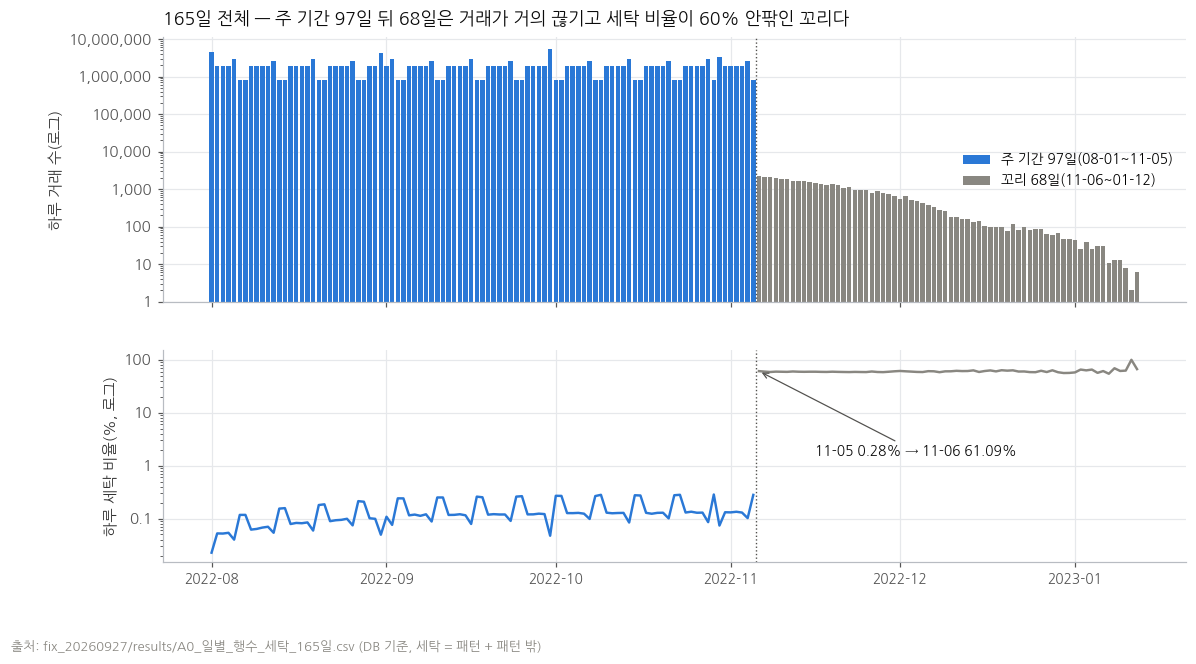

In [6]:
# 그림 1-1. 165일 전체 — 위: 하루 거래 수(로그), 아래: 하루 세탁 비율(%, 로그). 척도가 달라 두 칸으로 나눈다(이중 축 없음).
x = np.arange(len(A0)); im = (A0.day <= MAIN_END).to_numpy(); b = int(np.flatnonzero(~im)[0])
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True, gridspec_kw=dict(height_ratios=[1.25, 1]))
a1.bar(x[im], A0.rows[im], width=0.8, color=C_PAT, label=f'주 기간 {im.sum()}일(08-01~11-05)')
a1.bar(x[~im], A0.rows[~im], width=0.8, color=C_NORM, label=f'꼬리 {(~im).sum()}일(11-06~01-12)')
a1.set_yscale('log'); a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}')); a1.set_ylabel('하루 거래 수(로그)'); a1.legend(frameon=False, fontsize=9, loc='center right')
a2.plot(x[im], A0.pos_pct[im], color=C_PAT, lw=1.6); a2.plot(x[~im], A0.pos_pct[~im], color=C_NORM, lw=1.6)
a2.set_yscale('log'); a2.set_ylabel('하루 세탁 비율(%, 로그)'); a2.yaxis.set_major_formatter(num_fmt)
for ax in (a1, a2):
    ax.axvline(b - 0.5, color=INK2, lw=0.9, ls=':')
a2.annotate(f'11-05 {A0.pos_pct[b - 1]:.2f}% → 11-06 {A0.pos_pct[b]:.2f}%', xy=(b, A0.pos_pct[b]), xytext=(b + 10, 1.5),
            fontsize=9, color=INK, arrowprops=dict(arrowstyle='->', color=INK2, lw=0.8))
ms = [i for i, d in enumerate(A0.day) if d.day == 1]
a2.set_xticks(ms); a2.set_xticklabels([f'{A0.day[i]:%Y-%m}' for i in ms], fontsize=9)
title(a1, '165일 전체 — 주 기간 97일 뒤 68일은 거래가 거의 끊기고 세탁 비율이 60% 안팎인 꼬리다')
fig.text(0.01, -0.02, '출처: fix_20260927/results/A0_일별_행수_세탁_165일.csv (DB 기준, 세탁 = 패턴 + 패턴 밖)', fontsize=8.5, color=MUTED)
savefig(fig, 'S1_1_165일_행수_세탁비율.png')

그림 1-2 는 `fix_20260927/make_figs.py:53-69`(그림 F1) 코드를 **빌드할 때 글자 그대로 읽어** 옮긴 것이다. 꾸밈 함수 `style`(:33-40)도 같이 옮긴다. 바꾼 곳: 입력 경로(`R` → `FRES`), 저장(`save` → `savefig`), 꾸밈 함수 이름(`style` → `style_fix`), 그림 번호.

읽음: /workspace/Final_preprocess/fix_20260927/results/A0_일별_행수_세탁_165일.csv  (6,195 B · 165행)


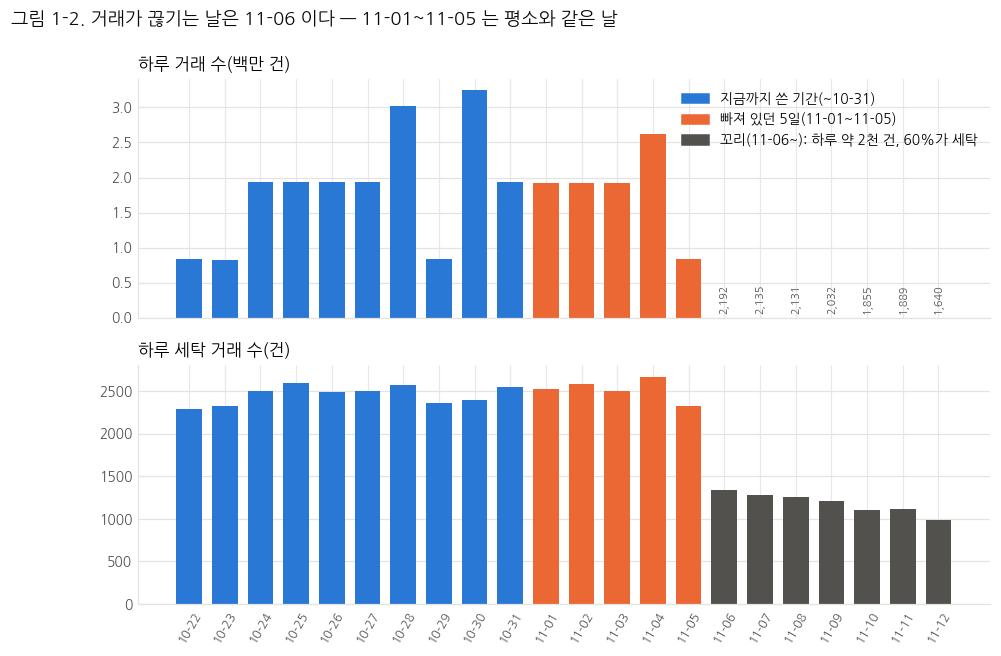

In [7]:
# 원본: fix_20260927/make_figs.py:33-40(style) · :53-69(F1). 바꾼 곳은 위 설명.
def style_fix(ax, grid='y'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
    ax.grid(axis=grid, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    ax.title.set_color(INK); ax.xaxis.label.set_color(INK2); ax.yaxis.label.set_color(INK2)


# ── F1 주 기간의 끝은 어디인가: 날짜별 거래 수·세탁 건수(10-22~11-12) ──
d = rd(FRES / 'A0_일별_행수_세탁_165일.csv'); d['day'] = pd.to_datetime(d['day'])
w = d[(d.day >= '2022-10-22') & (d.day <= '2022-11-12')].reset_index(drop=True)
fig, axs = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True)
x = np.arange(len(w)); lab = [t.strftime('%m-%d') for t in w.day]
grp = np.where(w.day <= '2022-10-31', 0, np.where(w.day <= '2022-11-05', 1, 2)); col = np.array([C1, C2, INK2])[grp]
for ax, y, ttl in ((axs[0], w.rows / 1e6, '하루 거래 수(백만 건)'), (axs[1], w.pos, '하루 세탁 거래 수(건)')):
    ax.bar(x, y, width=0.72, color=col); style_fix(ax); ax.set_title(ttl, fontsize=11, loc='left')
for i in range(len(w)):
    if grp[i] == 2:
        axs[0].text(x[i], w.rows[i] / 1e6 + 0.05, f'{int(w.rows[i]):,}', ha='center', va='bottom', fontsize=7, color=INK2, rotation=90)
axs[1].set_xticks(x); axs[1].set_xticklabels(lab, rotation=60, fontsize=8)
from matplotlib.patches import Patch
axs[0].legend(handles=[Patch(color=C1, label='지금까지 쓴 기간(~10-31)'), Patch(color=C2, label='빠져 있던 5일(11-01~11-05)'), Patch(color=INK2, label='꼬리(11-06~): 하루 약 2천 건, 60%가 세탁')],
              frameon=False, fontsize=9, loc='upper right', ncol=1)
fig.suptitle('그림 1-2. 거래가 끊기는 날은 11-06 이다 — 11-01~11-05 는 평소와 같은 날', fontsize=12, color=INK, x=0.01, ha='left')
savefig(fig, 'S1_2_주기간_끝_F1.png')

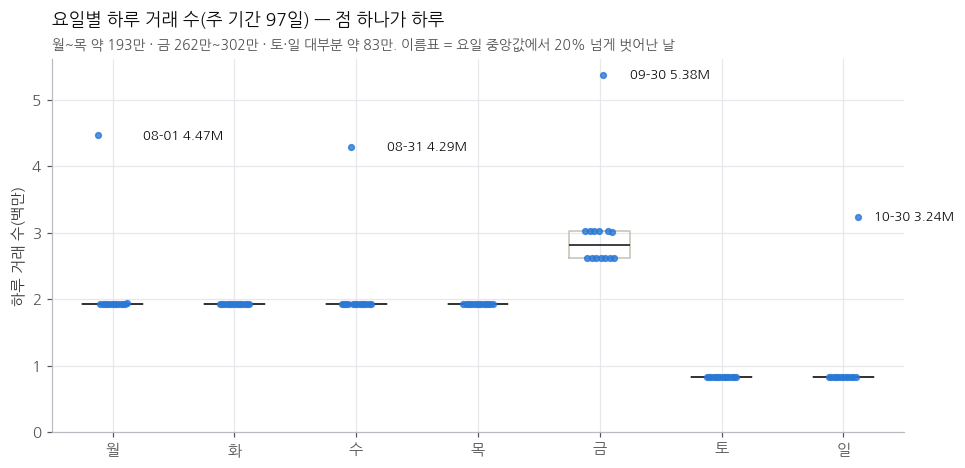

,시작,끝,일수,행,세탁,세탁비율_pct
주,,,,,,
0,08-01,08-07,7,14933007,7206.0,0.0483
1,08-08,08-14,7,11996128,9059.0,0.0755
2,08-15,08-21,7,12396302,11133.0,0.0898
3,08-22,08-28,7,11994358,12667.0,0.1056
4,08-29,09-04,7,14764677,14353.0,0.0972
5,09-05,09-11,7,12013825,15466.0,0.1287
6,09-12,09-18,7,12403040,15696.0,0.1265
7,09-19,09-25,7,12003896,15935.0,0.1327
8,09-26,10-02,7,14764403,16362.0,0.1108


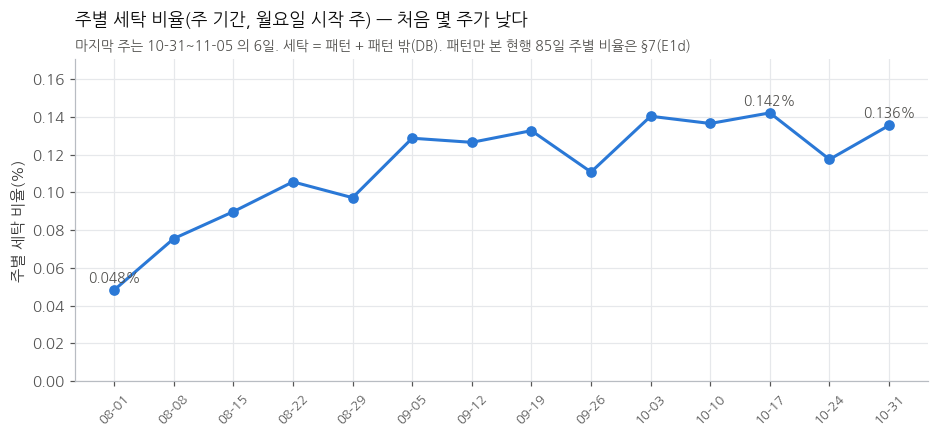

In [8]:
# 그림 1-3. 주 기간 97일의 요일별 하루 거래 수 — 요일 규칙이 크지만 예외가 있다(부록 C 정정 5)
fig, ax = plt.subplots(figsize=(10, 4.4))
WD = list('월화수목금토일')
data = [mn.loc[mn['요일'] == k, 'rows'].to_numpy() / 1e6 for k in WD]
ax.boxplot(data, tick_labels=WD, widths=0.5, showfliers=False, medianprops=dict(color=INK), boxprops=dict(color=BASE), whiskerprops=dict(color=BASE), capprops=dict(color=BASE))
for k, v in enumerate(data):
    ax.scatter(np.full(len(v), k + 1) + np.linspace(-0.12, 0.12, len(v)), v, s=14, color=C_PAT, alpha=0.8, zorder=3)
for _, r in EXC.iterrows():
    k = WD.index(r['요일']) + 1
    ax.annotate(f"{r['day']:%m-%d} {r['rows'] / 1e6:.2f}M", xy=(k, r['rows'] / 1e6), xytext=(k + 0.25, r['rows'] / 1e6), fontsize=8.5, color=INK, va='center')
ax.set_ylabel('하루 거래 수(백만)'); ax.set_ylim(0, None)
title(ax, '요일별 하루 거래 수(주 기간 97일) — 점 하나가 하루', '월~목 약 193만 · 금 262만~302만 · 토·일 대부분 약 83만. 이름표 = 요일 중앙값에서 20% 넘게 벗어난 날')
savefig(fig, 'S1_3_요일별_하루거래.png')

# 그림 1-4. 주별 세탁 비율(A0 를 월요일 시작 주로 합침 — 08-01 이 월요일). 세탁 = 패턴 + 패턴 밖
mn['주'] = (mn.day - pd.Timestamp('2022-08-01')).dt.days // 7
Wk = mn.groupby('주').agg(시작=('day', 'min'), 끝=('day', 'max'), 일수=('day', 'size'), 행=('rows', 'sum'), 세탁=('pos', 'sum'))
Wk['세탁비율_pct'] = 100 * Wk['세탁'] / Wk['행']
display(Wk.assign(시작=Wk['시작'].dt.strftime('%m-%d'), 끝=Wk['끝'].dt.strftime('%m-%d')).round(4))
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(Wk.index, Wk['세탁비율_pct'], marker='o', ms=6, color=C_PAT, lw=2)
for i in (Wk.index[0], Wk['세탁비율_pct'].idxmax(), Wk.index[-1]):
    ax.text(i, Wk.loc[i, '세탁비율_pct'] + 0.004, f"{Wk.loc[i, '세탁비율_pct']:.3f}%", ha='center', fontsize=9, color=INK2)
ax.set_xticks(Wk.index); ax.set_xticklabels([f'{t:%m-%d}' for t in Wk['시작']], fontsize=8.5, rotation=45)
ax.set_ylabel('주별 세탁 비율(%)'); ax.set_ylim(0, Wk['세탁비율_pct'].max() * 1.2)
title(ax, '주별 세탁 비율(주 기간, 월요일 시작 주) — 처음 몇 주가 낮다', '마지막 주는 10-31~11-05 의 6일. 세탁 = 패턴 + 패턴 밖(DB). 패턴만 본 현행 85일 주별 비율은 §7(E1d)')
savefig(fig, 'S1_4_주별_세탁비율.png')

**해석**
- **165일 = 주 기간 97일(08-01~11-05) + 꼬리 68일(11-06~01-12).** 꼬리는 하루 2~2,192행뿐이다. 꼬리 40,719행 중 세탁이 24,273(59.6%, 모두 패턴)이고 정상이 16,446(거의 다 ACH, §4-1)이다. 그래서 **주 기간의 끝은 11-05** 이고(fix [A]), 11-06 에 절벽이 있다.
- 꼬리 세탁의 대부분(23,405)은 주 기간에 시작한 시도의 남은 거래다. 나머지 868 은 꼬리에서 새로 시작한 시도 204개의 거래다(A2b, §2-2).
- 하루 거래량은 요일 규칙이 크다. 그러나 **규칙이 아니다**: 08-01 · 08-31 · 09-30 같은 월초·월말과 10-30(일)에 많다. "주말 약 83만 행"을 규칙처럼 쓰면 틀린다(부록 C 정정 5). 이런 날의 구성은 아직 안 봤다(부록 B #5).
- 08-01 의 세탁 **비율**(0.0226%)이 다음 날의 절반인 것은 **거래가 4,466,821행으로 평소 월요일의 2.3배**라서다. 세탁 **건수**(1,008)는 다음 날(1,011)과 같다. 그래서 이 비율은 "워밍업"의 근거가 아니다. "첫날 워밍업"은 이력 피처 쪽 현상이다: 08-01 에는 거의 모든 계좌쌍이 처음이라 정상 행의 처음 쌍 비율이 61.6% 다(§5-2).
- 주별 세탁 비율은 처음 몇 주에 낮고 9월부터 비슷해진다(그림 1-4). 패턴만 따로 본 현행 분할 기준 램프는 §7(E1d)에 있다.

### 1-3. 쓰는 기간과 분할 — DB `split` 열로 판단하면 틀린다 [저장 결과]
- 지금 쓰는 기간은 **08-08 ~ 10-31, 85일**이다. 08-01~07 은 통화 보정(36번째 피처 `amt_z_pay_ccy` 의 기준) 전용이다.
- 분할은 **날짜 51/17/17**(train 08-08~09-27 · val 09-28~10-14 · test 10-15~10-31)이다. **09-29 결정: 최종 평가의 test 만 11-05 까지(51/17/22).** 개발·팔 비교는 17일 그대로다.
- 아래 표 `F1` 은 DB `tx.split` 열(24/30/31일)과 실제 분할을 나란히 놓는다. `R2` 는 현행 분할의 행·라벨 수다.

In [9]:
F1 = rd(FRES / 'F1_분할정의_두개.csv'); display(F1)
R2 = rd(FRES / 'R2_행수라벨_전후.csv'); display(R2)
print('현행 분할(tree9_lib.py:54 를 옮김):', SPLIT_DAYS, '· 최종 test 끝:', TEST22_END)

읽음: /workspace/Final_preprocess/fix_20260927/results/F1_분할정의_두개.csv  (2,347 B · 17행)


,정의,구간,시작,끝,행,세탁,출처
0,DB tx.split 열(태훈님 data_config),calibration,2022-08-01,2022-08-07,14933007,7206,/tmp/tree9_work/db_full/dataset_summary.csv
1,DB tx.split 열(태훈님 data_config),train,2022-08-08,2022-08-31,44535079,38834,/tmp/tree9_work/db_full/dataset_summary.csv
2,DB tx.split 열(태훈님 data_config),val,2022-09-01,2022-09-30,56137066,67372,/tmp/tree9_work/db_full/dataset_summary.csv
3,DB tx.split 열(태훈님 data_config),test,2022-10-01,2022-10-31,54821337,75263,/tmp/tree9_work/db_full/dataset_summary.csv
4,DB tx.split 열(태훈님 data_config),outside,2022-11-01,2023-01-12,9275590,36871,/tmp/tree9_work/db_full/dataset_summary.csv
5,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,0_보정(08-01~08-07),NaN,NaN,14932226,7206,results/D2_라벨수_전후대조.csv
6,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,1_train(08-08~09-27),NaN,NaN,91426514,98932,results/D2_라벨수_전후대조.csv
7,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,2_val(09-28~10-14),NaN,NaN,33649784,40971,results/D2_라벨수_전후대조.csv
8,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,3_test17(10-15~10-31),NaN,NaN,30407864,41566,results/D2_라벨수_전후대조.csv
9,우리가 실제로 쓴 분할(tree9_lib.SPLIT_DAYS 51/17/17) — 고치기 전,4_되살린5일(11-01~11-05),NaN,NaN,9234293,12598,results/D2_라벨수_전후대조.csv


읽음: /workspace/Final_preprocess/fix_20260927/results/R2_행수라벨_전후.csv  (676 B · 8행)


,시점,구간,날짜수,모집단_행,정상,세탁,패턴_세탁,패턴밖_세탁_뺌,학습또는채점_행
0,고치기 전,train,51,91426514,91327582,98932,55837,43095,91383419
1,고치기 전,val,17,33649784,33608813,40971,24280,16691,33633093
2,고치기 전,test(옛 17일),17,30407864,30366298,41566,24503,17063,30390801
3,고친 뒤,train,51,91432129,91333197,98932,55837,43095,91389034
4,고친 뒤,val,17,33651717,33610746,40971,24280,16691,33635026
5,고친 뒤,test(고친 22일),22,39644507,39590343,54164,31751,22413,39622094
6,고치기 전,합계,85,155484162,155302693,181469,104620,76849,155407313
7,고친 뒤,합계,90,164728353,164534286,194067,111868,82199,164646154


현행 분할(tree9_lib.py:54 를 옮김): {'train': ('2022-08-08', '2022-09-27'), 'val': ('2022-09-28', '2022-10-14'), 'test': ('2022-10-15', '2022-10-31')} · 최종 test 끝: 2022-11-05


**해석**
- DB `split` 열은 태훈님 `data_config`(train 08월 · val 9월 · test 10월)용이다. **실제 실험 분할(51/17/17)과 다르다.** 분할은 날짜로만 판단한다.
- `R2` 의 "고친 뒤" 행은 fix 정정안(중복 되살림 + 11-05 까지)이다. **현행 파이프라인은 "고치기 전" 행**이다(§6). 병합판·test22 는 §7-2 에서 다시 센다.

### 1-4. 참고: 태훈님 파이프라인과의 대응(09-21, 유효)
EDA 라기보다 전처리 사실이다. 지금 모델 입력을 해석할 때 필요한 세 가지만 둔다.
- 원래 계산 T1 · T3 · T4 는 노트북 14 · 16 · 17 이다. 입력(태훈님 샘플 CSV 3개, `reprocess/align/new_new2key.parquet`, interim 90파트, 옛 `X_tr.npy`)이 모두 `/workspace` 에 있어 아래에 **무거운 셀로 옮겼다(꺼짐).** interim 90파트를 훑거나 35 GB 행렬을 mmap 으로 읽는다.
- T5f(결합 파일 분할별 건수)는 노트북 20 이 만든다. 태훈님 코드 복사본(`/tmp/tree9_work/code`, `tree9_lib`)을 import 하고 DuckDB 를 새로 짓는 코드라 **옮기지 않았다**(지금 `/tmp/tree9_work` 재구축 중 · 전처리 통합본 참고).

In [10]:
# [무거움 · 기본 꺼짐] 원본: notebooks/14_태훈님_값파일_매칭검증.ipynb cell 1 · 2 · 3 · 4 · 5 · 6 · 7
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: C.save_csv( → save_csv_h( (out/); C.WORK/taehoon_rowmap_head.parquet → OUT
def _heavy_T1():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    # ── 원본 14_태훈님_값파일_매칭검증.ipynb cell 1 ──
    import sys, os, gc, json, re
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np, pandas as pd, pyarrow.parquet as pq
    import eda_common as C

    FD = pd.read_csv('/workspace/Final_preprocess/태훈님_전처리/feature_details.csv')
    EDGE_F = list(FD[FD.kind == '엣지'].feature); NODE_F = list(FD[FD.kind == '노드'].feature)
    NAME_FIX = {'type_Sole Proprietorship': 'type_Sole_Proprietorship'}   # 09-21 2인 잠정 합의: 열 이름의 공백 → _ (태훈님 쪽도 같은 이름으로 변경 필요)
    NAME_INV = {v: k for k, v in NAME_FIX.items()}
    NODE_F = [NAME_FIX.get(f, f) for f in NODE_F]                          # 최종 이름(feature_details.csv 는 옛 이름이라 여기서 고친다)
    def present(cols, wanted):
        """wanted(최종 이름) 각각의 파일 속 열 이름: 파일이 이미 고친 이름이면 그대로, 옛 이름(공백)이면 옛 이름."""
        return [w if w in cols else NAME_INV.get(w, w) for w in wanted]
    assert len(EDGE_F) == 18 and len(NODE_F) == 22

    def mem(tag):
        rss = [int(l.split()[1]) for l in open('/proc/self/status') if l.startswith('VmRSS')][0] / 2**20
        print(f'[{tag}] 컨테이너 anon {C.anon_gib():.2f} GiB · 이 노트북 RSS {rss:.2f} GiB')

    def columns_of(path):
        """파일을 다 읽지 않고 열 이름만 본다."""
        path = str(path)
        return list(pq.ParquetFile(path).schema_arrow.names) if path.endswith('.parquet') else list(pd.read_csv(path, nrows=0).columns)

    def batches(path, columns=None, size=2_000_000):
        """큰 파일을 조각으로 읽는다(메모리 상한 27.3GiB — 전 행을 한 번에 올리지 않는다)."""
        path = str(path)
        if path.endswith('.parquet'):
            for b in pq.ParquetFile(path).iter_batches(batch_size=size, columns=columns):
                yield b.to_pandas()
        else:
            for ch in pd.read_csv(path, usecols=columns, chunksize=size):
                yield ch

    def acct_key(bank, acct):
        """계좌 키 = 은행 ID(앞자리 0 제거) + '_' + 계좌번호 — eda_common.bank0 규칙(09-17 실측)."""
        return pd.Series(np.asarray(bank)).astype(str).map(C.bank0) + '_' + pd.Series(np.asarray(acct)).astype(str)

    def norm_key(keys):
        """내 계좌 키('020_800104D70')의 은행 부분을 같은 규칙으로 정규화('20_800104D70') — 태훈님 키와 같은 형식으로 맞춘다."""
        sp = pd.Series(np.asarray(keys, dtype=object)).str.split('_', n=1, expand=True)
        return (sp[0].map(C.bank0) + '_' + sp[1]).to_numpy(dtype=object)

    # ── 원본 14_태훈님_값파일_매칭검증.ipynb cell 2 ──
    # ── 설정: 파일이 오면 여기만 채운다 ──
    EDGE_PATH = '/workspace/Final_preprocess/태훈님_전처리/edge_values_first1000.csv'   # 09-21 태훈님 엣지 샘플(1,000행)
    NODE_PATH = '/workspace/Final_preprocess/태훈님_전처리/node_values_1345_accounts_20220808_20220809.csv'   # 09-21 노드 샘플(엣지 샘플 계좌 1,345개 × 8/8·8/9)
    ROW_COL = 'edge_id'     # 원본 HI-Large_Trans.csv 기준 행 번호 열 이름. 없으면 None → 아래 KEY 열로 짝을 찾는다
    ROW_BASE = 0            # 행 번호가 0부터면 0, 1부터면 1 (아래 검사가 1칸 밀림을 잡아 준다)
    LABEL_COL = 'Is_Laundering'   # 태훈님 쪽 세탁 라벨 열(없으면 None)
    KEY = dict(ts='Timestamp', from_bank='from_bank_id_raw', from_acct='from_account', to_bank='to_bank_id_raw', to_acct='to_account',
               paid='Amount_Paid_raw')   # 행 번호가 없을 때·금액 대조에 쓰는 원본 열 이름(파일에 있는 것만 쓴다)
    NODE_KEY = dict(bank='bank_id', acct='account', date='date')   # 노드 파일의 키 열 이름
    CHECK_N = 1_000       # 금액·시각 대조에 쓸 앞 행 수(임의, 이 점검용)
    DAY0 = '2022-08-01'     # 내 index_full 의 day=0 날짜(노트북 08 정의)
    assert EDGE_PATH, 'EDGE_PATH 를 채운 뒤 실행'

    # ── 원본 14_태훈님_값파일_매칭검증.ipynb cell 3 ──
    # ── ① 열 이름 점검: feature_details.csv 와 글자까지 같은가 ──
    ecols = columns_of(EDGE_PATH)
    print('엣지 파일 열', len(ecols)); print('  없는 피처:', [f for f in EDGE_F if f not in ecols]); print('  피처·키가 아닌 열:', [c for c in ecols if c not in EDGE_F])
    has_row = bool(ROW_COL) and ROW_COL in ecols; has_lab = bool(LABEL_COL) and LABEL_COL in ecols
    key_have = {k: v for k, v in KEY.items() if v in ecols}
    print('행 번호 열 있음:', has_row, '| 라벨 열 있음:', has_lab, '| 원본 키 열:', key_have)
    assert has_row or {'ts', 'from_bank', 'from_acct', 'to_bank', 'to_acct', 'paid'} <= set(key_have), '행 번호도 원본 키 열도 없어 짝을 맞출 수 없다 — 태훈님께 다시 요청'
    REPORT = [{'항목': '엣지 피처 18열 중 파일에 있는 수', '값': sum(f in ecols for f in EDGE_F)}]

    # ── 원본 14_태훈님_값파일_매칭검증.ipynb cell 4 ──
    # ── ②③⑤ 행 번호 경로: 범위·중복·라벨 일치·모집단 위치 ──
    g_raw, _, s_raw = C.load_labels()          # 원본 행 기준: grp(-1 정상/0~7 패턴/8 패턴 밖), split(0/1/2, -1 꼬리, -2 중복)
    n_raw = C.n_raw()
    if has_row:
        use = [ROW_COL] + ([LABEL_COL] if has_lab else [])
        rows, labs = [], []
        for b in batches(EDGE_PATH, columns=use):
            rows.append(b[ROW_COL].to_numpy(np.int64) - ROW_BASE)
            if has_lab: labs.append(b[LABEL_COL].to_numpy(np.int8))
        rows = np.concatenate(rows); labs = np.concatenate(labs) if has_lab else None
        n_t = len(rows); in_rng = (rows >= 0) & (rows < n_raw)
        REPORT += [{'항목': '태훈님 엣지 파일 행 수', '값': n_t}, {'항목': '행 번호가 범위 [0, n_raw) 밖인 행', '값': int((~in_rng).sum())},
                   {'항목': '중복된 행 번호 수', '값': int(n_t - len(np.unique(rows)))}]
        r = rows[in_rng]
        sp = pd.Series(np.asarray(s_raw)[r]).map({0: 'train', 1: 'val', 2: 'test', -1: '꼬리(내 모집단 밖)', -2: '완전 중복(내 모집단 밖)'}).value_counts()
        for k, v in sp.items(): REPORT.append({'항목': f'내 분할 기준 위치 — {k}', '값': int(v)})
        if has_lab:
            mine = (np.asarray(g_raw)[r] >= 0).astype(np.int8); th = labs[in_rng]
            ct = pd.crosstab(pd.Series(th, name='태훈님 라벨'), pd.Series(mine, name='내 라벨(세탁=1)')); display(ct)
            REPORT.append({'항목': '라벨 불일치 행(같은 행 번호에서)', '값': int((th != mine).sum())})
            for sh in (-1, 1):                 # 행 번호가 1칸 밀렸는지: 밀린 쪽이 더 잘 맞으면 ROW_BASE 가 틀린 것
                rr = r + sh; ok = (rr >= 0) & (rr < n_raw)
                REPORT.append({'항목': f'참고: 행 번호를 {sh:+d} 밀었을 때 라벨 불일치', '값': int((th[ok] != (np.asarray(g_raw)[rr[ok]] >= 0)).sum())})
    else:
        print('행 번호 열이 없다 → 다음 셀(원본 키로 짝 찾기)로')
    mem('행 번호 점검')

    # ── 원본 14_태훈님_값파일_매칭검증.ipynb cell 5 ──
    # ── ④ 금액·시각 대조(앞 CHECK_N 행) / 행 번호가 없으면 원본 키로 짝 찾기 ──
    ps, starts = C.part_starts()
    n2k = pd.read_parquet(C.ALIGN / 'new_new2key.parquet'); n2k = pd.Series(norm_key(n2k['key']), index=n2k['raw_node_id'].to_numpy())

    def raw_rows_frame(rr):
        """원본 행 번호 → 내 원본 파트의 (시각 분, 송·수신 계좌 키, 송금액). 필요한 파트만 읽는다."""
        out = []
        for p in np.unique(np.searchsorted(starts, rr, side='right') - 1):
            m = (rr >= starts[p]) & (rr < starts[p + 1])
            t = pd.read_parquet(ps[p], columns=['ts_epoch_min', 'src_id', 'dst_id', 'paid']).iloc[rr[m] - starts[p]].copy()
            t['raw_row'] = rr[m]; out.append(t)
        t = pd.concat(out); t['src_key'] = n2k.reindex(t['src_id']).to_numpy(); t['dst_key'] = n2k.reindex(t['dst_id']).to_numpy()
        return t.set_index('raw_row')

    head = next(batches(EDGE_PATH, size=CHECK_N))
    if has_row:
        rr = head[ROW_COL].to_numpy(np.int64) - ROW_BASE; mine = raw_rows_frame(rr).reindex(rr)
        if 'paid' in key_have:
            d = np.abs(head[KEY['paid']].to_numpy(float) - mine['paid'].to_numpy()); REPORT.append({'항목': f'송금액이 다른 행(앞 {len(head):,}행, 차 > 0.005)', '값': int((d > 0.005).sum())})
        if 'ts' in key_have:
            tm = ((pd.to_datetime(head[KEY['ts']]) - pd.Timestamp('1970-01-01')) // pd.Timedelta(minutes=1)).to_numpy()
            REPORT.append({'항목': f'시각(분)이 다른 행(앞 {len(head):,}행)', '값': int((tm != mine['ts_epoch_min'].to_numpy()).sum())})
        if {'from_bank', 'from_acct'} <= set(key_have):
            k = acct_key(head[KEY['from_bank']], head[KEY['from_acct']]).to_numpy()
            REPORT.append({'항목': f'송신 계좌 키가 다른 행(앞 {len(head):,}행)', '값': int((k != mine['src_key'].to_numpy()).sum())})
    else:
        # 원본 키(시각 분, 송·수신 계좌 키, 송금액 센트)로 앞 CHECK_N 행의 짝을 찾는다. 전체 파일은 같은 방법을 조각마다 되풀이(15 에서)
        h = pd.DataFrame({'ts': (pd.to_datetime(head[KEY['ts']]) - pd.Timestamp('1970-01-01')) // pd.Timedelta(minutes=1),
                          'src_key': acct_key(head[KEY['from_bank']], head[KEY['from_acct']]), 'dst_key': acct_key(head[KEY['to_bank']], head[KEY['to_acct']]),
                          'cents': np.round(head[KEY['paid']].to_numpy(float) * 100).astype(np.int64), 'th_row': np.arange(len(head))})
        lo, hi = h.ts.min(), h.ts.max(); cand = []
        for p, f in enumerate(ps):
            t = pd.read_parquet(f, columns=['ts_epoch_min', 'src_id', 'dst_id', 'cents']); t['raw_row'] = np.arange(starts[p], starts[p + 1])
            t = t[(t.ts_epoch_min >= lo) & (t.ts_epoch_min <= hi)]
            if len(t): cand.append(t)
        cand = pd.concat(cand); cand['src_key'] = n2k.reindex(cand['src_id']).to_numpy(); cand['dst_key'] = n2k.reindex(cand['dst_id']).to_numpy()
        mg = h.merge(cand.rename(columns={'ts_epoch_min': 'ts'}), on=['ts', 'src_key', 'dst_key', 'cents'], how='left')
        per = mg.groupby('th_row')['raw_row'].agg(['count'])
        REPORT += [{'항목': f'원본 키로 짝 찾기(앞 {len(head):,}행) — 후보 1개(확정)', '값': int((per['count'] == 1).sum())},
                   {'항목': '후보 2개 이상(같은 분·같은 계좌쌍·같은 금액 — 구분 불가)', '값': int((per['count'] > 1).sum())}, {'항목': '후보 0개(짝 없음)', '값': int((per['count'] == 0).sum())}]
        mg[mg.groupby('th_row')['raw_row'].transform('count') == 1][['th_row', 'raw_row']].to_parquet(OUT / 'taehoon_rowmap_head.parquet', index=False)
    mem('금액·시각 대조')

    # ── 원본 14_태훈님_값파일_매칭검증.ipynb cell 6 ──
    # ── ①⑥ 노드 파일: 22열 이름·키 중복·날짜 기준 ──
    if NODE_PATH:
        ncols = columns_of(NODE_PATH)
        nf_file = present(ncols, NODE_F)
        print('없는 노드 피처:', [f for f, ff in zip(NODE_F, nf_file) if ff not in ncols]); print('피처가 아닌 열:', [c for c in ncols if c not in nf_file])
        print('공백 → _ 이름 고침 적용:', [f'{a} → {b}' for a, b in NAME_FIX.items() if a in ncols])
        assert all(v in ncols for v in NODE_KEY.values()), f'노드 키 열 {NODE_KEY} 이 파일에 없다 — NODE_KEY 를 실제 열 이름으로 고친다'
        kk = pd.concat([b for b in batches(NODE_PATH, columns=list(NODE_KEY.values()))])
        kk['key'] = acct_key(kk[NODE_KEY['bank']], kk[NODE_KEY['acct']]).to_numpy(); kk['d'] = pd.to_datetime(kk[NODE_KEY['date']]).dt.normalize()
        my_keys = set(norm_key(pd.read_parquet(C.ALIGN / 'new_new2key.parquet')['key']))
        REPORT += [{'항목': '노드 피처 22열 중 파일에 있는 수', '값': sum(ff in ncols for ff in nf_file)}, {'항목': '노드 파일 행 수', '값': len(kk)},
                   {'항목': '(계좌, 날짜) 중복 행', '값': int(kk.duplicated(['key', 'd']).sum())}, {'항목': '노드 파일 계좌 중 내 계좌 표에 있는 비율(%)', '값': 100 * kk['key'].isin(my_keys).mean()},
                   {'항목': '노드 날짜 범위', '값': f"{kk['d'].min().date()} ~ {kk['d'].max().date()}"}]
        if has_row:       # 거래 날짜와 노드 날짜가 며칠 어긋나 있는지(−1/0/+1): 앞 CHECK_N 행의 송신 계좌로 본다
            base = pd.to_datetime(mine['ts_epoch_min'].to_numpy() * 60, unit='s').normalize(); have = set(zip(kk['key'], kk['d']))
            for off in (-1, 0, 1):
                hit = np.mean([(k, d + pd.Timedelta(days=off)) in have for k, d in zip(mine['src_key'], base)])
                REPORT.append({'항목': f'거래일 {off:+d}일의 송신 계좌 노드 행이 있는 비율(%) — 앞 {len(mine):,}행', '값': 100 * hit})
        del kk; gc.collect()
    else:
        print('NODE_PATH 없음 — 노드 점검 건너뜀')

    # ── 원본 14_태훈님_값파일_매칭검증.ipynb cell 7 ──
    # ── 결과표 저장 + 멈춤 조건 안내(판단은 사람이 한다) ──
    R = pd.DataFrame(REPORT); save_csv_h(R, 'T1_태훈님_값파일_매칭검증.csv'); pd.set_option('display.max_colwidth', 120); display(R)
    bad = R[R['항목'].str.contains(r'범위 \[0|중복된 행 번호|라벨 불일치 행|송금액이 다른|시각\(분\)이 다른|송신 계좌 키가 다른|후보 0개|후보 2개') & (pd.to_numeric(R['값'], errors='coerce') > 0)]
    print('※ 0 이 아니어서 15(결합) 전에 원인을 봐야 하는 항목:' if len(bad) else '※ 짝 맞추기 검사 항목이 모두 0'); display(bad)


if HEAVY['T1']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_T1()
else:
    print("HEAVY['T1'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['T1'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [11]:
# [무거움 · 기본 꺼짐] 원본: notebooks/16_태훈님_엣지샘플_값대조.ipynb cell 1 · 2 · 3
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: C.save_csv( → save_csv_h( (out/)
def _heavy_T3():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    # ── 원본 16_태훈님_엣지샘플_값대조.ipynb cell 1 ──
    # ── 적재: 태훈님 샘플, 원본 행 → 내 전처리 행, 내 81열 값 ──
    import sys, json, gc
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np, pandas as pd
    from scipy.stats import spearmanr
    import eda_common as C

    E = pd.read_csv('/workspace/Final_preprocess/태훈님_전처리/edge_values_first1000.csv')
    raw = E['edge_id'].to_numpy(np.int64)
    p2r = np.load(C.ALIGN / 'new_proc2raw.npy', mmap_mode='r')
    hit = np.flatnonzero(np.isin(np.asarray(p2r), raw))                 # 전처리 행 중 샘플 원본 행에 해당하는 것
    order = pd.Series(hit, index=np.asarray(p2r)[hit]).reindex(raw)     # 샘플 순서대로 전처리 행
    print('내 모집단에서 찾은 행', int(order.notna().sum()), '/', len(raw))
    proc = order.to_numpy(np.int64)
    meta = json.loads((C.MAIN / 'features_meta.json').read_text()); names = meta['features']['names']; n_tr = meta['split']['rows'][0]
    assert (proc < n_tr).all(), '샘플이 전부 train 이라는 가정이 깨짐'
    X = np.load(C.MAIN / 'stage1_9class/X_tr.npy', mmap_mode='r'); srt = np.argsort(proc)
    M = pd.DataFrame(np.asarray(X[proc[srt]])[np.argsort(srt)], columns=names)
    ypos = np.load(C.MAIN / 'stage1_9class/is_pos_tr.npy', mmap_mode='r')
    print('라벨 불일치(태훈님 Is_Laundering vs 내 is_pos):', int((np.asarray(ypos)[proc].astype(int) != E['Is_Laundering'].to_numpy()).sum()))
    del p2r, X; gc.collect()

    # ── 원본 16_태훈님_엣지샘플_값대조.ipynb cell 2 ──
    # ── 대조: 같은 뜻의 열을 같은 거래에서 ──
    TOL = 1e-4
    def g_from_mine(v):
        """내 log1p(초) → 태훈님 G(Δ분) = ln(2+Δ분), 이력 없음(0)은 0 그대로."""
        dmin = np.expm1(v.astype(np.float64)) / 60.0
        return np.where(v > 0, np.log(2.0 + dmin), 0.0)

    PAIRS = [  # (태훈님, 내 열, 변환, 대응표 관계)
        ('pair_prior_count', 'tb_pair_repeat', None, '같음'),
        ('pair_count_1h', 'pair_cnt_1h', None, '같음'),
        ('sender_count_1h', 'src_out_cnt_1h', None, '같음(내 31 후보 제외 열)'),
        ('receiver_count_1h', 'dst_in_cnt_1h', None, '같음(내 31 후보 제외 열)'),
        ('is_self_transfer', 'tb_self_loop', None, '같음'),
        ('pair_gap_minutes', 'dt_pair_log', 'G', '변환만 다름'),
        ('sender_gap_minutes', 'dt_src_log', 'G', '변환만 다름'),
        ('receiver_gap_minutes', 'dt_dst_log', 'G', '변환만 다름'),
        ('paid_currency_z', 'amt_z_pay_ccy', 'rank', '통계 다름(순위만)'),
    ]
    R = []
    for th, me, how, rel in PAIRS:
        a = E[th].to_numpy(np.float64); b = M[me].to_numpy(np.float64)
        if how == 'G': b = g_from_mine(b)
        if how == 'rank':
            rho = spearmanr(a, b).correlation
            R.append({'태훈님 열': th, '내 열': me, '대응표 관계': rel, '비교': 'Spearman', '일치 행': None, '불일치 행': None, '최대 |차|': None, 'Spearman': rho}); continue
        d = np.abs(a - b)
        R.append({'태훈님 열': th, '내 열': me, '대응표 관계': rel, '비교': '값' + ('(내 값→G 변환)' if how else ''), '일치 행': int((d <= TOL).sum()), '불일치 행': int((d > TOL).sum()),
                  '최대 |차|': float(d.max()), 'Spearman': spearmanr(a, b).correlation if np.std(a) > 0 and np.std(b) > 0 else None})
    R = pd.DataFrame(R); save_csv_h(R, 'T3_엣지샘플_값대조.csv'); pd.set_option('display.width', 220); display(R)

    # ── 원본 16_태훈님_엣지샘플_값대조.ipynb cell 3 ──
    # ── 불일치가 있으면 사례를 보여 준다(원인은 사람이 판단) ──
    for th, me, how, rel in PAIRS:
        if how == 'rank': continue
        a = E[th].to_numpy(np.float64); b = M[me].to_numpy(np.float64); b2 = g_from_mine(b) if how == 'G' else b
        bad = np.flatnonzero(np.abs(a - b2) > TOL)
        if len(bad):
            print(f'== {th} vs {me}: 불일치 {len(bad)}행 — 앞 5행')
            show = pd.DataFrame({'edge_id': E['edge_id'].to_numpy()[bad], 'Timestamp': E['Timestamp'].to_numpy()[bad], '태훈님': a[bad], '내 원값': b[bad], '내 값(비교 척도)': b2[bad],
                                 '태훈님 n(=e^x−1)' if how is None else '태훈님 Δ분(=e^x−2)': (np.expm1(a[bad]) if how is None else np.exp(a[bad]) - 2),
                                 '내 n' if how is None else '내 Δ분': (np.expm1(b[bad]) if how is None else np.expm1(b[bad]) / 60)})
            display(show.head(5).round(4))


if HEAVY['T3']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_T3()
else:
    print("HEAVY['T3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['T3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [12]:
# [무거움 · 기본 꺼짐] 원본: notebooks/17_태훈님_노드값_집계기간.ipynb cell 1 · 2 · 3
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: C.save_csv( → save_csv_h( (out/)
def _heavy_T4():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    # ── 원본 17_태훈님_노드값_집계기간.ipynb cell 1 ──
    import sys, os, gc
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np, pandas as pd
    import eda_common as C

    N = pd.read_csv('/workspace/Final_preprocess/태훈님_전처리/node_values_1345_accounts_20220808_20220809.csv')
    N['key'] = N['bank_id'].astype(str).map(C.bank0) + '_' + N['account'].astype(str)
    nk = pd.read_parquet(C.ALIGN / 'new_new2key.parquet')
    sp = nk['key'].str.split('_', n=1, expand=True); nk['nkey'] = sp[0].map(C.bank0) + '_' + sp[1]
    want = nk[nk['nkey'].isin(set(N['key']))]
    print('샘플 계좌', N['key'].nunique(), '| 내 계좌 표에서 찾은 수', want['nkey'].nunique())
    id2key = dict(zip(want['raw_node_id'], want['nkey'])); ids = np.array(sorted(id2key))

    OFF = 27655200                      # features_meta split.ts_offset_epoch_min = 2022-08-01 00:00(분)
    END = OFF + 9 * 1440                # 8/10 0시 전까지만 필요
    ps, _ = C.part_starts(); keep = []
    for f in ps:
        t = pd.read_parquet(f, columns=['ts_epoch_min', 'src_id', 'dst_id', 'pay_code', 'recv_code'])
        t = t[(t['ts_epoch_min'] < END) & (t['src_id'].isin(ids) | t['dst_id'].isin(ids))]
        if len(t): keep.append(t)
        try:
            fd = os.open(f, os.O_RDONLY); os.posix_fadvise(fd, 0, 0, os.POSIX_FADV_DONTNEED); os.close(fd)
        except OSError:
            pass
    T = pd.concat(keep, ignore_index=True); del keep; gc.collect()
    T['day'] = (T['ts_epoch_min'] - OFF) // 1440           # 0 = 8/1
    print('모은 거래', len(T), '| 날짜 범위(day)', int(T['day'].min()), '~', int(T['day'].max()))

    # ── 원본 17_태훈님_노드값_집계기간.ipynb cell 2 ──
    # ── 계좌별·변형별로 직접 센다 ──
    def counts(acc_id, lo, hi):
        """day ∈ [lo, hi] 안에서 계좌 acc_id 의 값들(L 적용 전 원 건수)."""
        w = T[(T['day'] >= lo) & (T['day'] <= hi)]
        o = w[w['src_id'] == acc_id]; i = w[w['dst_id'] == acc_id]
        days = set(o['day']) | set(i['day'])
        return dict(log_out_count=len(o), log_in_count=len(i), log_self_count=int((o['dst_id'] == acc_id).sum()),
                    log_out_neighbors=o['dst_id'].nunique(), log_in_neighbors=i['src_id'].nunique(), log_active_days=len(days),
                    log_currency_count=len(set(o['pay_code']) | set(i['recv_code'])))

    key2id = {v: k for k, v in id2key.items()}
    FEATS = ['log_out_count', 'log_in_count', 'log_self_count', 'log_out_neighbors', 'log_in_neighbors', 'log_active_days', 'log_currency_count']
    VAR = {'(가) D−29~D 당일 포함': 0, '(나) D−29~D−1 전날까지': -1}
    rows = []
    for _, r in N.iterrows():
        D = (pd.Timestamp(r['date']) - pd.Timestamp('2022-08-01')).days; a = key2id.get(r['key'])
        if a is None: continue
        for vn, e in VAR.items():
            c = counts(a, max(0, D - 29), D + e)
            rows.append({'key': r['key'], 'date': r['date'], '변형': vn, **{f + '__mine': np.log1p(c[f]) for f in FEATS}, **{f + '__th': r[f] for f in FEATS}})
    R = pd.DataFrame(rows)
    S = []
    for vn in VAR:
        for d in sorted(R['date'].unique()):
            x = R[(R['변형'] == vn) & (R['date'] == d)]
            S.append({'변형': vn, '날짜': d, '계좌 수': len(x), **{f: f"{int(((x[f + '__mine'] - x[f + '__th']).abs() <= 1e-4).sum())}/{len(x)}" for f in FEATS}})
    S = pd.DataFrame(S); save_csv_h(S, 'T4_노드값_집계기간_판정.csv'); pd.set_option('display.width', 250); display(S)

    # ── 원본 17_태훈님_노드값_집계기간.ipynb cell 3 ──
    # ── 가장 잘 맞는 변형에서도 안 맞는 행이 있으면 사례 ──
    for f in FEATS:
        x = R[R['변형'] == '(가) D−29~D 당일 포함']; bad = x[(x[f + '__mine'] - x[f + '__th']).abs() > 1e-4]
        if len(bad):
            print(f'== {f}: (가)에서 불일치 {len(bad)}행 — 앞 5행 (원 건수 = e^x − 1)')
            display(pd.DataFrame({'key': bad['key'], 'date': bad['date'], '태훈님 n': np.expm1(bad[f + '__th']).round(3), '내가 센 n': np.expm1(bad[f + '__mine']).round(3)}).head(5))


if HEAVY['T4']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_T4()
else:
    print("HEAVY['T4'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['T4'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


**[저장 결과]** `T1` 의 `내 분할 기준 위치 — …` 행은 옛 60/20/20 분할 기준이라 표에서 뺀다(샘플 1,000행이 모두 08-08 이므로 현행 분할로도 모두 train 이다).

In [13]:
T1 = rd(RES / 'T1_태훈님_값파일_매칭검증.csv'); old_ = T1['항목'].str.startswith('내 분할 기준 위치')
print(f'■ T1 — 태훈님 값 파일의 edge_id 가 원본 행 번호인가 (옛 분할 위치 행 {int(old_.sum())}개는 뺌)'); display(T1[~old_])
print('■ T3 — 엣지 샘플 1,000행 값 대조'); display(rd(RES / 'T3_엣지샘플_값대조.csv'))
print('■ T4 — 노드 값의 집계 기간(D−29~D 당일 포함인가, 전날까지인가)'); display(rd(RES / 'T4_노드값_집계기간_판정.csv'))
print('■ T5f — 결합 파일 분할별 건수(내 모집단 밖 행)'); display(rd(RES / 'T5f_결합_분할별_건수.csv'))

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/T1_태훈님_값파일_매칭검증.csv  (1,010 B · 19행)
■ T1 — 태훈님 값 파일의 edge_id 가 원본 행 번호인가 (옛 분할 위치 행 1개는 뺌)


,항목,값
0,엣지 피처 18열 중 파일에 있는 수,18
1,태훈님 엣지 파일 행 수,1000
2,"행 번호가 범위 [0, n_raw) 밖인 행",0
3,중복된 행 번호 수,0
5,라벨 불일치 행(같은 행 번호에서),0
6,참고: 행 번호를 -1 밀었을 때 라벨 불일치,335
7,참고: 행 번호를 +1 밀었을 때 라벨 불일치,350
8,"송금액이 다른 행(앞 1,000행, 차 > 0.005)",0
9,"시각(분)이 다른 행(앞 1,000행)",0
10,"송신 계좌 키가 다른 행(앞 1,000행)",0


■ T3 — 엣지 샘플 1,000행 값 대조
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/T3_엣지샘플_값대조.csv  (977 B · 9행)


,태훈님 열,내 열,대응표 관계,비교,일치 행,불일치 행,최대 |차|,Spearman
0,pair_prior_count,tb_pair_repeat,같음,값,1000.0,0.0,8.767700e-08,1.000000
1,pair_count_1h,pair_cnt_1h,같음,값,1000.0,0.0,5.749512e-08,1.000000
2,sender_count_1h,src_out_cnt_1h,같음(내 31 후보 제외 열),값,1000.0,0.0,1.779175e-07,1.000000
3,receiver_count_1h,dst_in_cnt_1h,같음(내 31 후보 제외 열),값,1000.0,0.0,5.749512e-08,1.000000
4,is_self_transfer,tb_self_loop,같음,값,1000.0,0.0,0.000000e+00,1.000000
5,pair_gap_minutes,dt_pair_log,변환만 다름,값(내 값→G 변환),1000.0,0.0,1.184814e-06,1.000000
6,sender_gap_minutes,dt_src_log,변환만 다름,값(내 값→G 변환),1000.0,0.0,1.211607e-06,1.000000
7,receiver_gap_minutes,dt_dst_log,변환만 다름,값(내 값→G 변환),1000.0,0.0,1.184814e-06,1.000000
8,paid_currency_z,amt_z_pay_ccy,통계 다름(순위만),Spearman,NaN,NaN,NaN,0.999938


■ T4 — 노드 값의 집계 기간(D−29~D 당일 포함인가, 전날까지인가)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/T4_노드값_집계기간_판정.csv  (593 B · 4행)


,변형,날짜,계좌 수,log_out_count,log_in_count,log_self_count,log_out_neighbors,log_in_neighbors,log_active_days,log_currency_count
0,(가) D−29~D 당일 포함,2022-08-08,1345,1345/1345,1345/1345,1345/1345,1345/1345,1345/1345,1345/1345,1345/1345
1,(가) D−29~D 당일 포함,2022-08-09,1345,1345/1345,1345/1345,1345/1345,1345/1345,1345/1345,1345/1345,1345/1345
2,(나) D−29~D−1 전날까지,2022-08-08,1345,342/1345,381/1345,1122/1345,874/1345,848/1345,0/1345,1204/1345
3,(나) D−29~D−1 전날까지,2022-08-09,1345,446/1345,631/1345,1257/1345,1068/1345,1279/1345,206/1345,1339/1345


■ T5f — 결합 파일 분할별 건수(내 모집단 밖 행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/T5f_결합_분할별_건수.csv  (405 B · 3행)


,split,일수,태훈님_행,태훈님_양성,내_모집단_밖_행,내_모집단_밖_양성,결합_행,세탁_is_pos,패턴_y9lt8,라벨_불일치,노드_못찾은_행,NaN_칸,파일_MB,초
0,train,51,91432129,98932,5615,0,91426514,98932,55837,0,0,0,3558.4,6584.5
1,val,17,33651717,40971,1933,0,33649784,40971,24280,0,0,0,1337.6,2409.4
2,test,17,30409636,41566,1772,0,30407864,41566,24503,0,0,0,1225.5,2397.1


**해석**
- **edge_id = 원본 CSV 행 번호**다. 행 번호를 ±1 밀면 라벨이 335 · 350 곳에서 어긋난다. 그래서 번호 체계가 정확히 같다고 본다.
- **노드 피처는 D−29 ~ D 당일 전체를 본다**(2,690/2,690 일치). 전날까지(D−29 ~ D−1)로 가정하면 열마다 일부만 맞는다(예: `log_active_days` 0/1,345). 09-29 에 판정 주기를 "일 마감"으로 정했으므로 정당하다(fix [B] 해결).
- 결합 파일(85일)에서 내 라벨 모집단 밖 정상 행이 9,320행(train 5,615 · val 1,933 · test 1,772)이다. 원인은 §6(중복 키).

## §2 라벨 · 패턴 8종 · 시도

**질문**: 세탁 라벨은 몇 건이고, 패턴 8종·시도(사건)는 어떻게 생겼나? 시도는 얼마나 길고, 꼬리·분할 경계에 얼마나 걸치나? 시도 안의 계좌는 이어지나?

### 2-1. 원본 행 라벨(L0)
원래 계산은 Patterns.txt 의 거래를 원본 세탁 행에 5키(분 · 송신 · 수신 · 지급액 센트 · 결제 방식)로 맞춘다(`build_labels.py:57-68`). interim 90파트(4.1 GB)를 읽으므로 **꺼 두었다.** 원래 코드는 원본 행 라벨 배열 3개(약 1.08 GB)를 저장한다. 통합본에서는 이 저장을 `SAVE_BIG`(기본 False)으로 막아, 켜도 요약 CSV·JSON 만 `out/` 에 쓴다.

In [14]:
# [무거움 · 기본 꺼짐] 원본: HI-Large_EDA/build_labels.py:2-113
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: C.log( → log_h( (out/run.log); np.save(C.WORK/…) 3줄 → if SAVE_BIG: np.save(OUT/…); C.OUT/… → OUT/…
def _heavy_L0():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    """원본 행 기준 라벨 만들기 — 정상 / 패턴 세탁(유형·사건 번호) / 패턴 밖 세탁, 그리고 전처리 구간(split).

    패턴 매칭: Patterns.txt 의 거래를 (분 시각, 송신 계좌 키, 수신 계좌 키, 지급액 센트, 결제수단)으로 원본의 세탁 행
    (Is Laundering=1)에만 맞춘다. 파이프라인 attach_labels 와 같은 키다. 한 키에 세탁 행이 여러 개 걸리면(모호) 그 수를 기록한다.
    구간(split): new_proc2raw.npy(전처리 행 → 원본 행, 전 행 검증 완료)로 원본 행에 0/1/2 를 붙이고, 전처리에서 빠진 행은
      -1 = 꼬리 절단(11-06 이후), -2 = 중복으로 제거 로 표시한다.
    출력: _work/raw_grp.npy, raw_attempt.npy, raw_split.npy, results/L0_labels_summary.csv, L0_labels.json
    """
    import json

    import numpy as np
    import pandas as pd

    import eda_common as C

    log_h('L 라벨 만들기 시작')
    ps, starts = C.part_starts()
    n = int(starts[-1])
    assert n == C.n_raw()
    keys = ['ts_epoch_min', 'src_id', 'dst_id', 'cents', 'fmt_code', 'is_pos']
    pos_frames = []
    ts_all = np.empty(n, dtype=np.int32)          # 분 단위(에폭 분 − 기준) — 꼬리 판정용
    BASE = None
    for i, f in enumerate(ps):
        t = pd.read_parquet(f, columns=keys)
        if BASE is None:
            BASE = int(t['ts_epoch_min'].min())
        ts_all[starts[i]:starts[i + 1]] = (t['ts_epoch_min'].to_numpy() - BASE).astype(np.int32)
        p = t[t['is_pos'] == 1].copy()
        p['raw_row'] = np.flatnonzero(t['is_pos'].to_numpy() == 1) + starts[i]
        pos_frames.append(p.drop(columns='is_pos'))
    pos = pd.concat(pos_frames, ignore_index=True)
    log_h(f'세탁 행 {len(pos):,}')

    # Patterns.txt 파싱(파이프라인 load_patterns 와 같은 규칙)
    lines = pd.Series(open(C.RAW_DIR / 'HI-Large_Patterns.txt', encoding='utf-8').read().splitlines())
    begin = lines.str.startswith('BEGIN LAUNDERING ATTEMPT')
    end_ = lines.str.startswith('END LAUNDERING ATTEMPT')
    hdr = lines.str.extract(r'^BEGIN LAUNDERING ATTEMPT - (.+)$', expand=False).ffill()
    ptype = hdr.str.extract(r'^([A-Z\-]+)', expand=False)
    data = (begin.cumsum() > end_.cumsum()) & ~begin & (lines.str.count(',') == 10)
    parts_ = lines.loc[data].str.split(',', expand=True)
    parts_.columns = ['ts', 'fb', 'fa', 'tb', 'ta', 'ar', 'rc', 'ap', 'pc', 'pf', 'y']
    kn = pd.Index(C.node_keys())
    fmt = pd.Index(C.vocab('fmt'))
    pat = pd.DataFrame({
        'ts_epoch_min': pd.to_datetime(parts_['ts'], format='%Y/%m/%d %H:%M').to_numpy(dtype='datetime64[m]').astype(np.int64),
        'src_id': kn.get_indexer((parts_['fb'].str.strip() + '_' + parts_['fa'].str.strip()).to_numpy(dtype=object)),
        'dst_id': kn.get_indexer((parts_['tb'].str.strip() + '_' + parts_['ta'].str.strip()).to_numpy(dtype=object)),
        'cents': np.rint(parts_['ap'].astype('float64').to_numpy() * 100).astype(np.int64),
        'fmt_code': fmt.get_indexer(parts_['pf'].str.strip().to_numpy(dtype=object)),
        'ptype': ptype.loc[data].str.strip().to_numpy(),
        'attempt': (begin.cumsum().loc[data] - 1).to_numpy().astype(np.int32),
    })
    assert (pat.src_id >= 0).all() and (pat.dst_id >= 0).all() and (pat.fmt_code >= 0).all()
    jk = ['ts_epoch_min', 'src_id', 'dst_id', 'cents', 'fmt_code']
    for c in jk:
        pos[c] = pos[c].astype(np.int64)
        pat[c] = pat[c].astype(np.int64)
    res = {'pattern_rows': int(len(pat)), 'pattern_key_dups': int(pat.duplicated(jk).sum()),
           'laundering_rows': int(len(pos))}
    m = pos.merge(pat, on=jk, how='left', validate='m:1')
    amb = m[m['ptype'].notna()].groupby(jk).size()
    res['pattern_keys_matching_multiple_laundering_rows'] = int((amb > 1).sum())
    res['laundering_rows_on_ambiguous_keys'] = int(amb[amb > 1].sum())
    res['pattern_rows_matched'] = int(m['ptype'].notna().sum())
    res['pattern_rows_unmatched'] = int(len(pat) - m.loc[m['ptype'].notna()].drop_duplicates(jk).shape[0])

    grp = np.full(n, -1, dtype=np.int8)
    att = np.full(n, -1, dtype=np.int32)
    cls = m['ptype'].map({nm: i for i, nm in enumerate(C.CLASS_NAMES)})
    res['unknown_pattern_names'] = int((m['ptype'].notna() & cls.isna()).sum())
    g = np.where(m['ptype'].notna(), cls.fillna(-9), 8).astype(np.int8)
    grp[m['raw_row'].to_numpy()] = g
    att[m['raw_row'].to_numpy()] = m['attempt'].fillna(-1).astype(np.int32).to_numpy()
    if SAVE_BIG: np.save(OUT / 'raw_grp.npy', grp)            # (통합본) 180 MB — 기본 저장 안 함
    if SAVE_BIG: np.save(OUT / 'raw_attempt.npy', att)        # (통합본) 719 MB — 기본 저장 안 함

    # 구간
    p2r = np.load(C.ALIGN / 'new_proc2raw.npy')
    meta = json.loads((C.MAIN / 'features_meta.json').read_text())
    rows = meta['split']['rows']
    sp = np.full(n, -2, dtype=np.int8)                              # 기본: 전처리에서 제거
    tail = ts_all >= np.int32(C.TAIL_START - BASE)
    sp[tail] = -1
    off = np.cumsum([0] + rows)
    for s in range(3):
        sp[p2r[off[s]:off[s + 1]]] = s
    assert not ((sp >= 0) & tail).any(), '꼬리 행이 전처리 결과에 있다'
    if SAVE_BIG: np.save(OUT / 'raw_split.npy', sp)            # (통합본) 180 MB — 기본 저장 안 함
    res['split_counts'] = {int(k): int(v) for k, v in zip(*np.unique(sp, return_counts=True))}
    res['removed_as_duplicate'] = int((sp == -2).sum())
    res['tail_rows'] = int(tail.sum())
    # 요약표 — 1억 8천만 행을 문자열로 바꿔 crosstab 하면 메모리가 15GB 넘게 든다(09-17 두 번 중지). 정수 코드로 센다.
    SPL = {0: 'train', 1: 'val', 2: 'test', -1: '꼬리(제외)', -2: '중복 제거'}
    g3 = C.grp3(grp)
    gi = np.select([g3 == -1, g3 == 0], [0, 1], 2).astype(np.int64)
    si = (sp.astype(np.int64) + 2)                      # -2..2 → 0..4
    cnt = np.bincount(gi * 5 + si, minlength=15).reshape(3, 5)
    tab = pd.DataFrame(cnt, index=['정상', '패턴 세탁', '패턴 밖 세탁'], columns=[SPL[k - 2] for k in range(5)])
    tab['합계'] = tab.sum(1)
    tab.loc['합계'] = tab.sum(0)
    tab.rename_axis('group').reset_index().to_csv(OUT / 'L0_labels_summary.csv', index=False)
    del g3, gi
    pm = grp >= 0
    cnt2 = np.bincount(grp[pm].astype(np.int64) * 5 + si[pm], minlength=45).reshape(9, 5)
    by_type = pd.DataFrame(cnt2, index=C.CLASS_NAMES + ['패턴 밖'], columns=[SPL[k - 2] for k in range(5)])
    by_type['합계'] = by_type.sum(1)
    by_type.rename_axis('pattern').reset_index().to_csv(OUT / 'L0_labels_by_type.csv', index=False)
    del si, pm
    (OUT / 'L0_labels.json').write_text(json.dumps(res, ensure_ascii=False, indent=1))
    log_h('L 라벨 완료 ' + json.dumps(res, ensure_ascii=False))


if HEAVY['L0']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_L0()
else:
    print("HEAVY['L0'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['L0'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


**[저장 결과]** `L0_labels.json` · `L0_labels_summary.csv` · `L0_labels_by_type.csv`.
- 두 표의 `train · val · test` 열과 json 의 `split_counts` 는 **옛 행 기준 60/20/20 분할(대체됨)**이라 뺐다. 대신 "주 기간 = 합계 − 꼬리 − 중복 제거" 열을 계산해 붙인다.

In [15]:
L0 = rj(RES / 'L0_labels.json'); print(json.dumps({k: v for k, v in L0.items() if k != 'split_counts'}, ensure_ascii=False), '(split_counts 는 옛 분할이라 뺌)')
L0s = rd(RES / 'L0_labels_summary.csv').set_index('group')
L0s['주 기간'] = L0s['합계'] - L0s['꼬리(제외)'] - L0s['중복 제거']
display(L0s[['주 기간', '꼬리(제외)', '중복 제거', '합계']])
assert L0s.loc['합계', '주 기간'] == OLD_POP
L0t = rd(RES / 'L0_labels_by_type.csv').set_index('pattern')
L0t['주 기간'] = L0t['합계'] - L0t['꼬리(제외)'] - L0t['중복 제거']
L0t['꼬리 비율_pct'] = 100 * L0t['꼬리(제외)'] / L0t['합계']
display(L0t[['주 기간', '꼬리(제외)', '합계', '꼬리 비율_pct']].round(2))
P8 = L0t.loc[CLASS_NAMES]; n_tail = int(P8['꼬리(제외)'].sum())
print(f"세탁 {L0['laundering_rows']:,} = 패턴 {L0['pattern_rows']:,} + 패턴 밖 {int(L0t.loc['패턴 밖', '합계']):,} "
      f"(원본 179,702,229행의 {100 * L0['laundering_rows'] / 179_702_229:.4f}%)")
print(f"주 기간 세탁 {int(P8['주 기간'].sum() + L0t.loc['패턴 밖', '주 기간']):,} = 패턴 {int(P8['주 기간'].sum()):,} + 패턴 밖 {int(L0t.loc['패턴 밖', '주 기간']):,} · 패턴 밖은 꼬리에 {int(L0t.loc['패턴 밖', '꼬리(제외)'])}")
print(f"꼬리가 지우는 세탁 {n_tail:,}: 세탁 기준 {100 * n_tail / L0['laundering_rows']:.2f}% · 패턴 행 기준 {100 * n_tail / L0['pattern_rows']:.2f}%")

# 옛 라벨(내 build_labels) × 새 라벨(태훈님 pattern_labels) 대조 — fix [G]
G1 = rd(FRES / 'G1_유형_옛x새_대조.csv'); G3 = rd(FRES / 'G3_유형_바뀐행_요약.csv')
newc = [c for c in G1.columns if c.startswith('새_')]
off = sum(int(r[c]) for _, r in G1.iterrows() for c in newc if c[2:] != r['옛_유형'])
print(f'G1 옛×새 대조표의 대각선 밖 합 = {off} · G3 바뀐 행 요약 행 수 = {len(G3)} → 두 라벨은 같다')
assert off == 0 and len(G3) == 0

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/L0_labels.json  (423 B)
{"pattern_rows": 137936, "pattern_key_dups": 0, "laundering_rows": 225546, "pattern_keys_matching_multiple_laundering_rows": 0, "laundering_rows_on_ambiguous_keys": 0, "pattern_rows_matched": 137936, "pattern_rows_unmatched": 0, "unknown_pattern_names": 0, "removed_as_duplicate": 10829, "tail_rows": 40719} (split_counts 는 옛 분할이라 뺌)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/L0_labels_summary.csv  (264 B · 4행)


,주 기간,꼬리(제외),중복 제거,합계
group,,,,
정상,179449408,16446,10829,179476683
패턴 세탁,113663,24273,0,137936
패턴 밖 세탁,87610,0,0,87610
합계,179650681,40719,10829,179702229


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/L0_labels_by_type.csv  (397 B · 9행)


,주 기간,꼬리(제외),합계,꼬리 비율_pct
pattern,,,,
FAN-OUT,11383,2171,13554,16.02
FAN-IN,11324,1963,13287,14.77
CYCLE,10552,1788,12340,14.49
SCATTER-GATHER,22324,4654,26978,17.25
GATHER-SCATTER,18635,7726,26361,29.31
BIPARTITE,10974,1200,12174,9.86
STACK,20015,3609,23624,15.28
RANDOM,8456,1162,9618,12.08
패턴 밖,87610,0,87610,0.00


세탁 225,546 = 패턴 137,936 + 패턴 밖 87,610 (원본 179,702,229행의 0.1255%)
주 기간 세탁 201,273 = 패턴 113,663 + 패턴 밖 87,610 · 패턴 밖은 꼬리에 0
꼬리가 지우는 세탁 24,273: 세탁 기준 10.76% · 패턴 행 기준 17.60%
읽음: /workspace/Final_preprocess/fix_20260927/results/G1_유형_옛x새_대조.csv  (3,358 B · 63행)
읽음: /workspace/Final_preprocess/fix_20260927/results/G3_유형_바뀐행_요약.csv  (39 B · 0행)
G1 옛×새 대조표의 대각선 밖 합 = 0 · G3 바뀐 행 요약 행 수 = 0 → 두 라벨은 같다


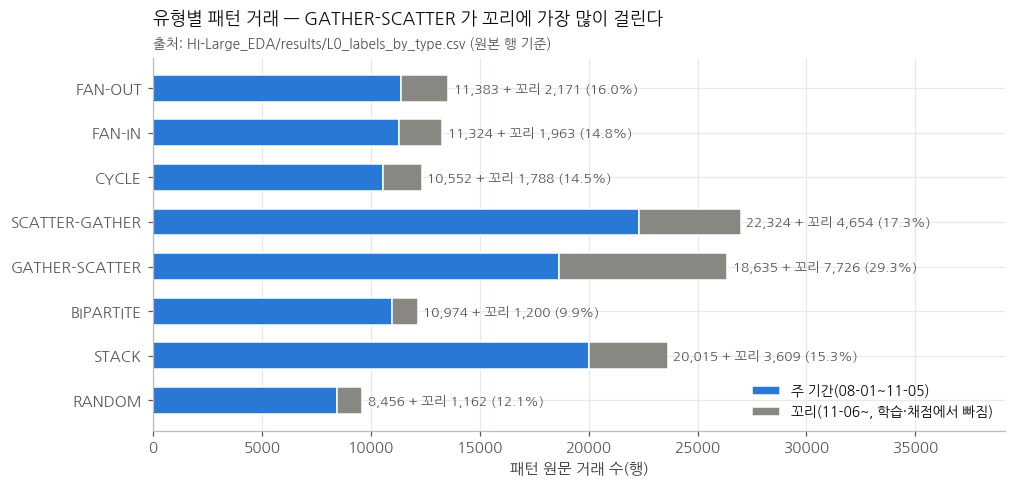

In [16]:
# 그림 2-1. 유형별 패턴 원문 거래 — 주 기간 vs 꼬리
fig, ax = plt.subplots(figsize=(10, 4.4))
y = np.arange(len(P8))[::-1]
ax.barh(y, P8['주 기간'], color=C_PAT, height=0.6, edgecolor='white', linewidth=1, label='주 기간(08-01~11-05)')
ax.barh(y, P8['꼬리(제외)'], left=P8['주 기간'], color=C_NORM, height=0.6, edgecolor='white', linewidth=1, label='꼬리(11-06~, 학습·채점에서 빠짐)')
for yi, (t, r) in zip(y, P8.iterrows()):
    ax.text(r['합계'] + 250, yi, f"{int(r['주 기간']):,} + 꼬리 {int(r['꼬리(제외)']):,} ({r['꼬리 비율_pct']:.1f}%)", va='center', fontsize=8.8, color=INK2)
ax.set_yticks(y); ax.set_yticklabels(CLASS_NAMES); ax.set_xlabel('패턴 원문 거래 수(행)'); ax.set_xlim(0, P8['합계'].max() * 1.45)
ax.legend(frameon=False, fontsize=9, loc='lower right')
title(ax, '유형별 패턴 거래 — GATHER-SCATTER 가 꼬리에 가장 많이 걸린다', '출처: HI-Large_EDA/results/L0_labels_by_type.csv (원본 행 기준)')
savefig(fig, 'S2_1_유형별_주기간_꼬리.png')

**해석**
- **세탁 225,546 = 패턴 137,936 + 패턴 밖 87,610.** 패턴 원문 137,936 거래가 모두 원본 세탁 행에 하나씩 맞았다(키 중복 0, 모르는 패턴명 0).
- 주 기간 세탁은 201,273 = 패턴 113,663 + 패턴 밖 87,610 이다. **패턴 밖은 꼬리에 0** 이고, 꼬리 세탁 24,273 은 모두 패턴이다.
- 꼬리를 자르면 세탁 기준 10.76%, 패턴 행 기준 17.60% 가 빠진다. 두 분모를 섞으면 안 된다(부록 C 정정 2). GATHER-SCATTER 는 29% 가 꼬리에 있다.
- 옛 내 라벨과 태훈님 `pattern_labels` 는 주 기간 전 기간에서 다른 행이 0 이다(fix [G]). 라벨 병합(09-29)은 이 위에서 패턴 밖 87,610 을 정상 클래스로 합친 것이다.

### 2-2. 시도 수 · 길이 · 꼬리 걸침 [가벼움 · 실행]
패턴 원문(13.8 MB)만 읽는다. 두 코드를 그대로 다시 돌린다.
1. `feat_final_20260915/m9_pattern_speed.py`(09-16) — 시도별 거래 수·지속·간격과 창 후보별 포함률. 쓰기 경로 `OUT` 은 이 노트북 `out/` 이다(원래는 feat_final 폴더).
2. `notebooks/13_V1_세탁사건_지속시간.ipynb`(09-18) cell 3 · 4 · 6 · 8 · 11 · 12 · 14 — 두 분모·두 기준으로 다시 잰 것. cell 18(결과 저장)은 옮기지 않고, 대신 저장된 V1 표와 같은지 대조한다.

**분모 두 가지를 꼭 구분한다**: (가) 전체 시도 16,467(1건짜리 포함) / (나) 다건 시도 14,345. 1건짜리 시도는 지속이 0분이라 분모에 따라 답이 크게 다르다.

In [17]:
# 원본: feat_final_20260915/m9_pattern_speed.py:17 · :25-26 · :28-59 · :74-87 (글자 그대로. 쓰기 OUT = 이 노트북 out/)
SRC = PAT_TXT
from datetime import datetime
BEGIN = re.compile(r'BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Z\-]+)')
END = re.compile(r'END LAUNDERING ATTEMPT')

attempts, cur, cur_type = [], None, None
for line in SRC.read_text(errors='replace').splitlines():
    s = line.strip()
    if not s:
        continue
    m = BEGIN.search(s)
    if m:
        cur_type, cur = m.group(1), []
        continue
    if END.search(s):
        if cur is not None and cur:
            attempts.append((cur_type, cur))
        cur, cur_type = None, None
        continue
    if cur is not None:
        ts = s.split(',', 1)[0]
        try:
            cur.append(datetime.strptime(ts, '%Y/%m/%d %H:%M'))
        except ValueError:
            pass   # 거래 행이 아닌 줄

print(f'시도 {len(attempts):,}개 · 거래 {sum(len(t) for _, t in attempts):,}건')

rows = []
for typ, ts in attempts:
    t = np.sort(np.array([x.timestamp() / 60.0 for x in ts]))      # 분 단위
    gaps = np.diff(t)
    rows.append(dict(유형=typ, 거래수=len(t), 지속분=float(t[-1] - t[0]),
                     간격중앙값분=float(np.median(gaps)) if len(gaps) else np.nan,
                     간격최소분=float(gaps.min()) if len(gaps) else np.nan))
A = pd.DataFrame(rows)
A.to_csv(OUT / 'm9_attempt_speed.csv', index=False)

# 창 후보별: 시도 전체가 그 창 안에 들어가는 비율
W = [3, 10, 30, 60, 180, 360, 720, 1440, 4320, 10080, 43200]
fit = []
for w in W:
    fit.append(dict(창분=w, 창표기=f'{w}분' if w < 60 else (f'{w // 60}시간' if w < 1440 else f'{w // 1440}일'),
                    시도포함률=float((A['지속분'] <= w).mean()),
                    거래가중포함률=float(A.loc[A['지속분'] <= w, '거래수'].sum() / A['거래수'].sum()),
                    간격포함률=float((A['간격중앙값분'] <= w).mean())))
F = pd.DataFrame(fit)
F.to_csv(OUT / 'm9_window_fit.csv', index=False)
print('\n■ 창 후보별 — 시도 전체가 그 창 안에 들어가는 비율 / 연속 거래 간격 중앙값이 그 안인 비율')
print(F.assign(시도포함률=lambda x: (x.시도포함률 * 100).round(2),
               거래가중포함률=lambda x: (x.거래가중포함률 * 100).round(2),
               간격포함률=lambda x: (x.간격포함률 * 100).round(2)).to_string(index=False))

# (통합본) 저장값과 대조
m_new, m_old = pd.read_csv(OUT / 'm9_attempt_speed.csv'), rd(M9 / 'm9_attempt_speed.csv')
ok1 = (m_new.shape == m_old.shape and (m_new['유형'] == m_old['유형']).all()
       and maxdiff(m_new[['거래수', '지속분', '간격중앙값분', '간격최소분']], m_old[['거래수', '지속분', '간격중앙값분', '간격최소분']]) < 1e-6)
f_new, f_old = pd.read_csv(OUT / 'm9_window_fit.csv'), rd(M9 / 'm9_window_fit.csv')
ok2 = maxdiff(f_new[['시도포함률', '거래가중포함률', '간격포함률']], f_old[['시도포함률', '거래가중포함률', '간격포함률']]) < 1e-12
print('m9 다시 계산 = 저장값:', ok1, ok2); assert ok1 and ok2

시도 16,467개 · 거래 137,936건



■ 창 후보별 — 시도 전체가 그 창 안에 들어가는 비율 / 연속 거래 간격 중앙값이 그 안인 비율
   창분  창표기  시도포함률  거래가중포함률  간격포함률
    3   3분  12.91     1.54   0.02
   10  10분  12.94     1.55   0.05
   30  30분  13.00     1.57   0.12
   60  1시간  13.13     1.60   0.24
  180  3시간  13.57     1.70   0.70
  360  6시간  14.13     1.83   1.29
  720 12시간  14.98     2.04   2.49
 1440   1일  15.93     2.27  11.26
 4320   3일  17.33     2.62  47.38
10080   7일  20.23     3.46  67.29
43200  30일  57.67    31.15  85.81
읽음: /workspace/feat_final_20260915/m9_attempt_speed.csv  (510,955 B · 16,467행)
읽음: /workspace/feat_final_20260915/m9_window_fit.csv  (855 B · 11행)
m9 다시 계산 = 저장값: True True


In [18]:
# 원본: notebooks/13_V1_세탁사건_지속시간.ipynb cell 1 의 14-17줄(상수)과 30-36줄(drop_cache)을 글자 그대로 옮김.
# 뺀 줄: 1-13(import·경로 — 이 노트북의 OUT·WORK·SRC 를 씀) · 18-29(anon_gib — 설정 셀에 같은 정의가 있음, PEAK 갱신만 없음)
#        · 37-43(eda_common 상수 대조 assert·print). 원래 주석의 '맨 위 표'는 V1 노트북 머리말의 표다.
THR = [('≤60분(1시간)', 60), ('≤1일', 1440), ('≤7일', 10080), ('≤30일', 43200)]              # 출처는 맨 위 표
QS = [5, 10, 25, 50, 75, 90, 95]
DRY = int(os.environ.get('V1_DRY', '0'))       # 0 = 전량. >0 이면 6번(원본 행 라벨 대조)만 앞 DRY 행으로 점검
PEAK = [0.0]


def drop_cache(path):
    """읽은 파일의 페이지 캐시를 비운다(캐시도 cgroup 한도에 잡힘 — 08 셀 2 와 같은 처리)."""
    fd = os.open(str(path), os.O_RDONLY)
    try:
        os.posix_fadvise(fd, 0, 0, os.POSIX_FADV_DONTNEED)
    finally:
        os.close(fd)

In [19]:
# 원본: 13_V1 cell 3 (바꾼 곳: L0_labels.json 읽기 경로 OUT → RES)
# 원문(13.8MB) 한 번 읽어 줄 단위로 분류
lines = pd.Series(SRC.read_text(encoding='utf-8').splitlines())
begin = lines.str.startswith('BEGIN LAUNDERING ATTEMPT')
end_ = lines.str.startswith('END LAUNDERING ATTEMPT')
inside = (begin.cumsum() > end_.cumsum()) & ~begin
is_tx = inside & (lines.str.count(',') == 10)
hdr = lines.str.extract(r'^BEGIN LAUNDERING ATTEMPT - (.+)$', expand=False).ffill()
ptype = hdr.str.extract(r'^([A-Z\-]+)', expand=False)

# 규칙이 놓친 줄이 없는지: 블록 안인데 거래가 아닌 줄, 블록 밖인데 비어 있지 않은 줄
odd_inside = int((inside & ~is_tx & (lines.str.strip() != '')).sum())
odd_outside = int((~inside & ~begin & ~end_ & (lines.str.strip() != '')).sum())
print(f'줄 {len(lines):,} · BEGIN {int(begin.sum()):,} · END {int(end_.sum()):,} · 거래 줄 {int(is_tx.sum()):,} · '
      f'블록 안 비거래 줄 {odd_inside} · 블록 밖 내용 줄 {odd_outside}')

ts_txt = lines[is_tx].str.split(',', n=1).str[0]
tx = pd.DataFrame({
    'attempt': (begin.cumsum()[is_tx] - 1).to_numpy(np.int32),
    'ptype': ptype[is_tx].str.strip().to_numpy(),
    # 시간대 영향이 없도록 datetime64[m] → 에폭 분(정수)
    'ts': pd.to_datetime(ts_txt, format='%Y/%m/%d %H:%M').to_numpy(dtype='datetime64[m]').astype(np.int64),
})
assert set(tx.ptype) == set(CLASS_NAMES), set(tx.ptype)
L0 = json.loads((RES / 'L0_labels.json').read_text())
print(f'거래 {len(tx):,}건 (L0_labels.json pattern_rows = {L0["pattern_rows"]:,} → 일치 {len(tx) == L0["pattern_rows"]}) · '
      f'시각 범위 {np.datetime64(int(tx.ts.min()), "m")} ~ {np.datetime64(int(tx.ts.max()), "m")}')
n_blocks = int(begin.sum())
del lines, begin, end_, inside, is_tx, hdr, ptype, ts_txt
gc.collect()
print(f'anon {anon_gib():.2f} GiB')

줄 187,337 · BEGIN 16,467 · END 16,467 · 거래 줄 137,936 · 블록 안 비거래 줄 0 · 블록 밖 내용 줄 0


거래 137,936건 (L0_labels.json pattern_rows = 137,936 → 일치 True) · 시각 범위 2022-08-01T00:08 ~ 2023-01-12T16:49
anon 4.73 GiB


In [20]:
# 원본: 13_V1 cell 4
# 시도별 표: 거래 수 · 첫 시각 · 끝 시각 · 지속(분) · 꼬리 거래 수
def attempt_table(t):
    g = t.groupby('attempt', sort=True)
    a = g.agg(유형=('ptype', 'first'), 거래수=('ts', 'size'), 첫시각=('ts', 'min'), 끝시각=('ts', 'max'))
    a['지속분'] = (a['끝시각'] - a['첫시각']).astype(np.int64)
    return a


A = attempt_table(tx)
A['꼬리거래수'] = tx.assign(tail=tx.ts >= TAIL_START).groupby('attempt')['tail'].sum().astype(np.int64)
assert A.groupby(level=0).size().max() == 1 and tx.groupby('attempt')['ptype'].nunique().max() == 1
n_all, n_single, n_multi = len(A), int((A.거래수 == 1).sum()), int((A.거래수 >= 2).sum())
print(f'BEGIN 블록 {n_blocks:,} · 거래가 1건 이상인 시도 {n_all:,} (빈 블록 {n_blocks - n_all})')
print(f'■ 전체 시도 {n_all:,} = 1건짜리 {n_single:,} + 다건(2건+) {n_multi:,}   · 거래 {int(A.거래수.sum()):,}건')
print(f'  시도당 거래 수: 최소 {A.거래수.min()} · 중앙값 {A.거래수.median():.0f} · 평균 {A.거래수.mean():.2f} · 최대 {A.거래수.max()}')
cnt_type = A.groupby('유형').agg(시도=('거래수', 'size'), 한건짜리=('거래수', lambda s: int((s == 1).sum())),
                               다건=('거래수', lambda s: int((s >= 2).sum())), 거래=('거래수', 'sum')).reindex(CLASS_NAMES)
print(cnt_type.to_string())
print(f'\n다건 시도 중 지속 0분(모든 거래가 같은 분): {int(((A.거래수 >= 2) & (A.지속분 == 0)).sum()):,}')

BEGIN 블록 16,467 · 거래가 1건 이상인 시도 16,467 (빈 블록 0)
■ 전체 시도 16,467 = 1건짜리 2,122 + 다건(2건+) 14,345   · 거래 137,936건
  시도당 거래 수: 최소 1 · 중앙값 6 · 평균 8.38 · 최대 32
                  시도  한건짜리    다건     거래
유형                                     
FAN-OUT         2040   416  1624  13554
FAN-IN          2014   405  1609  13287
CYCLE           2086     2  2084  12340
SCATTER-GATHER  2067     2  2065  26978
GATHER-SCATTER  2054     8  2046  26361
BIPARTITE       2109   680  1429  12174
STACK           2096     4  2092  23624
RANDOM          2001   605  1396   9618

다건 시도 중 지속 0분(모든 거래가 같은 분): 1


In [21]:
# 원본: 13_V1 cell 6
def thr_rows(a, basis):
    """임계별 (가) 전체 시도 / (나) 다건 시도 분모의 건수·비율."""
    rows = []
    multi = a[a.거래수 >= 2]
    for name, w in THR:
        for dn, d in (('(가) 전체 시도', a), ('(나) 다건 시도(2건+)', multi)):
            k = int((d.지속분 <= w).sum())
            rows.append(dict(구분='임계 이내 종결', 기준=basis, 항목=name, 분모정의=dn, 분자=k, 분모=len(d),
                             비율_pct=k / len(d) * 100, 값=w, 단위='분(임계)', 비고='지속분 <= 임계(경계 포함)'))
    return rows


S_thr = pd.DataFrame(thr_rows(A, '꼬리 포함(기본)'))
print('■ 꼬리 포함(사건의 실제 길이) 기준')
for name, w in THR:
    r = S_thr[S_thr.항목 == name].set_index('분모정의')
    a_, b_ = r.loc['(가) 전체 시도'], r.loc['(나) 다건 시도(2건+)']
    print(f'  {name:<12} (가) {int(a_.분자):>6,} / {int(a_.분모):,} = {a_.비율_pct:6.3f}%    '
          f'(나) {int(b_.분자):>6,} / {int(b_.분모):,} = {b_.비율_pct:6.3f}%')
k60_multi = int(((A.거래수 >= 2) & (A.지속분 <= 60)).sum())
print(f'\n(가)의 ≤60분 분자 {int((A.지속분 <= 60).sum()):,} = 1건짜리 {n_single:,} + 다건 {k60_multi:,}')
print(f'1000건당: (가) {int((A.지속분 <= 60).sum()) / n_all * 1000:.2f}건 · (나) {k60_multi / n_multi * 1000:.2f}건')
print(f'경계 민감도(분 해상도): 다건 시도 중 지속이 정확히 60분 {int(((A.거래수 >= 2) & (A.지속분 == 60)).sum()):,} · 1~59분 {int(((A.거래수 >= 2) & (A.지속분 > 0) & (A.지속분 < 60)).sum()):,} · 0분 {int(((A.거래수 >= 2) & (A.지속분 == 0)).sum()):,}')

■ 꼬리 포함(사건의 실제 길이) 기준
  ≤60분(1시간)    (가)  2,162 / 16,467 = 13.129%    (나)     40 / 14,345 =  0.279%
  ≤1일          (가)  2,623 / 16,467 = 15.929%    (나)    501 / 14,345 =  3.493%
  ≤7일          (가)  3,332 / 16,467 = 20.234%    (나)  1,210 / 14,345 =  8.435%
  ≤30일         (가)  9,496 / 16,467 = 57.667%    (나)  7,374 / 14,345 = 51.405%

(가)의 ≤60분 분자 2,162 = 1건짜리 2,122 + 다건 40
1000건당: (가) 131.29건 · (나) 2.79건
경계 민감도(분 해상도): 다건 시도 중 지속이 정확히 60분 0 · 1~59분 39 · 0분 1


In [22]:
# 원본: 13_V1 cell 8 (출력이 길다: 유형별 분위수 두 분모)
def qrow(v, **k):
    """분위수 한 줄(분·일)."""
    v = np.asarray(v, dtype=np.float64)
    d = dict(k, n=len(v))
    for q in QS:
        d[f'p{q}_분'] = float(np.percentile(v, q)) if len(v) else np.nan
    d['최대_분'] = float(v.max()) if len(v) else np.nan
    d['평균_분'] = float(v.mean()) if len(v) else np.nan
    for q in QS:
        d[f'p{q}_일'] = d[f'p{q}_분'] / 1440
    d['최대_일'] = d['최대_분'] / 1440
    return d


def gaps_of(t):
    """시도 안 이웃 거래 간격(분). 반환: 풀링 간격 표(attempt, 유형, gap)."""
    s = t.sort_values(['attempt', 'ts'], kind='stable')
    gap = s['ts'].diff().to_numpy(np.float64)
    same = (s['attempt'].to_numpy()[1:] == s['attempt'].to_numpy()[:-1])
    return pd.DataFrame({'attempt': s['attempt'].to_numpy()[1:][same], '유형': s['ptype'].to_numpy()[1:][same],
                         'gap': gap[1:][same]})


def by_type_table(a, t, basis):
    rows = []
    G = gaps_of(t)
    gmed = G.groupby('attempt').agg(유형=('유형', 'first'), med=('gap', 'median'))
    for typ in ['전체'] + CLASS_NAMES:
        aa = a if typ == '전체' else a[a.유형 == typ]
        for dn, d in (('(가) 전체 시도', aa), ('(나) 다건 시도(2건+)', aa[aa.거래수 >= 2])):
            r = qrow(d.지속분, 기준=basis, 지표='지속시간', 분모정의=dn, 유형=typ)
            for name, w in THR:
                r[f'{name}_건수'] = int((d.지속분 <= w).sum())
                r[f'{name}_pct'] = float((d.지속분 <= w).mean() * 100)
            rows.append(r)
        gg = G if typ == '전체' else G[G.유형 == typ]
        rows.append(qrow(gg.gap, 기준=basis, 지표='연속 거래 간격(풀링: 이웃 간격 전부)', 분모정의='다건 시도의 이웃 간격', 유형=typ))
        mm = gmed if typ == '전체' else gmed[gmed.유형 == typ]
        rows.append(qrow(mm.med, 기준=basis, 지표='시도별 간격 중앙값(m9 정의)', 분모정의='(나) 다건 시도(2건+)', 유형=typ))
    return pd.DataFrame(rows), G, gmed


def int_counts(df):
    """임계 건수 열을 정수(Int64)로 — 간격 행에는 값이 없어 결측으로 둔다."""
    for nm, _ in THR:
        df[f'{nm}_건수'] = df[f'{nm}_건수'].astype('Int64')
    return df


T_type, G, GMED = by_type_table(A, tx, '꼬리 포함(기본)')
T_type = int_counts(T_type)
assert len(G) == int((A.거래수 - 1).sum()) and len(GMED) == n_multi
pd.set_option('display.width', 250)
cols_d = ['유형', 'n'] + [f'p{q}_일' for q in QS] + ['최대_일']
cols_m = ['유형', 'n'] + [f'p{q}_분' for q in QS] + ['최대_분']
for dn in ('(가) 전체 시도', '(나) 다건 시도(2건+)'):
    sel = T_type[(T_type.지표 == '지속시간') & (T_type.분모정의 == dn)]
    print(f'■ 지속시간 분위수 — {dn} · 단위 일'); print(sel[cols_d].round(2).to_string(index=False))
    print(f'■ 지속시간 분위수 — {dn} · 단위 분'); print(sel[cols_m].round(1).to_string(index=False))
    tc = ['유형', 'n'] + [f'{nm}_{k}' for nm, _ in THR for k in ('건수', 'pct')]
    print(f'■ 임계 이내 종결 — {dn} · 유형별'); print(sel[tc].round(2).to_string(index=False)); print()

■ 지속시간 분위수 — (가) 전체 시도 · 단위 일
            유형     n  p5_일  p10_일  p25_일  p50_일  p75_일  p90_일  p95_일  최대_일
            전체 16467  0.00   0.00  11.59  27.29  33.45  37.12  59.77 70.45
       FAN-OUT  2040  0.00   0.00  11.35  29.13  33.13  34.39  34.73 35.01
        FAN-IN  2014  0.00   0.00  10.50  28.81  33.06  34.40  34.69 35.02
         CYCLE  2086  5.47  10.37  20.61  29.18  32.70  34.18  34.61 35.02
SCATTER-GATHER  2067  9.01  15.20  27.08  32.44  34.10  34.68  34.84 35.02
GATHER-SCATTER  2054  0.12   0.27  31.15  55.76  63.83  66.74  67.91 70.45
     BIPARTITE  2109  0.00   0.00   0.00  10.43  14.25  15.65  16.04 16.95
         STACK  2096  3.54   7.11  16.63  26.51  33.47  37.07  38.63 42.51
        RANDOM  2001  0.00   0.00   0.00  20.52  28.80  31.90  33.09 35.00
■ 지속시간 분위수 — (가) 전체 시도 · 단위 분
            유형     n    p5_분   p10_분   p25_분   p50_분   p75_분   p90_분   p95_분     최대_분
            전체 16467     0.0     0.0 16686.0 39301.0 48172.5 53459.2 86069.4 101452.0
       FAN-OUT  20

In [23]:
# 원본: 13_V1 cell 11 (m9 기존 수치와 대조)
M = pd.read_csv(M9 / 'm9_attempt_speed.csv')
F = pd.read_csv(M9 / 'm9_window_fit.csv').set_index('창분')
print(f'm9_attempt_speed.csv 행 {len(M):,} (1건짜리 {int((M.거래수 == 1).sum()):,} · 다건 {int((M.거래수 >= 2).sum()):,})')
# 시도 순서가 같으므로(둘 다 블록 순서) 행 단위로 직접 대조
same_order = len(M) == len(A) and (M.유형.to_numpy() == A.유형.to_numpy()).all() and (M.거래수.to_numpy() == A.거래수.to_numpy()).all()
dmax = float(np.abs(M.지속분.to_numpy() - A.지속분.to_numpy()).max()) if same_order else np.nan
gmax = float(np.abs(M.간격중앙값분.to_numpy()[A.거래수.to_numpy() >= 2] - GMED.med.to_numpy()).max()) if same_order else np.nan
print(f'행 단위 대조: 유형·거래수 순서 일치 {same_order} · 지속분 최대 차 {dmax} 분 · 간격중앙값 최대 차 {gmax} 분')

Mm = M[M.거래수 >= 2]
cmp_rows = []


def add(item, claim, new, m9val, note):
    ok = (abs(new - claim) <= 0.5 * 10 ** (-note_dec[item])) if claim is not None else None
    cmp_rows.append(dict(구분='m9 대조', 기준='꼬리 포함(기본)', 항목=item, 제안서_주장값=claim, 이번_실측=new, m9csv_재계산=m9val,
                         일치=ok, 비고=note))


note_dec = {'다건 시도 수': 0, '지속 중앙값(일) · 다건 분모': 1, '시도별 간격 중앙값의 중앙값(일) · 다건 분모': 1,
            '≤60분 비율(%) · 다건 분모': 2, '≤1일 비율(%) · 다건 분모': 2, '≤7일 비율(%) · 다건 분모': 1, '≤30일 비율(%) · 다건 분모': 1}
Am = A[A.거래수 >= 2]
add('다건 시도 수', 14345, n_multi, int(len(Mm)), '거래 2건 이상')
add('지속 중앙값(일) · 다건 분모', 29.6, float(np.median(Am.지속분)) / 1440, float(np.median(Mm.지속분)) / 1440, '주장값은 소수 1자리 반올림으로 비교')
add('시도별 간격 중앙값의 중앙값(일) · 다건 분모', 2.7, float(np.median(GMED.med)) / 1440, float(np.nanmedian(Mm.간격중앙값분)) / 1440,
    'm9 의 간격중앙값분(시도별)을 다시 중앙값')
for (name, w), claim, key in zip(THR, [0.28, 3.49, 8.4, 51.4],
                                 ['≤60분 비율(%) · 다건 분모', '≤1일 비율(%) · 다건 분모', '≤7일 비율(%) · 다건 분모', '≤30일 비율(%) · 다건 분모']):
    add(key, claim, float((Am.지속분 <= w).mean() * 100), float((Mm.지속분 <= w).mean() * 100),
        f'분자 {int((Am.지속분 <= w).sum()):,} / 분모 {len(Am):,}')
CMP = pd.DataFrame(cmp_rows)
print(CMP.drop(columns=['구분', '기준']).round(4).to_string(index=False))

m9_attempt_speed.csv 행 16,467 (1건짜리 2,122 · 다건 14,345)
행 단위 대조: 유형·거래수 순서 일치 True · 지속분 최대 차 0.0 분 · 간격중앙값 최대 차 0.0 분
                        항목  제안서_주장값      이번_실측  m9csv_재계산   일치                       비고
                   다건 시도 수 14345.00 14345.0000 14345.0000 True                 거래 2건 이상
         지속 중앙값(일) · 다건 분모    29.60    29.6500    29.6500 True     주장값은 소수 1자리 반올림으로 비교
시도별 간격 중앙값의 중앙값(일) · 다건 분모     2.70     2.7125     2.7125 True m9 의 간격중앙값분(시도별)을 다시 중앙값
        ≤60분 비율(%) · 다건 분모     0.28     0.2788     0.2788 True        분자 40 / 분모 14,345
         ≤1일 비율(%) · 다건 분모     3.49     3.4925     3.4925 True       분자 501 / 분모 14,345
         ≤7일 비율(%) · 다건 분모     8.40     8.4350     8.4350 True     분자 1,210 / 분모 14,345
        ≤30일 비율(%) · 다건 분모    51.40    51.4047    51.4047 True     분자 7,374 / 분모 14,345


In [24]:
# 원본: 13_V1 cell 12 (m9 의 0.131 과 0.28% 가 다른 이유 — 분모)
# m9_window_fit.csv 의 "1시간 시도포함률 0.131" 과 제안서의 "0.28%" 가 다른 이유 — 분모(와 그에 딸린 분자)
print('■ 같은 임계를 두 분모로: m9_window_fit.csv 값 / 이번 (가) / 이번 (나)')
for name, w in THR:
    k_all, k_multi = int((A.지속분 <= w).sum()), int(((A.거래수 >= 2) & (A.지속분 <= w)).sum())
    print(f'  {name:<12} m9 시도포함률 {F.loc[w, "시도포함률"]:.6f} | (가) {k_all:,}/{n_all:,} = {k_all / n_all:.6f} | '
          f'(나) {k_multi:,}/{n_multi:,} = {k_multi / n_multi:.6f}  → m9 값과 (가) 일치 {abs(F.loc[w, "시도포함률"] - k_all / n_all) < 1e-12}')
k_all60 = int((A.지속분 <= 60).sum())
print(f'\n0.131 = ({n_single:,} 1건짜리 + {k60_multi:,} 다건) / {n_all:,} = {k_all60 / n_all:.4f}  ·  0.28% = {k60_multi:,} / {n_multi:,} = {k60_multi / n_multi * 100:.3f}%')
print(f'(가) 분자 {k_all60:,} 중 1건짜리가 차지하는 몫: {n_single / k_all60 * 100:.2f}%')
# 제안서의 "간격 중앙값 기준 24시간 12.9% · 7일 77.2% · 30일 98.5%" 도 같은 분모 문제인지: m9 간격포함률은 전체 시도 분모(NaN <= w 는 False)
for name, w in THR[1:]:
    k = int((GMED.med <= w).sum())
    print(f'  시도별 간격 중앙값 {name}: {k:,}/{n_multi:,} = {k / n_multi * 100:.2f}% (다건 분모) · m9 간격포함률 {F.loc[w, "간격포함률"] * 100:.2f}% = {k:,}/{n_all:,} = {k / n_all * 100:.2f}% (전체 분모)')

■ 같은 임계를 두 분모로: m9_window_fit.csv 값 / 이번 (가) / 이번 (나)
  ≤60분(1시간)    m9 시도포함률 0.131293 | (가) 2,162/16,467 = 0.131293 | (나) 40/14,345 = 0.002788  → m9 값과 (가) 일치 True
  ≤1일          m9 시도포함률 0.159288 | (가) 2,623/16,467 = 0.159288 | (나) 501/14,345 = 0.034925  → m9 값과 (가) 일치 True
  ≤7일          m9 시도포함률 0.202344 | (가) 3,332/16,467 = 0.202344 | (나) 1,210/14,345 = 0.084350  → m9 값과 (가) 일치 True
  ≤30일         m9 시도포함률 0.576668 | (가) 9,496/16,467 = 0.576668 | (나) 7,374/14,345 = 0.514047  → m9 값과 (가) 일치 True

0.131 = (2,122 1건짜리 + 40 다건) / 16,467 = 0.1313  ·  0.28% = 40 / 14,345 = 0.279%
(가) 분자 2,162 중 1건짜리가 차지하는 몫: 98.15%
  시도별 간격 중앙값 ≤1일: 1,854/14,345 = 12.92% (다건 분모) · m9 간격포함률 11.26% = 1,854/16,467 = 11.26% (전체 분모)
  시도별 간격 중앙값 ≤7일: 11,080/14,345 = 77.24% (다건 분모) · m9 간격포함률 67.29% = 11,080/16,467 = 67.29% (전체 분모)
  시도별 간격 중앙값 ≤30일: 14,130/14,345 = 98.50% (다건 분모) · m9 간격포함률 85.81% = 14,130/16,467 = 85.81% (전체 분모)


In [25]:
# 원본: 13_V1 cell 14 (꼬리 포함 vs 주기간 절단)
tx_main = tx[tx.ts < TAIL_START]
A2 = attempt_table(tx_main)
n_all2, n_single2, n_multi2 = len(A2), int((A2.거래수 == 1).sum()), int((A2.거래수 >= 2).sum())
touch_tail = int((A.꼬리거래수 > 0).sum())
all_tail = int((A.꼬리거래수 == A.거래수).sum())
became_single = int(((A.거래수 >= 2) & (A.index.isin(A2.index[A2.거래수 == 1]))).sum())
print(f'꼬리 거래 {int((tx.ts >= TAIL_START).sum()):,}건 / {len(tx):,} (L0 표의 패턴 세탁 꼬리 24,273 · 주기간 113,663 과 대조) → 주기간 거래 {len(tx_main):,}건')
print(f'꼬리에 거래가 걸친 시도 {touch_tail:,} / {n_all:,} · 전부 꼬리인 시도 {all_tail:,} · 절단으로 다건→1건이 된 시도 {became_single:,}')
print(f'주기간 절단 후: 시도 {n_all2:,} = 1건짜리 {n_single2:,} + 다건 {n_multi2:,}')
S_thr2 = pd.DataFrame(thr_rows(A2, '주기간 절단'))
T_type2, G2, GMED2 = by_type_table(A2, tx_main, '주기간 절단')
T_type2 = int_counts(T_type2)
A2m = A2[A2.거래수 >= 2]
print('\n■ 꼬리 포함 → 주기간 절단')
print(f'  지속 중앙값(다건 분모): {np.median(Am.지속분) / 1440:.2f}일 → {np.median(A2m.지속분) / 1440:.2f}일 · '
      f'(전체 분모): {np.median(A.지속분) / 1440:.2f}일 → {np.median(A2.지속분) / 1440:.2f}일 · '
      f'최대: {A.지속분.max() / 1440:.1f}일 → {A2.지속분.max() / 1440:.1f}일')
for name, w in THR:
    a1, a2 = int((Am.지속분 <= w).sum()), int((A2m.지속분 <= w).sum())
    b1, b2 = int((A.지속분 <= w).sum()), int((A2.지속분 <= w).sum())
    print(f'  {name:<12} (나) {a1:,}/{n_multi:,} = {a1 / n_multi * 100:.2f}% → {a2:,}/{n_multi2:,} = {a2 / n_multi2 * 100:.2f}%   '
          f'(가) {b1:,}/{n_all:,} = {b1 / n_all * 100:.2f}% → {b2:,}/{n_all2:,} = {b2 / n_all2 * 100:.2f}%')

꼬리 거래 24,273건 / 137,936 (L0 표의 패턴 세탁 꼬리 24,273 · 주기간 113,663 과 대조) → 주기간 거래 113,663건
꼬리에 거래가 걸친 시도 4,290 / 16,467 · 전부 꼬리인 시도 204 · 절단으로 다건→1건이 된 시도 921
주기간 절단 후: 시도 16,263 = 1건짜리 2,971 + 다건 13,292



■ 꼬리 포함 → 주기간 절단
  지속 중앙값(다건 분모): 29.65일 → 24.07일 · (전체 분모): 27.29일 → 17.74일 · 최대: 70.5일 → 69.9일
  ≤60분(1시간)    (나) 40/14,345 = 0.28% → 42/13,292 = 0.32%   (가) 2,162/16,467 = 13.13% → 3,013/16,263 = 18.53%
  ≤1일          (나) 501/14,345 = 3.49% → 618/13,292 = 4.65%   (가) 2,623/16,467 = 15.93% → 3,589/16,263 = 22.07%
  ≤7일          (나) 1,210/14,345 = 8.43% → 1,950/13,292 = 14.67%   (가) 3,332/16,467 = 20.23% → 4,921/16,263 = 30.26%
  ≤30일         (나) 7,374/14,345 = 51.40% → 8,647/13,292 = 65.05%   (가) 9,496/16,467 = 57.67% → 11,618/16,263 = 71.44%


In [26]:
# (통합본) 다시 계산한 V1 유형별 표 = 저장된 V1_사건지속시간_유형별.csv 인가
TT_new = pd.concat([T_type, T_type2], ignore_index=True)
TT_old = rd(RES / 'V1_사건지속시간_유형별.csv')
key = ['기준', '지표', '분모정의', '유형']
num = [c for c in TT_old.columns if c not in key and pd.api.types.is_numeric_dtype(TT_old[c])]
mg = TT_new.merge(TT_old, on=key, suffixes=('', '_저장'))
dmax = max(maxdiff(mg[c].astype(float), mg[c + '_저장'].astype(float)) for c in num)
print(f'행 {len(TT_new)} / 저장 {len(TT_old)} / 맞춘 행 {len(mg)} · 수치 열 {len(num)}개 최대 차 {dmax:.2e}')
assert len(mg) == len(TT_old) == len(TT_new) and dmax < 1e-6
V1s = rd(RES / 'V1_사건지속시간_요약.csv')
tail_row = V1s[V1s.항목 == '꼬리에 거래가 걸친 시도'].iloc[0]
print(f"꼬리에 걸친 시도: 다시 계산 {touch_tail:,} / 저장 {int(tail_row.분자):,} of {int(tail_row.분모):,} = {tail_row.비율_pct:.2f}% · 그중 전부 꼬리(꼬리에서 시작) {all_tail:,}")
assert touch_tail == int(tail_row.분자)

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V1_사건지속시간_유형별.csv  (26,155 B · 72행)
행 72 / 저장 72 / 맞춘 행 72 · 수치 열 26개 최대 차 7.28e-12
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V1_사건지속시간_요약.csv  (6,843 B · 44행)
꼬리에 걸친 시도: 다시 계산 4,290 / 저장 4,290 of 16,467 = 26.05% · 그중 전부 꼬리(꼬리에서 시작) 204


아래 무거운 셀은 V1 cell 16 이다. 원본 행 라벨 배열(`_work/raw_*.npy`, 1.1 GB)을 조각으로 읽어 **패턴 밖 세탁에 시도 번호가 있는지** 센다(09-18 실행: 패턴 밖 87,610 중 시도 번호 있는 행 0). 기본은 꺼 두었다.

In [27]:
# [무거움 · 기본 꺼짐] 원본: notebooks/13_V1_세탁사건_지속시간.ipynb cell 16 (앞 셀의 tx · tx_main · n_blocks · drop_cache 를 씀)
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: 없음(읽기만 한다)
def _heavy_V1_raw():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    grp = np.load(WORK / 'raw_grp.npy', mmap_mode='r')
    att = np.load(WORK / 'raw_attempt.npy', mmap_mode='r')
    spl = np.load(WORK / 'raw_split.npy', mmap_mode='r')
    n_raw = len(grp) if not DRY else min(DRY, len(grp))
    assert len(grp) == len(att) == len(spl)
    STEP = 8_000_000
    c = dict(out_all=0, out_main=0, out_att=0, pat_all=0, pat_main=0, pat_noatt=0, normal_att=0)
    att_pat, main_pat = [], []
    for a0 in range(0, n_raw, STEP):
        e = min(a0 + STEP, n_raw)
        g, t, s = np.asarray(grp[a0:e]), np.asarray(att[a0:e]), np.asarray(spl[a0:e])
        o, p = g == 8, (g >= 0) & (g <= 7)
        c['out_all'] += int(o.sum()); c['out_main'] += int((o & (s >= 0)).sum()); c['out_att'] += int((o & (t >= 0)).sum())
        c['pat_all'] += int(p.sum()); c['pat_main'] += int((p & (s >= 0)).sum()); c['pat_noatt'] += int((p & (t < 0)).sum())
        c['normal_att'] += int(((g < 0) & (t >= 0)).sum())
        att_pat.append(t[p].copy()); main_pat.append((s[p] >= 0).copy())
        del g, t, s, o, p
    att_pat, main_pat = np.concatenate(att_pat), np.concatenate(main_pat)
    del grp, att, spl
    gc.collect()
    for f in ('raw_grp.npy', 'raw_attempt.npy', 'raw_split.npy'):
        drop_cache(WORK / f)
    print(f'원본 행 {n_raw:,} 조사{" (DRY)" if DRY else ""} · anon {anon_gib():.2f} GiB')
    print(f'■ 패턴 밖 세탁 행: 전체 {c["out_all"]:,} · 주기간·중복 제거 모집단(split>=0) {c["out_main"]:,} · 그중 시도 번호(attempt>=0)가 있는 행 {c["out_att"]:,}')
    print(f'■ 패턴 세탁 행: 전체 {c["pat_all"]:,} · 모집단 {c["pat_main"]:,} · 시도 번호 없는 행 {c["pat_noatt"]:,} · 정상인데 시도 번호 있는 행 {c["normal_att"]:,}')
    if not DRY:
        # 원본 행의 시도별 행 수 = 원문 파싱의 시도별 거래 수 인가 (시도 번호 체계가 같은지 포함)
        cnt_raw = np.bincount(att_pat, minlength=n_blocks)
        cnt_txt = np.bincount(tx.attempt.to_numpy(), minlength=n_blocks)
        cnt_raw_main = np.bincount(att_pat[main_pat], minlength=n_blocks)
        cnt_txt_main = np.bincount(tx_main.attempt.to_numpy(), minlength=n_blocks)
        print(f'시도별 행 수 대조(원본 행 라벨 vs 원문): 전체 일치 {bool((cnt_raw == cnt_txt).all())} · '
              f'주기간(split>=0 vs 원문 ts<꼬리 시작) 일치 {bool((cnt_raw_main == cnt_txt_main).all())} · '
              f'모집단에 행이 있는 시도 {int((cnt_raw_main > 0).sum()):,}')


if HEAVY['V1_raw']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_V1_raw()
else:
    print("HEAVY['V1_raw'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['V1_raw'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V1_사건지속시간_유형별.csv  (26,155 B · 72행)


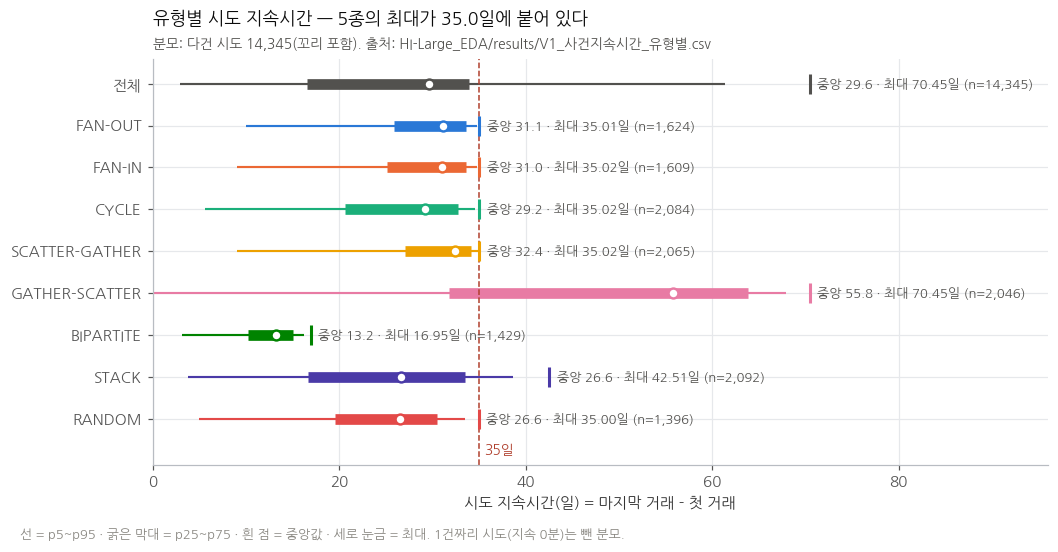

In [28]:
# 그림 2-2. 유형별 시도 지속시간 분포(다건 시도, 꼬리 포함) — 선 = p5~p95, 굵은 막대 = p25~p75, 흰 점 = 중앙값, 세로 눈금 = 최대
V1t = rd(RES / 'V1_사건지속시간_유형별.csv')
dd = V1t[(V1t.기준 == '꼬리 포함(기본)') & (V1t.지표 == '지속시간') & (V1t.분모정의 == '(나) 다건 시도(2건+)')].set_index('유형').loc[['전체'] + CLASS_NAMES]
fig, ax = plt.subplots(figsize=(10.5, 4.8)); y = np.arange(len(dd))[::-1]
for yi, (t, r) in zip(y, dd.iterrows()):
    c = INK2 if t == '전체' else C_TYPE[t]
    ax.hlines(yi, r['p5_일'], r['p95_일'], color=c, lw=1.4)
    ax.hlines(yi, r['p25_일'], r['p75_일'], color=c, lw=7)
    ax.scatter(r['p50_일'], yi, s=42, color='white', edgecolor=c, linewidth=1.6, zorder=3)
    ax.scatter(r['최대_일'], yi, marker='|', s=160, color=c, zorder=3)
    ax.text(r['최대_일'] + 0.8, yi, f"중앙 {r['p50_일']:.1f} · 최대 {r['최대_일']:.2f}일 (n={int(r['n']):,})", va='center', fontsize=8.5, color=INK2)
ax.axvline(35, color=REF, lw=1, ls='--'); ax.text(35.5, -0.75, '35일', color=REF, fontsize=9, ha='left', va='center')
ax.set_yticks(y); ax.set_yticklabels(dd.index); ax.set_xlim(0, 96); ax.set_ylim(-1.1, len(dd) - 0.4); ax.set_xlabel('시도 지속시간(일) = 마지막 거래 - 첫 거래')
fig.text(0.01, -0.03, '선 = p5~p95 · 굵은 막대 = p25~p75 · 흰 점 = 중앙값 · 세로 눈금 = 최대. 1건짜리 시도(지속 0분)는 뺀 분모.', fontsize=8.5, color=MUTED)
title(ax, '유형별 시도 지속시간 — 5종의 최대가 35.0일에 붙어 있다', '분모: 다건 시도 14,345(꼬리 포함). 출처: HI-Large_EDA/results/V1_사건지속시간_유형별.csv')
savefig(fig, 'S2_2_유형별_지속시간.png')

그림 2-3 은 `notebooks/12_추가피처_근거_시각화.ipynb` cell 3 **왼쪽 패널** 코드를 옮긴 것이다(한 칸으로 줄이고 제목만 바꿈).

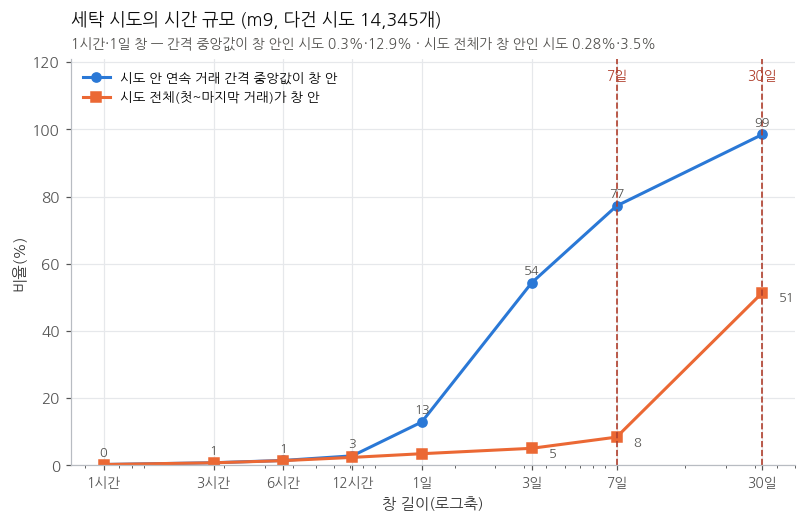

In [29]:
# 원본: notebooks/12 cell 3 왼쪽 패널(m9 기반). 바꾼 곳: FF → M9, 한 칸 그림, 창 이름표 높이, 제목·저장.
A = pd.read_csv(M9 / 'm9_attempt_speed.csv')
A = A[A['거래수'] >= 2]                                   # 1건짜리 시도는 어떤 창에도 자동 포함되므로 뺀다(09-16 기준과 동일)
W = [60, 180, 360, 720, 1440, 4320, 10080, 43200]
lab = {60: '1시간', 180: '3시간', 360: '6시간', 720: '12시간', 1440: '1일', 4320: '3일', 10080: '7일', 43200: '30일'}
cov_all = [(A['지속분'] <= w).mean() * 100 for w in W]
cov_gap = [(A['간격중앙값분'] <= w).mean() * 100 for w in W]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(W, cov_gap, marker='o', ms=6, lw=2, color=SERIES[0], label='시도 안 연속 거래 간격 중앙값이 창 안')
ax.plot(W, cov_all, marker='s', ms=6, lw=2, color=SERIES[1], label='시도 전체(첫~마지막 거래)가 창 안')
for w_, t in ((10080, '7일'), (43200, '30일')):
    ax.axvline(w_, color=REF, lw=1.1, ls='--')
    ax.text(w_, 114, t, ha='center', va='bottom', fontsize=9, color=REF)
ax.set_xscale('log'); ax.set_xticks(W); ax.set_xticklabels([lab[w_] for w_ in W], fontsize=9); ax.set_ylim(0, 121)
ax.set_ylabel('비율(%)'); ax.set_xlabel('창 길이(로그축)')
for x_, y_ in zip(W, cov_gap):
    ax.text(x_, y_ + 2.5, f'{y_:.0f}', ha='center', fontsize=8.4, color=INK2)
for x_, y_ in zip(W[-3:], cov_all[-3:]):
    ax.text(x_ * 1.18, y_ - 1.5, f'{y_:.0f}', ha='left', va='center', fontsize=8.4, color=INK2)
ax.legend(frameon=False, fontsize=8.8, loc='upper left')
title(ax, f'세탁 시도의 시간 규모 (m9, 다건 시도 {len(A):,}개)',
      f'1시간·1일 창 — 간격 중앙값이 창 안인 시도 {cov_gap[0]:.1f}%·{cov_gap[4]:.1f}% · 시도 전체가 창 안인 시도 {cov_all[0]:.2f}%·{cov_all[4]:.1f}%')
savefig(fig, 'S2_3_창길이_m9.png')

**해석** (분모를 꼭 같이 적는다 — EDA 현황 §1-8)
- **시도 16,467 = 1건짜리 2,122(12.89%) + 다건 14,345.** 유형마다 시도가 2,001~2,109 개로 거의 같다.
- 지속 중앙값: 전체 시도 27.29일(분 단위) · 다건 29.65일 · 날짜 차 27일(A2b, 평균 24.03 · 최대 70) · 주기간 절단 뒤 전체 17.74 · 다건 24.07일.
- 1시간 안에 끝나는 시도는 **다건 40/14,345(0.28%)**, 전체 분모로는 2,162/16,467(13.13%)이다. 13% 의 98% 가 1건짜리다.
- 시도마다 연속 거래 간격의 **중앙값**을 구했을 때, 그 중앙값이 1일 이하인 시도가 **다건 시도 14,345 중 1,854(12.9%)** 다(거래 단위 비율이 아니다). m9 의 `간격포함률` 0.1126 은 같은 분자 1,854 를 전체 시도 16,467 로 나눈 값이다.
- **5종(FAN-OUT · FAN-IN · CYCLE · S-G · RANDOM)의 최대가 35.0일**에 붙어 있다. 생성기 상수로 보인다(해석). BIPARTITE 16.95 · STACK 42.51 · G-S 70.45일은 다르다.
- **꼬리에 걸친 시도 4,290(26.05%)** = 주 기간에 시작해 꼬리까지 이어진 4,086 + 꼬리에서 시작한 204. 절단으로 다건이 1건짜리가 된 시도가 921개다.
- 패턴 밖 세탁에는 시도 번호가 없다. 그래서 지속시간을 정의할 수 없다(V1 cell 16).

### 2-3. 분할 경계에 걸친 시도 (09-27, 유효)
원래 계산은 DuckDB 의 `edges.parquet` 와 `pattern_labels.parquet` 를 합친다. **꺼 두었다.**

In [30]:
# [무거움 · 기본 꺼짐] 원본: fix_20260927/code/fix_11_boundary.py:1-10 · :19-39
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: X.RES/A2 · A2b → OUT/…
def _heavy_A2():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    sys.path.insert(0, str(FIX / 'code'))   # (통합본) fix_lib 을 찾도록
    """fix_11_boundary.py — 표 2 · 표 2-1 의 바탕 파일을 다시 만든다(읽기 전용 조회, 1분 안팎). 09-27 에 일회성 조회로 만들었던 것을 스크립트로 남긴다(검증 W2 지적).
      results/A0_일별_행수_세탁_165일.csv   날짜별 거래 수 · 세탁 건수 · DB tx.split (DuckDB tx 표)
      results/A2_경계에_걸친_사건.csv       분할 경계마다 걸친 세탁 사건(패턴 attempt_id) 수와 앞뒤 거래 수
      results/A2b_사건_기간_통계.csv        사건 하나가 걸친 날짜 수(처음 거래 날짜 ~ 마지막 거래 날짜)의 평균 · 분위수 — 꼬리 포함 전체 사건 기준
    입력: /tmp/tree9_work/db_full/{daily.duckdb, pattern_labels.parquet, edges.parquet} (읽기만)"""
    import fix_lib as X                                    # 먼저(스레드 수)
    import numpy as np, pandas as pd
    import pyarrow.parquet as pq
    import duckdb
    from fix_lib import log
    pl = pd.read_parquet(X.DB_FULL / 'pattern_labels.parquet')
    need = set(pl.edge_id.tolist()); parts = []
    for b in pq.ParquetFile(X.DB_FULL / 'edges.parquet').iter_batches(batch_size=4_000_000, columns=['edge_id', 'day', 'y']):
        t = b.to_pandas(); parts.append(t[t.edge_id.isin(need)])
    pl = pl.merge(pd.concat(parts), on='edge_id', how='left'); assert pl.day.notna().all() and (pl.y == 1).all()
    pl['day'] = pd.to_datetime(pl.day)
    g = pl.groupby('attempt_id').agg(first=('day', 'min'), last=('day', 'max'), n=('edge_id', 'size'))
    rows = []
    for name, cut in (('09-27|09-28 (train|val)', '2022-09-28'), ('10-14|10-15 (val|test)', '2022-10-15'), ('10-31|11-01 (지금까지 쓴 끝)', '2022-11-01'), ('11-05|11-06 (주 기간의 끝)', '2022-11-06')):
        ct = pd.Timestamp(cut); sp = g[(g['first'] < ct) & (g['last'] >= ct)]; x = pl[pl.attempt_id.isin(sp.index)]
        rows.append(dict(경계=name, 걸친_사건=len(sp), 걸친_사건의_거래=int(sp.n.sum()), 경계_앞_거래=int((x.day < ct).sum()), 경계_뒤_거래=int((x.day >= ct).sum()),
                         전체_사건=len(g), 경계_앞에서_시작한_사건=int((g['first'] < ct).sum())))
    pd.DataFrame(rows).to_csv(OUT / 'A2_경계에_걸친_사건.csv', index=False, encoding='utf-8-sig')
    span = (g['last'] - g['first']).dt.days
    tail0 = pd.Timestamp('2022-11-06')
    st = [dict(기준='전체 사건(꼬리 포함)', 사건=len(g), 평균_일=float(span.mean()), p25_일=float(span.quantile(.25)), 중앙값_일=float(span.median()), p75_일=float(span.quantile(.75)), 최대_일=int(span.max()),
               꼬리에서_시작한_사건=int((g['first'] >= tail0).sum()), 주기간에_시작해_꼬리에서_끝난_사건=int(((g['first'] < tail0) & (g['last'] >= tail0)).sum()),
               꼬리_세탁_거래=int((pl.day >= tail0).sum()), 그중_주기간에_시작한_사건의_거래=int((pl[pl.attempt_id.isin(g[g['first'] < tail0].index)].day >= tail0).sum()))]
    pd.DataFrame(st).to_csv(OUT / 'A2b_사건_기간_통계.csv', index=False, encoding='utf-8-sig')
    print(pd.DataFrame(rows).to_string()); print(pd.DataFrame(st).T.to_string())
    print('DONE', flush=True)


if HEAVY['A2']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_A2()
else:
    print("HEAVY['A2'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['A2'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [31]:
display(rd(FRES / 'A2_경계에_걸친_사건.csv'))
display(rd(FRES / 'A2b_사건_기간_통계.csv'))

읽음: /workspace/Final_preprocess/fix_20260927/results/A2_경계에_걸친_사건.csv  (385 B · 4행)


,경계,걸친_사건,걸친_사건의_거래,경계_앞_거래,경계_뒤_거래,전체_사건,경계_앞에서_시작한_사건
0,09-27|09-28 (train|val),4024,46833,23191,23642,16467,9611
1,10-14|10-15 (val|test),4101,49049,24940,24109,16467,12536
2,10-31|11-01 (지금까지 쓴 끝),4107,48909,25484,23425,16467,15416
3,11-05|11-06 (주 기간의 끝),4086,48808,25403,23405,16467,16263


읽음: /workspace/Final_preprocess/fix_20260927/results/A2b_사건_기간_통계.csv  (310 B · 1행)


,기준,사건,평균_일,p25_일,중앙값_일,p75_일,최대_일,꼬리에서_시작한_사건,주기간에_시작해_꼬리에서_끝난_사건,꼬리_세탁_거래,그중_주기간에_시작한_사건의_거래
0,전체 사건(꼬리 포함),16467,24.034797,12.0,27.0,33.0,70,204,4086,24273,23405


**해석**
- 분할 경계마다 시도 **4,024 ~ 4,107개**가 걸친다. 걸친 시도의 거래는 경계마다 약 4.7만~4.9만 건이고, 앞뒤로 거의 반씩 나뉜다.
- 전체 시도의 약 4분의 1이 경계 하나에 걸친다. 날짜로 자르는 분할에서는 **시도가 train 과 val·test 에 함께 나오는 것이 정상**이다. 그 결과가 §7 의 M1(test 패턴 행의 25.7% 가 train 에서 본 시도)이다.
- 시도를 통째로 한쪽에 몰면 미래 거래를 앞 구간에 넣는 누수가 된다. 그래서 자르지 않고, 겹침을 따로 재서 보고한다.

### 2-4. 시도 안 구조 — BIPARTITE · STACK 은 계좌로 이어지지 않는다 [가벼움 · 실행]
원본은 `/workspace/pattern_struct_by_set.py`(08-31)이다. 원래 Small·Medium·Large 를 같이 돌렸지만 **HI-Large 만** 부른다. 원래의 쓰기(:57)는 옮기지 않았다.

In [32]:
# 원본: /workspace/pattern_struct_by_set.py:7-47 (parse · components · summarize, 글자 그대로)
def parse(path):
    cur, rows = None, []
    with open(path, encoding='utf8', errors='replace') as f:
        for ln in f:
            if ln.startswith('BEGIN LAUNDERING ATTEMPT'):
                cur = {'cls': ln.split('-', 1)[1].split(':')[0].strip(), 'tx': []}
            elif ln.startswith('END LAUNDERING ATTEMPT'):
                if cur and cur['tx']: rows.append(cur)
                cur = None
            elif cur is not None and ',' in ln:
                p = ln.rstrip('\n').split(',')
                if len(p) >= 11:
                    cur['tx'].append((p[0], (p[1], p[2]), (p[3], p[4])))
    return rows

def components(tx):
    """계좌를 공유하면 같은 조각. union-find."""
    par = {}
    def find(a):
        while par.setdefault(a, a) != a: par[a] = par[par[a]]; a = par[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: par[ra] = rb
    for _, s, d in tx: union(s, d)
    return len({find(s) for _, s, _ in tx} | {find(d) for _, _, d in tx})

def summarize(name, path):
    att = parse(path)
    out = []
    for cls, g in itertools.groupby(sorted(att, key=lambda a: a['cls']), key=lambda a: a['cls']):
        g = list(g)
        frag = [components(a['tx']) for a in g]
        ntx  = [len(a['tx']) for a in g]
        closed = [1 if a['tx'][0][1] == a['tx'][-1][2] else 0 for a in g]   # 시작계좌 == 끝계좌?
        out.append({'세트': name, '클래스': cls, '시도': len(g),
                    '평균거래': round(sum(ntx)/len(g), 1),
                    '평균조각(계좌공유)': round(sum(frag)/len(g), 2),
                    '한덩어리비율': round(sum(f == 1 for f in frag)/len(g), 3),
                    '닫힘(시작=끝)': round(sum(closed)/len(g), 3)})
    return pd.DataFrame(out)


# (통합본) HI-Large 만 부르고 저장값(model_blocks/pattern_structure_by_set.csv 의 HI-Large 행)과 대조
PSx = summarize('HI-Large', PAT_TXT)
PSo = rd('/workspace/model_blocks/pattern_structure_by_set.csv').query("세트 == 'HI-Large'")
mg = PSx.merge(PSo, on=['세트', '클래스'], suffixes=('', '_저장'))
cols = ['시도', '평균거래', '평균조각(계좌공유)', '한덩어리비율', '닫힘(시작=끝)']
d_ = max(maxdiff(mg[c], mg[c + '_저장']) for c in cols)
display(PSx.set_index('클래스').loc[CLASS_NAMES])
print(f'저장값과 최대 차 {d_}'); assert len(mg) == 8 and d_ < 1e-9

읽음: /workspace/model_blocks/pattern_structure_by_set.csv  (1,081 B · 24행)


,세트,시도,평균거래,평균조각(계좌공유),한덩어리비율,닫힘(시작=끝)
클래스,,,,,,
FAN-OUT,HI-Large,2040,6.6,1.00,0.999,0.000
FAN-IN,HI-Large,2014,6.6,1.00,1.000,0.000
CYCLE,HI-Large,2086,5.9,1.00,1.000,0.999
SCATTER-GATHER,HI-Large,2067,13.1,1.00,1.000,0.300
GATHER-SCATTER,HI-Large,2054,12.8,1.00,0.999,0.142
BIPARTITE,HI-Large,2109,5.8,5.77,0.322,0.000
STACK,HI-Large,2096,11.3,5.51,0.361,0.254
RANDOM,HI-Large,2001,4.8,1.00,1.000,0.000


저장값과 최대 차 0.0


**해석**
- 평균 조각 수(시도 안에서 계좌 공유로 이은 덩어리 수)가 BIPARTITE 5.77 · STACK 5.51 이다. 나머지 6종은 1.0 이다. 한 덩어리 비율은 BIPARTITE 0.322 · STACK 0.361 이다.
- 그래서 이 두 유형은 **계좌 그래프 연결로 사건을 묶을 수 없다.** 시도 번호가 없는 운영 상황에서 사건을 구성할 때 막히는 곳이다.
- CYCLE 은 거의 다 닫혀 있다(시작 = 끝 계좌 0.999). RANDOM 은 닫히지 않는다(0.0). 두 유형을 구조로 가르는 근거다.
- 08-31 보고서의 "출발∩도착 0 · 최대 차수 1.0"을 만든 코드는 찾지 못했다(인용하지 않음).

## §3 계좌 · 은행 · KYC · 허브

**질문**: 계좌는 몇 개이고 활동량은 어떻게 퍼져 있나? 거래를 지배하는 허브는 무엇인가? 여러 통화를 쓰는 계좌, 소유주 유형, 국가, 같은 은행 거래는 세탁과 관련이 있나?

원래 계산(`step2_accounts.py`, 09-17)은 interim 90파트를 한 번 훑어 계좌별 누적을 만든다. **꺼 두었다.**

In [33]:
# [무거움 · 기본 꺼짐] 원본: HI-Large_EDA/step2_accounts.py:2-114
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: C.log( → log_h( (out/run.log); C.save_csv( → save_csv_h( (out/); account_stats.parquet → if SAVE_BIG: OUT
def _heavy_step2():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    """2단계 — 계좌 단위: B3 활동량 분포·상위 계좌 · A3 허브 대조표 · B4 다통화 계좌.

    범위: 전처리 대상 행(주 기간, 중복 제거 후, split 0/1/2). 계좌는 원본 키(은행 문자열_계좌) 기준이며,
    bank0 정규화 키로도 같은 결과인지 함께 적는다(09-17 측정: 두 표기로 갈린 계좌 0).
    A3 우리 허브 15개 = ego_type_9class.py:72 규칙(전처리 결과 전 기간 송신+수신 건수 상위 15).
    판정은 하지 않는다 — 대조표만.
    """
    import json

    import numpy as np
    import pandas as pd

    import eda_common as C

    log_h('2단계 시작')
    ps, starts = C.part_starts()
    grp, att, sp = C.load_labels()
    fmt_v, pay_v = C.vocab('fmt'), C.vocab('pay')
    nt = C.node_table()
    K = len(nt)
    out_n = np.zeros(K, np.int64); in_n = np.zeros(K, np.int64)
    out_pat = np.zeros(K, np.int64); in_pat = np.zeros(K, np.int64)
    out_oop = np.zeros(K, np.int64); in_oop = np.zeros(K, np.int64)
    fmt_mix = np.zeros((K, len(fmt_v)), np.int32)              # 송신+수신 결제수단 구성
    pair_keys, cur_keys = [], []
    for i, f in enumerate(ps):
        t = pd.read_parquet(f, columns=['src_id', 'dst_id', 'fmt_code', 'pay_code'])
        lo, hi = starts[i], starts[i + 1]
        keep = np.asarray(sp[lo:hi]) >= 0
        g3 = C.grp3(np.asarray(grp[lo:hi]))[keep]
        s = t['src_id'].to_numpy()[keep].astype(np.int64)
        d = t['dst_id'].to_numpy()[keep].astype(np.int64)
        fc = t['fmt_code'].to_numpy()[keep].astype(np.int64)
        pc = t['pay_code'].to_numpy()[keep].astype(np.int64)
        out_n += np.bincount(s, minlength=K); in_n += np.bincount(d, minlength=K)
        out_pat += np.bincount(s[g3 == 0], minlength=K); in_pat += np.bincount(d[g3 == 0], minlength=K)
        out_oop += np.bincount(s[g3 == 8], minlength=K); in_oop += np.bincount(d[g3 == 8], minlength=K)
        fmt_mix += np.bincount(s * len(fmt_v) + fc, minlength=K * len(fmt_v)).reshape(K, -1).astype(np.int32)
        fmt_mix += np.bincount(d * len(fmt_v) + fc, minlength=K * len(fmt_v)).reshape(K, -1).astype(np.int32)
        pair_keys.append(np.unique(s * K + d))
        cur_keys.append(np.unique(s * len(pay_v) + pc))
        if i % 15 == 0:
            log_h(f'  파트 {i + 1}/{len(ps)} · anon {C.anon_gib():.1f} GiB')
    pk = np.unique(np.concatenate(pair_keys)); del pair_keys
    uniq_out = np.bincount(pk // K, minlength=K)
    uniq_in = np.bincount(pk % K, minlength=K)
    recip = np.isin(pk, (pk % K) * K + pk // K)                  # 역방향 쌍도 있는 쌍
    uniq_recip_out = np.bincount((pk // K)[recip], minlength=K)
    n_pairs = len(pk)
    del pk
    ck = np.unique(np.concatenate(cur_keys)); del cur_keys
    n_cur = np.bincount(ck // len(pay_v), minlength=K)
    log_h(f'쌍 {n_pairs:,} · anon {C.anon_gib():.1f} GiB')

    active = (out_n + in_n) > 0
    acct = pd.DataFrame({'key': nt['key'], 'bank_raw': nt['bank_raw'], 'bank0': nt['bank0'], 'account': nt['account'],
                         'bank_name': nt['bank_name'], 'entity_name': nt['entity_name'], 'entity_type': nt['entity_type'],
                         'out_n': out_n, 'in_n': in_n, 'uniq_out': uniq_out, 'uniq_in': uniq_in,
                         'uniq_out_reciprocal': uniq_recip_out, 'n_send_currencies': n_cur,
                         'out_pattern': out_pat, 'in_pattern': in_pat, 'out_oop': out_oop, 'in_oop': in_oop})[active]
    acct['total'] = acct.out_n + acct.in_n
    acct['laundering_any'] = (acct.out_pattern + acct.in_pattern + acct.out_oop + acct.in_oop) > 0
    if SAVE_BIG: acct.to_parquet(OUT / 'account_stats.parquet', index=False)   # (통합본) 84 MB — 기본 저장 안 함

    # B3 분포
    rows = []
    for col, nm in [('out_n', '송신 건수'), ('in_n', '수신 건수'), ('uniq_out', '고유 송신 상대'), ('uniq_in', '고유 수신 상대'),
                    ('total', '송신+수신 건수'), ('n_send_currencies', '송금 통화 종류 수')]:
        for sub, m in [('활동 계좌 전체', np.ones(len(acct), bool)), ('세탁 연루 계좌', acct.laundering_any.to_numpy()),
                       ('세탁 무관 계좌', ~acct.laundering_any.to_numpy())]:
            v = acct[col].to_numpy()[m]
            rows.append({'지표': nm, '계좌 집합': sub, '계좌 수': int(m.sum()), '0인 계좌 비율(%)': 100 * float(np.mean(v == 0)),
                         'p50': float(np.percentile(v, 50)), 'p90': float(np.percentile(v, 90)),
                         'p99': float(np.percentile(v, 99)), 'p99.9': float(np.percentile(v, 99.9)), '최대': int(v.max())})
    save_csv_h(pd.DataFrame(rows), 'B3_계좌_활동량_분포.csv')

    top = acct.sort_values('total', ascending=False).head(20).copy()
    fm = fmt_mix[top.index.to_numpy()]
    for j, nm in enumerate(fmt_v):
        top[f'결제수단 {nm}(%)'] = 100 * fm[:, j] / np.maximum(fm.sum(1), 1)
    save_csv_h(top.drop(columns=['laundering_any']), 'B3b_거래수_상위20_계좌.csv')

    # A3 우리 허브 15개(전처리 결과 기준 규칙 재현)
    idx = np.load(C.MAIN / 'index_full.npz')
    n_acc = json.loads((C.MAIN / 'features_meta.json').read_text())['split']['n_accounts']
    deg = np.bincount(idx['src_id'], minlength=n_acc) + np.bincount(idx['dst_id'], minlength=n_acc)
    hub_new = np.argsort(-deg)[:15]
    k2 = pd.read_parquet(C.ALIGN / 'new_new2key.parquet')
    hub_keys = k2.set_index('new_id').loc[hub_new, 'key'].tolist()
    hub = pd.DataFrame({'우리 허브 순위': range(1, 16), 'key': hub_keys, '전처리 결과 송신+수신': deg[hub_new]})
    top20 = acct.sort_values('total', ascending=False).head(20)[['key', 'total']].reset_index(drop=True)
    top20['B3 순위'] = range(1, 21)
    cmp_ = hub.merge(top20, on='key', how='outer').merge(
        acct[['key', 'bank_raw', 'account', 'bank_name', 'entity_name', 'out_n', 'in_n', 'uniq_out', 'uniq_in',
              'out_pattern', 'in_pattern', 'out_oop', 'in_oop']], on='key', how='left')
    cmp_['구분'] = np.select([cmp_['우리 허브 순위'].notna() & cmp_['B3 순위'].notna(), cmp_['우리 허브 순위'].notna()],
                           ['둘 다', '우리 허브에만'], 'B3 상위20에만')
    save_csv_h(cmp_.sort_values(['우리 허브 순위', 'B3 순위']), 'A3_허브_대조표.csv')
    bank_top = top.groupby(['bank_raw', 'bank_name'], dropna=False).size().reset_index(name='상위20 중 계좌 수')
    save_csv_h(bank_top, 'A3b_상위20_은행구성.csv')

    # B4 다통화 계좌
    acct['다통화(송금 2종+)'] = acct.n_send_currencies >= 2
    senders = acct[acct.out_n > 0]
    b4 = senders.groupby('다통화(송금 2종+)').agg(계좌수=('key', 'size'), 세탁연루계좌=('laundering_any', 'sum'),
                                               송신건수합=('out_n', 'sum')).reset_index()
    b4['세탁 연루율(%)'] = 100 * b4['세탁연루계좌'] / b4['계좌수']
    b4['계좌 비율(%)'] = 100 * b4['계좌수'] / b4['계좌수'].sum()
    save_csv_h(b4, 'B4_다통화계좌_세탁연루.csv')
    dist = senders.groupby('n_send_currencies').agg(계좌수=('key', 'size'), 세탁연루계좌=('laundering_any', 'sum')).reset_index()
    dist['세탁 연루율(%)'] = 100 * dist['세탁연루계좌'] / dist['계좌수']
    save_csv_h(dist, 'B4b_송금통화_종류수별.csv')
    log_h(f'2단계 완료 · 활동 계좌 {int(active.sum()):,} · 쌍 {n_pairs:,} · anon {C.anon_gib():.1f} GiB')


if HEAVY['step2']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_step2()
else:
    print("HEAVY['step2'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['step2'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


### 3-1. 활동량 분포와 허브 절벽 [가벼움 · 실행 + 저장 결과]
`_work/account_stats.parquet`(84 MB, 활동 계좌 2,116,163행)에서 `total`(송신+수신 건수) **한 열만** 읽어 순위 곡선을 그린다.

In [34]:
B3 = rd(RES / 'B3_계좌_활동량_분포.csv'); display(B3)
st = pd.read_parquet(WORK / 'account_stats.parquet', columns=['total'])['total'].to_numpy()
print(f'읽음: {WORK / "account_stats.parquet"} (total 열만) · 활동 계좌 {len(st):,}')
tot = np.sort(st)[::-1]; del st
assert len(tot) == int(B3.loc[(B3.지표 == '송신+수신 건수') & (B3['계좌 집합'] == '활동 계좌 전체'), '계좌 수'].iloc[0]) and tot[0] == int(B3.loc[(B3.지표 == '송신+수신 건수') & (B3['계좌 집합'] == '활동 계좌 전체'), '최대'].iloc[0])
print(f'송신+수신 상위: 1위 {tot[0]:,} · 15위 {tot[14]:,} · 16위 {tot[15]:,} → 15위/16위 = {tot[14] / tot[15]:.1f}배')
print(f'허브 15개의 송신+수신 합 {int(tot[:15].sum()):,} / 옛 모집단 {OLD_POP:,} = {100 * tot[:15].sum() / OLD_POP:.2f}% (허브끼리의 거래는 두 번 셈 — 근사)')
A3 = rd(RES / 'A3_허브_대조표.csv')
hubs = A3[A3['우리 허브 순위'].notna()]
display(A3[['우리 허브 순위', 'B3 순위', 'key', 'bank_name', 'entity_name', 'out_n', 'in_n', 'out_pattern', 'in_pattern', 'out_oop', 'in_oop', '구분']])
print(f"허브 15개: 은행 {hubs.bank_raw.astype(str).str.zfill(3).unique().tolist()} · 패턴 세탁 {int(hubs[['out_pattern', 'in_pattern']].sum().sum())} · 패턴 밖 세탁(송신+수신) {int(hubs[['out_oop', 'in_oop']].sum().sum()):,}")
display(rd(RES / 'A3b_상위20_은행구성.csv'))
print('■ 계좌쌍 · KYC 매칭 (원 계산의 기록 줄, HI-Large_EDA/run.log)')
for l in open(EDA / 'run.log', encoding='utf-8'):
    if '2단계 완료' in l or '계좌 파일에 없는 노드' in l:
        print('   ', l.rstrip())

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B3_계좌_활동량_분포.csv  (1,719 B · 18행)


,지표,계좌 집합,계좌 수,0인 계좌 비율(%),p50,p90,p99,p99.9,최대
0,송신 건수,활동 계좌 전체,2116163,1.886386,12.0,245.0,851.0,1516.000,6233962
1,송신 건수,세탁 연루 계좌,209079,0.581120,14.0,414.0,1179.0,2002.688,6233962
2,송신 건수,세탁 무관 계좌,1907084,2.029486,12.0,221.0,806.0,1412.000,3212
3,수신 건수,활동 계좌 전체,2116163,18.494747,15.0,261.0,460.0,623.000,31906
4,수신 건수,세탁 연루 계좌,209079,0.431416,50.0,303.0,497.0,649.000,31906
5,수신 건수,세탁 무관 계좌,1907084,20.475081,12.0,253.0,455.0,617.000,1364
6,고유 송신 상대,활동 계좌 전체,2116163,1.886386,2.0,7.0,39.0,50.000,55956
7,고유 송신 상대,세탁 연루 계좌,209079,0.581120,4.0,7.0,14.0,22.000,55956
8,고유 송신 상대,세탁 무관 계좌,1907084,2.029486,2.0,6.0,40.0,51.000,79
9,고유 수신 상대,활동 계좌 전체,2116163,18.494747,3.0,8.0,27.0,73.000,2304


읽음: /workspace/Final_preprocess/HI-Large_EDA/_work/account_stats.parquet (total 열만) · 활동 계좌 2,116,163
송신+수신 상위: 1위 6,265,868 · 15위 322,085 · 16위 3,988 → 15위/16위 = 80.8배
허브 15개의 송신+수신 합 17,225,924 / 옛 모집단 179,650,681 = 9.59% (허브끼리의 거래는 두 번 셈 — 근사)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A3_허브_대조표.csv  (2,907 B · 20행)


,우리 허브 순위,B3 순위,key,bank_name,entity_name,out_n,in_n,out_pattern,in_pattern,out_oop,in_oop,구분
0,1.0,1,070_100428660,National Bank of Indianapolis,Sole Proprietorship #136,6233962,31906,0,0,8841,7,둘 다
1,2.0,2,070_1004286A8,National Bank of Indianapolis,Sole Proprietorship #51981,3931462,20073,0,0,5660,3,둘 다
2,3.0,3,070_1004286F0,National Bank of Indianapolis,Corporation #95138,1207403,7164,0,0,1661,1,둘 다
3,4.0,4,070_1004289C0,National Bank of Indianapolis,Corporation #135412,769178,3981,0,0,1137,2,둘 다
4,5.0,5,070_100428858,National Bank of Indianapolis,Partnership #118218,592485,2968,0,0,872,1,둘 다
5,6.0,6,070_100428810,National Bank of Indianapolis,Corporation #115137,555522,2591,0,0,753,2,둘 다
6,7.0,7,070_1004287C8,National Bank of Indianapolis,Sole Proprietorship #110711,526263,2554,0,0,737,0,둘 다
7,8.0,8,070_1004288A0,National Bank of Indianapolis,Partnership #22408,508666,2727,0,0,763,0,둘 다
8,9.0,9,070_100428738,National Bank of Indianapolis,Partnership #18556,466909,2282,0,0,690,0,둘 다
9,10.0,10,070_100428978,National Bank of Indianapolis,Corporation #132542,460175,2305,0,0,675,0,둘 다


허브 15개: 은행 ['070'] · 패턴 세탁 0 · 패턴 밖 세탁(송신+수신) 24,316
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A3b_상위20_은행구성.csv  (155 B · 4행)


,bank_raw,bank_name,상위20 중 계좌 수
0,0,Hearthstone Bancorp,3
1,214,First Bank of Dallas,1
2,11,Bank of Miami,1
3,70,National Bank of Indianapolis,15


■ 계좌쌍 · KYC 매칭 (원 계산의 기록 줄, HI-Large_EDA/run.log)
    [07:14:31Z +  133.1s] 2단계 완료 · 활동 계좌 2,116,163 · 쌍 8,444,243 · anon 4.0 GiB
    [08:18:56Z +   69.9s] 계좌 표 조인 · 중복 키 0 · 계좌 파일에 없는 노드 0
    [10:12:07Z + 3567.6s] 계좌 표 조인 · 중복 키 0 · 계좌 파일에 없는 노드 0
    [10:23:36Z +   68.5s] 계좌 표 조인 · 중복 키 0 · 계좌 파일에 없는 노드 0
    [10:24:16Z +  138.3s] 2단계 완료 · 활동 계좌 2,116,163 · 쌍 8,444,243 · anon 5.2 GiB
    [11:26:38Z + 3563.2s] 계좌 표 조인 · 중복 키 0 · 계좌 파일에 없는 노드 0


**[가벼움 · 실행] 계좌 수 2,116,168 vs 2,116,163 — 5개 차이는 어디서 오나** (EDA 현황 §1-4 · §5 #9 의 "원인 미확인"을 여기서 닫는다)
- 2,116,168 = interim `nodes.parquet`(원본 165일 전체의 계좌 표, 원문 키 — DB 노드 수와 같음).
- 2,116,163 = `account_stats.parquet`. `step2_accounts.py:30`(`sp >= 0` 인 행 = 주 기간 옛 모집단만 셈) · `:56`(`active`) 에서 **주 기간 옛 모집단 행에 한 번이라도 나온 계좌**만 남긴 표다. 키는 같은 원문 키다(`:4-5` docstring: "두 표기로 갈린 계좌 0").
- 두 표의 `key` 열만 읽어 차집합을 구하고, 그 계좌를 패턴 원문에서 찾는다.

In [35]:
import pyarrow.parquet as pq, pyarrow.compute as pc
kn = pq.read_table(NODES, columns=['key'])['key']; ka = pq.read_table(WORK / 'account_stats.parquet', columns=['key'])['key']
print(f'읽음: {NODES} (key 열) {len(kn):,}행 · {WORK / "account_stats.parquet"} (key 열) {len(ka):,}행')
only_n = sorted(pc.filter(kn, pc.invert(pc.is_in(kn, value_set=ka))).to_pylist())
only_a = int(pc.sum(pc.invert(pc.is_in(ka, value_set=kn))).as_py())
print(f'nodes 에만 있는 키 {len(only_n)}개 · account_stats 에만 있는 키 {only_a}개'); del kn, ka
hits = []
with open(PAT_TXT, encoding='utf-8') as fh:
    for ln, line in enumerate(fh, 1):
        p = line.strip().split(',')
        if len(p) == 11:
            for side, (b_, a_) in (('보냄', (p[1], p[2])), ('받음', (p[3], p[4]))):
                if f'{b_}_{a_}' in only_n:
                    hits.append(dict(계좌=f'{b_}_{a_}', 역할=side, 줄=ln, 시각=p[0], 결제=p[9], 꼬리=p[0] >= '2022/11/06'))
H5k = pd.DataFrame(hits).sort_values('계좌'); display(H5k)
assert len(only_n) == 5 and only_a == 0 and set(H5k['계좌']) == set(only_n) and H5k['꼬리'].all()
print('→ 5개 모두 주 기간에는 거래가 없고(active 아님), 패턴 원문에서는 꼬리(11-06~) 거래에만 나온다.')

읽음: /workspace/processed_9class/_nb_scratch/interim/HI-Large/nodes.parquet (key 열) 2,116,168행 · /workspace/Final_preprocess/HI-Large_EDA/_work/account_stats.parquet (key 열) 2,116,163행


nodes 에만 있는 키 5개 · account_stats 에만 있는 키 0개


,계좌,역할,줄,시각,결제,꼬리
2,000_800338501,보냄,141055,2022/11/15 14:26,Bitcoin,True
1,008285_8094832F1,보냄,136745,2022/11/25 19:47,Bitcoin,True
3,0112010_810E6B160,받음,159558,2022/11/07 18:37,ACH,True
0,0126831_80AA5E731,보냄,66350,2022/11/10 09:42,Bitcoin,True
4,0226186_820786000,받음,179325,2022/12/10 06:11,ACH,True


→ 5개 모두 주 기간에는 거래가 없고(active 아님), 패턴 원문에서는 꼬리(11-06~) 거래에만 나온다.


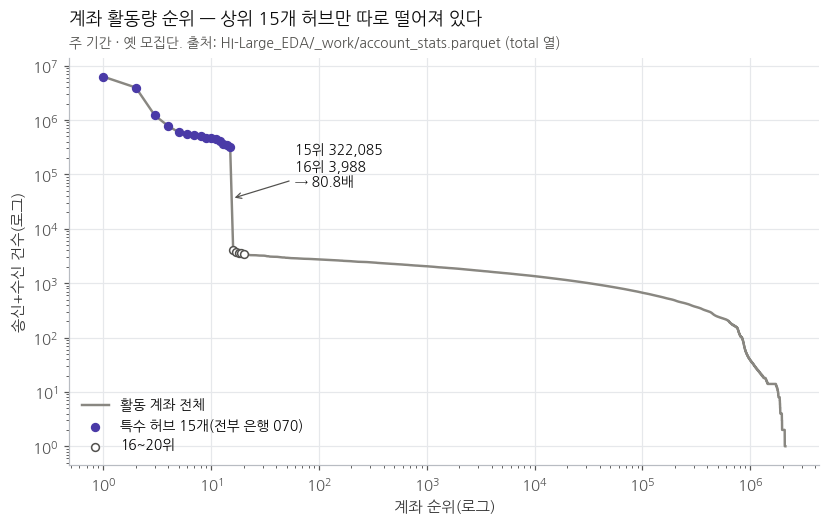

In [36]:
# 그림 3-1. 계좌 순위 곡선(송신+수신 건수, 로그-로그) — 15위와 16위 사이 절벽
r = np.arange(1, len(tot) + 1)
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.loglog(r, tot, color=C_NORM, lw=1.6, label='활동 계좌 전체')
ax.scatter(r[:15], tot[:15], s=26, color=SERIES[6], zorder=3, label='특수 허브 15개(전부 은행 070)')
ax.scatter(r[15:20], tot[15:20], s=26, facecolor='white', edgecolor=INK2, zorder=3, label='16~20위')
ax.annotate(f'15위 {tot[14]:,}\n16위 {tot[15]:,}\n→ {tot[14] / tot[15]:.1f}배', xy=(15.5, np.sqrt(tot[14] * tot[15])), xytext=(60, 60000),
            fontsize=9, color=INK, arrowprops=dict(arrowstyle='->', color=INK2, lw=0.8))
ax.set_xlabel('계좌 순위(로그)'); ax.set_ylabel('송신+수신 건수(로그)'); ax.legend(frameon=False, fontsize=9, loc='lower left')
title(ax, '계좌 활동량 순위 — 상위 15개 허브만 따로 떨어져 있다', '주 기간 · 옛 모집단. 출처: HI-Large_EDA/_work/account_stats.parquet (total 열)')
savefig(fig, 'S3_1_계좌순위_허브절벽.png')

**해석**
- **계좌 수는 키가 아니라 모집단에 따라 다르다.** 2,116,163 = 주 기간 옛 모집단에서 활동한 계좌(원문 키). 2,116,168 = 165일 전체(interim 계좌 표 = DB 노드 수). **차이 5개는 주 기간에는 거래가 없고 꼬리(11-06~)에만 나오는 계좌**다. 5개 모두 패턴 원문의 꼬리 거래(11-07~12-10, 줄 번호는 위 표)에 나온다. 키 표기('011'/'0011')가 갈라진 것이 아니다. 옛 짧은 파일의 2,115,738 vs 2,115,733 도 같은 5개 차이다(EDA 현황 §1-8). → 부록 B #9 해결.
- 방향 있는 계좌쌍은 주 기간 옛 모집단에서 8,444,243쌍이다. 계좌 파일(KYC)과 맞출 때 계좌 파일에 없는 노드는 0 이다(위 `run.log` 줄).
- 송신 건수는 중앙값 12 · p99 851 인데 최대가 6,233,962 다. 세탁에 한 번이라도 연루된 계좌는 209,079개다.
- **특수 허브 15개는 모두 은행 070(National Bank of Indianapolis)** 계좌다. 1위는 송신 6,233,962 · 수신 31,906 이다. 패턴 세탁은 0 이고, 패턴 밖 세탁은 송·수신 합 24,316건이다.
- 15위(322,085)와 16위(3,988) 사이가 약 81배 절벽이다. 허브 15개가 거래의 약 9.6% 에 관여한다(근사). 특수 허브를 어떻게 다룰지는 미결이다(팀 결정 대기, 부록 B).

### 3-2. 여러 통화를 쓰는 계좌 [저장 결과]
- `B4` · `B4b` 는 계좌 단위(송금에 쓴 통화 종류 수)다. 활동량이 많은 계좌일수록 통화도 많이 쓰므로 **단순 비율만 인용하지 않는다.** 활동량으로 층을 나눈 오즈비(OR)를 함께 적는다.
- 층화 OR 은 거래 단위 후보 "송금 전에 이미 2종+ 통화를 쓴 송신 계좌"의 값이다(`H1_후보_종합표.csv` 1행, 이전 송신 건수 5층 Mantel–Haenszel).

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B4_다통화계좌_세탁연루.csv  (233 B · 2행)


,다통화(송금 2종+),계좌수,세탁연루계좌,송신건수합,세탁 연루율(%),계좌 비율(%)
0,False,1970150,157966,151483808,8.017968,94.8901
1,True,106094,49898,28166873,47.031877,5.1099


분모 = 송신 계좌(out_n > 0) 2,076,244 · 송금 통화 2종+ 106,094
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B4b_송금통화_종류수별.csv  (289 B · 8행)


,n_send_currencies,계좌수,세탁연루계좌,세탁 연루율(%)
0,1,1970150,157966,8.017968
1,2,89658,45752,51.029468
2,3,12918,2848,22.046756
3,4,2745,778,28.342441
4,5,604,381,63.079470
5,6,145,117,80.689655
6,7,22,20,90.909091
7,8,2,2,100.000000


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/H1_후보_종합표.csv  (2,301 B · 17행)
거래 단위 후보: 정상 10.951% · 패턴 27.615% · 패턴 밖 2.2555% · 활동량 층화 OR 패턴 4.47 · 패턴 밖 0.41


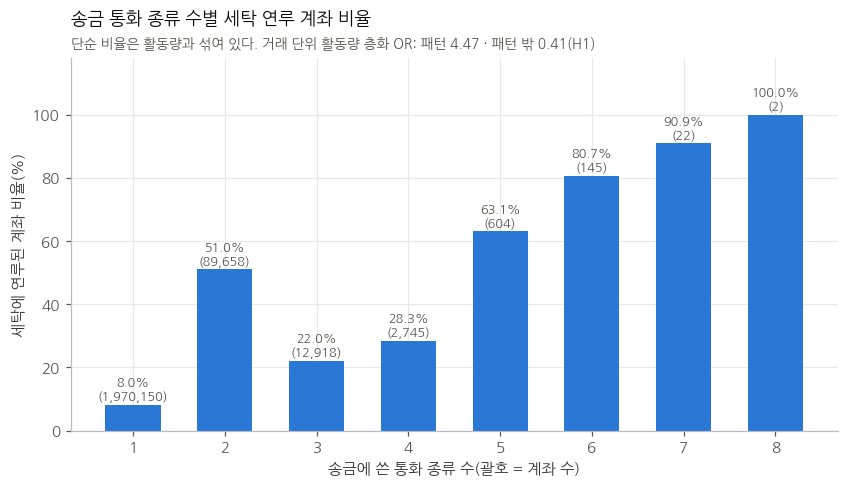

In [37]:
B4 = rd(RES / 'B4_다통화계좌_세탁연루.csv'); display(B4)
print(f"분모 = 송신 계좌(out_n > 0) {int(B4['계좌수'].sum()):,} · 송금 통화 2종+ {int(B4.loc[B4['다통화(송금 2종+)'], '계좌수'].iloc[0]):,}")
B4b = rd(RES / 'B4b_송금통화_종류수별.csv'); display(B4b)
H1 = rd(RES / 'H1_후보_종합표.csv').set_index('후보')
h = H1.loc['송금 전에 이미 2종+ 통화를 쓴 송신 계좌']
print(f"거래 단위 후보: 정상 {h['정상(%)']}% · 패턴 {h['패턴(%)']}% · 패턴 밖 {h['패턴 밖(%)']}% · 활동량 층화 OR 패턴 {h['층화 OR 패턴']:.2f} · 패턴 밖 {h['층화 OR 패턴 밖']:.2f}")

fig, ax = plt.subplots(figsize=(9, 4.4)); x = np.arange(len(B4b))
ax.bar(x, B4b['세탁 연루율(%)'], color=C_PAT, width=0.6)
for xi, (v, n) in enumerate(zip(B4b['세탁 연루율(%)'], B4b['계좌수'])):
    ax.text(xi, v + 1.5, f'{v:.1f}%\n({n:,})', ha='center', fontsize=8.3, color=INK2)
ax.set_xticks(x); ax.set_xticklabels(B4b['n_send_currencies']); ax.set_ylim(0, 118)
ax.set_xlabel('송금에 쓴 통화 종류 수(괄호 = 계좌 수)'); ax.set_ylabel('세탁에 연루된 계좌 비율(%)')
title(ax, '송금 통화 종류 수별 세탁 연루 계좌 비율', f"단순 비율은 활동량과 섞여 있다. 거래 단위 활동량 층화 OR: 패턴 {h['층화 OR 패턴']:.2f} · 패턴 밖 {h['층화 OR 패턴 밖']:.2f}(H1)")
savefig(fig, 'S3_2_다통화계좌.png')

**해석**
- 송금 통화 2종 이상 계좌는 **송신 계좌(`out_n > 0`) 2,076,244 중 106,094개(5.1%)**이고 연루율이 47.0% 다(1종 계좌 8.0%). 분모는 활동 계좌 2,116,163 이 아니라 송신 계좌다(`step2_accounts.py:101`).
- 그러나 활동량을 맞추면 달라진다. **패턴은 OR 4.47 로 관련이 남고, 패턴 밖은 OR 0.41 로 오히려 반대**다. 단순 비율(47% vs 8%)만 옮기면 틀린 인상을 준다.

### 3-3. 소유주 유형 · 국가 · 은행 흐름
원래 계산 위치:

| 결과 | 원래 코드 | 입력 | 이 노트북 |
|---|---|---|---|
| G6 송신 소유주 유형별 | `notebooks/08_31열_공백후보_검증.ipynb` cell 9 | cell 2 가 만든 31열 행렬(`/tmp/claude-0/…/scratchpad/eda_cols`, **지워짐**) · index_full · interim · accounts | **옮기지 않음** — cell 9 는 cell 2 의 변수에 기대고, cell 2 의 입력 폴더가 없다 |
| V7 국가 × 통화 · KYC 재집계 · V8 약한 후보(8-1 · 8-3 · 8-4) | `notebooks/13_V7_소유주_국가_약한후보.ipynb` cell 1~6(코드 230줄) | index_full · `_work/g08_targets_packed.npz` · new_proc2raw · interim · accounts (모두 있음) | 아래 무거운 셀 `V7`(꺼짐) |
| B2 은행 흐름 | `step1_scan.py:63-72`(저장 :109-113) | interim | §4 무거운 셀 `step1` 에 들어 있음 |

In [38]:
# [무거움 · 기본 꺼짐] 원본: notebooks/13_V7_소유주_국가_약한후보.ipynb cell 1 · 2 · 3 · 4 · 5 · 6
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: C.save_csv( → save_csv_h( (out/); C.log( → log_h( (out/run.log)
def _heavy_V7():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    # ── 원본 13_V7_소유주_국가_약한후보.ipynb cell 1 ──
    # ── 공통 적재: 색인(src·dst·day)과 08 이 저장한 라벨·플래그 ──
    import sys, os, gc, re, json
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np, pandas as pd
    import eda_common as C

    DRY = int(os.environ.get('V7_DRY', '0'))          # 0 = 전량, 점검 때는 앞 200만 행
    PFX = 'DRY_' if DRY else ''
    STEP = 20_000_000

    def mem(tag):
        rss = [int(l.split()[1]) for l in open('/proc/self/status') if l.startswith('VmRSS')][0] / 2**20
        print(f'[{tag}] 컨테이너 anon {C.anon_gib():.2f} GiB · 이 노트북 RSS {rss:.2f} GiB')

    z = np.load(C.WORK / 'g08_targets_packed.npz', allow_pickle=True)
    NAMES = [str(x) for x in z['names']]
    n_all = int(z['n']); n = DRY or n_all
    gt = np.array(z['gt'][:n], dtype=np.int8)                       # -1 정상 / 0~7 패턴 유형 / 8 패턴 밖
    g3 = np.where(gt < 0, 0, np.where(gt == 8, 2, 1)).astype(np.int8)
    GN = ['정상', '패턴 세탁', '패턴 밖 세탁']
    DEN = np.bincount(g3, minlength=3)
    print('모집단 행', f'{n:,}', dict(zip(GN, (int(x) for x in DEN))))
    if not DRY:
        assert (n, *map(int, DEN)) == (179_650_681, 179_449_408, 113_663, 87_610)

    def flag(name):
        j = NAMES.index(name)
        return np.unpackbits(z[f't{j}'])[:n].astype(bool)

    idx = np.load(C.MAIN / 'index_full.npz')
    def ix(k, dt):
        a = idx[k]; out = np.array(a[:n], dtype=dt); del a; gc.collect(); return out
    src = ix('src_id', np.int32); dst = ix('dst_id', np.int32); day = ix('day', np.int16)
    mem('색인 적재')


    # ── 원본 13_V7_소유주_국가_약한후보.ipynb cell 2 ──
    # ── (7a·7b) 플래그 4개 재집계 + H1 대조 + G2·G4 의 OR 인용(파일·행 위치) / (8-4) 소유주 같음 ──
    F7 = ['송신 소유주가 계좌 2개+', '양쪽 국가 앎', '같은 국가(둘 다 앎)', '다른 국가(둘 다 앎)', '송·수신 소유주 같음(다른 계좌)']
    H1 = pd.read_csv(C.OUT / 'H1_후보_종합표.csv')
    G2 = pd.read_csv(C.OUT / 'G2_활동량층화_오즈비.csv')
    G4 = pd.read_csv(C.OUT / 'G4_31열점수고정_남는관련.csv')
    rows, CNT = [], {}
    for nm in F7:
        f = flag(nm)
        c = np.bincount(g3[f], minlength=3); CNT[nm] = f if nm == F7[-1] else None
        h = H1[H1['후보'] == nm].iloc[0]
        g2 = G2[(G2['후보'] == nm) & (G2['구간'] == '전체')]
        r = {'후보': nm}
        for k, (g, hc) in enumerate(zip(GN, ['정상(%)', '패턴(%)', '패턴 밖(%)'])):
            pct = 100 * c[k] / DEN[k]
            r[f'{g} 분자'] = int(c[k]); r[f'{g} 분모'] = int(DEN[k]); r[f'{g} 비율(%)'] = pct
            r[f'{g} H1 값(%)'] = float(h[hc]); r[f'{g} H1 과 일치(5e-5)'] = bool(abs(round(pct, 4) - float(h[hc])) <= 5e-5) if not DRY else None
        r['G2 단순 OR 패턴'] = float(g2['패턴 단순 오즈비'].iloc[0]); r['G2 층화 OR 패턴'] = float(g2['패턴 활동량 층화 오즈비'].iloc[0])
        r['G2 층화 OR 패턴 95%'] = f"{g2['패턴 95% 하한'].iloc[0]:.4f}~{g2['패턴 95% 상한'].iloc[0]:.4f}"
        r['G2 단순 OR 패턴 밖'] = float(g2['패턴 밖 단순 오즈비'].iloc[0]); r['G2 층화 OR 패턴 밖'] = float(g2['패턴 밖 활동량 층화 오즈비'].iloc[0])
        r['G2 층화 OR 패턴 밖 95%'] = f"{g2['패턴 밖 95% 하한'].iloc[0]:.4f}~{g2['패턴 밖 95% 상한'].iloc[0]:.4f}"
        r['G2 위치'] = f"results/G2_활동량층화_오즈비.csv 자료행 {int(g2.index[0]) + 1}(구간=전체)"
        for tg, lab in (('패턴 세탁', '패턴'), ('패턴 밖 세탁', '패턴 밖')):
            g4 = G4[(G4['후보'] == nm) & (G4['대상'] == tg)]
            if len(g4):
                r[f'G4 단순 OR {lab}'] = float(g4['단순 오즈비'].iloc[0]); r[f'G4 31열 점수 고정 OR {lab}'] = float(g4['31열 점수 고정 오즈비'].iloc[0])
                r[f'G4 고정 OR {lab} 95%'] = f"{g4['95% 하한'].iloc[0]:.4f}~{g4['95% 상한'].iloc[0]:.4f}"
                r[f'G4 위치 {lab}'] = f"results/G4_31열점수고정_남는관련.csv 자료행 {int(g4.index[0]) + 1}"
        rows.append(r)
        if nm != F7[-1]:
            del f
    V7a = pd.DataFrame(rows)
    V7a.insert(1, '비고', 'G4 의 OR 은 세탁 전부 vs 정상 표본(사례-대조)·31열 점수 층 고정 값이라 원비율·G2 와 정의가 다르다')
    save_csv_h(V7a, f'{PFX}V7_KYC_재집계.csv')
    pd.set_option('display.width', 250, 'display.max_columns', 60)
    display(V7a[['후보'] + [c for c in V7a.columns if '분자' in c or '비율(%)' in c or '일치' in c]])
    display(V7a[['후보'] + [c for c in V7a.columns if 'OR' in c and '위치' not in c]])

    # (8-4) 소유주 같음(다른 계좌): 그룹·8유형별 건수와 10만 건당
    f11 = CNT[F7[-1]]
    TYPE = {-1: '정상', **dict(enumerate(C.CLASS_NAMES)), 8: '패턴 밖 세탁'}
    den_t = np.bincount(gt.astype(np.int16) + 1, minlength=10); num_t = np.bincount(gt[f11].astype(np.int16) + 1, minlength=10)
    R84 = [{'세부': '8-4', '항목': '송·수신 소유주 같음(다른 계좌)', '구분': TYPE[k - 1], '분자': int(num_t[k]), '분모': int(den_t[k]),
            '비율(%)': 100 * num_t[k] / max(den_t[k], 1), '10만 건당': 1e5 * num_t[k] / max(den_t[k], 1)} for k in range(10)]
    pat = slice(1, 9)
    R84.insert(1, {'세부': '8-4', '항목': '송·수신 소유주 같음(다른 계좌)', '구분': '패턴 세탁(8유형 합)', '분자': int(num_t[pat].sum()), '분모': int(den_t[pat].sum()),
                   '비율(%)': 100 * num_t[pat].sum() / max(den_t[pat].sum(), 1), '10만 건당': 1e5 * num_t[pat].sum() / max(den_t[pat].sum(), 1)})
    display(pd.DataFrame(R84))
    del f11, CNT; gc.collect(); mem('7a·8-4')


    # ── 원본 13_V7_소유주_국가_약한후보.ipynb cell 3 ──
    # ── (7c 위치) 은행명→국가 코드 위치와 계좌 파일의 은행 이름 형태 ──
    def country_of(name):
        """노트북 08 셀 9 의 country_of 그대로(= 태훈님 01_데이터_전처리 _country_of)."""
        m = re.match(r'^(.*?) Bank #', str(name))
        v = m.group(1).strip() if m else 'UNKNOWN'
        return 'UNKNOWN' if (v.lower() in {'crypto', 'crytpo'} or not v) else v

    def find_lines(nb_path, pat):
        nb = json.load(open(nb_path)); out = []
        for i, c in enumerate(nb['cells']):
            for j, l in enumerate(''.join(c['source']).split('\n'), 1):
                if re.search(pat, l):
                    out.append((i, j, l.strip()[:160]))
        return out

    LOC = []
    for path, pat in ((C.EDA / 'notebooks/08_31열_공백후보_검증.ipynb', r'def country_of|Bank #|crytpo|map\(country_of\)'),
                      (C.Path('/workspace/Final_preprocess/태훈님_전처리/01_데이터_전처리.ipynb'), r'def _country_of|Bank #|crytpo|map\(_country_of\)')):
        for i, j, l in find_lines(path, pat):
            LOC.append({'세부': '7c', '종류': '코드 위치', '파일': str(path).replace('/workspace/Final_preprocess/', ''), '위치': f'셀 {i} · {j}행', '내용': l})

    acc = pd.read_csv(C.RAW_DIR / 'HI-Large_accounts.csv', dtype=str)
    acc.columns = ['bank_name', 'bank_id', 'account', 'entity_id', 'entity_name']
    acc['country'] = acc['bank_name'].map(country_of)
    acc['형태'] = np.where(acc['bank_name'].str.match(r'^(.*?) Bank #', na=False),
                         np.where(acc['country'] == 'UNKNOWN', 'crypto 계열 "<x> Bank #"(UNKNOWN 처리)', '국가형 "<국가> Bank #"'), '정규식 불일치(UNKNOWN 처리)')
    fm = acc.groupby('형태').agg(은행이름수=('bank_name', 'nunique'), 은행ID수=('bank_id', 'nunique'), 계좌행수=('account', 'size')).reset_index()
    for _, r in fm.iterrows():
        LOC.append({'세부': '7c', '종류': '계좌 파일 은행 이름 형태', '파일': 'IBM_AML_dataset/HI-Large_accounts.csv', '위치': r['형태'],
                    '내용': f"은행 이름 {r['은행이름수']:,}개 · 은행 ID {r['은행ID수']:,}개 · 계좌 행 {r['계좌행수']:,}개(전체 {len(acc):,}행)"})
    ex = acc.loc[acc['형태'] != '국가형 "<국가> Bank #"', 'bank_name'].drop_duplicates().head(5).tolist()
    LOC.append({'세부': '7c', '종류': 'UNKNOWN 형 은행 이름 예', '파일': 'IBM_AML_dataset/HI-Large_accounts.csv', '위치': '-', '내용': ' / '.join(map(str, ex))})
    cc = acc[acc['country'] != 'UNKNOWN'].groupby('country').agg(은행이름수=('bank_name', 'nunique'), 계좌행수=('account', 'size')).sort_values('계좌행수', ascending=False)
    LOC.append({'세부': '7c', '종류': '나라 목록', '파일': 'IBM_AML_dataset/HI-Large_accounts.csv', '위치': f'{len(cc)}개국',
                '내용': ' · '.join(f'{k}(은행 {v.은행이름수:,}·계좌 {v.계좌행수:,})' for k, v in cc.iterrows())})
    V7loc = pd.DataFrame(LOC); save_csv_h(V7loc, f'{PFX}V7_국가코드_위치.csv')
    pd.set_option('display.max_colwidth', 200); display(V7loc)
    del acc; gc.collect()


    # ── 원본 13_V7_소유주_국가_약한후보.ipynb cell 4 ──
    # ── 통화 열: 파트를 한 번만 돌며 pay_code·recv_code 를 함께 읽는다(08 의 raw_col 을 두 열 동시 읽기로만 바꿈) ──
    ps, starts = C.part_starts()
    pay_v = C.vocab('pay'); assert pay_v == C.vocab('recv') and len(pay_v) <= 16
    K = len(pay_v)
    pf, rf = [], []
    for f in ps:
        t = pd.read_parquet(f, columns=['pay_code', 'recv_code'])
        pf.append(t['pay_code'].to_numpy().astype(np.int8)); rf.append(t['recv_code'].to_numpy().astype(np.int8)); del t
        try:                                                   # 08 의 drop_cache: 읽기 캐시가 cgroup 한도에 잡히지 않게 비운다
            fd = os.open(f, os.O_RDONLY); os.posix_fadvise(fd, 0, 0, os.POSIX_FADV_DONTNEED); os.close(fd)
        except OSError:
            pass
    pf = np.concatenate(pf); rf = np.concatenate(rf)
    p2r = np.array(np.load(C.ALIGN / 'new_proc2raw.npy', mmap_mode='r')[:n], dtype=np.int64)
    payc = pf[p2r]; recvc = rf[p2r]; del pf, rf, p2r; gc.collect()
    mem('통화 열')

    # 노드 → 국가(08 셀 9 와 같은 조인)
    nk = pd.read_parquet(C.ALIGN / 'new_new2key.parquet')['key'].to_numpy(dtype=object)
    nt = C.node_table().drop_duplicates('key').set_index('key')
    ctry = nt.reindex(nk)['bank_name'].map(country_of)
    ctry_code, ctry_names = pd.factorize(ctry); ctry_code = ctry_code.astype(np.int16); ctry_names = list(ctry_names)
    UNK = ctry_names.index('UNKNOWN'); NC = len(ctry_names)
    del nk, nt, ctry; gc.collect()

    # 한 번의 조각 순회로 모든 교차표를 모은다
    T_src = np.zeros(NC * K, np.int64); T_dst = np.zeros(NC * K, np.int64)
    fb = flag('양쪽 국가 앎'); fs = flag('같은 국가(둘 다 앎)')
    T_pair = np.zeros(K * K * 4, np.int64)                     # (송금 통화, 수취 통화) × (양쪽 앎, 같은 국가)
    T7p = np.zeros(K * 2, np.int64); T7r = np.zeros(K * 2, np.int64)   # 통화 × 첫 7일 여부
    for a in range(0, n, STEP):
        e = min(a + STEP, n)
        p = payc[a:e].astype(np.int64); r = recvc[a:e].astype(np.int64)
        T_src += np.bincount(ctry_code[src[a:e]].astype(np.int64) * K + p, minlength=NC * K)
        T_dst += np.bincount(ctry_code[dst[a:e]].astype(np.int64) * K + r, minlength=NC * K)
        T_pair += np.bincount((p * K + r) * 4 + fb[a:e] * 2 + fs[a:e], minlength=K * K * 4)
        f7 = (day[a:e] < 7).astype(np.int64)
        T7p += np.bincount(p * 2 + f7, minlength=K * 2); T7r += np.bincount(r * 2 + f7, minlength=K * 2)
    T_src = T_src.reshape(NC, K); T_dst = T_dst.reshape(NC, K); T_pair = T_pair.reshape(K * K, 2, 2)
    del fb, fs; gc.collect(); mem('교차표')


    # ── 원본 13_V7_소유주_국가_약한후보.ipynb cell 5 ──
    # ── (7c 중복도) 국가 × 통화가 얼마나 겹치나 — 수치만 ──
    def cramers_v(T):
        T = T[T.sum(1) > 0][:, T.sum(0) > 0].astype(np.float64); N = T.sum()
        E = np.outer(T.sum(1), T.sum(0)) / N
        chi2 = ((T - E) ** 2 / E).sum()
        return float(np.sqrt(chi2 / (N * (min(T.shape) - 1))))

    R = []
    for side, T, cur in (('송신 은행 국가 × 송금 통화', T_src, '송금 통화'), ('수신 은행 국가 × 수취 통화', T_dst, '수취 통화')):
        N = int(T.sum()); Tk = np.delete(T, UNK, axis=0); Nk = int(Tk.sum())
        R += [{'세부': '7c', '쪽': side, '지표': '전 행 수(UNKNOWN 포함)', '분자': N, '분모': N, '값': 1.0},
              {'세부': '7c', '쪽': side, '지표': '국가를 아는 행', '분자': Nk, '분모': N, '값': Nk / N},
              {'세부': '7c', '쪽': side, '지표': "Cramér's V(UNKNOWN 을 한 범주로 포함)", '분자': None, '분모': N, '값': cramers_v(T)},
              {'세부': '7c', '쪽': side, '지표': "Cramér's V(국가를 아는 행만)", '분자': None, '분모': Nk, '값': cramers_v(Tk)},
              {'세부': '7c', '쪽': side, '지표': f'{cur} → 국가 다수결 정확도(국가를 아는 행)', '분자': int(Tk.max(0).sum()), '분모': Nk, '값': Tk.max(0).sum() / Nk},
              {'세부': '7c', '쪽': side, '지표': f'국가 → {cur} 다수결 정확도(국가를 아는 행)', '분자': int(Tk.max(1).sum()), '분모': Nk, '값': Tk.max(1).sum() / Nk},
              {'세부': '7c', '쪽': side, '지표': '참고: 통화를 안 보고 최빈 국가만 찍을 때 정확도', '분자': int(Tk.sum(1).max()), '분모': Nk, '값': Tk.sum(1).max() / Nk},
              {'세부': '7c', '쪽': side, '지표': '참고: 국가를 안 보고 최빈 통화만 찍을 때 정확도', '분자': int(Tk.sum(0).max()), '분모': Nk, '값': Tk.sum(0).max() / Nk},
              {'세부': '7c', '쪽': side, '지표': f'UNKNOWN 국가 행의 최빈 {cur} = {pay_v[int(T[UNK].argmax())]}', '분자': int(T[UNK].max()), '분모': int(T[UNK].sum()), '값': T[UNK].max() / max(T[UNK].sum(), 1)}]
        for k, nm in enumerate(ctry_names):
            if k != UNK and T[k].sum():
                R.append({'세부': '7c', '쪽': side, '지표': f'국가 {nm} 의 최빈 {cur} = {pay_v[int(T[k].argmax())]}', '분자': int(T[k].max()), '분모': int(T[k].sum()), '값': T[k].max() / T[k].sum()})
        for j, nm in enumerate(pay_v):
            if Tk[:, j].sum():
                kk = int(Tk[:, j].argmax()); full = [x for i_, x in enumerate(ctry_names) if i_ != UNK]
                R.append({'세부': '7c', '쪽': side, '지표': f'{cur} {nm} 의 최빈 국가 = {full[kk]}', '분자': int(Tk[kk, j]), '분모': int(Tk[:, j].sum()), '값': Tk[kk, j] / Tk[:, j].sum()})
                R.append({'세부': '7c', '쪽': side, '지표': f'{cur} {nm} 행 중 국가 UNKNOWN', '분자': int(T[UNK, j]), '분모': int(T[:, j].sum()), '값': T[UNK, j] / T[:, j].sum()})

    # 플래그를 (송금 통화, 수취 통화) 쌍만으로 다수결 예측했을 때의 일치율
    N = int(T_pair.sum())
    both = T_pair.sum(2)                                        # [쌍, 양쪽 앎 0/1]
    R += [{'세부': '7c', '쪽': '통화 쌍 → 플래그', '지표': "'양쪽 국가 앎' 을 통화 쌍 다수결로 예측한 일치율(전 행)", '분자': int(both.max(1).sum()), '분모': N, '값': both.max(1).sum() / N},
          {'세부': '7c', '쪽': '통화 쌍 → 플래그', '지표': "참고: '양쪽 국가 앎' 을 통화 없이 최빈값으로 찍을 때", '분자': int(both.sum(0).max()), '분모': N, '값': both.sum(0).max() / N}]
    same_all = np.stack([T_pair[:, 0, :].sum(1) + T_pair[:, 1, 0], T_pair[:, 1, 1]], 1)   # [쌍, 같은 국가 플래그 0/1] 전 행
    R += [{'세부': '7c', '쪽': '통화 쌍 → 플래그', '지표': "'같은 국가(둘 다 앎)' 을 통화 쌍 다수결로 예측한 일치율(전 행)", '분자': int(same_all.max(1).sum()), '분모': N, '값': same_all.max(1).sum() / N},
          {'세부': '7c', '쪽': '통화 쌍 → 플래그', '지표': "참고: '같은 국가(둘 다 앎)' 을 통화 없이 최빈값으로 찍을 때(전 행)", '분자': int(same_all.sum(0).max()), '분모': N, '값': same_all.sum(0).max() / N}]
    sk = T_pair[:, 1, :]; Nb = int(sk.sum())                    # 양쪽 국가를 아는 행 안에서 같은/다른 국가
    R += [{'세부': '7c', '쪽': '통화 쌍 → 플래그', '지표': "같은 국가 vs 다른 국가를 통화 쌍 다수결로 예측한 일치율(양쪽 국가 아는 행만)", '분자': int(sk.max(1).sum()), '분모': Nb, '값': sk.max(1).sum() / Nb},
          {'세부': '7c', '쪽': '통화 쌍 → 플래그', '지표': "참고: 같은/다른 국가를 통화 없이 최빈값으로 찍을 때(양쪽 국가 아는 행만)", '분자': int(sk.sum(0).max()), '분모': Nb, '값': sk.sum(0).max() / Nb}]
    diag = np.array([i * K + i for i in range(K)])
    R += [{'세부': '7c', '쪽': '통화 쌍 → 플래그', '지표': '양쪽 국가 아는 행 중 송금 통화 = 수취 통화', '분자': int(sk[diag].sum()), '분모': Nb, '값': sk[diag].sum() / Nb},
          {'세부': '7c', '쪽': '통화 쌍 → 플래그', '지표': '같은 통화 & 양쪽 앎 행 중 같은 국가', '분자': int(sk[diag, 1].sum()), '분모': int(sk[diag].sum()), '값': sk[diag, 1].sum() / sk[diag].sum()}]
    V7x = pd.DataFrame(R); V7x['값(%)'] = np.where(V7x['지표'].str.contains("Cramér"), np.nan, 100 * V7x['값'])
    save_csv_h(V7x, f'{PFX}V7_국가x통화_중복도.csv')
    pd.set_option('display.max_rows', 200); display(V7x[~V7x['지표'].str.contains('의 최빈|행 중 국가 UNKNOWN')]); display(V7x[V7x['지표'].str.startswith('국가 ')])


    # ── 원본 13_V7_소유주_국가_약한후보.ipynb cell 6 ──
    # ── 항목 8: (8-1) 같은 은행 vs 타행 · (8-3) 새 통화 등장 · (8-4) 소유주 같음 ──
    B2 = pd.read_csv(C.OUT / 'B2_은행흐름별_세탁비율.csv'); B2 = B2[B2['범위'].str.startswith('주기간')].set_index('흐름')
    a, b = B2.loc['같은 은행·다른 계좌'], B2.loc['타행']
    R8 = []
    for lab, col in (('세탁 전체', '세탁수'), ('패턴 세탁', '패턴 세탁'), ('패턴 밖 세탁', '패턴 밖 세탁')):
        x1, n1, x2, n2 = int(a[col]), int(a['거래수']), int(b[col]), int(b['거래수']); p1, p2 = x1 / n1, x2 / n2
        se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2); d = p1 - p2
        sl = np.sqrt(1 / x1 - 1 / n1 + 1 / x2 - 1 / n2); rr = p1 / p2
        R8.append({'세부': '8-1', '항목': f'같은 은행·다른 계좌 vs 타행 — {lab}', '구분': '주기간(B2 자료행: 같은 은행 2행 · 타행 3행)',
                   '분자': x1, '분모': n1, '비율(%)': 100 * p1, '비교 분자': x2, '비교 분모': n2, '비교 비율(%)': 100 * p2,
                   '차이(%p)': 100 * d, '차이 95% 하한(%p)': 100 * (d - 1.96 * se), '차이 95% 상한(%p)': 100 * (d + 1.96 * se),
                   '비(ratio)': rr, '비 95% 하한': rr * np.exp(-1.96 * sl), '비 95% 상한': rr * np.exp(1.96 * sl),
                   '비고': 'B2 는 1단계 원본 행 집계(은행 = bank0). 셀프(같은 계좌) 10,879,730행은 두 쪽 모두에서 빠져 있다'})

    G7 = pd.read_csv(C.OUT / 'G7_통화_기간별_등장.csv').set_index('통화')
    for cur, T7 in (('송금 통화', T7p), ('수취 통화', T7r)):
        T7 = T7.reshape(K, 2); late_only = [(pay_v[k], int(T7[k, 0])) for k in range(K) if T7[k, 1] == 0 and T7[k, 0] > 0]
        ok7 = bool(all(int(T7[k, 1]) == int(G7.loc[pay_v[k], '첫 7일 송금']) for k in range(K))) if (cur == '송금 통화' and not DRY) else None
        R8.append({'세부': '8-3', '항목': f'첫 7일에 없다가 나중에 처음 등장한 {cur} 수', '구분': f'통화 {K}종 · 첫 7일 = day<7', '분자': len(late_only), '분모': K,
                   '비고': f"해당 통화 {late_only if late_only else '없음'} · 첫 7일 최소 건수 {int(T7[:, 1].min()):,}({pay_v[int(T7[:, 1].argmin())]}) · 첫 7일 행 {int(T7[:, 1].sum()):,} / 이후 행 {int(T7[:, 0].sum()):,}"
                         + (f' · G7 의 첫 7일 송금 건수와 15종 모두 일치={ok7}' if ok7 is not None else '')})
    V8 = pd.concat([pd.DataFrame(R8), pd.DataFrame(R84)], ignore_index=True)
    save_csv_h(V8, f'{PFX}V8_약한후보_수치.csv')
    display(V8)
    mem('끝'); log_h(f'13_V7 완료 · DRY={DRY}')


if HEAVY['V7']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_V7()
else:
    print("HEAVY['V7'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['V7'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


**[저장 결과]**

In [39]:
G6 = rd(RES / 'G6_송신소유주유형별.csv').set_index('송신 소유주 유형'); display(G6.round(2))
V7 = rd(RES / 'V7_국가x통화_중복도.csv')
pick = V7[V7.지표.isin(['국가를 아는 행', "Cramér's V(UNKNOWN 을 한 범주로 포함)", "Cramér's V(국가를 아는 행만)"])
          | V7.지표.str.contains('US Dollar 행 중 국가 UNKNOWN')]
display(pick[['세부', '쪽', '지표', '분자', '분모', '값']])
B2 = rd(RES / 'B2_은행흐름별_세탁비율.csv'); display(B2[B2.범위 == '주기간(전처리 대상)'])
B2b = rd(RES / 'B2b_은행표기_오분류.csv'); print('원문 은행 문자열과 bank0 가 다르게 가르는 행(전 범위 합):', int(B2b.iloc[:, -1].sum()))
display(rd(RES / 'B2c_셀프세탁_유형.csv').set_index('유형').T)
V8 = rd(RES / 'V8_약한후보_수치.csv')
display(V8[V8.세부.isin(['8-1', '8-4'])][['세부', '항목', '구분', '분자', '분모', '비율(%)', '비(ratio)', '비 95% 하한', '비 95% 상한']])

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/G6_송신소유주유형별.csv  (504 B · 6행)


,거래,정상,패턴 세탁,패턴 밖 세탁,패턴 10만건당,패턴 밖 10만건당
송신 소유주 유형,,,,,,
Sole Proprietorship,68156052,68090290,38293,27469,56.18,40.30
Partnership,58952293,58892185,39010,21098,66.17,35.79
Corporation,51349190,51274730,36291,38169,70.67,74.33
Country,1060737,1060159,0,578,0.00,54.49
Individual,130107,129742,69,296,53.03,227.51
Direct,2302,2302,0,0,0.00,0.00


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V7_국가x통화_중복도.csv  (21,809 B · 150행)


,세부,쪽,지표,분자,분모,값
1,7c,송신 은행 국가 × 송금 통화,국가를 아는 행,98126725.0,179650681,0.546208
2,7c,송신 은행 국가 × 송금 통화,Cramér's V(UNKNOWN 을 한 범주로 포함),NaN,179650681,0.844774
3,7c,송신 은행 국가 × 송금 통화,Cramér's V(국가를 아는 행만),NaN,98126725,0.866560
66,7c,송신 은행 국가 × 송금 통화,송금 통화 US Dollar 행 중 국가 UNKNOWN,64899268.0,65823422,0.985960
72,7c,수신 은행 국가 × 수취 통화,국가를 아는 행,109140479.0,179650681,0.607515
73,7c,수신 은행 국가 × 수취 통화,Cramér's V(UNKNOWN 을 한 범주로 포함),NaN,179650681,0.921087
74,7c,수신 은행 국가 × 수취 통화,Cramér's V(국가를 아는 행만),NaN,109140479,0.893469
137,7c,수신 은행 국가 × 수취 통화,수취 통화 US Dollar 행 중 국가 UNKNOWN,64357578.0,65276619,0.985921


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B2_은행흐름별_세탁비율.csv  (1,021 B · 9행)


,범위,흐름,거래수,정상,패턴 세탁,패턴 밖 세탁,세탁수,세탁비율(%),패턴 비율(%),패턴 밖 비율(%)
0,주기간(전처리 대상),셀프(같은 bank0·계좌),10879730,10879353,377,0,377,0.003465,0.003465,0.000000
1,주기간(전처리 대상),같은 은행·다른 계좌,1411474,1409783,1035,656,1691,0.119804,0.073328,0.046476
2,주기간(전처리 대상),타행,167359477,167160272,112251,86954,199205,0.119028,0.067072,0.051956


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B2b_은행표기_오분류.csv  (389 B · 9행)
원문 은행 문자열과 bank0 가 다르게 가르는 행(전 범위 합): 0
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B2c_셀프세탁_유형.csv  (145 B · 9행)


유형,FAN-OUT,FAN-IN,CYCLE,SCATTER-GATHER,GATHER-SCATTER,BIPARTITE,STACK,RANDOM,패턴 밖
셀프 세탁 건수(전 범위),0,0,0,0,451,0,0,0,0


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V8_약한후보_수치.csv  (3,276 B · 16행)


,세부,항목,구분,분자,분모,비율(%),비(ratio),비 95% 하한,비 95% 상한
0,8-1,같은 은행·다른 계좌 vs 타행 — 세탁 전체,주기간(B2 자료행: 같은 은행 2행 · 타행 3행),1691,1411474,0.119804,1.006516,0.959502,1.055835
1,8-1,같은 은행·다른 계좌 vs 타행 — 패턴 세탁,주기간(B2 자료행: 같은 은행 2행 · 타행 3행),1035,1411474,0.073328,1.093270,1.028388,1.162247
2,8-1,같은 은행·다른 계좌 vs 타행 — 패턴 밖 세탁,주기간(B2 자료행: 같은 은행 2행 · 타행 3행),656,1411474,0.046476,0.894523,0.828400,0.965925
5,8-4,송·수신 소유주 같음(다른 계좌),정상,549986,179449408,0.306485,NaN,NaN,NaN
6,8-4,송·수신 소유주 같음(다른 계좌),패턴 세탁(8유형 합),6,113663,0.005279,NaN,NaN,NaN
7,8-4,송·수신 소유주 같음(다른 계좌),FAN-OUT,2,11383,0.017570,NaN,NaN,NaN
8,8-4,송·수신 소유주 같음(다른 계좌),FAN-IN,0,11324,0.000000,NaN,NaN,NaN
9,8-4,송·수신 소유주 같음(다른 계좌),CYCLE,0,10552,0.000000,NaN,NaN,NaN
10,8-4,송·수신 소유주 같음(다른 계좌),SCATTER-GATHER,1,22324,0.004479,NaN,NaN,NaN
11,8-4,송·수신 소유주 같음(다른 계좌),GATHER-SCATTER,1,18635,0.005366,NaN,NaN,NaN


그림 3-3 은 `notebooks/12` cell 13 **오른쪽 패널**(G6) 코드를 옮긴 것이다. 왼쪽 패널(G4, 31열 점수 고정 OR)은 대체됐으므로 옮기지 않았다.

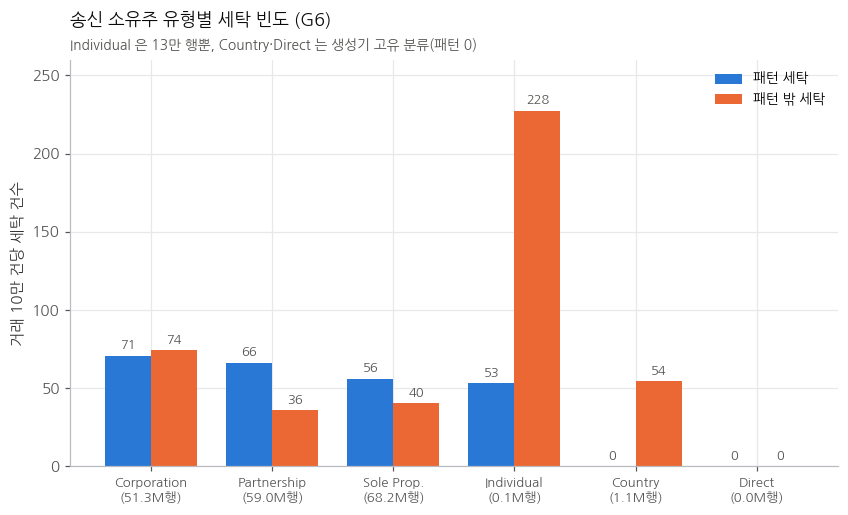

In [40]:
# 원본: notebooks/12 cell 13 오른쪽 패널. 바꾼 곳: 한 칸 그림, 제목·저장.
types = ['Corporation', 'Partnership', 'Sole Proprietorship', 'Individual', 'Country', 'Direct']
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(types))
w = 0.38
b1 = ax.bar(x - w / 2, G6.loc[types, '패턴 10만건당'], width=w, color=C_PAT, label='패턴 세탁')
b2 = ax.bar(x + w / 2, G6.loc[types, '패턴 밖 10만건당'], width=w, color=C_OOP, label='패턴 밖 세탁')
label_bars(ax, b1, fmt='{:.0f}', dy=3); label_bars(ax, b2, fmt='{:.0f}', dy=3)
ax.set_xticks(x)
short = {'Sole Proprietorship': 'Sole Prop.'}
ax.set_xticklabels([short.get(t, t) + f"\n({G6.loc[t, '거래'] / 1e6:.1f}M행)" for t in types], fontsize=8.6)
ax.set_ylim(0, 260)
ax.set_ylabel('거래 10만 건당 세탁 건수')
ax.legend(frameon=False, fontsize=9)
title(ax, '송신 소유주 유형별 세탁 빈도 (G6)', 'Individual 은 13만 행뿐, Country·Direct 는 생성기 고유 분류(패턴 0)')
savefig(fig, 'S3_3_소유주유형_G6.png')

**해석**
- 소유주 유형(계좌 파일 Entity Name 앞말)은 6종이다. Sole Prop. · Partnership · Corporation 이 대부분이다. **Country · Direct 는 패턴 세탁이 0 이다.** 패턴 밖은 Individual 이 10만 건당 227.5 로 가장 높다(행이 13만뿐이라 흔들림이 큼).
- **국가**(은행 이름에서 뽑음)를 아는 행은 송신 54.62% · 수신 60.75% 뿐이다. 국가와 통화의 Cramér's V 가 0.84~0.92 로 거의 같은 정보다. USD 송금의 98.60% 는 송신 국가가 UNKNOWN 이다. 국가를 따로 쓰면 통화를 한 번 더 넣는 셈이다.
- **은행 흐름**: 같은 은행·다른 계좌 0.1198% vs 타행 0.1190%, 비 1.0065 [0.96~1.06]. **차이가 없다.** 원문 은행 표기와 bank0 로 가른 결과도 전 범위에서 0행 다르다.
- **셀프 세탁**(같은 계좌끼리): 주 기간 377건, 꼬리 포함 451건으로 **모두 GATHER-SCATTER** 다. 자기송금은 주 기간 10,879,730행(6.06%)이다.
- 송·수신 소유주가 같은 거래(다른 계좌)는 패턴에서 6건뿐이다(V8 8-4).

## §4 결제 · 통화 · 금액 · 시각

**질문**: 결제 방식·통화·금액·시각 분포는 어떻고, 세탁과 어떻게 얽혀 있나?

원래 계산(`step1_scan.py`, 09-17)은 원본 순서 interim 90파트를 한 번 훑어 A1 · A2 · A2b · A2c · B1a · B1b · B1c · B2 를 만든다(09-17 실측 anon 5.2 GiB). **꺼 두었다.**

In [41]:
# [무거움 · 기본 꺼짐] 원본: HI-Large_EDA/step1_scan.py:2-156
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: C.log( → log_h( (out/run.log); C.save_csv( → save_csv_h( (out/)
def _heavy_step1():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    """1단계 — 원본 전 행 집계: A1 결제수단 · A2 통화 · B1 금액·시각 · B2 은행 흐름.

    원본 순서 interim 파트를 한 번 훑는다. 행 그룹(정상/패턴/패턴 밖)과 구간(train/val/test/꼬리/중복 제거)은
    build_labels.py 산출을 쓴다. 표마다 '전처리 대상(주 기간, 중복 제거 후)'과 '꼬리' 행을 나눠 적는다.
    """
    import json

    import numpy as np
    import pandas as pd

    import eda_common as C

    log_h('1단계 시작')
    ps, starts = C.part_starts()
    n = int(starts[-1])
    grp, att, sp = C.load_labels()
    fmt_v, pay_v, recv_v = C.vocab('fmt'), C.vocab('pay'), C.vocab('recv')
    nt = C.node_table()
    bank0_of = nt['bank0_id'].to_numpy()
    node0_of = nt['node0'].to_numpy()
    bankraw_of = pd.factorize(nt['bank_raw'])[0].astype(np.int32)
    rate = np.array([C.UNITS_PER_USD[c] for c in pay_v])


    def acc(arr, *idx):
        """칸별 건수 누적(bincount 사용 — 1억 8천만 행에서 add.at 보다 훨씬 빠르다)."""
        flat = np.ravel_multi_index(tuple(np.asarray(x, dtype=np.int64) for x in idx), arr.shape)
        arr += np.bincount(flat, minlength=arr.size).reshape(arr.shape)


    def accw(arr, w, *idx):
        flat = np.ravel_multi_index(tuple(np.asarray(x, dtype=np.int64) for x in idx), arr.shape)
        arr += np.bincount(flat, weights=w, minlength=arr.size).reshape(arr.shape).astype(arr.dtype)


    SCOPE = {'주기간(전처리 대상)': lambda s: s >= 0, '꼬리': lambda s: s == -1, '중복 제거된 행': lambda s: s == -2}
    G = {-1: '정상', 0: '패턴 세탁', 8: '패턴 밖 세탁'}
    a1 = np.zeros((3, 3, len(fmt_v)), np.int64)             # scope × group × fmt
    a2 = np.zeros((3, 3, len(pay_v)), np.int64)
    a2x = np.zeros((3, 3, 2), np.int64)                     # 환전(송금≠수취 통화)
    hour = np.zeros((3, 3, 24), np.int64)
    flow = np.zeros((3, 3, 3), np.int64)                    # self / same bank0 other acct / cross-bank
    flow_raw_mis = np.zeros((3, 3), np.int64)               # 원문 은행 문자열로는 '타행'인데 bank0 로는 같은 은행
    self_type = np.zeros(9, np.int64)                       # 셀프 세탁의 유형
    BINS = np.arange(-7.0, 14.01, 0.1)                      # log10(금액) 구간
    hist = np.zeros((3, 3, len(pay_v), len(BINS) + 1), np.int64)
    paid_main, code_main, g_main = [], [], []               # 주 기간 금액(분위수용)
    top = []
    for i, f in enumerate(ps):
        t = pd.read_parquet(f, columns=['ts_epoch_min', 'src_id', 'dst_id', 'paid', 'fmt_code', 'pay_code', 'recv_code'])
        lo, hi = starts[i], starts[i + 1]
        g3 = C.grp3(np.asarray(grp[lo:hi]))
        gi = np.select([g3 == -1, g3 == 0], [0, 1], 2)
        s = np.asarray(sp[lo:hi])
        si = np.select([s >= 0, s == -1], [0, 1], 2)
        fc, pc, rc = t['fmt_code'].to_numpy(), t['pay_code'].to_numpy(), t['recv_code'].to_numpy()
        acc(a1, si, gi, fc)
        acc(a2, si, gi, pc)
        acc(a2x, si, gi, (pc != rc))
        h = ((t['ts_epoch_min'].to_numpy() % 1440) // 60).astype(np.int64)
        acc(hour, si, gi, h)
        src, dst = t['src_id'].to_numpy(), t['dst_id'].to_numpy()
        same_node0 = node0_of[src] == node0_of[dst]
        same_bank0 = bank0_of[src] == bank0_of[dst]
        fl = np.select([same_node0, same_bank0], [0, 1], 2)
        acc(flow, si, gi, fl)
        mis = same_bank0 & (bankraw_of[src] != bankraw_of[dst])
        accw(flow_raw_mis, mis.astype(np.float64), si, gi)
        gg = np.asarray(grp[lo:hi])
        self_pos = same_node0 & (gg >= 0)
        self_type += np.bincount(gg[self_pos].astype(np.int64), minlength=9)
        paid = t['paid'].to_numpy()
        lb = np.searchsorted(BINS, np.log10(np.maximum(paid, 1e-12)))
        acc(hist, si, gi, pc, lb)
        mm = si == 0
        paid_main.append(paid[mm]); code_main.append(pc[mm].astype(np.int8)); g_main.append(gi[mm].astype(np.int8))
        usd = paid / rate[pc]
        k = np.argsort(usd)[-20:]
        top.append(pd.DataFrame({'raw_row': k + lo, 'usd': usd[k], 'paid': paid[k], 'pay': [pay_v[x] for x in pc[k]],
                                 'fmt': [fmt_v[x] for x in fc[k]], 'group': [G[x] for x in g3[k]], 'split_code': s[k]}))
        if i % 10 == 0:
            log_h(f'  파트 {i + 1}/{len(ps)} · anon {C.anon_gib():.1f} GiB')

    scopes = list(SCOPE)
    gn = ['정상', '패턴 세탁', '패턴 밖 세탁']


    def long_table(arr, cats, catname):
        rows = []
        for si, sc in enumerate(scopes):
            for ci, cname in enumerate(cats):
                r = {'범위': sc, catname: cname}
                tot = int(arr[si, :, ci].sum())
                r['거래수'] = tot
                for gi, gname in enumerate(gn):
                    r[gname] = int(arr[si, gi, ci])
                r['세탁수'] = r['패턴 세탁'] + r['패턴 밖 세탁']
                r['세탁비율(%)'] = 100 * r['세탁수'] / tot if tot else np.nan
                r['패턴 비율(%)'] = 100 * r['패턴 세탁'] / tot if tot else np.nan
                r['패턴 밖 비율(%)'] = 100 * r['패턴 밖 세탁'] / tot if tot else np.nan
                rows.append(r)
        return pd.DataFrame(rows)


    save_csv_h(long_table(a1, fmt_v, '결제수단'), 'A1_결제수단별_세탁비율.csv')
    save_csv_h(long_table(a2, pay_v, '송금통화'), 'A2_송금통화별_세탁비율.csv')
    save_csv_h(long_table(a2x, ['같은 통화', '환전(송금≠수취)'], '통화 관계'), 'A2b_환전거래_세탁.csv')
    save_csv_h(long_table(flow, ['셀프(같은 bank0·계좌)', '같은 은행·다른 계좌', '타행'], '흐름'), 'B2_은행흐름별_세탁비율.csv')
    mis = pd.DataFrame([{'범위': sc, '그룹': gname, '원문 은행 문자열로는 타행이지만 bank0로는 같은 은행': int(flow_raw_mis[si, gi])}
                        for si, sc in enumerate(scopes) for gi, gname in enumerate(gn)])
    save_csv_h(mis, 'B2b_은행표기_오분류.csv')
    save_csv_h(pd.DataFrame({'유형': C.CLASS_NAMES + ['패턴 밖'], '셀프 세탁 건수(전 범위)': self_type}), 'B2c_셀프세탁_유형.csv')

    # 시각 분포(그룹 내 정규화)
    hr = []
    for si, sc in enumerate(scopes):
        for gi, gname in enumerate(gn):
            tot = hour[si, gi].sum()
            for h in range(24):
                hr.append({'범위': sc, '그룹': gname, '시': h, '건수': int(hour[si, gi, h]),
                           '그룹 내 비율(%)': 100 * hour[si, gi, h] / tot if tot else np.nan, '그룹 전체': int(tot)})
    save_csv_h(pd.DataFrame(hr), 'B1b_시각별_분포.csv')

    # 금액 히스토그램(주 기간·꼬리)
    hrows = []
    edges = np.concatenate([[-np.inf], BINS, [np.inf]])
    for si, sc in enumerate(scopes[:2]):
        for gi, gname in enumerate(gn):
            for ci, cname in enumerate(pay_v):
                h = hist[si, gi, ci]
                nz = np.flatnonzero(h)
                for b in nz:
                    hrows.append({'범위': sc, '그룹': gname, '송금통화': cname, 'log10금액_하한': edges[b], 'log10금액_상한': edges[b + 1],
                                  '건수': int(h[b])})
    save_csv_h(pd.DataFrame(hrows), 'B1a_통화별_로그금액_히스토그램.csv')

    # 금액 분위수(주 기간, 정확값)
    paid = np.concatenate(paid_main); code = np.concatenate(code_main); gm = np.concatenate(g_main)
    del paid_main, code_main, g_main
    Q = [0, 1, 25, 50, 75, 99, 100]
    qrows = []
    for ci, cname in enumerate(pay_v):
        for gi, gname in enumerate(gn + ['전체']):
            msk = (code == ci) & ((gm == gi) if gi < 3 else True)
            v = paid[msk]
            if not len(v):
                continue
            qs = np.percentile(v, Q)
            qrows.append({'송금통화': cname, '그룹': gname, '건수': len(v), **{f'p{q}': x for q, x in zip(Q, qs)},
                          '1센트 미만 자리 있는 비율(%)': 100 * float(np.mean(np.abs(v * 100 - np.rint(v * 100)) > 1e-6))})
    save_csv_h(pd.DataFrame(qrows), 'A2c_통화별_금액분위수_주기간.csv')
    tp = pd.concat(top).sort_values('usd', ascending=False).head(30)
    tp['범위'] = tp['split_code'].map({0: 'train', 1: 'val', 2: 'test', -1: '꼬리', -2: '중복 제거'})
    save_csv_h(tp.drop(columns='split_code'), 'B1c_금액_극단값_상위30_USD환산.csv')
    log_h(f'1단계 완료 · anon {C.anon_gib():.1f} GiB')


if HEAVY['step1']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_step1()
else:
    print("HEAVY['step1'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['step1'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


### 4-1. 결제 방식 [저장 결과]
모든 표의 `범위` 열: `주기간(전처리 대상)`(옛 모집단 179,650,681) · `꼬리` · `중복 제거된 행`.

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A1_결제수단별_세탁비율.csv  (1,530 B · 21행)


,거래수,행 비중_pct,정상,패턴 세탁,패턴 밖 세탁,패턴 세탁 중 비중_pct,패턴 밖 세탁 중 비중_pct,세탁비율(%)
결제수단,,,,,,,,
ACH,22085448,12.2936,21910553,113650,61245,99.9886,69.9064,0.7919
Bitcoin,3894249,2.1677,3892644,10,1595,0.0088,1.8206,0.0412
Cash,18412981,10.2493,18409318,0,3663,0.0000,4.1810,0.0199
Cheque,70586103,39.2908,70572843,0,13260,0.0000,15.1353,0.0188
Credit Card,50856118,28.3083,50848272,0,7846,0.0000,8.9556,0.0154
Reinvestment,7410555,4.1250,7410555,0,0,0.0000,0.0000,0.0000
Wire,6405227,3.5654,6405223,3,1,0.0026,0.0011,0.0001


■ 꼬리와 중복 제거된 행


,범위,결제수단,거래수,정상,패턴 세탁,패턴 밖 세탁
7,꼬리,ACH,40714,16445,24269,0
8,꼬리,Bitcoin,3,0,3,0
13,꼬리,Wire,2,1,1,0
14,중복 제거된 행,ACH,52,52,0,0
15,중복 제거된 행,Bitcoin,10769,10769,0,0
19,중복 제거된 행,Reinvestment,1,1,0,0
20,중복 제거된 행,Wire,7,7,0,0


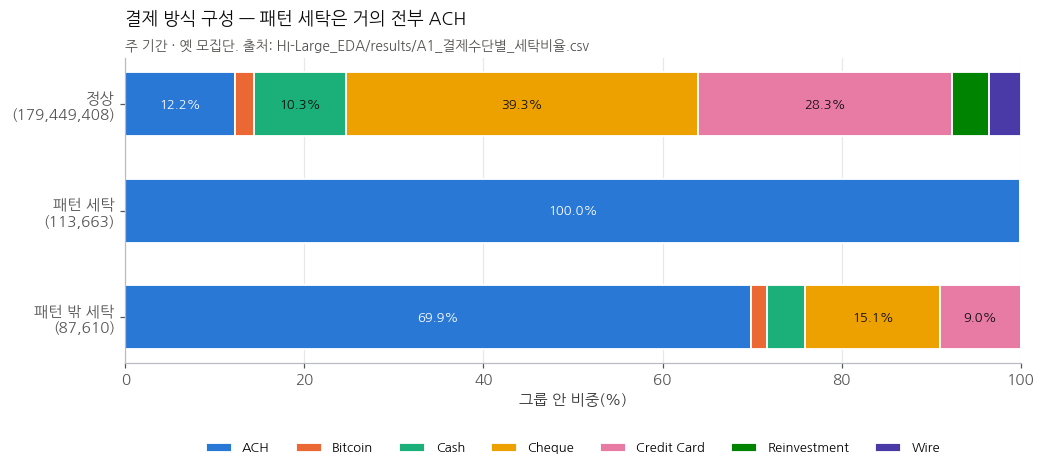

In [42]:
A1 = rd(RES / 'A1_결제수단별_세탁비율.csv')
pm = A1[A1.범위 == '주기간(전처리 대상)'].set_index('결제수단').reindex(FMT7)
pm['행 비중_pct'] = 100 * pm['거래수'] / pm['거래수'].sum()
for g in ('정상', '패턴 세탁', '패턴 밖 세탁'):
    pm[f'{g} 중 비중_pct'] = 100 * pm[g] / pm[g].sum()
display(pm[['거래수', '행 비중_pct', '정상', '패턴 세탁', '패턴 밖 세탁', '패턴 세탁 중 비중_pct', '패턴 밖 세탁 중 비중_pct', '세탁비율(%)']].round(4))
print('■ 꼬리와 중복 제거된 행'); display(A1[A1.범위 != '주기간(전처리 대상)'].query('거래수 > 0')[['범위', '결제수단', '거래수', '정상', '패턴 세탁', '패턴 밖 세탁']])

# 그림 4-1. 그룹별 결제 방식 구성(100% 누적)
G3N = ['정상', '패턴 세탁', '패턴 밖 세탁']
fig, ax = plt.subplots(figsize=(10.5, 3.6)); y = np.arange(3)[::-1]
left = np.zeros(3)
for f in FMT7:
    v = np.array([pm.loc[f, f'{g} 중 비중_pct'] for g in G3N])
    ax.barh(y, v, left=left, color=C_FMT[f], height=0.6, edgecolor='white', linewidth=1.2, label=f)
    for yi, l_, vi in zip(y, left, v):
        if vi >= 6:
            ax.text(l_ + vi / 2, yi, f'{vi:.1f}%', ha='center', va='center', fontsize=8.5, color=ink_on(C_FMT[f]))
    left += v
ax.set_yticks(y); ax.set_yticklabels([f'{g}\n({int(pm[g].sum()):,})' for g in G3N]); ax.set_xlim(0, 100); ax.set_xlabel('그룹 안 비중(%)')
ax.legend(frameon=False, fontsize=8.5, ncol=7, loc='upper center', bbox_to_anchor=(0.5, -0.22))
title(ax, '결제 방식 구성 — 패턴 세탁은 거의 전부 ACH', '주 기간 · 옛 모집단. 출처: HI-Large_EDA/results/A1_결제수단별_세탁비율.csv')
savefig(fig, 'S4_1_결제방식_구성.png')

**해석**
- 결제 7종 비중: Cheque 39.29 · Credit Card 28.31 · **ACH 12.29** · Cash 10.25 · Reinvestment 4.12 · Wire 3.57 · Bitcoin 2.17%.
- **패턴 세탁 113,663 중 113,650(99.99%)이 ACH** 다(Bitcoin 10 · Wire 3). 패턴 밖은 ACH 61,245(69.9%)이고 나머지 방식에 퍼져 있다. **Reinvestment 7,410,555행에는 세탁이 0** 이다.
- 꼬리 40,719행 중 40,714행이 ACH 다. 꼬리 정상 16,446행 중 16,445행도 ACH 다. 이 정상 행이 숨은 양성인지는 안 봤다(부록 B #7).
- 결제 방식은 이 쏠림 때문에 **피처에서 뺐다**(사용자 결정, 계속 제외).

### 4-2. 통화 · 환전 · 금액 [저장 결과]

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A2_송금통화별_세탁비율.csv  (3,833 B · 45행)


,거래수,행 비중_pct,패턴 세탁,패턴 밖 세탁,패턴 비율(%),패턴 밖 비율(%)
송금통화,,,,,,
US Dollar,65823422,36.6397,47807,32458,0.0726,0.0493
Euro,41201239,22.9341,34163,21318,0.0829,0.0517
Yuan,13117155,7.3015,9088,6379,0.0693,0.0486
Shekel,7933227,4.4159,730,3702,0.0092,0.0467
Canadian Dollar,6075361,3.3818,599,2824,0.0099,0.0465
UK Pound,5737512,3.1937,6446,2685,0.1123,0.0468
Ruble,5489623,3.0557,5441,2567,0.0991,0.0468
Australian Dollar,5181723,2.8843,2195,2485,0.0424,0.0480
Yen,4815653,2.6806,4158,2287,0.0863,0.0475


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A2b_환전거래_세탁.csv  (642 B · 6행)


,범위,통화 관계,거래수,정상,패턴 세탁,패턴 밖 세탁,세탁수,세탁비율(%),패턴 비율(%),패턴 밖 비율(%)
0,주기간(전처리 대상),같은 통화,176867537,176666264,113663,87610,201273,0.113799,0.064264,0.049534
1,주기간(전처리 대상),환전(송금≠수취),2783144,2783144,0,0,0,0.000000,0.000000,0.000000
2,꼬리,같은 통화,26604,2331,24273,0,24273,91.238160,91.238160,0.000000
3,꼬리,환전(송금≠수취),14115,14115,0,0,0,0.000000,0.000000,0.000000
4,중복 제거된 행,같은 통화,10770,10770,0,0,0,0.000000,0.000000,0.000000
5,중복 제거된 행,환전(송금≠수취),59,59,0,0,0,0.000000,0.000000,0.000000


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A2c_통화별_금액분위수_주기간.csv  (7,184 B · 60행)


,건수,p0,p50,p100,1센트 미만 자리 있는 비율(%)
송금통화,,,,,
Australian Dollar,5181723,0.010000,1179.850000,1.576485e+10,0.007507
Bitcoin,3893619,0.000001,0.068374,2.613963e+06,99.877980
Brazil Real,3544756,0.010000,4785.520000,1.561050e+11,0.020453
Canadian Dollar,6075361,0.010000,1062.800000,6.980051e+10,0.005037
Euro,41201239,0.010000,712.090000,8.948842e+10,0.002728
Mexican Peso,4737782,0.010000,18239.550000,1.152038e+12,0.077589
Ruble,5489623,0.010000,66005.160000,8.158609e+12,0.143817
Rupee,4159431,0.010000,61264.950000,5.387107e+12,0.151776
Saudi Riyal,3180993,0.010000,3207.330000,9.734370e+10,0.005910


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/G7_통화_기간별_등장.csv  (639 B · 15행)
첫 7일(08-01~07)에 송금이 1건 이상인 통화: 15/15 (G7 의 train·val·test 열은 옛 분할이라 쓰지 않음)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V8_약한후보_수치.csv  (3,276 B · 16행)


,항목,분자,분모,비고
3,첫 7일에 없다가 나중에 처음 등장한 송금 통화 수,0,15,"해당 통화 없음 · 첫 7일 최소 건수 264,367(Saudi Riyal) · 첫 7일 행 14,932,226 / 이후 행 164,718,455 · G7 의 첫 7일 송금 건수와 15종 모두 일치=True"
4,첫 7일에 없다가 나중에 처음 등장한 수취 통화 수,0,15,"해당 통화 없음 · 첫 7일 최소 건수 267,941(Saudi Riyal) · 첫 7일 행 14,932,226 / 이후 행 164,718,455"


참고(가정 환율, 옛 분할 범위 열) — 금액 극단값 상위 3:
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B1c_금액_극단값_상위30_USD환산.csv  (2,037 B · 30행)


,raw_row,usd,paid,pay,fmt,group
0,179261856,1.453950e+11,9.737977e+11,Yuan,ACH,정상
1,71724241,1.081719e+11,1.081719e+11,US Dollar,ACH,정상
2,58731790,1.079046e+11,1.079046e+11,US Dollar,ACH,정상


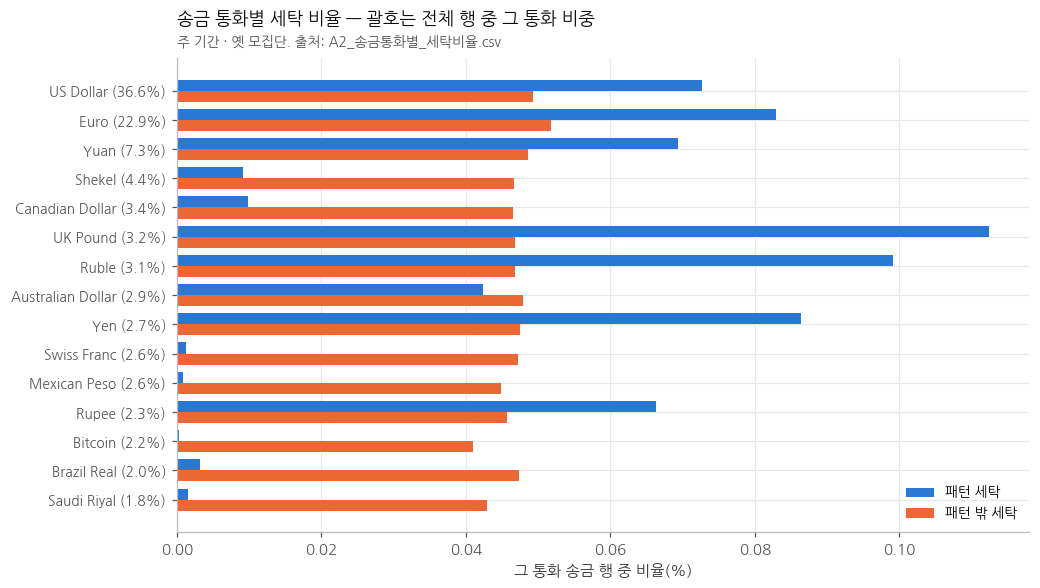

In [43]:
A2 = rd(RES / 'A2_송금통화별_세탁비율.csv')
cm = A2[A2.범위 == '주기간(전처리 대상)'].set_index('송금통화')
cm['행 비중_pct'] = 100 * cm['거래수'] / cm['거래수'].sum()
cm = cm.sort_values('거래수', ascending=False)
display(cm[['거래수', '행 비중_pct', '패턴 세탁', '패턴 밖 세탁', '패턴 비율(%)', '패턴 밖 비율(%)']].round(4))
display(rd(RES / 'A2b_환전거래_세탁.csv'))
A2c = rd(RES / 'A2c_통화별_금액분위수_주기간.csv')
display(A2c[(A2c.그룹 == '전체')].set_index('송금통화')[['건수', 'p0', 'p50', 'p100', '1센트 미만 자리 있는 비율(%)']])
G7 = rd(RES / 'G7_통화_기간별_등장.csv')
print(f"첫 7일(08-01~07)에 송금이 1건 이상인 통화: {int((G7['첫 7일 송금'] > 0).sum())}/{len(G7)} (G7 의 train·val·test 열은 옛 분할이라 쓰지 않음)")
V8 = rd(RES / 'V8_약한후보_수치.csv'); display(V8[V8.세부 == '8-3'][['항목', '분자', '분모', '비고']])
print('참고(가정 환율, 옛 분할 범위 열) — 금액 극단값 상위 3:'); display(rd(RES / 'B1c_금액_극단값_상위30_USD환산.csv').drop(columns=['범위']).head(3))

# 그림 4-2. 송금 통화별 세탁 비율(패턴 · 패턴 밖) — 행 비중이 큰 순
fig, ax = plt.subplots(figsize=(10, 5.6)); y = np.arange(len(cm))[::-1]; h_ = 0.38
ax.barh(y + h_ / 2, cm['패턴 비율(%)'], height=h_, color=C_PAT, label='패턴 세탁')
ax.barh(y - h_ / 2, cm['패턴 밖 비율(%)'], height=h_, color=C_OOP, label='패턴 밖 세탁')
ax.set_yticks(y); ax.set_yticklabels([f"{c} ({v:.1f}%)" for c, v in zip(cm.index, cm['행 비중_pct'])], fontsize=9)
ax.set_xlabel('그 통화 송금 행 중 비율(%)'); ax.legend(frameon=False, fontsize=9, loc='lower right')
title(ax, '송금 통화별 세탁 비율 — 괄호는 전체 행 중 그 통화 비중', '주 기간 · 옛 모집단. 출처: A2_송금통화별_세탁비율.csv')
savefig(fig, 'S4_2_통화별_세탁비율.png')

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B1a_통화별_로그금액_히스토그램.csv  (411,976 B · 4,876행)


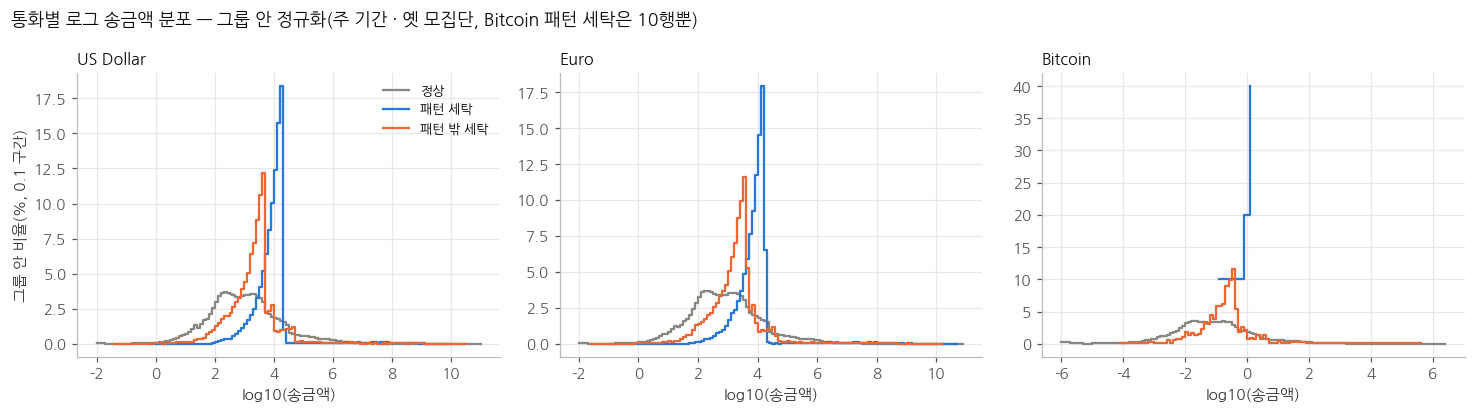

In [44]:
# 그림 4-3. 로그 금액 분포(주 기간, 그룹 안 정규화) — USD · Euro · Bitcoin
B1a = rd(RES / 'B1a_통화별_로그금액_히스토그램.csv')
fig, axs = plt.subplots(1, 3, figsize=(13.5, 3.8))
for ax, cur in zip(axs, ['US Dollar', 'Euro', 'Bitcoin']):
    for g, c in (('정상', C_NORM), ('패턴 세탁', C_PAT), ('패턴 밖 세탁', C_OOP)):
        s = B1a[(B1a.범위 == '주기간(전처리 대상)') & (B1a.그룹 == g) & (B1a.송금통화 == cur)].sort_values('log10금액_하한')
        ax.step(s['log10금액_하한'], 100 * s['건수'] / s['건수'].sum(), where='post', color=c, lw=1.5, label=g)
    ax.set_title(cur, loc='left', fontsize=10.5, color=INK); ax.set_xlabel('log10(송금액)')
axs[0].set_ylabel('그룹 안 비율(%, 0.1 구간)'); axs[0].legend(frameon=False, fontsize=8.5)
fig.suptitle('통화별 로그 송금액 분포 — 그룹 안 정규화(주 기간 · 옛 모집단, Bitcoin 패턴 세탁은 10행뿐)', x=0.01, ha='left', fontsize=11.5, color=INK)
fig.tight_layout(); savefig(fig, 'S4_3_로그금액_분포.png')

**해석**
- **통화는 15종**이다. 송금·수취 어휘가 같다. 송금 비중은 USD 36.64 · Euro 22.93 · Yuan 7.30% 순이다. 15종 모두 첫 7일부터 나온다(G7 · V8 8-3: 나중에 처음 나온 통화 0/15).
- **환전 거래(송금 통화 ≠ 수취 통화) 2,783,144행에 세탁이 0** 이다. 꼬리 환전 14,115행도 0 이다.
- 금액: 음수·0 없음. 최소 0.01(법정 통화)이고 Bitcoin 은 0.000001 이다. Bitcoin 행의 99.88% 는 1센트 미만 자리가 있다(§6 의 가짜 중복과 이어짐). 최대는 Ruble 8,158,609,321,727.61 이다.
- 36번째 피처 `amt_z_pay_ccy` 의 통화별 기준(08-01~07)은 `tgnn36_20260928/results/A1_amtz_통화별_보정통계.csv` 에 있다. 그 7일이 대표성이 있는지는 안 봤다(부록 B #3).

### 4-3. 시각 [저장 결과]

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B1b_시각별_분포.csv  (12,173 B · 216행)


시,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
그룹,,,,,,,,,,,,,,,,,,,,,,,,
정상,10.39,3.90,3.90,3.89,3.89,3.90,3.90,3.90,3.90,3.90,3.89,3.90,3.90,3.90,3.90,3.90,3.90,3.89,3.90,3.89,3.90,3.89,3.89,3.89
패턴 세탁,2.27,2.24,2.15,2.24,2.23,3.51,3.36,3.41,4.85,4.89,5.03,7.46,7.45,7.06,6.80,6.91,6.83,4.93,5.03,4.88,1.64,1.64,1.62,1.59
패턴 밖 세탁,4.34,4.11,4.22,4.07,4.10,4.18,4.24,4.23,4.12,4.13,4.19,4.13,4.25,4.09,4.12,4.23,4.15,4.22,4.16,4.08,4.22,4.06,4.14,4.20


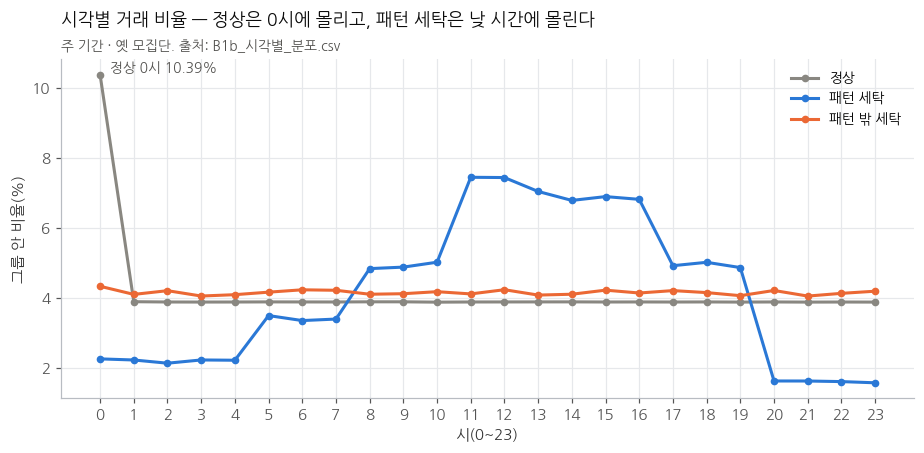

In [45]:
B1b = rd(RES / 'B1b_시각별_분포.csv'); hb = B1b[B1b.범위 == '주기간(전처리 대상)']
pv = hb.pivot(index='시', columns='그룹', values='그룹 내 비율(%)')[['정상', '패턴 세탁', '패턴 밖 세탁']]
display(pv.round(2).T)
fig, ax = plt.subplots(figsize=(10, 4))
for g, c in (('정상', C_NORM), ('패턴 세탁', C_PAT), ('패턴 밖 세탁', C_OOP)):
    ax.plot(pv.index, pv[g], color=c, lw=2, marker='o', ms=4, label=g)
ax.text(0.3, pv.loc[0, '정상'], f"정상 0시 {pv.loc[0, '정상']:.2f}%", fontsize=9, color=INK2, va='bottom')
ax.set_xticks(range(24)); ax.set_xlabel('시(0~23)'); ax.set_ylabel('그룹 안 비율(%)'); ax.legend(frameon=False, fontsize=9)
title(ax, '시각별 거래 비율 — 정상은 0시에 몰리고, 패턴 세탁은 낮 시간에 몰린다', '주 기간 · 옛 모집단. 출처: B1b_시각별_분포.csv')
savefig(fig, 'S4_4_시각분포.png')

**해석**
- 정상 거래는 **0시에 10.39%** 가 몰리고 다른 시각은 약 3.9% 로 고르다. 자정 일괄 거래일 수 있다(추정, 부록 B #6).
- 패턴 세탁은 11~16시에 6.8~7.5% 로 몰린다. 패턴 밖은 4.1~4.3% 로 고르다.

### 4-4. 처음 쓰는 통화 + 같은 분 자기 환전 짝
- **처음 쓰는 통화**: 이전 송금이 있는 계좌가 그 통화로 처음 보냄. **같은 분 짝**: 같은 송신 계좌가 같은 분에 보낸 다른 거래.
- 원래 계산 위치:

| 결과 | 원래 코드 | 입력 | 이 노트북 |
|---|---|---|---|
| 플래그 두 개(처음 통화 · 같은 분 짝) | `notebooks/08` cell 3 · 4 → cell 10 이 `_work/g08_targets_packed.npz`(920 MB)로 저장 | cell 2 의 31열 행렬(지워짐) | **옮기지 않음**(cell 2 입력 없음). 저장된 npz 는 있다 |
| H2 겹침 · H3 짝의 정체 | `notebooks/09` cell 9(25줄) · cell 11(66줄, 약 9 GiB) + 경로 cell 1 | g08 npz · index_full · interim · new_proc2raw (모두 있음) | 무거운 셀 `H2_H3`(꺼짐) — H3 가 H2 셀의 변수를 써서 한 함수로 묶음 |
| V3 재집계 · 환전 시간차 | `notebooks/13_V3_통화전환_시간차.ipynb` 코드 셀 전부(541줄) | g08 npz · raw_grp/split.npy · interim · new_proc2raw (모두 있음) | 무거운 셀 `V3`(꺼짐) |

In [46]:
# [무거움 · 기본 꺼짐] 원본: notebooks/09_31열_판정근거.ipynb cell 1 · 9 · 11
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: H2 · H3 쓰기 R(results) → OUT. 읽기(R / G5 …)는 그대로
def _heavy_H2_H3():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    # ── 원본 09_31열_판정근거.ipynb cell 1 ──
    import numpy as np
    import pandas as pd
    from pathlib import Path

    R = Path('/workspace/Final_preprocess/HI-Large_EDA/results')
    W = Path('/workspace/Final_preprocess/HI-Large_EDA/_work')
    pd.set_option('display.width', 250)
    pd.set_option('display.max_columns', 30)
    rd = lambda f: pd.read_csv(R / f)

    # ── 원본 09_31열_판정근거.ipynb cell 9 ──
    display(rd('G5_같은분_짝_구성.csv'))
    z = np.load(W / 'g08_targets_packed.npz')
    names = list(z['names'])
    n = int(z['n'])
    gt = z['gt']
    unpack = lambda nm: np.unpackbits(z[f't{names.index(nm)}'])[:n].astype(bool)
    new_ccy = unpack('송신 계좌가 처음 쓰는 통화(이력 있는 계좌)')
    twin = unpack('같은 분 같은 송신 계좌 2건+')
    TYPE = {-1: '정상', 0: 'FAN-OUT', 1: 'FAN-IN', 2: 'CYCLE', 3: 'SCATTER-GATHER', 4: 'GATHER-SCATTER',
            5: 'BIPARTITE', 6: 'STACK', 7: 'RANDOM', 8: '패턴 밖 세탁'}
    rows = []
    for name, m in [('정상', gt == -1), ('패턴 세탁 전체', (gt >= 0) & (gt <= 7)), ('패턴 밖 세탁', gt == 8)] + \
                   [(TYPE[k], gt == k) for k in range(8)]:
        a, b = new_ccy[m], twin[m]
        tot = int(m.sum())
        rows.append({'그룹': name, '행': tot,
                     '처음 통화 & 같은 분 짝(%)': 100 * (a & b).sum() / tot,
                     '처음 통화만(%)': 100 * (a & ~b).sum() / tot,
                     '같은 분 짝만(%)': 100 * (~a & b).sum() / tot,
                     '둘 다 아님(%)': 100 * (~a & ~b).sum() / tot,
                     '짝 있는 행 중 처음 통화(%)': 100 * (a & b).sum() / max(b.sum(), 1),
                     '짝 없는 행 중 처음 통화(%)': 100 * (a & ~b).sum() / max((~b).sum(), 1)})
    H2 = pd.DataFrame(rows)
    display(H2.round(2))
    H2.round(4).to_csv(OUT / 'H2_처음통화_같은분짝_겹침.csv', index=False)

    # ── 원본 09_31열_판정근거.ipynb cell 11 ──
    import gc
    import json
    import pyarrow.parquet as pq

    MAIN = Path('/workspace/processed_9class/HI-Large_main')
    INTERIM = Path('/workspace/processed_9class/_nb_scratch/interim/HI-Large')
    ALIGN = Path('/workspace/Final_preprocess/HI-Large_EDA/reprocess/align')
    idx = np.load(MAIN / 'index_full.npz')
    src = idx['src_id'].astype(np.int64)
    dst = idx['dst_id']
    key = (src << 20) | idx['ts_min'].astype(np.int64)
    assert len(key) == n
    o = np.argsort(key)
    ks = key[o]
    parts = sorted(INTERIM.glob('part-*.parquet'))
    p2r = np.load(ALIGN / 'new_proc2raw.npy').astype(np.int64)


    def raw_col(c):
        full = np.concatenate([pd.read_parquet(f, columns=[c])[c].to_numpy() for f in parts]).astype(np.int8)
        out = full[p2r]
        del full
        return out


    payc, recvc = raw_col('pay_code'), raw_col('recv_code')
    del p2r
    gc.collect()
    pay_v = pd.read_parquet(INTERIM / 'pay.parquet')['key'].tolist()


    def twin_profile(J):
        lo = np.searchsorted(ks, key[J], 'left')
        hi = np.searchsorted(ks, key[J], 'right')
        rec = np.zeros((len(J), 6), np.int64)
        for i, (j, a, b) in enumerate(zip(J, lo, hi)):
            oth = o[a:b]
            oth = oth[oth != j]
            exch = payc[oth] != recvc[oth]
            rec[i] = (len(oth), exch.sum(), (src[oth] == dst[oth]).sum(),
                      (exch & (recvc[oth] == payc[j])).sum(),
                      (payc[oth] == payc[j]).sum(), ((gt[oth] >= 0)).sum())
        d = pd.DataFrame(rec, columns=['짝 수', '환전 짝', '자기송금 짝', '환전 짝 중 받은 통화=이번 송금 통화', '같은 송금 통화 짝', '세탁 라벨 짝'])
        return {'행': len(J), '짝 수 평균': d['짝 수'].mean(),
                '짝에 환전 있음(%)': 100 * (d['환전 짝'] > 0).mean(),
                '짝에 자기송금 있음(%)': 100 * (d['자기송금 짝'] > 0).mean(),
                '짝에 "받은 통화=이번 송금 통화"인 환전 있음(%)': 100 * (d['환전 짝 중 받은 통화=이번 송금 통화'] > 0).mean(),
                '짝에 같은 송금 통화 있음(%)': 100 * (d['같은 송금 통화 짝'] > 0).mean(),
                '짝에 세탁 라벨 있음(%)': 100 * (d['세탁 라벨 짝'] > 0).mean()}


    rng = np.random.default_rng(20260917)
    pat = (gt >= 0) & (gt <= 7)
    groups = [('패턴·처음 통화', np.flatnonzero(pat & new_ccy)),
              ('패턴·짝 있음·처음 통화 아님', np.flatnonzero(pat & twin & ~new_ccy)),
              ('정상·처음 통화', np.flatnonzero((gt == -1) & new_ccy)),
              ('정상·짝 있음·처음 통화 아님(무작위 5만)', np.sort(rng.choice(np.flatnonzero((gt == -1) & twin & ~new_ccy), 50_000, replace=False))),
              ('패턴 밖·짝 있음', np.flatnonzero((gt == 8) & twin))]
    H3 = pd.DataFrame([{'그룹': g, **twin_profile(J)} for g, J in groups])
    display(H3.round(2))
    H3.round(4).to_csv(OUT / 'H3_처음통화_짝의_정체.csv', index=False)
    pc = pd.Series(payc[pat & new_ccy]).map(dict(enumerate(pay_v))).value_counts(normalize=True).mul(100).round(2)
    pa = pd.Series(payc[pat & ~new_ccy]).map(dict(enumerate(pay_v))).value_counts(normalize=True).mul(100).round(2)
    display(pd.DataFrame({'패턴·처음 통화 송금 통화(%)': pc, '패턴·그 밖 송금 통화(%)': pa}).fillna(0))
    del key, o, ks, src, dst, payc, recvc
    gc.collect()


if HEAVY['H2_H3']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_H2_H3()
else:
    print("HEAVY['H2_H3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['H2_H3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [47]:
# [무거움 · 기본 꺼짐] 원본: notebooks/13_V3_통화전환_시간차.ipynb cell 1 · 3 · 5 · 7 · 9 · 11 · 13 · 15 · 17 · 19 · 21
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: 결과 폴더 OUTDIR = RES → OUT_NB(읽기 RES 는 그대로)
def _heavy_V3():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    # ── 원본 13_V3_통화전환_시간차.ipynb cell 1 ──
    # 공통 정의(자립형: 경로·상수 인라인. eda_common 은 값이 같은지 대조만 하고 C.log 는 쓰지 않는다)
    import gc, json, os, sys, time
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import pyarrow.parquet as pq

    T_START = time.time()
    EDA = Path('/workspace/Final_preprocess/HI-Large_EDA')
    INTERIM = Path('/workspace/processed_9class/_nb_scratch/interim/HI-Large')
    MAIN = Path('/workspace/processed_9class/HI-Large_main')
    RAW_DIR = Path('/workspace/IBM_AML_dataset')
    WORK, RES, ALIGN = EDA / '_work', EDA / 'results', EDA / 'reprocess' / 'align'
    CLASS_NAMES = ['FAN-OUT', 'FAN-IN', 'CYCLE', 'SCATTER-GATHER', 'GATHER-SCATTER', 'BIPARTITE', 'STACK', 'RANDOM']
    FLAG_NAME = '송신 계좌가 처음 쓰는 통화(이력 있는 계좌)'
    TWIN_NAME = '같은 분 같은 송신 계좌 2건+'
    TB = 20                                   # 시각 비트 수 — 08 셀 2 와 같은 값
    MASK = (1 << TB) - 1
    CHUNK = 20_000_000                        # 조각 크기 — 임의(이 점검용, 메모리 절약)
    H1_MIN, D1_MIN = 60, 1440                 # 시간차 구간 경계(분) — 임의(이 점검용: 작업 지시서의 1시간·1일)
    QS = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]   # 분위수 점 — 임의(이 점검용)
    N_CSV_CHECK = 200_000                     # CSV 대조 행수 — 임의(이 점검용)
    DRY = int(os.environ.get('V3_DRY', '0'))
    OUTDIR = Path(os.environ['V3_DRY_OUT']) if DRY else OUT_NB   # (통합본) 원래 RES(results)
    PEAK = [0.0]
    pd.set_option('display.width', 250, 'display.max_columns', 40, 'display.max_rows', 200, 'display.max_colwidth', 120)


    def anon_gib():
        """컨테이너 cgroup 의 anon 메모리(GiB) — eda_common.anon_gib 와 같은 정의. 피크를 기록한다."""
        for l in open('/sys/fs/cgroup/memory.stat'):
            if l.startswith('anon '):
                v = int(l.split()[1]) / 2**30
                PEAK[0] = max(PEAK[0], v)
                return v
        return float('nan')


    def drop_cache(path):
        """읽은 파일의 페이지 캐시를 비운다(캐시도 cgroup 한도에 잡힘 — 08 셀 2 의 drop_cache 와 같은 처리)."""
        try:
            fd = os.open(str(path), os.O_RDONLY)
            os.posix_fadvise(fd, 0, 0, os.POSIX_FADV_DONTNEED)
            os.close(fd)
        except OSError:
            pass


    def say(msg):
        print(f'[+{time.time() - T_START:6.0f}s · anon {anon_gib():5.2f} GiB] {msg}', flush=True)


    def pct(a, b):
        return 100.0 * a / b if b else float('nan')


    sys.path.insert(0, str(EDA))
    import eda_common as C      # 읽기만
    assert C.CLASS_NAMES == CLASS_NAMES and C.INTERIM == INTERIM and C.MAIN == MAIN
    meta = json.loads((MAIN / 'features_meta.json').read_text())
    OFFSET = int(meta['split']['ts_offset_epoch_min'])
    pay_v = C.vocab('pay')
    assert pay_v == C.vocab('recv') and len(pay_v) <= 16
    TYPE = {-1: '정상', **dict(enumerate(CLASS_NAMES)), 8: '패턴 밖 세탁'}
    say(f'시작 · DRY={DRY} · 결과 폴더 {OUTDIR} · 시각 기준점 {OFFSET}')

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 3 ──
    # npz 에서 플래그·그룹을 풀고 그룹별로 센다
    z = np.load(WORK / 'g08_targets_packed.npz')
    names = [str(x) for x in z['names']]
    n = int(z['n'])
    gt = z['gt']                                   # int8: -1 정상 / 0~7 유형 / 8 패턴 밖
    flag = np.unpackbits(z[f't{names.index(FLAG_NAME)}'])[:n].astype(bool)
    twin = np.unpackbits(z[f't{names.index(TWIN_NAME)}'])[:n].astype(bool)
    assert len(gt) == n == len(flag)
    L0 = pd.read_csv(RES / 'L0_labels_summary.csv').set_index('group')
    exp = {g: int(L0.loc[g, ['train', 'val', 'test']].sum()) for g in ('정상', '패턴 세탁', '패턴 밖 세탁')}
    got = {'정상': int((gt == -1).sum()), '패턴 세탁': int(((gt >= 0) & (gt <= 7)).sum()), '패턴 밖 세탁': int((gt == 8).sum())}
    print('모집단 행수 n =', f'{n:,}', '· L0 기대', exp, '· npz', got)
    assert exp == got and sum(got.values()) == n

    def fold(c):
        """grp+1 (0 정상, 1~8 유형, 9 패턴 밖) 별 건수 → 그룹 이름별 건수."""
        return {'정상': int(c[0]), '패턴 세탁 전체': int(c[1:9].sum()), '패턴 밖 세탁': int(c[9]), '세탁 전체(패턴+패턴 밖)': int(c[1:].sum()),
                **{CLASS_NAMES[k]: int(c[k + 1]) for k in range(8)}, '전체': int(c.sum())}


    g1 = gt.astype(np.int64) + 1                   # 마스크 13개를 따로 만들지 않고 bincount 로 센다(메모리 절약)
    den_c = fold(np.bincount(g1, minlength=10))
    num_c = fold(np.bincount(g1[flag], minlength=10))
    solo_c = fold(np.bincount(g1[flag & ~twin], minlength=10))
    del g1
    A = pd.DataFrame([{'그룹': g, '분모(그 그룹 전체 행)': den_c[g], '분자(플래그 행, 08 npz)': num_c[g], '비율(%)': pct(num_c[g], den_c[g]),
                       '그중 같은 분 같은 송신 2건+ 아님(H2 "처음 통화만")': solo_c[g]} for g in den_c])

    # 기존 표와 대조(H1 = 3그룹, H2 = 3그룹 + 8유형)
    H1 = pd.read_csv(RES / 'H1_후보_종합표.csv').set_index('후보').loc[FLAG_NAME]
    H2 = pd.read_csv(RES / 'H2_처음통화_같은분짝_겹침.csv').set_index('그룹')
    h2 = (H2['처음 통화 & 같은 분 짝(%)'] + H2['처음 통화만(%)'])
    A['기존 H2(%)'] = A['그룹'].map(h2)
    A['기존 H1(%)'] = A['그룹'].map({'정상': H1['정상(%)'], '패턴 세탁 전체': H1['패턴(%)'], '패턴 밖 세탁': H1['패턴 밖(%)']})
    A['H2 분모(행)'] = A['그룹'].map(H2['행'])
    A['재집계−H2(%p)'] = A['비율(%)'].round(4) - A['기존 H2(%)']
    A['재집계−H1(%p)'] = A['비율(%)'].round(4) - A['기존 H1(%)']
    display(A.round(4))
    del twin
    gc.collect()
    say('(a) npz 재집계 완료')

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 5 ──
    # 전처리 행 → 원본 행. 라벨·모집단 일치 확인(조각 단위)
    p2r = np.load(ALIGN / 'new_proc2raw.npy', mmap_mode='r')
    assert len(p2r) == n
    grp_raw = np.load(WORK / 'raw_grp.npy')            # int8 180MB — 통째로 읽는다
    sp_raw = np.load(WORK / 'raw_split.npy')           # int8 180MB
    drop_cache(WORK / 'raw_grp.npy')
    drop_cache(WORK / 'raw_split.npy')
    assert int((sp_raw >= 0).sum()) == n               # 모집단 = raw_split ≥ 0
    n_raw = len(grp_raw)
    assert n_raw == C.n_raw() == len(sp_raw)
    bad_lab = bad_pop = 0
    for a in range(0, n, CHUNK):
        r = np.asarray(p2r[a:a + CHUNK]).astype(np.int64)
        bad_lab += int((grp_raw[r] != gt[a:a + CHUNK]).sum())
        bad_pop += int((sp_raw[r] < 0).sum())
        del r
    print(f'gt(08) ≠ raw_grp[p2r] 인 행: {bad_lab:,} · raw_split<0 인데 전처리에 있는 행: {bad_pop:,}')
    assert bad_lab == 0 and bad_pop == 0
    J = np.flatnonzero(flag)
    rawJ = np.asarray(p2r[J]).astype(np.int64)
    flag_raw = np.zeros(n_raw, bool)
    flag_raw[rawJ] = True
    assert int(flag_raw.sum()) == len(J)
    print(f'플래그 행 {len(J):,} → 원본 행 번호로 옮김(중복 없음)')
    if DRY:
        flag_raw[DRY:] = False
        print(f'DRY: 원본 앞 {DRY:,}행 안의 플래그 행 {int(flag_raw.sum()):,} 만 쓴다')
    del flag, gt, J, rawJ, z
    drop_cache(WORK / 'g08_targets_packed.npz')
    drop_cache(ALIGN / 'new_proc2raw.npy')
    gc.collect()
    say('원본 행 기준 플래그 준비')

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 7 ──
    # 1차 훑기: (1) 계좌·통화별 / 계좌별 첫 송금 분  (2) 환전 행  (3) 플래그 행  (4) 자기송금 건수
    ps = sorted(INTERIM.glob('part-*.parquet'))
    sizes = [pq.ParquetFile(f).metadata.num_rows for f in ps]
    starts = np.cumsum([0] + sizes)
    assert int(starts[-1]) == n_raw
    n_nodes = pq.ParquetFile(INTERIM / 'nodes.parquet').metadata.num_rows
    IMAX = np.iinfo(np.int32).max
    min_combo = np.full(n_nodes * 16, IMAX, np.int32)      # (송신 계좌, 송금 통화) 첫 분
    min_src = np.full(n_nodes, IMAX, np.int32)             # 송신 계좌 첫 분
    COLS1 = ['ts_epoch_min', 'src_id', 'dst_id', 'cents', 'recv_cents', 'paid', 'recv', 'pay_code', 'recv_code']


    def upd_min(arr, key, val):
        """key 별 val 최솟값으로 arr 갱신(정렬 + reduceat)."""
        if len(key) == 0:
            return
        o = np.argsort(key, kind='stable')
        k, v = key[o], val[o]
        st = np.flatnonzero(np.r_[True, k[1:] != k[:-1]])
        u = k[st]
        arr[u] = np.minimum(arr[u], np.minimum.reduceat(v, st))


    def pick(t, m, a, g):
        d = t.loc[m].copy()
        d.insert(0, 'raw_row', (a + np.flatnonzero(m)).astype(np.int64))
        d['grp'] = g[m]
        return d


    conv_fr, snd_fr = [], []
    cnt = {'모집단 행': 0, '자기송금 행': 0, '환전 행': 0, '자기 환전 행': 0}
    for i, f in enumerate(ps):
        a, e = int(starts[i]), int(starts[i + 1])
        if DRY and a >= DRY:
            break
        t = pd.read_parquet(f, columns=COLS1)
        drop_cache(f)
        if DRY:
            t = t.iloc[:DRY - a]
            e = a + len(t)
        pop = np.asarray(sp_raw[a:e]) >= 0
        g = np.asarray(grp_raw[a:e])
        tsr = t['ts_epoch_min'].to_numpy() - OFFSET
        assert (not pop.any()) or (tsr[pop].min() >= 0 and tsr[pop].max() <= MASK)
        t['ts'] = tsr.astype(np.int32)
        t = t.drop(columns='ts_epoch_min')
        s = t['src_id'].to_numpy()
        pc = t['pay_code'].to_numpy()
        upd_min(min_combo, (s[pop].astype(np.int64) << 4) | pc[pop], t['ts'].to_numpy()[pop])
        upd_min(min_src, s[pop].astype(np.int64), t['ts'].to_numpy()[pop])
        is_self = s == t['dst_id'].to_numpy()
        is_conv = pc != t['recv_code'].to_numpy()
        cnt['모집단 행'] += int(pop.sum())
        cnt['자기송금 행'] += int((pop & is_self).sum())
        cnt['환전 행'] += int((pop & is_conv).sum())
        cnt['자기 환전 행'] += int((pop & is_conv & is_self).sum())
        fl = flag_raw[a:e]
        assert not (fl & ~pop).any()
        conv_fr.append(pick(t, pop & is_conv, a, g))
        snd_fr.append(pick(t, fl, a, g))
        del t, pop, g, tsr, s, pc, is_self, is_conv, fl
        if i % 15 == 0:
            gc.collect()
            say(f'1차 파트 {i + 1}/{len(ps)} · 환전 행 누계 {cnt["환전 행"]:,}')
    conv = pd.concat(conv_fr, ignore_index=True)
    snd = pd.concat(snd_fr, ignore_index=True)
    del conv_fr, snd_fr
    gc.collect()
    conv['is_self'] = conv['src_id'].to_numpy() == conv['dst_id'].to_numpy()
    print(cnt)
    print(f'환전 행 {len(conv):,} (자기 {int(conv.is_self.sum()):,} / 타계좌 {int((~conv.is_self).sum()):,}) · 플래그 행 {len(snd):,}')
    if not DRY:
        assert cnt['모집단 행'] == n and len(snd) == int(flag_raw.sum())
    say('1차 훑기 완료')

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 9 ──
    # 2차 훑기: 독립 재계산 플래그와 08 플래그의 행 단위 대조 + 그룹별 분자
    ind_cnt = np.zeros(10, np.int64)       # grp+1 → 건수(독립 재계산)
    npz_cnt = np.zeros(10, np.int64)       # grp+1 → 건수(08 플래그, 원본 행 기준으로 다시 셈)
    den_cnt = np.zeros(10, np.int64)
    only_ind = only_npz = 0
    for i, f in enumerate(ps):
        a, e = int(starts[i]), int(starts[i + 1])
        if DRY and a >= DRY:
            break
        t = pd.read_parquet(f, columns=['ts_epoch_min', 'src_id', 'pay_code'])
        drop_cache(f)
        if DRY:
            t = t.iloc[:DRY - a]
            e = a + len(t)
        pop = np.asarray(sp_raw[a:e]) >= 0
        g1 = np.asarray(grp_raw[a:e]).astype(np.int64) + 1
        tsr = (t['ts_epoch_min'].to_numpy() - OFFSET).astype(np.int64)
        s = t['src_id'].to_numpy().astype(np.int64)
        ind = pop & (tsr == min_combo[(s << 4) | t['pay_code'].to_numpy()]) & (min_src[s] < tsr)
        fl = flag_raw[a:e]
        only_ind += int((ind & ~fl).sum())
        only_npz += int((fl & ~ind).sum())
        ind_cnt += np.bincount(g1[ind], minlength=10)
        npz_cnt += np.bincount(g1[fl], minlength=10)
        den_cnt += np.bincount(g1[pop], minlength=10)
        del t, pop, g1, tsr, s, ind, fl
        if i % 30 == 0:
            gc.collect()
            say(f'2차 파트 {i + 1}/{len(ps)}')
    print(f'독립 재계산에만 있는 행 {only_ind:,} · 08 플래그에만 있는 행 {only_npz:,}' + (' (DRY: 앞 N행만이라 첫 사용 분이 달라 불일치가 정상)' if DRY else ''))

    A['독립 재계산 분모'] = A['그룹'].map(fold(den_cnt))
    A['독립 재계산 분자'] = A['그룹'].map(fold(ind_cnt))
    A['독립 재계산 비율(%)'] = [pct(x, y) for x, y in zip(A['독립 재계산 분자'], A['독립 재계산 분모'])]
    A['분자 차(독립−npz)'] = A['독립 재계산 분자'] - A['분자(플래그 행, 08 npz)']
    A['행 단위 불일치(전체)'] = only_ind + only_npz
    display(A[['그룹', '분모(그 그룹 전체 행)', '분자(플래그 행, 08 npz)', '비율(%)', '기존 H2(%)', '기존 H1(%)', '독립 재계산 분모', '독립 재계산 분자',
               '독립 재계산 비율(%)', '분자 차(독립−npz)']].round(4))
    if not DRY:
        assert (A['독립 재계산 분모'] == A['분모(그 그룹 전체 행)']).all()
    OUTDIR.mkdir(parents=True, exist_ok=True)
    A.round(6).to_csv(OUTDIR / 'V3_처음통화_재집계.csv', index=False)
    del min_combo, min_src, flag_raw
    gc.collect()
    say('(a) 저장: V3_처음통화_재집계.csv')

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 11 ──
    # CSV 앞 N행과 parquet 앞 N행의 시각·금액·통화·라벨 대조
    csv = pd.read_csv(RAW_DIR / 'HI-Large_Trans.csv', nrows=N_CSV_CHECK, dtype=str)
    csv.columns = ['ts', 'fb', 'fa', 'tb', 'ta', 'ar', 'rc', 'ap', 'pc', 'pf', 'y']
    p0 = pd.read_parquet(ps[0], columns=['ts_epoch_min', 'src_id', 'dst_id', 'paid', 'recv', 'pay_code', 'recv_code', 'is_pos']).iloc[:N_CSV_CHECK]
    nk = C.node_keys()
    chk = {
        '시각': (pd.to_datetime(csv['ts'], format='%Y/%m/%d %H:%M').to_numpy(dtype='datetime64[m]').astype(np.int64) == p0['ts_epoch_min'].to_numpy()).all(),
        '송신 계좌': ((csv['fb'] + '_' + csv['fa']).to_numpy(dtype=object) == nk[p0['src_id'].to_numpy()]).all(),
        '수신 계좌': ((csv['tb'] + '_' + csv['ta']).to_numpy(dtype=object) == nk[p0['dst_id'].to_numpy()]).all(),
        '송금액': (csv['ap'].astype(float).to_numpy() == p0['paid'].to_numpy()).all(),
        '수취액': (csv['ar'].astype(float).to_numpy() == p0['recv'].to_numpy()).all(),
        '송금 통화': (csv['pc'].to_numpy(dtype=object) == np.array(pay_v, dtype=object)[p0['pay_code'].to_numpy()]).all(),
        '수취 통화': (csv['rc'].to_numpy(dtype=object) == np.array(pay_v, dtype=object)[p0['recv_code'].to_numpy()]).all(),
        '라벨': (csv['y'].astype(int).to_numpy() == p0['is_pos'].to_numpy()).all(),
    }
    print(f'CSV 앞 {len(csv):,}행 대 parquet 앞 {len(p0):,}행 — 열별 전 행 일치:', {k: bool(v) for k, v in chk.items()})
    assert all(chk.values())
    del csv, p0
    gc.collect()

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 13 ──
    # 환전 행 정렬 키: (계좌, 받은 통화, 분) → 플래그 행의 (계좌, 송금 통화, 분) 으로 찾는다
    def ckey(acc, ccy, ts):
        return (((acc.astype(np.int64) << 4) | ccy.astype(np.int64)) << TB) | ts.astype(np.int64)


    def sorted_conv(cv):
        k = ckey(cv['src_id'].to_numpy(), cv['recv_code'].to_numpy(), cv['ts'].to_numpy())
        o = np.lexsort((cv['raw_row'].to_numpy(), k))            # 키 → 원본 행 번호 순
        return k[o], cv.iloc[o].reset_index(drop=True)


    # cents 정의 확인: 뽑은 행 전부에서 cents == rint(paid×100), recv_cents == rint(recv×100)
    for nm_, d_ in (('환전 행', conv), ('플래그 행', snd)):
        ok1 = (np.rint(d_['paid'].to_numpy() * 100).astype(np.int64) == d_['cents'].to_numpy()).all()
        ok2 = (np.rint(d_['recv'].to_numpy() * 100).astype(np.int64) == d_['recv_cents'].to_numpy()).all()
        print(f'{nm_} {len(d_):,}행 · cents == rint(paid×100): {bool(ok1)} · recv_cents == rint(recv×100): {bool(ok2)}')
    kC, cvS = sorted_conv(conv[conv.is_self])                    # 엄격한 정의: 자기 환전만
    kL, cvL = sorted_conv(conv)                                  # 느슨한 정의(H3): 같은 송신 계좌의 환전(자기송금 조건 없음)
    kS = ckey(snd['src_id'].to_numpy(), snd['pay_code'].to_numpy(), snd['ts'].to_numpy())
    pos = np.searchsorted(kC, kS, 'right') - 1                   # 시각 ≤ 송금 시각 인 마지막 환전
    has = (pos >= 0) & ((kC[np.maximum(pos, 0)] >> TB) == (kS >> TB))
    delta = np.where(has, (kS & MASK) - (kC[np.maximum(pos, 0)] & MASK), -1)
    lo, hi = np.searchsorted(kC, kS, 'left'), np.searchsorted(kC, kS, 'right')
    snd['delta'] = delta
    snd['k_same_min'] = hi - lo                                  # 같은 분 자기 환전 짝 수
    snd['k_same_min_loose'] = np.searchsorted(kL, kS, 'right') - np.searchsorted(kL, kS, 'left')
    # 참고: 이후(엄격히 나중 분)에만 같은 조건의 자기 환전이 있는지 — '없음' 행의 내용 확인용
    nxt = np.searchsorted(kC, kS, 'right')
    snd['has_later'] = (nxt < len(kC)) & ((kC[np.minimum(nxt, len(kC) - 1)] >> TB) == (kS >> TB))
    snd['self_send'] = snd['src_id'].to_numpy() == snd['dst_id'].to_numpy()
    snd['conv_send'] = snd['pay_code'].to_numpy() != snd['recv_code'].to_numpy()
    g = snd['grp'].to_numpy()
    snd['g3'] = np.where(g < 0, '정상', np.where(g == 8, '패턴 밖 세탁', '패턴 세탁'))
    BIN_NAMES = ['0분(같은 분)', f'1~{H1_MIN}분', f'{H1_MIN + 1}~{D1_MIN}분(1시간 초과~1일)', f'{D1_MIN}분 초과(1일 초과)', '해당 환전 없음(이전·같은 분)']
    snd['bin'] = np.select([delta == 0, (delta >= 1) & (delta <= H1_MIN), (delta > H1_MIN) & (delta <= D1_MIN), delta > D1_MIN], BIN_NAMES[:4], BIN_NAMES[4])
    print('플래그 행 그룹:', snd['g3'].value_counts().to_dict())
    print('주의: timestamp 는 분 해상도 — "0분"은 같은 분이라는 뜻이며, 분 안에서 환전이 먼저였는지는 시각으로 알 수 없다.')

    SUBS = [('패턴 세탁', snd.g3 == '패턴 세탁'), ('정상', snd.g3 == '정상'), ('패턴 밖 세탁', snd.g3 == '패턴 밖 세탁')] + \
           [(CLASS_NAMES[k], snd.grp == k) for k in range(8)]
    B = []
    for gname, m in SUBS:
        den = int(m.sum())
        for b in BIN_NAMES:
            c = int(((snd['bin'] == b) & m).sum())
            B.append({'항목': '시간차(자기 환전·받은 통화=송금 통화, 가장 가까운 이전/같은 분)', '그룹': gname, '구간': b, '건수': c, '분모(그 그룹 플래그 행)': den, '비율(%)': pct(c, den)})
        c = int(((snd['k_same_min_loose'] > 0) & m).sum())
        B.append({'항목': '대조: 느슨한 정의(H3 — 같은 송신 계좌·같은 분 환전, 자기송금 조건 없음)', '그룹': gname, '구간': '0분(같은 분)', '건수': c, '분모(그 그룹 플래그 행)': den, '비율(%)': pct(c, den)})
        c = int(((snd['delta'] != 0) & snd['has_later'] & m).sum())
        B.append({'항목': '참고: 같은 분 짝 없음 중 나중 분에는 같은 조건 자기 환전 있음', '그룹': gname, '구간': '나중 분', '건수': c, '분모(그 그룹 플래그 행)': den, '비율(%)': pct(c, den)})
    B = pd.DataFrame(B)
    display(B[B['그룹'].isin(['패턴 세탁', '정상', '패턴 밖 세탁'])].round(4))
    H3 = pd.read_csv(RES / 'H3_처음통화_짝의_정체.csv').set_index('그룹')
    print('기존 H3 "받은 통화=이번 송금 통화 환전 짝 있음(%)":', H3.iloc[:, 4].loc[['패턴·처음 통화', '정상·처음 통화']].to_dict(), '· H3 행수', H3['행'].loc[['패턴·처음 통화', '정상·처음 통화']].to_dict())
    nz = snd[(snd.delta > 0)]
    print('시간차 > 0(이전 분의 환전이 가장 가까운 것)인 행 수:', {gname: int((nz.g3 == gname).sum()) for gname in ('패턴 세탁', '정상')})
    if len(nz):
        print('  그 행들의 시간차(분) 분위수:', {gname: nz.loc[nz.g3 == gname, 'delta'].quantile([0, .5, 1]).to_dict() for gname in ('패턴 세탁', '정상')})
    say('(b) 시간차 분포 계산')

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 15 ──
    # 같은 분 짝의 원본 행 번호 선후 + 금액 비교용 짝 선택
    rrC = cvS['raw_row'].to_numpy()
    rcC = cvS['recv_cents'].to_numpy()
    rvC = cvS['recv'].to_numpy()
    ns = len(snd)
    n_before = np.zeros(ns, np.int32)
    gap = np.zeros(ns, np.int64)             # 송금 행 번호 − 고른 환전 행 번호(양수 = 환전이 앞)
    chosen = np.full(ns, -1, np.int64)       # cvS 안의 위치
    any_eq_c = np.zeros(ns, bool)            # 후보 중 하나라도 cents 일치
    any_eq_f = np.zeros(ns, bool)
    r_s = snd['raw_row'].to_numpy()
    c_s = snd['cents'].to_numpy()
    p_s = snd['paid'].to_numpy()
    for i in np.flatnonzero(delta == 0):
        c = rrC[lo[i]:hi[i]]
        nb = int(np.searchsorted(c, r_s[i], 'left'))
        n_before[i] = nb
        j = lo[i] + (nb - 1 if nb > 0 else 0)
        chosen[i] = j
        gap[i] = r_s[i] - rrC[j]
        any_eq_c[i] = (rcC[lo[i]:hi[i]] == c_s[i]).any()
        any_eq_f[i] = (rvC[lo[i]:hi[i]] == p_s[i]).any()
    snd['n_before'], snd['gap'], snd['chosen'] = n_before, gap, chosen
    same = snd['delta'] == 0
    O = []
    for gname, m in SUBS[:2]:
        mm = m & same
        den = int(mm.sum())
        for label, c in [('짝 환전 중 하나 이상이 원본 행 번호상 앞', int((mm & (snd.n_before > 0)).sum())),
                         ('짝 환전이 모두 앞', int((mm & (snd.n_before == snd.k_same_min)).sum())),
                         ('짝 환전이 모두 뒤', int((mm & (snd.n_before == 0)).sum())),
                         ('바로 앞 행(행 번호 차 = 1)', int((mm & (snd.gap == 1)).sum())),
                         ('행 번호 차 = 2(환전과 송금 사이에 1행)', int((mm & (snd.gap == 2)).sum())),
                         ('행 번호 차 ≥ 3', int((mm & (snd.gap >= 3)).sum())),
                         ('바로 뒤 행(행 번호 차 = −1)', int((mm & (snd.gap == -1)).sum())),
                         ('같은 분 짝 환전 1개', int((mm & (snd.k_same_min == 1)).sum())),
                         ('같은 분 짝 환전 2개 이상', int((mm & (snd.k_same_min >= 2)).sum()))]:
            O.append({'항목': '같은 분 짝의 원본 CSV 행 번호 선후(참고)', '그룹': gname, '구간': label, '건수': c, '분모(그 그룹 플래그 행)': den, '비율(%)': pct(c, den)})
        print(gname, '· 고른 짝과의 행 번호 차(송금−환전) 분위수:', snd.loc[mm, 'gap'].quantile([0, .01, .05, .25, .5, .75, .95, .99, 1]).round(0).to_dict())
    O = pd.DataFrame(O)
    display(O.round(4))
    BO = pd.concat([B, O], ignore_index=True)
    BO['분모 설명'] = np.where(BO['항목'].str.startswith('같은 분 짝의'), '그 그룹 플래그 행 중 시간차 0분인 행', '그 그룹의 플래그 행 전체')
    BO.round(6).to_csv(OUTDIR / 'V3_환전_시간차_분포.csv', index=False)
    say('(b) 저장: V3_환전_시간차_분포.csv')

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 17 ──
    # (c) 근거표 만들기
    E = []


    def add(kind, grp_name, what, num, den=None, val=None, note=''):
        E.append({'근거': kind, '그룹': grp_name, '값 이름': what, '건수(분자)': num, '분모': den,
                  '비율(%)': pct(num, den) if (den and num is not None) else np.nan, '값': val, '비고': note})


    # 1. 유형별 비율(1절에서 복사)
    for _, r in A.iterrows():
        add('1 유형별 비율', r['그룹'], '플래그 행 / 그 그룹 전체 행', int(r['분자(플래그 행, 08 npz)']), int(r['분모(그 그룹 전체 행)']), note='분모 = 그 그룹 전체 행')

    # 2. 결정성
    for gname, m in SUBS:
        den = int(m.sum())
        if den == 0:
            add('2 결정성', gname, '플래그 행 자체가 0건', 0, 0)
            continue
        add('2 결정성', gname, '같은 분 자기 환전 짝(받은 통화=송금 통화) 없는 플래그 행', int((m & (snd.k_same_min == 0)).sum()), den, note='엄격한 정의(src==dst)')
        add('2 결정성', gname, '같은 분 환전 짝(자기송금 조건 없음) 없는 플래그 행', int((m & (snd.k_same_min_loose == 0)).sum()), den, note='H3(09 셀 11) 정의')
    for _, r in A.iterrows():
        add('2 결정성', r['그룹'], '같은 분 같은 송신 2건+ 가 아닌 플래그 행(H2 "처음 통화만")', int(r['그중 같은 분 같은 송신 2건+ 아님(H2 "처음 통화만")']), int(r['분자(플래그 행, 08 npz)']), note='H2(09 셀 9) 정의, 분모 = 그 그룹 플래그 행')

    # 3. 짝 환전 행의 라벨
    gC = cvS['grp'].to_numpy()
    for gname, m in SUBS[:2]:
        idx = np.flatnonzero((m & same).to_numpy())
        allc = np.unique(np.concatenate([np.arange(lo[i], hi[i]) for i in idx])) if len(idx) else np.array([], np.int64)
        add('3 짝 환전 행의 라벨', gname, '같은 분 짝으로 걸린 자기 환전 행(고유) 중 세탁 라벨', int((gC[allc] >= 0).sum()), int(len(allc)))
    gA = conv['grp'].to_numpy()
    for nm, m in [('자기 환전 행', conv.is_self.to_numpy()), ('타계좌 환전 행', ~conv.is_self.to_numpy()), ('환전 행 전체', np.ones(len(conv), bool))]:
        add('3 짝 환전 행의 라벨', '모집단', f'{nm} 중 세탁 라벨(패턴+패턴 밖)', int((gA[m] >= 0).sum()), int(m.sum()), note='기존 A2b: 환전 2,783,144건 중 세탁 0건')
    add('3 짝 환전 행의 라벨', '모집단', '자기송금 행(통화 무관)', cnt['자기송금 행'], cnt['모집단 행'])
    add('3 짝 환전 행의 라벨', '패턴 세탁', '플래그 행 자체가 자기송금', int(((snd.g3 == '패턴 세탁') & snd.self_send).sum()), int((snd.g3 == '패턴 세탁').sum()))
    add('3 짝 환전 행의 라벨', '정상', '플래그 행 자체가 자기송금', int(((snd.g3 == '정상') & snd.self_send).sum()), int((snd.g3 == '정상').sum()))
    add('3 짝 환전 행의 라벨', '정상', '플래그 행 자체가 환전(송금≠수취 통화)', int(((snd.g3 == '정상') & snd.conv_send).sum()), int((snd.g3 == '정상').sum()))
    add('3 짝 환전 행의 라벨', '패턴 세탁', '플래그 행 자체가 환전(송금≠수취 통화)', int(((snd.g3 == '패턴 세탁') & snd.conv_send).sum()), int((snd.g3 == '패턴 세탁').sum()))

    # 패턴 원문에 환전·자기송금 행이 있는가(build_labels.py 와 같은 파싱 규칙)
    lines = pd.Series(open(RAW_DIR / 'HI-Large_Patterns.txt', encoding='utf-8').read().splitlines())
    begin = lines.str.startswith('BEGIN LAUNDERING ATTEMPT')
    end_ = lines.str.startswith('END LAUNDERING ATTEMPT')
    data = (begin.cumsum() > end_.cumsum()) & ~begin & (lines.str.count(',') == 10)
    P = lines.loc[data].str.split(',', expand=True)
    P.columns = ['ts', 'fb', 'fa', 'tb', 'ta', 'ar', 'rc', 'ap', 'pc', 'pf', 'y']
    add('3 짝 환전 행의 라벨', '패턴 원문(Patterns.txt, 꼬리 포함 전 기간)', '수취 통화 ≠ 송금 통화 인 행', int((P.rc.str.strip() != P.pc.str.strip()).sum()), int(len(P)), note='모집단이 아니라 패턴 파일 전체 행')
    add('3 짝 환전 행의 라벨', '패턴 원문(Patterns.txt, 꼬리 포함 전 기간)', '송신 계좌 = 수신 계좌 인 행', int(((P.fb.str.strip() == P.tb.str.strip()) & (P.fa.str.strip() == P.ta.str.strip())).sum()), int(len(P)), note='모집단이 아니라 패턴 파일 전체 행')
    del lines, P

    # 4. 금액 일치(같은 분 짝 한정)
    ch = snd['chosen'].to_numpy()
    okc = ch >= 0
    rc_sel = np.where(okc, rcC[np.maximum(ch, 0)], 0)
    rv_sel = np.where(okc, rvC[np.maximum(ch, 0)], np.nan)
    snd['eq_cents'] = okc & (rc_sel == c_s)
    snd['eq_float'] = okc & (rv_sel == p_s)
    snd['abs1'] = okc & (np.abs(rc_sel - c_s) <= 1)
    snd['any_eq_c'], snd['any_eq_f'] = any_eq_c, any_eq_f
    with np.errstate(divide='ignore', invalid='ignore'):
        snd['ratio'] = np.where(okc & (rv_sel > 0), p_s / rv_sel, np.nan)      # 송금액 / 환전으로 받은 금액(원문 금액)
    for gname, m in SUBS[:2]:
        mm = m & same
        den = int(mm.sum())
        add('4 금액 일치', gname, '송금액 == 고른 짝 환전의 받은 금액(cents 정확 일치)', int((mm & snd.eq_cents).sum()), den, note='분모 = 같은 분 짝 있는 플래그 행. 짝 선택 규칙은 금액과 무관(행 번호)')
        add('4 금액 일치', gname, '송금액 == 고른 짝 환전의 받은 금액(원문 금액 float 정확 일치)', int((mm & snd.eq_float).sum()), den)
        add('4 금액 일치', gname, '|송금액 − 받은 금액| ≤ 1 최소단위', int((mm & snd.abs1).sum()), den, note='±1 = 임의(이 점검용)')
        add('4 금액 일치', gname, '같은 분 짝 후보 중 하나라도 cents 정확 일치', int((mm & snd.any_eq_c).sum()), den)
        add('4 금액 일치', gname, '같은 분 짝 후보 중 하나라도 원문 금액 정확 일치', int((mm & snd.any_eq_f).sum()), den)
        add('4 금액 일치', gname, '송금액 < 받은 금액(비율 < 1)', int((mm & (snd.ratio < 1)).sum()), den)
        add('4 금액 일치', gname, '송금액 > 받은 금액(비율 > 1)', int((mm & (snd.ratio > 1)).sum()), den)
        q = snd.loc[mm, 'ratio'].quantile(QS)
        for qq, v in q.items():
            add('4 금액 일치', gname, f'비율(송금액/받은 금액) 분위수 {int(qq * 100)}%', None, den, val=float(v), note='분위수 점 = 임의(이 점검용)')
        add('4 금액 일치', gname, '비율 최솟값', None, den, val=float(snd.loc[mm, 'ratio'].min()))
        add('4 금액 일치', gname, '비율 최댓값', None, den, val=float(snd.loc[mm, 'ratio'].max()))

    # 4-b. 키 단위 합계 비교: 같은 (계좌·통화·분)의 플래그 송금 합계 == 같은 분 짝 자기 환전의 받은 금액 합계
    #      (그 분에 그 계좌가 그 통화로 보낸 행은 정의상 전부 플래그 행이다 — 한 환전을 여러 송금이 나눠 쓰는 경우를 보기 위함)
    ks_same = kS[same.to_numpy()]
    uk, inv = np.unique(ks_same, return_inverse=True)
    sum_send = np.zeros(len(uk), np.int64)
    np.add.at(sum_send, inv, c_s[same.to_numpy()])
    is_pat = (snd.loc[same, 'g3'] == '패턴 세탁').to_numpy()
    n_pat_k = np.bincount(inv, weights=is_pat, minlength=len(uk)).astype(np.int64)
    n_all_k = np.bincount(inv, minlength=len(uk))
    csum = np.concatenate([[0], np.cumsum(rcC)])
    klo, khi = np.searchsorted(kC, uk, 'left'), np.searchsorted(kC, uk, 'right')
    sum_recv = csum[khi] - csum[klo]
    for nm, m in [('패턴 플래그 행만 있는 키', n_pat_k == n_all_k), ('정상 플래그 행만 있는 키', n_pat_k == 0), ('패턴·정상 플래그 행이 섞인 키', (n_pat_k > 0) & (n_pat_k < n_all_k))]:
        den = int(m.sum())
        add('4 금액 일치', nm, '키 단위: 플래그 송금 합계 == 같은 분 짝 환전 받은 금액 합계(cents)', int((m & (sum_send == sum_recv)).sum()), den, note='키 = (계좌·통화·분). 분모 = 그 종류의 키 수')
        add('4 금액 일치', nm, '키 단위: 플래그 송금 합계 < 받은 금액 합계', int((m & (sum_send < sum_recv)).sum()), den)
        add('4 금액 일치', nm, '키 단위: 플래그 송금 합계 > 받은 금액 합계', int((m & (sum_send > sum_recv)).sum()), den)
        add('4 금액 일치', nm, '키 단위: 플래그 송금 2건 이상인 키', int((m & (n_all_k >= 2)).sum()), den)

    # 5. 같은 행동이 정상에 몇 건인가
    pat_same = (snd.g3 == '패턴 세탁') & same
    nor_same = (snd.g3 == '정상') & same
    tot_same = int(same.sum())
    add('5 정상에서의 같은 행동', '정상', '처음 쓰는 통화 송금 & 같은 분 자기 환전 짝 있음', int(nor_same.sum()), tot_same, note='분모 = 그런 행 전체(정상+패턴)')
    add('5 정상에서의 같은 행동', '패턴 세탁', '처음 쓰는 통화 송금 & 같은 분 자기 환전 짝 있음', int(pat_same.sum()), tot_same, note='분모 = 그런 행 전체(정상+패턴)')
    add('5 정상에서의 같은 행동', '정상', '같은 행동 행 / 정상 전체 행', int(nor_same.sum()), int(A.set_index('그룹').loc['정상', '분모(그 그룹 전체 행)']))
    add('5 정상에서의 같은 행동', '패턴 세탁', '같은 행동 행 / 패턴 세탁 전체 행', int(pat_same.sum()), int(A.set_index('그룹').loc['패턴 세탁 전체', '분모(그 그룹 전체 행)']))
    kpat = np.unique(kS[pat_same.to_numpy()])
    share = np.isin(kS, kpat)
    add('5 정상에서의 같은 행동', '정상', '그중 같은 (계좌·통화·분)에 패턴 플래그 행도 있는 정상 행', int((nor_same & share).sum()), int(nor_same.sum()))
    add('5 정상에서의 같은 행동', '정상', '그중 같은 (계좌·통화·분)에 패턴 플래그 행이 없는 정상 행', int((nor_same & ~share).sum()), int(nor_same.sum()))
    # 환전 행 쪽에서 본 구성: 자기 환전 행이 플래그 행(패턴/정상)의 같은 분 짝인가
    kpat_all = np.unique(kS[(snd.g3 == '패턴 세탁').to_numpy()])
    knor_all = np.unique(kS[(snd.g3 == '정상').to_numpy()])
    cp, cn = np.isin(kC, kpat_all), np.isin(kC, knor_all)
    nC = len(kC)
    add('5 정상에서의 같은 행동', '자기 환전 행(모집단)', '패턴 플래그 행의 같은 분 짝', int(cp.sum()), nC, note='분모 = 자기 환전 행 전체')
    add('5 정상에서의 같은 행동', '자기 환전 행(모집단)', '정상 플래그 행의 같은 분 짝(패턴 짝은 아님)', int((cn & ~cp).sum()), nC)
    add('5 정상에서의 같은 행동', '자기 환전 행(모집단)', '어느 플래그 행의 같은 분 짝도 아님', int((~cn & ~cp).sum()), nC, note='"처음 쓰는 통화" 플래그 행만 대조한 것 — 이미 쓴 통화로 보내는 송금의 짝은 여기서 세지 않음')
    E = pd.DataFrame(E)
    E['건수(분자)'] = E['건수(분자)'].astype('Int64')
    E['분모'] = E['분모'].astype('Int64')
    E.to_csv(OUTDIR / 'V3_생성기흔적_근거.csv', index=False)
    for k in ['2 결정성', '3 짝 환전 행의 라벨', '4 금액 일치', '5 정상에서의 같은 행동']:
        print('\n###', k)
        d = E[E['근거'] == k]
        if k == '2 결정성':
            d = d[d['그룹'].isin(['패턴 세탁', '정상', '패턴 밖 세탁', '패턴 세탁 전체'])]
        display(d.drop(columns='근거').round(6))
    say('(c) 저장: V3_생성기흔적_근거.csv')

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 19 ──
    # 짝 없는 플래그 행과 예시 쌍
    nk = C.node_keys()
    show = ['raw_row', 'g3', 'grp', 'src_key', 'dst_key', 'ts', 'pay', 'recvc', 'paid', 'recv', 'delta', 'k_same_min', 'k_same_min_loose', 'has_later']
    v = snd[snd.k_same_min == 0].copy()
    v['src_key'], v['dst_key'] = nk[v.src_id.to_numpy()], nk[v.dst_id.to_numpy()]
    v['pay'] = np.array(pay_v, dtype=object)[v.pay_code.to_numpy()]
    v['recvc'] = np.array(pay_v, dtype=object)[v.recv_code.to_numpy()]
    print(f'같은 분 자기 환전 짝 없는 플래그 행: {len(v):,} (그룹별 {v.g3.value_counts().to_dict()})')
    print(' · 자기송금 {:,} · 그 행 자체가 환전 {:,} · 느슨한 정의로는 짝 있음 {:,} · 이전 분에 환전 있음 {:,}'.format(
        int(v.self_send.sum()), int(v.conv_send.sum()), int((v.k_same_min_loose > 0).sum()), int((v.delta > 0).sum())))
    v['느슨한 정의 짝 있음'] = v.k_same_min_loose > 0
    print('짝 없는 플래그 행의 분해(그룹 × 그 행이 자기송금 × 그 행이 환전 × 느슨한 정의 짝):')
    display(v.groupby(['g3', 'self_send', 'conv_send', '느슨한 정의 짝 있음']).size().rename('행').reset_index())
    print('정상의 짝 없는 행 앞 20행:')
    display(v.loc[v.g3 == '정상', show].head(20))
    print('패턴 세탁의 짝 없는 행 전부와, 느슨한 정의로 걸린 같은 분 환전 행(타계좌로 보낸 환전):')
    vp = v[v.g3 == '패턴 세탁']
    display(vp[show])
    for _, r in vp.iterrows():
        k_ = ckey(np.array([r.src_id]), np.array([r.pay_code]), np.array([r.ts]))[0]
        a_, b_ = np.searchsorted(kL, k_, 'left'), np.searchsorted(kL, k_, 'right')
        for _, c_ in cvL.iloc[a_:b_].iterrows():
            print(f"  [느슨한 짝] 원본 행 {int(c_.raw_row):,} · 분 {int(c_.ts)} · {nk[int(c_.src_id)]} → {nk[int(c_.dst_id)]} · 보냄 {c_.paid} {pay_v[int(c_.pay_code)]} → 받음 {c_.recv} {pay_v[int(c_.recv_code)]} · 라벨 그룹 {int(c_.grp)} · (송금 행 {int(r.raw_row):,}: {r.paid} {pay_v[int(r.pay_code)]} → {nk[int(r.dst_id)]}, 유형 {TYPE[int(r.grp)]})")
    ex = snd[(snd.g3 == '패턴 세탁') & (snd.delta == 0)].nsmallest(3, 'raw_row')
    for _, r in ex.iterrows():
        cvr = cvS.iloc[int(r['chosen'])]
        print(f"[환전] 원본 행 {int(cvr.raw_row):,} · 분 {int(cvr.ts)} · {nk[int(cvr.src_id)]} → {nk[int(cvr.dst_id)]} · 보냄 {cvr.paid} {pay_v[int(cvr.pay_code)]} → 받음 {cvr.recv} {pay_v[int(cvr.recv_code)]} · 라벨 그룹 {int(cvr.grp)}")
        print(f"[송금] 원본 행 {int(r.raw_row):,} · 분 {int(r.ts)} · {nk[int(r.src_id)]} → {nk[int(r.dst_id)]} · 보냄 {r.paid} {pay_v[int(r.pay_code)]} · 유형 {TYPE[int(r.grp)]}\n")

    # ── 원본 13_V3_통화전환_시간차.ipynb cell 21 ──
    # 저장 파일·메모리 피크·소요 시간
    for f in ['V3_처음통화_재집계.csv', 'V3_환전_시간차_분포.csv', 'V3_생성기흔적_근거.csv']:
        p = OUTDIR / f
        print(p, p.stat().st_size, 'bytes')
    say(f'끝 · anon 피크 {PEAK[0]:.2f} GiB · 소요 {(time.time() - T_START) / 60:.1f} 분 · DRY={DRY}')


if HEAVY['V3']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_V3()
else:
    print("HEAVY['V3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['V3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


**[저장 결과]**

In [48]:
display(rd(RES / 'H2_처음통화_같은분짝_겹침.csv').set_index('그룹'))
display(rd(RES / 'H3_처음통화_짝의_정체.csv').set_index('그룹'))
V3r = rd(RES / 'V3_처음통화_재집계.csv'); display(V3r.set_index('그룹')[['분모(그 그룹 전체 행)', '분자(플래그 행, 08 npz)', '비율(%)', '행 단위 불일치(전체)']])
V3t = rd(RES / 'V3_환전_시간차_분포.csv')
display(V3t[V3t.그룹.isin(['패턴 세탁', '정상']) & V3t.항목.str.startswith('시간차')][['그룹', '구간', '건수', '분모(그 그룹 플래그 행)', '비율(%)']])

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/H2_처음통화_같은분짝_겹침.csv  (787 B · 11행)


,행,처음 통화 & 같은 분 짝(%),처음 통화만(%),같은 분 짝만(%),둘 다 아님(%),짝 있는 행 중 처음 통화(%),짝 없는 행 중 처음 통화(%)
그룹,,,,,,,
정상,179449408,0.0408,0.0,16.3397,83.6195,0.2488,0.0
패턴 세탁 전체,113663,44.7621,0.0,15.1958,40.0421,74.6559,0.0
패턴 밖 세탁,87610,0.0000,0.0,32.9209,67.0791,0.0000,0.0
FAN-OUT,11383,23.0343,0.0,34.1826,42.7831,40.2579,0.0
FAN-IN,11324,52.5521,0.0,5.2897,42.1582,90.8550,0.0
CYCLE,10552,49.8578,0.0,11.1259,39.0163,81.7560,0.0
SCATTER-GATHER,22324,36.2838,0.0,24.4490,39.2672,59.7433,0.0
GATHER-SCATTER,18635,39.8229,0.0,15.7553,44.4218,71.6520,0.0
BIPARTITE,10974,55.0756,0.0,4.9936,39.9307,91.6869,0.0


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/H3_처음통화_짝의_정체.csv  (610 B · 5행)


,행,짝 수 평균,짝에 환전 있음(%),짝에 자기송금 있음(%),"짝에 ""받은 통화=이번 송금 통화""인 환전 있음(%)",짝에 같은 송금 통화 있음(%),짝에 세탁 라벨 있음(%)
그룹,,,,,,,
패턴·처음 통화,50878,1.1183,100.0000,99.9961,100.0000,11.6494,0.0000
패턴·짝 있음·처음 통화 아님,17272,1.0221,77.1769,77.1885,77.1654,24.8900,0.0695
정상·처음 통화,73128,1.1194,99.8947,99.4640,99.8947,9.8786,8.1050
정상·짝 있음·처음 통화 아님(무작위 5만),50000,17.7139,9.5420,9.9200,9.0800,82.2820,2.6500
패턴 밖·짝 있음,28842,24.7978,0.0000,0.0069,0.0000,100.0000,3.0754


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V3_처음통화_재집계.csv  (1,425 B · 13행)


,분모(그 그룹 전체 행),"분자(플래그 행, 08 npz)",비율(%),행 단위 불일치(전체)
그룹,,,,
정상,179449408,73128,0.040751,0
패턴 세탁 전체,113663,50878,44.762148,0
패턴 밖 세탁,87610,0,0.000000,0
세탁 전체(패턴+패턴 밖),201273,50878,25.278105,0
FAN-OUT,11383,2622,23.034349,0
FAN-IN,11324,5951,52.552102,0
CYCLE,10552,5261,49.857847,0
SCATTER-GATHER,22324,8100,36.283820,0
GATHER-SCATTER,18635,7421,39.822914,0


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V3_환전_시간차_분포.csv  (16,401 B · 95행)


,그룹,구간,건수,분모(그 그룹 플래그 행),비율(%)
0,패턴 세탁,0분(같은 분),50876,50878,99.996069
1,패턴 세탁,1~60분,0,50878,0.000000
2,패턴 세탁,61~1440분(1시간 초과~1일),0,50878,0.000000
3,패턴 세탁,1440분 초과(1일 초과),0,50878,0.000000
4,패턴 세탁,해당 환전 없음(이전·같은 분),2,50878,0.003931
7,정상,0분(같은 분),72736,73128,99.463954
8,정상,1~60분,0,73128,0.000000
9,정상,61~1440분(1시간 초과~1일),0,73128,0.000000
10,정상,1440분 초과(1일 초과),0,73128,0.000000
11,정상,해당 환전 없음(이전·같은 분),392,73128,0.536046


그림 4-5 는 `notebooks/12` cell 7 **왼쪽 패널**(H2) 코드를 옮긴 것이다. 원래 부제의 "31열 점수 고정 뒤에도 OR 346 (G4)"는 대체된 측정이라 **뺐다.**

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/H2_처음통화_같은분짝_겹침.csv  (787 B · 11행)


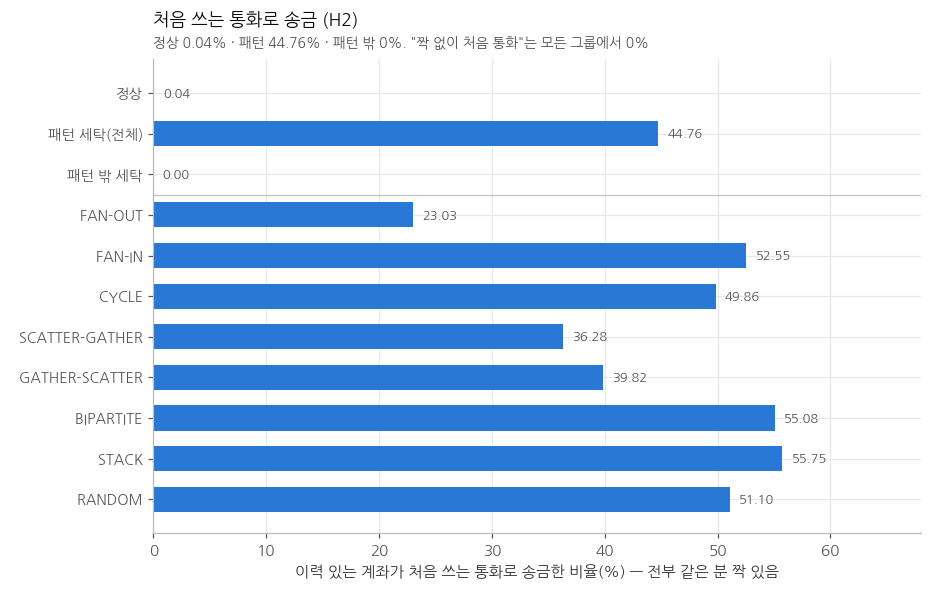

In [49]:
# 원본: notebooks/12 cell 7 왼쪽 패널. 바꾼 곳: 한 칸 그림, 부제(G4 문구 삭제)·저장.
H2 = rd(RES / 'H2_처음통화_같은분짝_겹침.csv').set_index('그룹')
rows = ['정상', '패턴 세탁 전체', '패턴 밖 세탁'] + CLASS_NAMES
vals = H2.loc[rows, '처음 통화 & 같은 분 짝(%)'].to_numpy(dtype=float)
colors = [C_NORM, C_PAT, C_OOP] + [C_PAT] * 8
fig, ax = plt.subplots(figsize=(9, 5.6))
y = np.arange(len(rows))[::-1]
bars = ax.barh(y, vals, color=colors, height=0.62)
label_bars(ax, bars, fmt='{:.2f}', dx=0.8, horiz=True)
ax.set_yticks(y)
ax.set_yticklabels(['정상', '패턴 세탁(전체)', '패턴 밖 세탁'] + ['  ' + t for t in CLASS_NAMES], fontsize=9.4)
ax.set_xlim(0, 68)
ax.axhline(y[2] - 0.5, color=BASE, lw=0.8)
ax.set_xlabel('이력 있는 계좌가 처음 쓰는 통화로 송금한 비율(%) — 전부 같은 분 짝 있음')
title(ax, '처음 쓰는 통화로 송금 (H2)', '정상 0.04% · 패턴 44.76% · 패턴 밖 0%. "짝 없이 처음 통화"는 모든 그룹에서 0%')
savefig(fig, 'S4_5_처음통화_H2.png')

**해석**
- 처음 쓰는 통화로 송금: **정상 0.04%(73,128행) · 패턴 44.76%(50,878행) · 패턴 밖 0%.** "짝 없이 처음 통화"는 모든 그룹에서 0% 다.
- 패턴 쪽 짝은 **100% 환전**이고 거의 다 자기송금이다. 엄격한 정의(자기 환전·받은 통화 = 이번 송금 통화)로 짝이 없는 행은 패턴 2/50,878, 정상 392/73,128 이다. 그래서 **정상에도 같은 행동이 72,736건** 있다. 시간차는 패턴의 99.996% 가 0분(같은 분)이다.
- 패턴 체인 홉의 55~59% 가 통화를 바꾼다(§5 P3). 그 도구가 이 같은 분 자기 환전이다. 생성기 습관인지 실제 행동인지는 데이터로 가를 수 없다(팀 판단, 부록 B).

## §5 흐름 구조 — 넘기는 속도 · 처음 쌍 · 같은 분 · 되돌림 · 패턴 원문 전달 구조

**질문**: 받은 돈을 얼마나 빨리 넘기나? 처음 만나는 상대와 거래하나? 같은 분에 여러 건을 보내나? 되돌려 보내나? 패턴 체인 안에서 금액·통화는 어떻게 넘어가나?

원래 계산(`step3_time.py`, 09-17)은 옛 모집단을 시간순으로 정렬한 `index_full.npz`(1.6 GB)와 interim 을 읽는다. 같은 분의 거래는 서로의 과거·이후로 보지 않는다(엄격히 이전 분·이후 분만). **꺼 두었다.**
- 주의: B6 의 역방향 정의(:157-160)는 **자기송금을 포함**한다. 그래서 B6b 의 역방향 이력 열은 대체됐고(부록 A), 자기송금을 뺀 H1 · V4 의 값(§5-4)을 쓴다.

In [50]:
# [무거움 · 기본 꺼짐] 원본: HI-Large_EDA/step3_time.py:2-292
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: C.log( → log_h( (out/run.log); C.save_csv( → save_csv_h( (out/). (:256 의 A3 읽기는 원래 results 에서 읽는다)
def _heavy_step3():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    """3단계 — 시간 순서가 필요한 분석: B5 넘기는 속도 · B6 처음 만나는 상대(역방향 포함) · B7 같은 분 동시거래 · A4 패턴 밖 세탁 연결.

    범위: 전처리 결과 행(주 기간, 중복 제거 후, 시간 정렬, 179,650,681행). 규칙은 우리 피처와 같다 —
    같은 분의 거래는 서로의 과거/이후로 보지 않는다(엄격히 이전 분·이후 분만).
    금액 합은 정수 최소 단위로 정확히 더한다(비트코인 1e-6, 그 밖 통화 1e-2). 달러 환산 버전은 달러 센트 정수.
    환산 환율은 분석용(eda_common.UNITS_PER_USD) — 모델 입력이 아니다.
    """
    import gc
    import json
    import sys

    import numpy as np
    import pandas as pd

    import eda_common as C

    sys.path.insert(0, '/workspace')
    from prep9.postprocess_blocks import link_components  # noqa: E402  (읽기만)

    log_h('3단계 시작')
    meta = json.loads((C.MAIN / 'features_meta.json').read_text())
    n_acc = meta['split']['n_accounts']
    n_pairs = meta['split']['n_pairs']
    idx = np.load(C.MAIN / 'index_full.npz')
    ts = idx['ts_min'].astype(np.int32)
    src = idx['src_id'].astype(np.int32)
    dst = idx['dst_id'].astype(np.int32)
    y9 = idx['y9']
    ispos = idx['is_pos'].astype(bool)
    day = idx['day'].astype(np.int32)
    split = idx['split']
    n = len(ts)
    g3 = np.where(y9 <= 7, 0, np.where(ispos, 8, -1)).astype(np.int8)
    gt = np.where(y9 <= 7, y9, np.where(ispos, 8, -1)).astype(np.int8)       # 유형 단위(-1 정상, 0~7, 8 패턴 밖)
    G3 = {-1: '정상', 0: '패턴 세탁', 8: '패턴 밖 세탁'}
    GT = {-1: '정상', **dict(enumerate(C.CLASS_NAMES)), 8: '패턴 밖 세탁'}
    log_h(f'색인 적재 {n:,}행 · anon {C.anon_gib():.1f} GiB')

    # 원본 금액·통화를 전처리 순서로
    p2r = np.load(C.ALIGN / 'new_proc2raw.npy').astype(np.int64)
    assert len(p2r) == n


    def raw_col(c, dtype):
        ps, starts = C.part_starts()
        full = np.concatenate([pd.read_parquet(f, columns=[c])[c].to_numpy() for f in ps]).astype(dtype, copy=False)
        out = full[p2r]
        del full
        gc.collect()
        return out


    pay_v, recv_v = C.vocab('pay'), C.vocab('recv')
    assert pay_v == recv_v
    paid = raw_col('paid', np.float64)
    recv = raw_col('recv', np.float64)
    payc = raw_col('pay_code', np.int8)
    recvc = raw_col('recv_code', np.int8)
    fmtc = raw_col('fmt_code', np.int8)
    del p2r
    gc.collect()
    BTC = pay_v.index('Bitcoin')
    scale = np.where(np.arange(len(pay_v)) == BTC, 1e6, 1e2)
    rate = np.array([C.UNITS_PER_USD[c] for c in pay_v])
    log_h(f'금액 준비 · anon {C.anon_gib():.1f} GiB')

    # ─────────────────────────────────────────────────────────────────────────────
    # B5 넘기는 속도 — 계좌 번호로 P 묶음을 나눠 처리(수신 계좌 = 송신 계좌 조건이라 묶음끼리 섞이지 않는다)
    # 금액 합은 정수 최소 단위(송금 통화: 비트코인 1e-6, 그 밖 1e-2 / 달러 환산: 센트)의 누적합이라 오차가 없다.
    # ─────────────────────────────────────────────────────────────────────────────
    TB = 20                                    # ts < 2^20 분(약 2년)
    CB = 4                                     # 통화 < 16
    assert int(ts.max()) < (1 << TB)
    WIN = {'1h': 60, '24h': 1440, '7d': 10080}
    P = 8
    nxt = np.full(n, -1, np.int32)                                       # 다음 송금까지 분(-1 = 없음)
    fw_cur = {w: np.zeros(n, bool) for w in WIN}
    fw_usd = {w: np.zeros(n, bool) for w in WIN}
    for part in range(P):
        S = np.flatnonzero(src % P == part)
        R = np.flatnonzero(dst % P == part)
        s_acct = src[S].astype(np.int64); s_ts = ts[S].astype(np.int64); s_pc = payc[S].astype(np.int64)
        s_paid = paid[S]
        ks = (s_acct << TB) | s_ts
        o = np.argsort(ks, kind='stable'); ks_s = ks[o]
        cum_usd = np.concatenate([[0], np.cumsum(np.rint(s_paid[o] / rate[s_pc[o]] * 100).astype(np.int64))])
        kc = (((s_acct << CB) | s_pc) << TB) | s_ts
        o2 = np.argsort(kc, kind='stable'); kc_s = kc[o2]
        cum_cur = np.concatenate([[0], np.cumsum(np.rint(s_paid[o2] * scale[s_pc[o2]]).astype(np.int64))])
        del ks, kc, o, o2, s_acct, s_ts, s_pc, s_paid
        ns = len(ks_s)
        r_acct = dst[R].astype(np.int64); r_ts = ts[R].astype(np.int64); r_rc = recvc[R].astype(np.int64)
        r_amt = recv[R]
        r_int = np.rint(r_amt * scale[r_rc]).astype(np.int64)
        r_usd = np.rint(r_amt / rate[r_rc] * 100).astype(np.int64)
        base = r_acct << TB
        p = np.searchsorted(ks_s, base | (r_ts + 1), side='left')        # 엄격히 이후 분의 첫 송금
        same = np.zeros(len(R), bool)
        ok = p < ns
        same[ok] = (ks_s[p[ok]] >> TB) == r_acct[ok]
        nxt[R] = np.where(same, (ks_s[np.minimum(p, ns - 1)] & ((1 << TB) - 1)) - r_ts, -1).astype(np.int32)
        basec = ((r_acct << CB) | r_rc) << TB
        pc_ = np.searchsorted(kc_s, basec | (r_ts + 1), side='left')
        for w, W in WIN.items():
            q = np.searchsorted(ks_s, base | (r_ts + W + 1), side='left')
            fw_usd[w][R] = (r_usd > 0) & ((cum_usd[q] - cum_usd[p]) * 10 >= r_usd * 8)
            qc = np.searchsorted(kc_s, basec | (r_ts + W + 1), side='left')
            fw_cur[w][R] = (r_int > 0) & ((cum_cur[qc] - cum_cur[pc_]) * 10 >= r_int * 8)
        del ks_s, kc_s, cum_usd, cum_cur, r_acct, r_ts, r_rc, r_amt, r_int, r_usd, base, basec, p, pc_, q, qc, S, R
        gc.collect()
        log_h(f'  B5 묶음 {part + 1}/{P} · anon {C.anon_gib():.1f} GiB')
    rows = []
    for gdict, garr in ((G3, g3), (GT, gt)):
        for gk, gname in gdict.items():
            m = garr == gk
            cnt = int(m.sum())
            if not cnt:
                continue
            v = nxt[m]
            has = v >= 0
            r = {'그룹': gname, '수신 거래 수': cnt, '이후 송금 없음(%)': 100 * float(1 - has.mean())}
            if has.any():
                for qq in (10, 25, 50, 75, 90):
                    r[f'다음 송금까지 p{qq}(분)'] = float(np.percentile(v[has], qq))
            for w in WIN:
                r[f'{w} 안 80% 이상 송금 — 같은 통화(%)'] = 100 * float(fw_cur[w][m].mean())
                r[f'{w} 안 80% 이상 송금 — 달러 환산(%)'] = 100 * float(fw_usd[w][m].mean())
            rows.append(r)
    b5 = pd.DataFrame(rows).drop_duplicates('그룹')
    save_csv_h(b5, 'B5_넘기는속도.csv')
    rows = []
    for s_ in range(3):
        for gk, gname in G3.items():
            m = (split == s_) & (g3 == gk)
            v = nxt[m]; has = v >= 0
            rows.append({'구간': ['train', 'val', 'test'][s_], '그룹': gname, '수신 거래 수': int(m.sum()),
                         '다음 송금까지 p50(분)': float(np.percentile(v[has], 50)) if has.any() else np.nan,
                         **{f'{w} 안 80%+ 같은 통화(%)': 100 * float(fw_cur[w][m].mean()) for w in WIN}})
    save_csv_h(pd.DataFrame(rows), 'B5b_넘기는속도_구간별.csv')
    del nxt, fw_cur, fw_usd, paid, recv
    gc.collect()
    log_h(f'B5 완료 · anon {C.anon_gib():.1f} GiB')

    # ─────────────────────────────────────────────────────────────────────────────
    # B6 처음 만나는 상대 + 역방향 이력
    # ─────────────────────────────────────────────────────────────────────────────
    pid = idx['pair_id'].astype(np.int64)
    upid, first_idx = np.unique(pid, return_index=True)
    assert len(upid) == n_pairs and (upid == np.arange(n_pairs)).all()
    first_ts = ts[first_idx].astype(np.int64)
    del upid, first_idx
    U = np.empty(n_pairs, np.int64)
    U[pid] = src.astype(np.int64) * n_acc + dst                                           # 쌍 번호 = 정렬된 (송신·수신) 키의 순위
    assert (np.diff(U) > 0).all()
    is_new = ts.astype(np.int64) == first_ts[pid]                                         # 그 쌍의 첫 분(같은 분 거래 모두 '처음')
    rk = dst.astype(np.int64) * n_acc + src
    pos = np.minimum(np.searchsorted(U, rk), n_pairs - 1)
    rev_exists = U[pos] == rk
    rev_hist = rev_exists & (first_ts[pos] < ts.astype(np.int64))                          # 역방향 쌍이 엄격히 이전 분에 있었다
    del rk, pos, U
    gc.collect()
    week = day // 7
    rows = []
    for unit, key in (('일', day), ('주', week)):
        for gk, gname in G3.items():
            m = g3 == gk
            kk = key[m]
            tot = np.bincount(kk)
            nw = np.bincount(kk, weights=is_new[m])
            nr = np.bincount(kk, weights=(is_new & rev_hist)[m])
            for u in np.flatnonzero(tot):
                rows.append({'단위': unit, '번호': int(u), '그룹': gname, '거래수': int(tot[u]), '처음 쌍 거래': int(nw[u]),
                             '처음 쌍 비율(%)': 100 * nw[u] / tot[u],
                             '처음 쌍 중 역방향 이력 있음': int(nr[u]),
                             '처음 쌍 중 역방향 이력 비율(%)': 100 * nr[u] / nw[u] if nw[u] else np.nan})
    save_csv_h(pd.DataFrame(rows), 'B6_처음만나는상대_일주별.csv')
    rows = []
    for gdict, garr in ((G3, g3), (GT, gt)):
        for gk, gname in gdict.items():
            for s_ in (0, 1, 2, None):
                m = (garr == gk) & ((split == s_) if s_ is not None else True)
                c = int(m.sum())
                if not c:
                    continue
                nw = int((is_new & m).sum())
                rows.append({'그룹': gname, '구간': ['train', 'val', 'test'][s_] if s_ is not None else '전체', '거래수': c,
                             '처음 쌍 비율(%)': 100 * nw / c, '처음 쌍 중 역방향 이력(%)': 100 * int((is_new & rev_hist & m).sum()) / nw if nw else np.nan,
                             '역방향 이력 있는 거래 전체(%)': 100 * int((rev_hist & m).sum()) / c})
    save_csv_h(pd.DataFrame(rows).drop_duplicates(['그룹', '구간']), 'B6b_처음만나는상대_그룹구간별.csv')
    del is_new, rev_hist, rev_exists, first_ts, pid
    gc.collect()
    log_h(f'B6 완료 · anon {C.anon_gib():.1f} GiB')

    # ─────────────────────────────────────────────────────────────────────────────
    # B7 같은 분 동시거래
    # ─────────────────────────────────────────────────────────────────────────────
    rows, dist_rows = [], []
    for side, ent in (('송신', src), ('수신', dst)):
        key = (ent.astype(np.int64) << TB) | ts.astype(np.int64)
        _, inv, cnt = np.unique(key, return_inverse=True, return_counts=True)
        c_row = cnt[inv]
        del key, inv, cnt
        gc.collect()
        for gk, gname in G3.items():
            m = g3 == gk
            v = c_row[m]
            rows.append({'쪽': side, '그룹': gname, '거래수': int(m.sum()), '같은 계좌·같은 분 2건 이상(%)': 100 * float(np.mean(v >= 2)),
                         '5건 이상(%)': 100 * float(np.mean(v >= 5)), 'p50': float(np.percentile(v, 50)),
                         'p99': float(np.percentile(v, 99)), '최대': int(v.max())})
            bins = [1, 2, 3, 6, 11, 101, 10**9]
            h = np.histogram(v, bins=bins)[0]
            for lo_, hi_, c_ in zip(bins[:-1], bins[1:], h):
                dist_rows.append({'쪽': side, '그룹': gname, '같은 분 건수 구간': f'{lo_}~{hi_ - 1}', '거래수': int(c_),
                                  '비율(%)': 100 * c_ / len(v)})
        del c_row
        gc.collect()
    save_csv_h(pd.DataFrame(rows), 'B7_같은분_동시거래.csv')
    save_csv_h(pd.DataFrame(dist_rows), 'B7b_같은분_건수분포.csv')
    log_h(f'B7 완료 · anon {C.anon_gib():.1f} GiB')

    # ─────────────────────────────────────────────────────────────────────────────
    # A4 패턴 밖 세탁의 연결
    # ─────────────────────────────────────────────────────────────────────────────
    L = np.flatnonzero(ispos)                                            # 세탁 행(패턴+패턴 밖)
    ls, ld, lt, ldy, lg = src[L].astype(np.int64), dst[L].astype(np.int64), ts[L].astype(np.int64), day[L], g3[L]
    m_ = len(L)
    ev_acct = np.concatenate([ls, ld]); ev_row = np.tile(np.arange(m_), 2)
    ev_t = np.concatenate([lt, lt]); ev_d = np.concatenate([ldy, ldy])


    def has_neighbor(window=None, same_day=False):
        """각 세탁 행이 '다른' 세탁 행과 계좌를 직접 공유하는가(창 안)."""
        if same_day:
            o_ = np.lexsort((ev_t, ev_d, ev_acct))
            grpkey = (ev_acct[o_].astype(np.int64) << 20) | ev_d[o_]
        else:
            o_ = np.lexsort((ev_t, ev_acct))
            grpkey = ev_acct[o_].astype(np.int64)
        a_, r_, t_ = grpkey, ev_row[o_], ev_t[o_]
        res = np.zeros(m_, bool)
        # 같은 그룹 안에서 다른 행과의 인접(앞·뒤로 최대 몇 칸) — 같은 행의 두 사건(셀프)이 끼는 경우를 위해 2칸까지 본다
        for lag in (1, 2):
            same = (a_[lag:] == a_[:-lag]) & (r_[lag:] != r_[:-lag])
            if window is not None:
                same &= (t_[lag:] - t_[:-lag]) <= window
            res[r_[lag:][same]] = True
            res[r_[:-lag][same]] = True
        return res


    conn = {'같은 날': has_neighbor(same_day=True), '±24h': has_neighbor(window=1440), '±7일': has_neighbor(window=10080)}
    fmt_v = C.vocab('fmt')
    lf, lpc, lrc = fmtc[L], payc[L], recvc[L]
    nt_keys = pd.read_parquet(C.ALIGN / 'new_new2key.parquet')['key'].to_numpy(dtype=object)
    hub_df = pd.read_csv(C.OUT / 'A3_허브_대조표.csv') if (C.OUT / 'A3_허브_대조표.csv').exists() else None
    hub_set = set(hub_df.loc[hub_df['우리 허브 순위'].notna(), 'key']) if hub_df is not None else set()
    is_hub_row = np.array([(nt_keys[a] in hub_set) or (nt_keys[b] in hub_set) for a, b in zip(ls, ld)]) if hub_set else np.zeros(m_, bool)
    rows = []
    oop = lg == 8
    for wname, c_ in conn.items():
        for label, mm in (('연결', oop & c_), ('단건', oop & ~c_)):
            k_ = int(mm.sum())
            r = {'창': wname, '패턴 밖 세탁 분류': label, '건수': k_, '패턴 밖 세탁 중(%)': 100 * k_ / int(oop.sum())}
            if k_:
                r['셀프(%)'] = 100 * float(np.mean(ls[mm] == ld[mm]))
                r['환전(%)'] = 100 * float(np.mean(lpc[mm] != lrc[mm]))
                r['우리 허브 연루(%)'] = 100 * float(np.mean(is_hub_row[mm]))
                for j, fn in enumerate(fmt_v):
                    r[f'결제수단 {fn}(%)'] = 100 * float(np.mean(lf[mm] == j))
            rows.append(r)
    save_csv_h(pd.DataFrame(rows), 'A4_패턴밖세탁_연결여부.csv')
    # 연결요소(창 = 공백 기준 이행적 연결, prep9.postprocess_blocks 와 같은 규칙) 크기 분포
    crow = []
    for wname, W in (('±24h', 1440), ('±7일', 10080)):
        comp = link_components(ls, ld, lt, W)
        sizes = np.bincount(comp)
        n_oop_c = np.bincount(comp, weights=oop)
        n_pat_c = np.bincount(comp, weights=~oop)
        cs = sizes[comp][oop]
        crow.append({'창(공백)': wname, '세탁 행': m_, '연결요소 수': int(len(sizes)),
                     '패턴 밖 세탁이 크기 1 요소': int((cs == 1).sum()),
                     '패턴 밖 세탁 소속 요소 크기 p50': float(np.percentile(cs, 50)), 'p90': float(np.percentile(cs, 90)),
                     '최대 요소 크기': int(sizes.max()), '최대 요소의 패턴 밖/패턴 행': f'{int(n_oop_c[sizes.argmax()])}/{int(n_pat_c[sizes.argmax()])}',
                     '패턴 밖만으로 된 요소(크기≥2)': int(((n_pat_c == 0) & (sizes >= 2)).sum()),
                     '패턴과 섞인 요소': int(((n_pat_c > 0) & (n_oop_c > 0)).sum())})
        top_c = np.argsort(-sizes)[:10]
        for rk_, c_ in enumerate(top_c):
            crow.append({'창(공백)': wname, '상위 요소 순위': rk_ + 1, '크기': int(sizes[c_]),
                         '패턴 밖': int(n_oop_c[c_]), '패턴': int(n_pat_c[c_])})
    save_csv_h(pd.DataFrame(crow), 'A4b_세탁_연결요소_크기.csv')
    log_h(f'3단계 완료 · anon {C.anon_gib():.1f} GiB')


if HEAVY['step3']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_step3()
else:
    print("HEAVY['step3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['step3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


### 5-1. 받은 돈을 넘기는 속도(B5) [저장 결과]

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B5_넘기는속도.csv  (2,516 B · 11행)


,수신 거래 수,이후 송금 없음(%),다음 송금까지 p50(분),1h 안 80% 이상 송금 — 같은 통화(%),24h 안 80% 이상 송금 — 같은 통화(%),7d 안 80% 이상 송금 — 같은 통화(%),7d 안 80% 이상 송금 — 달러 환산(%)
그룹,,,,,,,
정상,179449408,8.16,2391.0,3.52,29.42,51.95,52.05
패턴 세탁,113663,4.35,1349.0,1.98,28.96,61.82,61.95
패턴 밖 세탁,87610,7.69,5857.5,1.24,17.91,42.40,42.43
FAN-OUT,11383,5.14,1485.0,1.77,26.29,54.99,55.07
FAN-IN,11324,5.55,1511.0,1.69,25.72,54.61,54.72
CYCLE,10552,2.38,1010.0,2.72,38.72,83.61,83.65
SCATTER-GATHER,22324,4.40,1485.5,1.88,26.77,56.28,56.39
GATHER-SCATTER,18635,5.07,1127.0,2.20,30.53,62.05,62.45
BIPARTITE,10974,4.83,1649.5,1.69,25.19,53.18,53.29


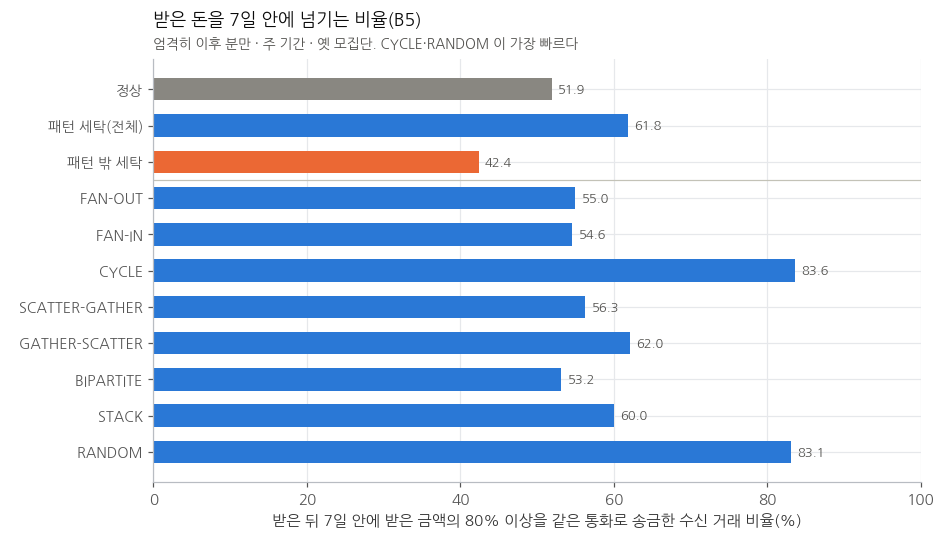

In [51]:
B5 = rd(RES / 'B5_넘기는속도.csv').set_index('그룹')
cols5 = ['수신 거래 수', '이후 송금 없음(%)', '다음 송금까지 p50(분)', '1h 안 80% 이상 송금 — 같은 통화(%)', '24h 안 80% 이상 송금 — 같은 통화(%)', '7d 안 80% 이상 송금 — 같은 통화(%)', '7d 안 80% 이상 송금 — 달러 환산(%)']
display(B5[cols5].round(2))
order5 = ['정상', '패턴 세탁', '패턴 밖 세탁'] + CLASS_NAMES
v = B5.loc[order5, '7d 안 80% 이상 송금 — 같은 통화(%)'].to_numpy()
fig, ax = plt.subplots(figsize=(9, 5)); y = np.arange(len(order5))[::-1]
bars = ax.barh(y, v, color=[C_NORM, C_PAT, C_OOP] + [C_PAT] * 8, height=0.62)
label_bars(ax, bars, fmt='{:.1f}', dx=0.8, horiz=True)
ax.axhline(y[2] - 0.5, color=BASE, lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(['정상', '패턴 세탁(전체)', '패턴 밖 세탁'] + ['  ' + t for t in CLASS_NAMES], fontsize=9.4); ax.set_xlim(0, 100)
ax.set_xlabel('받은 뒤 7일 안에 받은 금액의 80% 이상을 같은 통화로 송금한 수신 거래 비율(%)')
title(ax, '받은 돈을 7일 안에 넘기는 비율(B5)', '엄격히 이후 분만 · 주 기간 · 옛 모집단. CYCLE·RANDOM 이 가장 빠르다')
savefig(fig, 'S5_1_넘기는속도_B5.png')

**해석**
- 받은 돈의 80% 이상을 7일 안에 같은 통화로 보낸 비율: **CYCLE 83.6 · RANDOM 83.1%** 로 가장 높다. 정상 51.9 · 패턴 전체 61.8 · 패턴 밖 42.4% 다.
- 1시간 안에 넘기는 비율은 정상 3.5 · 패턴 2.0% 로 둘 다 낮다. 넘기기는 "시간 단위"가 아니라 "일 단위"다(§2 의 창 길이와 같은 결론).

### 5-2. 처음 거래하는 계좌쌍(B6) [저장 결과]
- **정의가 여럿이다.** 숫자 하나로 인용하지 않는다(EDA 현황 §1-8). 아래 셀이 세 정의의 값을 파일에서 읽어 한 표로 보인다. 분모가 모두 다르다.
- tgnn E2 CSV 를 만든 코드 파일은 없다(일회성 측정, 방법은 `검증회신_TGNN9클래스_빠진항목13_손은총_20260929.md:9 · :43-44`).

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B6_처음만나는상대_일주별.csv  (23,735 B · 333행)
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B6b_처음만나는상대_그룹구간별.csv  (3,498 B · 44행)


,그룹,거래수,처음 쌍 비율(%)
3,정상,179449408,4.67
7,패턴 세탁,113663,87.34
11,패턴 밖 세탁,87610,35.01
15,FAN-OUT,11383,86.91
19,FAN-IN,11324,88.06
23,CYCLE,10552,82.95
27,SCATTER-GATHER,22324,86.92
31,GATHER-SCATTER,18635,84.53
35,BIPARTITE,10974,91.01
39,STACK,20015,91.32


읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/results/E2_이전거래없음_0채움_비율.csv  (602 B · 5행)


,패턴_값0_비율,정상(CSSMC)_값0_비율,패턴_0아닌_최소값,정상(CSSMC)_0아닌_최소값
열,,,,
pair_gap_minutes,0.879220,0.031015,1.098612,1.098612
sender_gap_minutes,0.011766,0.000834,1.098612,1.098612
receiver_gap_minutes,0.019378,0.000303,1.098612,1.098612
pair_age_at_day_start,0.879721,0.031084,1.098612,1.098612
pair_prior_count,0.879220,0.031015,0.693147,0.693147


읽음: /workspace/feat_final_20260915/m2_label_bins.csv  (89,483 B · 668행)
읽음: /workspace/feat_final_20260915/m2_meta.json
■ 처음 거래하는 계좌쌍 — 정의 셋(분모가 모두 다르다. 전체행_pct = 정상+세탁 전체 중 비율)


,정의,분모,정상_pct,패턴_pct,전체행_pct,출처
0,B6b: 그 쌍의 첫 분(같은 분 거래 모두 처음),"주 기간 97일 전체 · 옛 모집단 179,650,681행",4.67,87.34,NaN,HI-Large_EDA/results/B6b_처음만나는상대_그룹구간별.csv (구간=전체)
1,M2(09-15): 옛 81열 tb_pair_repeat = 0,"옛 짧은 파일 · 옛 60/20/20 train 107,783,265 − 08-01 워밍업 4,455,984 = 103,327,281행",3.90,87.95,3.96,"feat_final_20260915/m2_label_bins.csv (view=워밍업제외, 열=tb_pair_repeat, 구간 1) · m2_meta.json"
2,tgnn E2: 36피처 pair_prior_count = 0(이전 거래 없음),현행 train 51일 학습 행(패턴 세탁 + CSSMC 정상),3.10,87.92,NaN,tgnn36_20260928/results/E2_이전거래없음_0채움_비율.csv


주별(주 번호 = 날짜 번호 // 7, 0 = 08-01~07):


번호,0,1,2,3,4,5,6,7,8,9,10,11,12,13
그룹,,,,,,,,,,,,,,
정상,26.11,4.02,3.50,3.32,2.59,3.08,2.79,2.76,2.18,2.58,2.43,2.39,1.94,2.11
패턴 밖 세탁,63.98,53.10,46.95,43.81,40.08,35.84,34.38,31.33,29.96,27.67,25.76,25.20,23.42,23.00
패턴 세탁,88.36,88.57,88.16,88.37,88.46,87.63,87.53,87.29,87.43,86.65,87.28,86.47,86.92,86.01


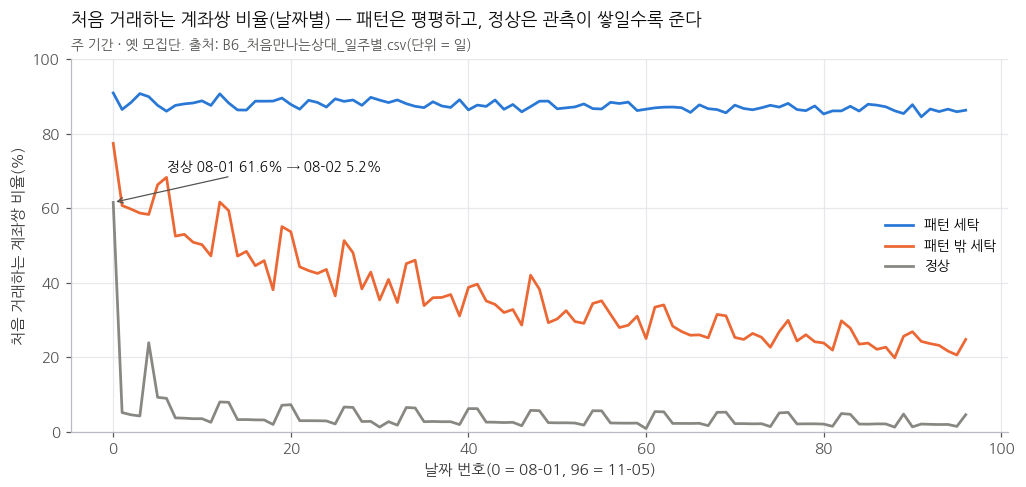

In [52]:
B6 = rd(RES / 'B6_처음만나는상대_일주별.csv'); d6 = B6[B6['단위'] == '일']
B6b = rd(RES / 'B6b_처음만나는상대_그룹구간별.csv'); display(B6b[B6b.구간 == '전체'][['그룹', '거래수', '처음 쌍 비율(%)']].round(2))
TE2 = rd(TRES / 'E2_이전거래없음_0채움_비율.csv').set_index('열'); display(TE2)
# 09-15 M2: m2_label_bins.csv 의 (view=워밍업제외, 열=tb_pair_repeat, 구간 1 = 값 0 = 처음 쌍) 행
M2b = rd(M9 / 'm2_label_bins.csv'); m2m = json.loads((M9 / 'm2_meta.json').read_text()); print(f'읽음: {M9 / "m2_meta.json"}')
m2 = M2b[(M2b.view == '워밍업제외') & (M2b['열'] == 'tb_pair_repeat')]
r1 = m2[m2['구간'] == 1].iloc[0]; assert r1['하한'] == 0
assert int(m2['행수'].sum()) == m2m['n_train'] - m2m['warmup_rows']
b6t = B6b[B6b.구간 == '전체'].set_index('그룹')
DEF = pd.DataFrame([
    dict(정의='B6b: 그 쌍의 첫 분(같은 분 거래 모두 처음)', 분모='주 기간 97일 전체 · 옛 모집단 179,650,681행',
         정상_pct=b6t.loc['정상', '처음 쌍 비율(%)'], 패턴_pct=b6t.loc['패턴 세탁', '처음 쌍 비율(%)'], 전체행_pct=np.nan,
         출처='HI-Large_EDA/results/B6b_처음만나는상대_그룹구간별.csv (구간=전체)'),
    dict(정의='M2(09-15): 옛 81열 tb_pair_repeat = 0', 분모=f"옛 짧은 파일 · 옛 60/20/20 train {m2m['n_train']:,} − 08-01 워밍업 {m2m['warmup_rows']:,} = {int(m2['행수'].sum()):,}행",
         정상_pct=100 * r1['정상수'] / m2['정상수'].sum(), 패턴_pct=100 * r1['패턴수'] / m2['패턴수'].sum(), 전체행_pct=100 * r1['행비중'],
         출처='feat_final_20260915/m2_label_bins.csv (view=워밍업제외, 열=tb_pair_repeat, 구간 1) · m2_meta.json'),
    dict(정의='tgnn E2: 36피처 pair_prior_count = 0(이전 거래 없음)', 분모='현행 train 51일 학습 행(패턴 세탁 + CSSMC 정상)',
         정상_pct=100 * TE2.loc['pair_prior_count', '정상(CSSMC)_값0_비율'], 패턴_pct=100 * TE2.loc['pair_prior_count', '패턴_값0_비율'], 전체행_pct=np.nan,
         출처='tgnn36_20260928/results/E2_이전거래없음_0채움_비율.csv'),
])
print('■ 처음 거래하는 계좌쌍 — 정의 셋(분모가 모두 다르다. 전체행_pct = 정상+세탁 전체 중 비율)'); display(DEF.round(2))
w6 = B6[(B6['단위'] == '주')].pivot(index='번호', columns='그룹', values='처음 쌍 비율(%)')
print('주별(주 번호 = 날짜 번호 // 7, 0 = 08-01~07):'); display(w6.round(2).T)

fig, ax = plt.subplots(figsize=(11, 4.4))
for g, c in (('패턴 세탁', C_PAT), ('패턴 밖 세탁', C_OOP), ('정상', C_NORM)):
    s = d6[d6['그룹'] == g].sort_values('번호')
    ax.plot(s['번호'], s['처음 쌍 비율(%)'], color=c, lw=1.8, label=g)
s0 = d6[(d6['그룹'] == '정상')].sort_values('번호')
ax.annotate(f"정상 08-01 {s0['처음 쌍 비율(%)'].iloc[0]:.1f}% → 08-02 {s0['처음 쌍 비율(%)'].iloc[1]:.1f}%", xy=(0, s0['처음 쌍 비율(%)'].iloc[0]), xytext=(6, 70), fontsize=9, color=INK, arrowprops=dict(arrowstyle='->', color=INK2, lw=0.8))
ax.set_ylim(0, 100); ax.set_xlabel('날짜 번호(0 = 08-01, 96 = 11-05)'); ax.set_ylabel('처음 거래하는 계좌쌍 비율(%)')
ax.legend(frameon=False, fontsize=9, loc='center right')
title(ax, '처음 거래하는 계좌쌍 비율(날짜별) — 패턴은 평평하고, 정상은 관측이 쌓일수록 준다', '주 기간 · 옛 모집단. 출처: B6_처음만나는상대_일주별.csv(단위 = 일)')
savefig(fig, 'S5_2_처음쌍_날짜별.png')

**해석**
- 패턴 세탁의 약 87% 가 **처음 거래하는 계좌쌍**이다. 주별로 86~89% 로 평평하다.
- 정상의 값은 **시계**처럼 움직인다: 08-01 61.6% → 08-02 5.2% → 마지막 주 약 2.1%. 관측 시작점에 묶인 누적 정보라서다. 그래서 정상 쪽은 기간·정의마다 값이 다르다. 이 성질이 §7 의 E3(누적 열이 train·test 를 가름)로 이어진다.
- 패턴 밖은 35.0% 로 중간이다.

### 5-3. 같은 분 동시 거래(B7 · fix [E]) [저장 결과]
fix [E] 의 원래 계산은 DuckDB 에서 (키, 분)으로 묶는다(09-27). **꺼 두었다.** 측정은 유효하고 적용(파이프라인 변경)은 미결이다.

In [53]:
# [무거움 · 기본 꺼짐] 원본: fix_20260927/code/fix_01_E_same_minute.py:1-51
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: results/E1 → OUT/E1
def _heavy_E_same_minute():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    """fix_01_E — [E] 같은 분(minute) 안에 함께 들어오는 거래가 얼마나 되는가(영향 크기만 잰다. 파이프라인은 안 바꾼다).
    태훈님 엣지 피처는 '1분 전까지'만 본다(daily_pipeline.py:294~296). 같은 분·같은 키에 2건 이상이면 서로를 못 본다.
    키 3종: 계좌쌍(src,dst) / 보낸 계좌(src) / 받는 계좌(dst). 기간 3종: 보정 08-01~08-07 / 우리 90일 08-08~11-05 / 꼬리 11-06~.
    읽기 전용. 출력: results/E1_같은분_동시거래_비율.csv
    """
    import os
    for k in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS'):
        os.environ[k] = '3'
    import sys
    import time
    sys.path.insert(0, '/workspace/.pylibs/duckdb')
    from pathlib import Path
    import pandas as pd
    import duckdb

    F = Path('/workspace/Final_preprocess/fix_20260927')
    DB = '/tmp/tree9_work/db_full/daily.duckdb'
    TMP = Path('/tmp/fix_work/duck_tmp')
    TMP.mkdir(parents=True, exist_ok=True)

    c = duckdb.connect(DB, read_only=True)
    c.execute("SET threads=3")
    c.execute("SET memory_limit='8GB'")
    c.execute(f"SET temp_directory='{TMP}'")
    c.execute("SET preserve_insertion_order=false")

    out = []
    for key, part in [('계좌쌍(src,dst)', 'src,dst'), ('보낸 계좌(src)', 'src'), ('받는 계좌(dst)', 'dst')]:
        t0 = time.time()
        q = f"""
        WITH g AS (SELECT {part}, ts, count(*) AS n, sum(y) AS pos, min(day) AS d FROM tx GROUP BY {part}, ts)
        SELECT CASE WHEN d < DATE '2022-08-08' THEN '1_보정(08-01~08-07)'
                    WHEN d <= DATE '2022-11-05' THEN '2_우리 90일(08-08~11-05)'
                    ELSE '3_꼬리(11-06~)' END AS period,
               count(*) AS groups, sum(n) AS rows_all,
               coalesce(sum(n) FILTER (WHERE n >= 2), 0) AS rows_same_minute_2plus,
               sum(pos) AS pos_all,
               coalesce(sum(pos) FILTER (WHERE n >= 2), 0) AS pos_same_minute_2plus,
               max(n) AS max_in_one_minute
        FROM g GROUP BY 1 ORDER BY 1"""
        d = c.execute(q).fetchdf()
        d.insert(0, 'key', key)
        d['pct_rows'] = (100 * d.rows_same_minute_2plus / d.rows_all).round(4)
        d['pct_pos'] = (100 * d.pos_same_minute_2plus / d.pos_all).round(4)
        d['sec'] = round(time.time() - t0, 1)
        print(d.to_string(), flush=True)
        out.append(d)
    c.close()
    r = pd.concat(out, ignore_index=True)
    r.to_csv(OUT / 'E1_같은분_동시거래_비율.csv', index=False, encoding='utf-8-sig')
    print('DONE', flush=True)


if HEAVY['E_same_minute']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_E_same_minute()
else:
    print("HEAVY['E_same_minute'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['E_same_minute'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [54]:
display(rd(RES / 'B7_같은분_동시거래.csv'))
FE1 = rd(FRES / 'E1_같은분_동시거래_비율.csv'); display(FE1[['key', 'period', 'rows_all', 'pct_rows', 'pos_all', 'pct_pos', 'max_in_one_minute']])
G5 = rd(RES / 'G5_같은분_짝_구성.csv'); display(G5[G5.유형 == '전체'])

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/B7_같은분_동시거래.csv  (521 B · 6행)


,쪽,그룹,거래수,같은 계좌·같은 분 2건 이상(%),5건 이상(%),p50,p99,최대
0,송신,정상,179449408,16.380462,8.053735,1.0,59.0,653
1,송신,패턴 세탁,113663,59.957946,0.000000,2.0,3.0,4
2,송신,패턴 밖 세탁,87610,32.920899,23.428832,1.0,70.0,644
3,수신,정상,179449408,5.158425,0.067348,1.0,2.0,11
4,수신,패턴 세탁,113663,8.993252,0.000000,1.0,2.0,3
5,수신,패턴 밖 세탁,87610,14.015523,0.504509,1.0,4.0,11


읽음: /workspace/Final_preprocess/fix_20260927/results/E1_같은분_동시거래_비율.csv  (1,090 B · 9행)


,key,period,rows_all,pct_rows,pos_all,pct_pos,max_in_one_minute
0,"계좌쌍(src,dst)",1_보정(08-01~08-07),14933007.0,3.8273,7206.0,2.4563,4
1,"계좌쌍(src,dst)",2_우리 90일(08-08~11-05),164728353.0,4.2474,194067.0,8.1091,5
2,"계좌쌍(src,dst)",3_꼬리(11-06~),40719.0,11.4296,24273.0,9.5868,2
3,보낸 계좌(src),1_보정(08-01~08-07),14933007.0,14.8202,7206.0,38.3986,330
4,보낸 계좌(src),2_우리 90일(08-08~11-05),164728353.0,16.5715,194067.0,48.5528,653
5,보낸 계좌(src),3_꼬리(11-06~),40719.0,77.0893,24273.0,61.5828,3
6,받는 계좌(dst),1_보정(08-01~08-07),14933007.0,4.7281,7206.0,7.4799,10
7,받는 계좌(dst),2_우리 90일(08-08~11-05),164728353.0,5.2173,194067.0,11.3167,11
8,받는 계좌(dst),3_꼬리(11-06~),40719.0,11.4345,24273.0,9.5909,2


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/G5_같은분_짝_구성.csv  (1,613 B · 11행)


,그룹,유형,행,짝 수 평균,짝에 같은 사건 패턴 행 있음(%),짝에 다른 사건 패턴 행 있음(%),짝에 패턴 밖 세탁 있음(%),짝이 모두 정상(%),짝에 같은 수신 계좌 있음(%),짝에 같은 송금 통화 있음(%)
0,패턴 세탁,전체,68150,1.09394,0.0,0.017608,0.000000,99.982392,14.856933,15.005136
1,패턴 밖 세탁,전체,28842,24.79783,0.0,0.000000,3.075376,96.924624,20.071424,100.000000
2,정상(무작위 5만 행),전체,50000,17.45598,0.0,0.264000,2.386000,97.350000,25.676000,82.170000


그림 5-3 은 `fix_20260927/make_figs.py:71-81`(그림 F4) 코드를 빌드할 때 글자 그대로 읽어 옮긴 것이다. 바꾼 곳: 입력 경로(`R` → `FRES`), `style` → `style_fix`(§1-2 에서 정의), 그림 번호, 저장.

읽음: /workspace/Final_preprocess/fix_20260927/results/E1_같은분_동시거래_비율.csv  (1,090 B · 9행)


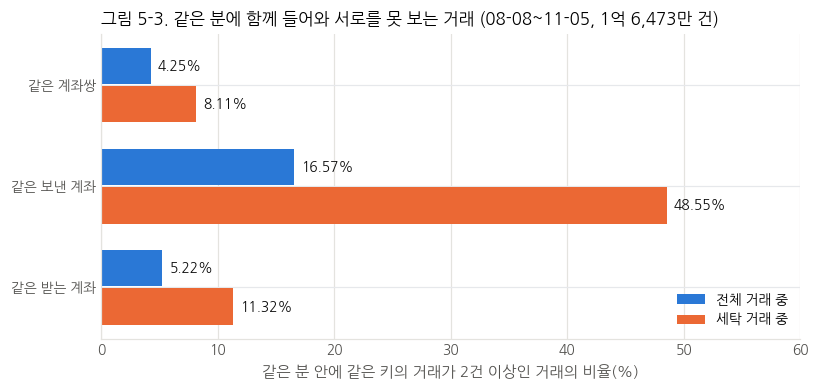

In [55]:
# 원본: fix_20260927/make_figs.py:71-81
# ── F2 [E] 같은 분에 함께 들어오는 거래 ──
e = rd(FRES / 'E1_같은분_동시거래_비율.csv'); e = e[e.period.str.startswith('2_')].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.2, 3.6)); y = np.arange(len(e)); h = 0.36
ax.barh(y - h / 2 - 0.01, e.pct_rows, height=h, color=C1, label='전체 거래 중'); ax.barh(y + h / 2 + 0.01, e.pct_pos, height=h, color=C2, label='세탁 거래 중')
for i in range(len(e)):
    ax.text(e.pct_rows[i] + 0.6, y[i] - h / 2 - 0.01, f'{e.pct_rows[i]:.2f}%', va='center', fontsize=9, color=INK)
    ax.text(e.pct_pos[i] + 0.6, y[i] + h / 2 + 0.01, f'{e.pct_pos[i]:.2f}%', va='center', fontsize=9, color=INK)
ax.set_yticks(y); ax.set_yticklabels(['같은 계좌쌍', '같은 보낸 계좌', '같은 받는 계좌']); ax.invert_yaxis(); ax.set_xlim(0, 60); ax.set_xlabel('같은 분 안에 같은 키의 거래가 2건 이상인 거래의 비율(%)')
style_fix(ax, 'x'); ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.set_title('그림 5-3. 같은 분에 함께 들어와 서로를 못 보는 거래 (08-08~11-05, 1억 6,473만 건)', fontsize=11, loc='left')
savefig(fig, 'S5_3_같은분_동시거래_F4.png')

**해석**
- 옛 모집단(B7): 같은 분·같은 송신 계좌 2건 이상이 정상 16.38 · 패턴 59.96 · 패턴 밖 32.92% 다. 패턴은 한 분에 최대 4건, 정상은 653건까지 있다.
- DB 90일(fix [E]): 계좌쌍 4.25 · 보낸 계좌 16.57 · 받는 계좌 5.22%. 세탁만 보면 8.11 · 48.55 · 11.32% 다.
- 태훈님 엣지 피처는 "1분 전까지"만 본다. 그래서 **같은 분에 함께 들어온 거래는 서로를 못 본다.** 세탁에서 이 비율이 3배 높다. 적용은 미결이다.
- 패턴 행의 같은 분 짝은 99.98% 가 정상이고, 같은 사건의 패턴 행은 0% 다(G5). 짝의 정체는 §4-4 의 자기 환전이다.

### 5-4. 되돌림(역방향 이력) [저장 결과]
- **정의**: A→B 거래 이전에(엄격히 이전 분) B→A 거래가 있었다. **자기송금은 뺀다.**
- 원래 계산: `notebooks/08` cell 7(G1, cell 2 의 변수 사용) · 독립 재계산 `notebooks/13_V4`(원본 parquet · 쌍별 첫 시각). **옮기지 않았다**: 08 cell 2 는 지워진 31열 행렬 폴더(`/tmp/claude-0/…/scratchpad/eda_cols`)를 읽고, V4 cell 1 · 3 도 같은 폴더의 `cols31.json` 을 읽는다.
- 층화 OR = 송신 계좌의 이전 송신 건수 5층 Mantel–Haenszel(G2).
- 후보 종합표 `H1` 은 `notebooks/09` cell 7 이 저장된 G1~G4 CSV 를 한 표로 모은 것이다. 이 조립은 가벼워서 **다시 돌려** 저장된 H1 과 같은지 확인한다 [가벼움 · 실행].

In [56]:
# 원본: notebooks/09_31열_판정근거.ipynb cell 1 · 7 (글자 그대로). 함수로 감싼 이유: cell 1 의 rd·R 이 이 노트북의 rd 를 덮지 않게.
# 바꾼 곳: cell 7 의 쓰기 R / 'H1_후보_종합표.csv' → OUT / …(이 노트북 out/)
def _light_H1():
    OUT = OUT_NB
    import numpy as np
    import pandas as pd
    from pathlib import Path

    R = Path('/workspace/Final_preprocess/HI-Large_EDA/results')
    W = Path('/workspace/Final_preprocess/HI-Large_EDA/_work')
    pd.set_option('display.width', 250)
    pd.set_option('display.max_columns', 30)
    rd = lambda f: pd.read_csv(R / f)
    g1 = rd('G1_후보_분포.csv').query("구간 == '전체'").pivot_table(index='후보', columns='그룹', values='후보 해당(%)', sort=False)
    g2 = rd('G2_활동량층화_오즈비.csv').query("구간 == '전체'").set_index('후보')
    g3 = rd('G3_31열_후보_복원도.csv').set_index('후보')
    g4 = rd('G4_31열점수고정_남는관련.csv')
    g4p = g4[g4['대상'] == '패턴 세탁'].set_index('후보')
    g4o = g4[g4['대상'] == '패턴 밖 세탁'].set_index('후보')
    T = pd.DataFrame({
        '정상(%)': g1['정상'], '패턴(%)': g1['패턴 세탁'], '패턴 밖(%)': g1['패턴 밖 세탁'],
        '층화 OR 패턴': g2['패턴 활동량 층화 오즈비'], '층화 OR 패턴 밖': g2['패턴 밖 활동량 층화 오즈비'],
        '31열 복원 AUC': g3['31열로 알아맞히기 AUC(val)'],
        '31열 고정 OR 패턴': g4p['31열 점수 고정 오즈비'], '패턴 하한': g4p['95% 하한'], '패턴 상한': g4p['95% 상한'],
        '31열 고정 OR 패턴 밖': g4o['31열 점수 고정 오즈비'], '패턴 밖 하한': g4o['95% 하한'], '패턴 밖 상한': g4o['95% 상한'],
    })
    display(T.round(3))
    T.round(4).to_csv(OUT / 'H1_후보_종합표.csv')
    return T


_H1x = _light_H1()
pd.set_option('display.width', 250); pd.set_option('display.max_columns', 40)   # (통합본) cell 1 이 바꾼 표시 설정을 이 노트북 값으로 되돌림

# (통합본) 다시 조립한 H1 = 저장된 results/H1 인가
_a, _b = pd.read_csv(OUT / 'H1_후보_종합표.csv', index_col=0), pd.read_csv(RES / 'H1_후보_종합표.csv', index_col=0)
_d = maxdiff(_a[_b.columns].to_numpy(), _b.to_numpy())
print(f'H1 다시 조립 = 저장값: 행 {len(_a)}/{len(_b)} · 최대 차 {_d:.1e}'); assert _a.shape == _b.shape and list(_a.index) == list(_b.index) and _d < 1e-9

,정상(%),패턴(%),패턴 밖(%),층화 OR 패턴,층화 OR 패턴 밖,31열 복원 AUC,31열 고정 OR 패턴,패턴 하한,패턴 상한,31열 고정 OR 패턴 밖,패턴 밖 하한,패턴 밖 상한
후보,,,,,,,,,,,,
송금 전에 이미 2종+ 통화를 쓴 송신 계좌,10.951,27.615,2.255,4.472,0.414,0.872,3.392,3.236,3.556,1.512,1.367,1.672
송신 계좌가 처음 쓰는 통화(이력 있는 계좌),0.041,44.762,0.000,1250.938,NaN,0.963,345.745,266.198,449.063,NaN,NaN,NaN
송신 계좌 이전 송금에 |z|≥3 있음,18.080,14.690,39.670,1.837,4.245,0.904,2.135,2.021,2.255,0.449,0.431,0.466
같은 분 같은 송신 계좌 2건+,16.380,59.958,32.921,16.807,2.901,0.899,25.356,23.911,26.888,0.376,0.361,0.392
같은 분 같은 수신 계좌 2건+,5.158,8.993,14.016,1.475,2.262,0.756,0.901,0.850,0.955,0.948,0.905,0.993
같은 날 송신 계좌가 2곳+에 보냄,67.267,82.018,45.256,5.694,0.483,0.954,3.621,3.479,3.768,0.388,0.374,0.404
같은 날 수신 계좌가 2곳+에서 받음,46.333,55.928,66.857,1.186,1.881,0.877,0.449,0.433,0.466,1.044,1.008,1.081
역방향 이력 있음(누적),0.602,12.470,33.657,8.305,29.398,0.977,0.996,0.947,1.048,5.287,5.077,5.506
역방향 이력 있음(최근 30일),0.391,11.756,22.653,11.909,24.449,0.966,1.674,1.579,1.775,4.406,4.206,4.615


H1 다시 조립 = 저장값: 행 17/17 · 최대 차 0.0e+00


In [57]:
H1 = rd(RES / 'H1_후보_종합표.csv').set_index('후보')
REVC = ['역방향 이력 있음(누적)', '역방향 이력 있음(최근 30일)']
display(H1.loc[REVC, ['정상(%)', '패턴(%)', '패턴 밖(%)', '층화 OR 패턴', '층화 OR 패턴 밖']])
V4 = rd(RES / 'V4_역방향이력_재검증.csv')
print(f"V4 독립 재계산 — 행 {len(V4)} · 기존 표와 최대 차 {V4['기존 표와 차(%p)'].abs().max():.1e} %p (구간 열은 옛 60/20/20 이라 표에는 싣지 않음)")

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/H1_후보_종합표.csv  (2,301 B · 17행)


,정상(%),패턴(%),패턴 밖(%),층화 OR 패턴,층화 OR 패턴 밖
후보,,,,,
역방향 이력 있음(누적),0.6019,12.4702,33.6571,8.3050,29.3980
역방향 이력 있음(최근 30일),0.3905,11.7558,22.6527,11.9091,24.4494


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V4_역방향이력_재검증.csv  (64,555 B · 318행)
V4 독립 재계산 — 행 318 · 기존 표와 최대 차 3.6e-15 %p (구간 열은 옛 60/20/20 이라 표에는 싣지 않음)


그림 5-4 는 `notebooks/12` cell 9 **왼쪽 패널만** 옮겼다. 오른쪽(G4, 31열 점수 고정 OR)은 대체됐다.

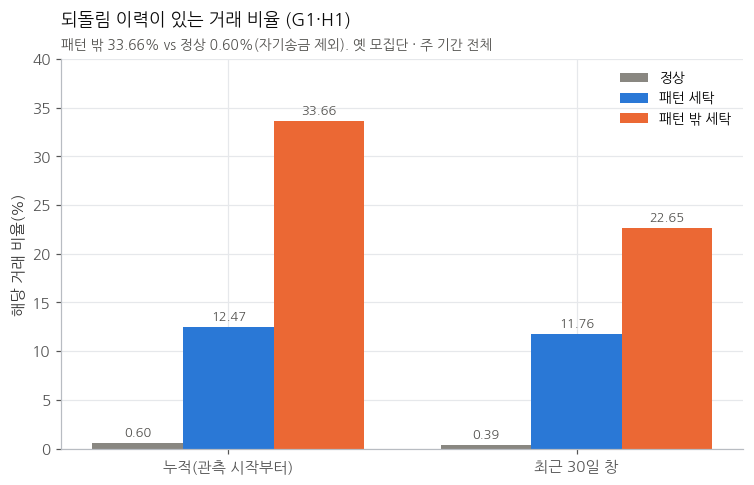

In [58]:
# 원본: notebooks/12 cell 9 왼쪽 패널. 바꾼 곳: 한 칸 그림, 부제·저장.
fig, ax = plt.subplots(figsize=(8, 4.6))
grp = [('정상(%)', '정상', C_NORM), ('패턴(%)', '패턴 세탁', C_PAT), ('패턴 밖(%)', '패턴 밖 세탁', C_OOP)]
x = np.arange(2)
w = 0.26
for i, (c, nm, col) in enumerate(grp):
    b = ax.bar(x + (i - 1) * w, H1.loc[REVC, c], width=w, color=col, label=nm)
    label_bars(ax, b, fmt='{:.2f}', dy=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['누적(관측 시작부터)', '최근 30일 창'])
ax.set_ylim(0, 40)
ax.set_ylabel('해당 거래 비율(%)')
ax.legend(frameon=False, fontsize=9)
title(ax, '되돌림 이력이 있는 거래 비율 (G1·H1)', '패턴 밖 33.66% vs 정상 0.60%(자기송금 제외). 옛 모집단 · 주 기간 전체')
savefig(fig, 'S5_4_되돌림.png')

**해석**
- 되돌림 이력(누적): **정상 0.60 · 패턴 12.47 · 패턴 밖 33.66%.** 최근 30일 창으로 재면 0.39 · 11.76 · 22.65% 다.
- 활동량을 맞춘 층화 OR 은 누적 기준 패턴 8.3 · 패턴 밖 29.4 다. **패턴 밖 세탁을 가르는 가장 강한 신호 중 하나**다.
- V4 가 원본에서 따로 다시 세어 불일치 0 을 확인했다. 자기송금을 포함한 예전 정의(B6b)는 **대체됐다**(부록 A).

### 5-5. 패턴 원문 전달 구조(P1~P3) [가벼움 · 실행]
원본: `notebooks/11_패턴원문_전달구조.ipynb` cell 1~5(09-18). 패턴 원문만 읽는다. 바꾼 곳: 쓰기 경로 `OUT`(이 노트북 `out/`), 데이터프레임 이름 `C` → `CH`(다른 코드의 `C` 와 겹치지 않게).
**반드시 "라벨을 알고 난 뒤의 모양"이다.** 패턴 블록 안 거래만 본다. 탐지 규칙이 아니다.

In [59]:
# 원본: notebooks/11 cell 1 (바꾼 곳: OUT 줄 → 주석. 쓰기는 이 노트북 out/)
import re, math
from datetime import datetime
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd

SRC = Path('/workspace/IBM_AML_dataset/HI-Large_Patterns.txt')
# OUT = Path('/workspace/Final_preprocess/HI-Large_EDA/results')   ← (통합본) 이 노트북의 OUT(out/)을 씀
BEGIN = re.compile(r'BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Z\-]+)')
END = re.compile(r'END LAUNDERING ATTEMPT')

# 시도(attempt)별 거래 행 파싱. 행 = (ts분, src키, dst키, 수취액, 수취통화, 송금액, 송금통화, 결제수단)
attempts, cur, cur_type = [], None, None
for line in SRC.read_text(errors='replace').splitlines():
    s = line.strip()
    if not s: continue
    m = BEGIN.search(s)
    if m: cur_type, cur = m.group(1), []; continue
    if END.search(s):
        if cur: attempts.append((cur_type, cur))
        cur, cur_type = None, None; continue
    if cur is None: continue
    f = s.split(',')
    if len(f) != 11: continue
    try:
        ts = datetime.strptime(f[0], '%Y/%m/%d %H:%M').timestamp() / 60.0
        cur.append((ts, (f[1].lstrip('0') or '0') + '_' + f[2], (f[3].lstrip('0') or '0') + '_' + f[4],
                    float(f[5]), f[6], float(f[7]), f[8], f[9]))
    except ValueError:
        pass
print(f'시도 {len(attempts):,}개 · 거래 {sum(len(t) for _, t in attempts):,}건')

시도 16,467개 · 거래 137,936건


In [60]:
# 원본: notebooks/11 cell 2 (바꾼 곳: C → CH)
# 1. 연속 홉 쌍: 같은 시도 안에서 j 가 받은 거래(i→j) 다음에 j 가 보낸 거래(j→k, 시각 >= 수신 시각)
#    수신 1건마다 '그 다음 첫 송신' 하나만 짝짓는다(같은 계좌가 여러 번 받으면 각각 다음 송신과).
hop_rows, acct_rows, chain_rows = [], [], []
for typ, tx in attempts:
    tx = sorted(tx)
    by_src = defaultdict(list)
    for r in tx: by_src[r[1]].append(r)
    recv_by, send_by = defaultdict(list), defaultdict(list)
    for r in tx:
        recv_by[r[2]].append(r); send_by[r[1]].append(r)
    for r in tx:
        ts, src, dst, recv_amt, recv_ccy, paid_amt, paid_ccy, fmt = r
        if src == dst: continue                      # 자기송금은 홉이 아님
        nxt = [q for q in by_src.get(dst, []) if q[0] >= ts and q[2] != dst]
        if not nxt: continue
        q = nxt[0]                                    # 그 다음 첫 송신
        same_ccy = (q[6] == recv_ccy)
        hop_rows.append(dict(유형=typ, 지연분=q[0] - ts, 통화같음=same_ccy,
                             비율=(q[5] / recv_amt) if (same_ccy and recv_amt > 0) else np.nan))
    # 2. 시도 안 계좌별 통과 비율(같은 통화끼리만 합산)
    accts = set(recv_by) & set(send_by)
    for a in accts:
        rin = defaultdict(float); rout = defaultdict(float)
        for r in recv_by[a]:
            if r[1] != a: rin[r[4]] += r[3]
        for r in send_by[a]:
            if r[2] != a: rout[r[6]] += r[5]
        for c in set(rin) & set(rout):
            acct_rows.append(dict(유형=typ, 통화=c, 통과비율=rout[c] / rin[c]))
    # 3. 체인 내 통화 전환: 홉(j→k)의 송금 통화가 j 의 직전 수신 통화와 다른가
    for a in accts:
        rs = sorted(recv_by[a]); ss = sorted(send_by[a])
        for q in ss:
            prev = [r for r in rs if r[0] <= q[0] and r[1] != a]
            if prev:
                chain_rows.append(dict(유형=typ, 통화전환=(prev[-1][4] != q[6])))
H = pd.DataFrame(hop_rows); A = pd.DataFrame(acct_rows); CH = pd.DataFrame(chain_rows)
print(f'연속 홉 쌍 {len(H):,} · 통과 계좌×통화 {len(A):,} · 체인 홉 {len(CH):,}')

연속 홉 쌍 54,915 · 통과 계좌×통화 23,698 · 체인 홉 55,080


In [61]:
# 원본: notebooks/11 cell 3
def q(s, p): return float(np.nanpercentile(s, p)) if len(s) else np.nan
rows = []
for typ, g in H.groupby('유형'):
    r = g['비율'].dropna()
    rows.append(dict(유형=typ, 홉쌍=len(g), 통화같음비율=g['통화같음'].mean()*100,
                     지연p25분=q(g['지연분'],25), 지연p50분=q(g['지연분'],50), 지연p75분=q(g['지연분'],75),
                     지연1일안=(g['지연분']<=1440).mean()*100, 지연7일안=(g['지연분']<=10080).mean()*100,
                     지연30일안=(g['지연분']<=43200).mean()*100,
                     비율p10=q(r,10), 비율p50=q(r,50), bi율p90=q(r,90),
                     비율0_9_1_1=((r>=0.9)&(r<=1.1)).mean()*100 if len(r) else np.nan,
                     비율0_8_1_2=((r>=0.8)&(r<=1.2)).mean()*100 if len(r) else np.nan,
                     비율1_0_1_1=((r>=1.0)&(r<=1.1)).mean()*100 if len(r) else np.nan))
T1 = pd.DataFrame(rows).rename(columns={'bi율p90':'비율p90'})
T1.to_csv(OUT / 'P1_패턴원문_연속홉_전달.csv', index=False)
print('■ 연속 홉 쌍(받은 뒤 다음 송신): 지연·같은 통화 넘김 비율')
print(T1.round(2).to_string(index=False))

■ 연속 홉 쌍(받은 뒤 다음 송신): 지연·같은 통화 넘김 비율
            유형    홉쌍  통화같음비율  지연p25분  지연p50분  지연p75분  지연1일안  지연7일안  지연30일안  비율p10  비율p50  비율p90  비율0_9_1_1  비율0_8_1_2  비율1_0_1_1
         CYCLE  9883   43.97  1926.0  4774.0 10407.5  18.90  73.83   98.74   0.92   1.00   1.09      91.72      96.66      48.50
GATHER-SCATTER 12932   41.53  8264.0 22103.5 36471.0  10.50  28.54   86.75   0.17   1.01   7.21       8.38      16.16       4.32
        RANDOM  7299   41.47  1801.0  4410.0  9232.5  20.04  77.85   99.49   0.92   1.00   1.09      91.34      96.96      48.07
SCATTER-GATHER 12963   44.36 21059.0 25124.0 29089.0   0.32   3.19   98.99   0.84   1.00   1.19      52.83      89.97      27.55
         STACK 11838   40.73  9158.0 18496.0 28192.0   3.78  27.27  100.00   0.94   1.00   1.06      95.91      96.23      47.78


In [62]:
# 원본: notebooks/11 cell 4 (바꾼 곳: C → CH)
rows = []
for typ, g in A.groupby('유형'):
    r = g['통과비율']
    rows.append(dict(유형=typ, 계좌통화=len(g), p10=q(r,10), p25=q(r,25), p50=q(r,50), p75=q(r,75), p90=q(r,90),
                     비율0_8_1_2=((r>=0.8)&(r<=1.2)).mean()*100, 비율0_5이상=(r>=0.5).mean()*100))
T2 = pd.DataFrame(rows)
T2.to_csv(OUT / 'P2_패턴원문_계좌_통과비율.csv', index=False)
print('■ 시도 안 계좌별 통과 비율 = 같은 통화 송신 합 / 수신 합')
print(T2.round(3).to_string(index=False))

T3 = CH.groupby('유형')['통화전환'].agg(홉수='size', 통화전환비율=lambda s: s.mean()*100).reset_index()
T3.to_csv(OUT / 'P3_패턴원문_체인내_통화전환.csv', index=False)
print('\n■ 체인 홉(j→k)의 송금 통화가 j 의 직전 수신 통화와 다른 비율')
print(T3.round(2).to_string(index=False))

■ 시도 안 계좌별 통과 비율 = 같은 통화 송신 합 / 수신 합
            유형  계좌통화   p10   p25   p50   p75   p90  비율0_8_1_2  비율0_5이상
         CYCLE  5679 0.917 0.954 1.000 1.048 1.097     94.911   99.014
GATHER-SCATTER  2671 0.041 0.233 0.659 1.453 3.951     13.478   58.667
        RANDOM  3155 0.921 0.956 1.000 1.037 1.089     97.021   99.461
SCATTER-GATHER  6543 0.838 0.899 0.998 1.080 1.189     89.898   99.037
         STACK  5650 0.939 0.963 1.000 1.026 1.060     93.168   97.894

■ 체인 홉(j→k)의 송금 통화가 j 의 직전 수신 통화와 다른 비율
            유형    홉수  통화전환비율
         CYCLE  9883   56.03
GATHER-SCATTER 13101   55.40
        RANDOM  7299   58.53
SCATTER-GATHER 12959   55.66
         STACK 11838   59.27


In [63]:
# 원본: notebooks/11 cell 5 (바꾼 곳: C → CH)
# 요약: 전체(유형 무관)
r = H['비율'].dropna()
print(f"전체 연속 홉 쌍 {len(H):,}: 같은 통화 {H['통화같음'].mean()*100:.1f}% · "
      f"지연 p50 {q(H['지연분'],50)/1440:.2f}일 · 7일 안 {(H['지연분']<=10080).mean()*100:.1f}% · 30일 안 {(H['지연분']<=43200).mean()*100:.1f}%")
print(f"같은 통화 넘김 비율(송신/직전 수신): p10 {q(r,10):.3f} · p50 {q(r,50):.3f} · p90 {q(r,90):.3f} · "
      f"0.9~1.1 안 {((r>=0.9)&(r<=1.1)).mean()*100:.1f}% · 0.8~1.2 안 {((r>=0.8)&(r<=1.2)).mean()*100:.1f}%")
print(f"체인 내 통화 전환 홉 비율(전체): {CH['통화전환'].mean()*100:.1f}%  (홉 {len(CH):,})")

전체 연속 홉 쌍 54,915: 같은 통화 42.5% · 지연 p50 11.88일 · 7일 안 37.0% · 30일 안 96.3%
같은 통화 넘김 비율(송신/직전 수신): p10 0.758 · p50 1.000 · p90 1.369 · 0.9~1.1 안 63.8% · 0.8~1.2 안 76.4%
체인 내 통화 전환 홉 비율(전체): 56.8%  (홉 55,080)


**정상 기준(V2)의 원래 계산** — `notebooks/13_V2_받은만큼_재송금_정상기준.ipynb` 코드 셀 전부(643줄). 옛 모집단 전 행(index_full 1.6 GB · g08 npz · interim 통화·금액)에서 "계좌가 받은 뒤 다음 첫 송신이 받은 금액의 ±10% 안인가"를 정상·세탁 모두에 대해 센다. 입력이 모두 있어 **무거운 셀로 옮겼다(꺼짐).** 아래 대조 셀이 저장된 `V2_수신기준_다음송신.csv` 를 읽는다.

In [64]:
# [무거움 · 기본 꺼짐] 원본: notebooks/13_V2_받은만큼_재송금_정상기준.ipynb cell 1 · 2 · 3 · 4 · 5 · 6 · 7 · 8 · 9
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: 결과 폴더 OUT = C.OUT → OUT_NB, 기록 LOG = _logs/V2_run.log → out/V2_run.log (읽기 C.OUT 는 그대로)
def _heavy_V2():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 1 ──
    # ── 공통: 경로·상수·메모리 감시 ── (eda_common 은 읽기만 한다)
    import sys, os, gc, json, re, time, threading
    from pathlib import Path
    from collections import defaultdict
    from datetime import datetime
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np
    import pandas as pd
    import eda_common as C

    pd.set_option('display.width', 250, 'display.max_columns', 60, 'display.max_rows', 200)
    DRY = int(os.environ.get('V2_DRY', '0'))                      # 0 = 전량
    PFX = 'DRY_' if DRY else ''
    OUT = Path(os.environ.get('V2_DRY_OUT', '/tmp')) if DRY else OUT_NB   # (통합본) 원래 C.OUT(results)   # DRY 결과는 results/ 에 쓰지 않는다
    OUT.mkdir(parents=True, exist_ok=True)
    LOG = (OUT / 'V2_dry.log') if DRY else (OUT_NB / 'V2_run.log')   # (통합본) 원래 HI-Large_EDA/_logs
    TB = 20
    MASK = (1 << TB) - 1
    STEP = 10_000_000
    D1, D7, D30 = 1440, 10080, 43200                              # 1일·7일·30일(분) — 출처는 위 표
    T_START = time.time()
    TYPE_NAMES = {-1: '정상', **dict(enumerate(C.CLASS_NAMES)), 8: '패턴 밖 세탁'}
    GROUPS = ['정상', '패턴 세탁', '패턴 밖 세탁'] + C.CLASS_NAMES    # 표에 찍는 순서

    PEAK = {'anon': 0.0, 'stop': False}


    def _watch():
        while not PEAK['stop']:
            PEAK['anon'] = max(PEAK['anon'], C.anon_gib())
            time.sleep(1.0)


    threading.Thread(target=_watch, daemon=True).start()


    def log(msg):
        C.log(f'V2 {msg} · anon {C.anon_gib():.1f} GiB (피크 {PEAK["anon"]:.1f})', LOG)


    def drop_cache(path):
        """읽은 파일의 페이지 캐시를 비운다(08 셀 2 와 같음 — 페이지 캐시도 cgroup 한도에 잡힌다)."""
        try:
            fd = os.open(str(path), os.O_RDONLY)
            os.posix_fadvise(fd, 0, 0, os.POSIX_FADV_DONTNEED)
            os.close(fd)
        except OSError:
            pass


    def i64(a):
        return a.astype(np.int64)


    def by_group(cnt10):
        """길이 10 (0 정상, 1~8 패턴 유형, 9 패턴 밖) 건수 → GROUPS 순서의 dict."""
        cnt10 = np.asarray(cnt10)
        d = {'정상': cnt10[0], '패턴 세탁': cnt10[1:9].sum(0), '패턴 밖 세탁': cnt10[9]}
        d.update({nm: cnt10[k + 1] for k, nm in enumerate(C.CLASS_NAMES)})
        return d


    def pct(a, b):
        return 100.0 * a / b if b else np.nan


    log(f'시작 DRY={DRY}')

    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 2 ──
    # ── 0. 세탁 쪽 기존 수치 확인: P1·P2 csv 를 읽고, 노트북 11 셀 1·2 의 정의를 그대로 다시 돌려 정확한 건수를 낸다 ──
    P1 = pd.read_csv(C.OUT / 'P1_패턴원문_연속홉_전달.csv')
    P2 = pd.read_csv(C.OUT / 'P2_패턴원문_계좌_통과비율.csv')
    print('■ 기존 P1 (results/P1_패턴원문_연속홉_전달.csv) — ±10% 열의 분모는 "같은 통화 홉 쌍"')
    print(P1[['유형', '홉쌍', '통화같음비율', '비율0_9_1_1', '비율0_8_1_2', '지연p50분', '지연7일안', '지연30일안']].round(2).to_string(index=False))
    print('\n■ 기존 P2 (results/P2_패턴원문_계좌_통과비율.csv)')
    print(P2[['유형', '계좌통화', 'p50', '비율0_8_1_2']].round(3).to_string(index=False))

    # 노트북 11 셀 1 과 같은 파싱(시도별 거래 행)
    BEGIN = re.compile(r'BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Z\-]+)')
    END = re.compile(r'END LAUNDERING ATTEMPT')
    attempts, cur, cur_type = [], None, None
    for line in (C.RAW_DIR / 'HI-Large_Patterns.txt').read_text(errors='replace').splitlines():
        s = line.strip()
        if not s:
            continue
        m = BEGIN.search(s)
        if m:
            cur_type, cur = m.group(1), []
            continue
        if END.search(s):
            if cur:
                attempts.append((cur_type, cur))
            cur, cur_type = None, None
            continue
        if cur is None:
            continue
        f = s.split(',')
        if len(f) != 11:
            continue
        try:
            ts_ = datetime.strptime(f[0], '%Y/%m/%d %H:%M').timestamp() / 60.0
            cur.append((ts_, (f[1].lstrip('0') or '0') + '_' + f[2], (f[3].lstrip('0') or '0') + '_' + f[4],
                        float(f[5]), f[6], float(f[7]), f[8], f[9]))
        except ValueError:
            pass
    print(f'\n시도 {len(attempts):,}개 · 거래 {sum(len(t) for _, t in attempts):,}건 (꼬리 포함 — 이 절만 모집단이 다르다)')

    # 노트북 11 셀 2 와 같은 짝짓기: 같은 시도 안에서 수신 1건 → 그 계좌의 다음 첫 송신(시각 ≥ 수신 시각, 자기송금 제외)
    rows0 = []
    for typ, tx in attempts:
        tx = sorted(tx)
        by_src = defaultdict(list)
        for r in tx:
            by_src[r[1]].append(r)
        for r in tx:
            ts_, s_, d_, ramt, rccy = r[0], r[1], r[2], r[3], r[4]
            if s_ == d_:
                continue
            nxt = [q for q in by_src.get(d_, []) if q[0] >= ts_ and q[2] != d_]
            if not nxt:
                rows0.append((typ, False, False, np.nan))
                continue
            q = nxt[0]
            same = (q[6] == rccy)
            rows0.append((typ, True, same, (q[5] / ramt) if (same and ramt > 0) else np.nan))
    H0 = pd.DataFrame(rows0, columns=['유형', '다음송신있음', '통화같음', '비율'])
    t0rows = []
    for typ, g in list(H0.groupby('유형')) + [('패턴 전체(8유형)', H0)]:
        hp = g[g['다음송신있음']]
        r = hp['비율'].dropna()
        n10 = int(((r >= 0.9) & (r <= 1.1)).sum())
        n20 = int(((r >= 0.8) & (r <= 1.2)).sum())
        t0rows.append({'유형': typ, '시도 안 수신(자기송금 제외)': len(g), '홉 쌍(시도 안 다음 송신 있음)': len(hp),
                       '같은 통화 홉 쌍': int(hp['통화같음'].sum()), '±10% 안': n10, '±20% 안': n20,
                       '±10% / 같은 통화 홉 쌍(%)': pct(n10, len(r)), '±10% / 홉 쌍(%)': pct(n10, len(hp)),
                       '±10% / 시도 안 수신(%)': pct(n10, len(g)), '±20% / 같은 통화 홉 쌍(%)': pct(n20, len(r))})
    T0 = pd.DataFrame(t0rows)
    print('\n■ 노트북 11 정의 재실행 — 정확한 건수 (±10% = 다음 송신 송금액/수신액 0.9~1.1, 같은 통화만)')
    print(T0.round(2).to_string(index=False))
    # 기존 P1 과 맞는지 확인(같은 정의이므로 일치해야 한다)
    chk = T0.merge(P1[['유형', '홉쌍', '비율0_9_1_1']], on='유형')
    assert (chk['홉 쌍(시도 안 다음 송신 있음)'] == chk['홉쌍']).all(), 'P1 홉 쌍 수와 다르다'
    assert np.allclose(chk['±10% / 같은 통화 홉 쌍(%)'], chk['비율0_9_1_1'], atol=1e-6), 'P1 ±10% 비율과 다르다'
    print('\nP1 csv 와 일치 확인: 홉 쌍 수·±10% 비율 모두 같음')
    gs = T0.set_index('유형').loc['GATHER-SCATTER']
    print(f"GATHER-SCATTER: 같은 통화 홉 쌍 {int(gs['같은 통화 홉 쌍']):,} 중 ±10% 안 {int(gs['±10% 안']):,} = {gs['±10% / 같은 통화 홉 쌍(%)']:.2f}%"
          f" (홉 쌍 {int(gs['홉 쌍(시도 안 다음 송신 있음)']):,} 기준 {gs['±10% / 홉 쌍(%)']:.2f}%)")
    for t in ('CYCLE', 'RANDOM', 'STACK', 'SCATTER-GATHER'):
        x = T0.set_index('유형').loc[t]
        print(f"{t}: 같은 통화 홉 쌍 {int(x['같은 통화 홉 쌍']):,} 중 ±10% 안 {int(x['±10% 안']):,} = {x['±10% / 같은 통화 홉 쌍(%)']:.2f}%"
              f" (홉 쌍 {int(x['홉 쌍(시도 안 다음 송신 있음)']):,} 기준 {x['±10% / 홉 쌍(%)']:.2f}%)")
    print('FAN-OUT·FAN-IN·BIPARTITE 의 시도 안 홉 쌍 수:', {t: int(H0.loc[H0['유형'] == t, '다음송신있음'].sum()) for t in ('FAN-OUT', 'FAN-IN', 'BIPARTITE')})
    del attempts, rows0, H0
    gc.collect()
    log('0절 완료')

    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 3 ──
    # ── 모집단 적재: 색인(ts·src·dst) + 08 이 저장한 gt·strat·split + 원본 parquet 의 통화·금액(열 투영, 파트별) ──
    meta = json.loads((C.MAIN / 'features_meta.json').read_text())
    n_acc = int(meta['split']['n_accounts'])
    n_full = int(sum(meta['split']['rows']))
    n = DRY or n_full

    idx = np.load(C.MAIN / 'index_full.npz')


    def ix(k, dt):
        a = idx[k]
        out = np.array(a[:n], dtype=dt)
        del a
        gc.collect()
        return out


    ts = ix('ts_min', np.int32)
    src = ix('src_id', np.int32)
    dst = ix('dst_id', np.int32)
    del idx
    drop_cache(C.MAIN / 'index_full.npz')
    assert int(ts.min()) >= 0 and int(ts.max()) <= MASK and n_acc < (1 << 22)
    assert bool((ts[1:] >= ts[:-1]).all()), '전처리 행이 시간순이 아니다(안정 정렬 가정이 깨진다)'
    TS_MAX = int(ts.max())

    z = np.load(C.WORK / 'g08_targets_packed.npz')
    assert int(z['n']) == n_full
    gt = np.array(z['gt'][:n], dtype=np.int8)                      # -1 정상 / 0~7 패턴 유형 / 8 패턴 밖
    strat = np.array(z['strat'][:n], dtype=np.int8)                # 송신 계좌의 이전 송신 건수 층(08 셀 4)
    split = np.array(z['split'][:n], dtype=np.int8)
    names08 = [str(x) for x in z['names']]
    J1 = names08.index('넘기기: 1일 안 같은 통화 수취액의 80~120% 송금')
    J7 = names08.index('넘기기: 7일 안 같은 통화 수취액의 80~120% 송금')
    band1_08 = np.unpackbits(z[f't{J1}'])[:n_full][:n].astype(bool)  # 08 셀 8 의 1일 합계 밴드 플래그
    band7_08 = np.unpackbits(z[f't{J7}'])[:n_full][:n].astype(bool)
    del z
    drop_cache(C.WORK / 'g08_targets_packed.npz')
    g10 = (gt + 1).astype(np.int8)                                 # 0 정상 / 1~8 패턴 유형 / 9 패턴 밖
    g3 = np.where(gt < 0, 0, np.where(gt == 8, 2, 1)).astype(np.int8)
    cnt_g = np.bincount(g3, minlength=3)
    print(f'행 {n:,} · 정상 {cnt_g[0]:,} · 패턴 세탁 {cnt_g[1]:,} · 패턴 밖 세탁 {cnt_g[2]:,}')
    if not DRY:
        assert (int(cnt_g[0]), int(cnt_g[1]), int(cnt_g[2])) == (179_449_408, 113_663, 87_610), '모집단이 기존 표와 다르다'

    ps, starts = C.part_starts()
    p2r = np.array(np.load(C.ALIGN / 'new_proc2raw.npy', mmap_mode='r')[:n], dtype=np.int64)


    def raw_col(c, dtype):
        """원본 순서 parquet 의 한 열을 파트별로 읽어 전처리 행 순서로 옮긴다(08 셀 2 와 같음) + 캐시 비우기."""
        chunks = []
        for f in ps:
            chunks.append(pd.read_parquet(f, columns=[c])[c].to_numpy())
            drop_cache(f)
        full = np.concatenate(chunks).astype(dtype, copy=False)
        del chunks
        out = full[p2r]
        del full
        gc.collect()
        return out


    pay_v = C.vocab('pay')
    assert pay_v == C.vocab('recv') and len(pay_v) <= 16
    BTC = pay_v.index('Bitcoin')
    scale = np.where(np.arange(len(pay_v)) == BTC, 1e6, 1e2)       # 정수 최소 단위 — 08 셀 8 과 같음
    payc = raw_col('pay_code', np.int8)
    recvc = raw_col('recv_code', np.int8)
    paid = raw_col('paid', np.float64)
    p_int = np.rint(paid * scale[payc]).astype(np.int64)
    del paid
    recv = raw_col('recv', np.float64)
    r_int = np.rint(recv * scale[recvc]).astype(np.int64)
    del recv, p2r
    gc.collect()
    assert int(p_int.max()) < 7 * 10**17 and int(r_int.max()) < 7 * 10**17, '×12 정수 곱에서 넘칠 수 있다'
    NS = src != dst                                                # 자기송금 제외 행
    ns_g = np.bincount(g10[NS], minlength=10)
    print('자기송금 제외 행:', {k: int(v) for k, v in by_group(ns_g).items()})
    print(f'금액 0 이하: 송금 {int((p_int <= 0).sum()):,} · 수취 {int((r_int <= 0).sum()):,} · 송금통화≠수취통화 행 {int((payc != recvc).sum()):,}')
    log('모집단 적재 완료')

    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 4 ──
    # ── 자체 점검 준비: 표본 행에 대해 정의를 '무차별 대입'(계좌의 전 행을 훑는 단순 구현)으로 미리 계산해 둔다 ──
    # 뒤의 정렬·searchsorted 구현이 같은 값을 내는지 절마다 대조한다. 표본 크기(그룹별 100행, 자기송금 50행)·시드는 임의(이 점검용).
    rng = np.random.default_rng(20260918)
    S_rows = []
    for gi in (0, 1, 2):
        pool = np.flatnonzero((g3 == gi) & NS)
        S_rows.append(np.sort(rng.choice(pool, min(100, len(pool)), replace=False)))
        del pool
    S_ns = np.sort(np.concatenate(S_rows))                           # 1·2·4절 공통 표본(자기송금 제외 행)
    pool = np.flatnonzero(~NS)
    S_self = np.sort(rng.choice(pool, min(50, len(pool)), replace=False))   # 4절 전용(자기송금 송신 행)
    del pool, S_rows
    S4 = np.sort(np.concatenate([S_ns, S_self]))
    gc.collect()


    def _band(p, r, lo_, hi_):
        p, r = int(p), int(r)
        return p > 0 and r > 0 and p * 10 >= r * lo_ and p * 10 <= r * hi_


    EXP1, EXP2, EXP4 = {}, {}, {}
    for r in S4.tolist():
        i, j, t = int(src[r]), int(dst[r]), int(ts[r])
        rin = np.flatnonzero(dst == i)                               # 송신 계좌 i 가 받은 모든 행(자기송금 포함)
        rin = rin[(recvc[rin] == payc[r]) & (ts[rin] < t)]           # 같은 통화 · 엄격히 이전 분
        w = rin[ts[rin] >= max(t - D1, 0)]                           # 4절: 1일 창(자기송금 수신 포함 — 08 과 같음)
        sm = sum(int(x) for x in r_int[w])
        EXP4[r] = (len(w), _band(p_int[r], sm, 8, 12), any(_band(p_int[r], x, 8, 12) for x in r_int[w]))
        if i != j:
            rr = rin[src[rin] != i][-10:]                            # 2절: 자기송금 제외 최근 10건(행 순서 = 시간 순서)
            hit = [(_band(p_int[r], r_int[x], 9, 11), t - int(ts[x])) for x in rr]
            EXP2[r] = (len(rr) > 0, any(h for h, _ in hit), any(h and l <= D7 for h, l in hit), any(h and l <= D30 for h, l in hit),
                       len(rr) > 0 and (t - int(ts[rr[-1]])) <= D7, len(rr) > 0 and (t - int(ts[rr[-1]])) <= D30)
            out = np.flatnonzero(src == j)                           # 1절: 수신 계좌 j 의 송신(자기송금 제외)
            out = out[dst[out] != j]
            for v, strict in enumerate((False, True)):
                c = out[ts[out] > t] if strict else out[ts[out] >= t]
                if len(c) == 0:
                    EXP1[(v, r)] = (False, False, False, -1)
                else:
                    x = int(c[0])
                    same = bool(payc[x] == recvc[r])
                    EXP1[(v, r)] = (True, same, same and _band(p_int[x], r_int[r], 9, 11), int(ts[x]) - t)
    GOT1, GOT4 = {}, {}
    log(f'자체 점검 기대값 계산 완료 · 표본 {len(S_ns)}행 + 자기송금 {len(S_self)}행')

    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 5 ──
    # ── 1. [수신 기준·라벨 무관] 수신 1건 → 그 계좌의 다음 첫 송신(자기송금 제외) ──
    # 송신 표: (송신 계좌, 시각) 순. 전처리 행이 이미 시간순이므로 계좌 번호로 안정 정렬하면 (계좌, 시각, 행 순서)가 된다.
    # 자기송금 행은 계좌 번호를 n_acc(없는 계좌)로 바꿔 맨 뒤로 보낸다 → 어떤 질의와도 짝이 되지 않는다.
    def sorted_key(group32, order):
        """정렬 순서대로 (그룹<<20 | 분) int64 키를 제자리 연산으로 만든다(임시 배열을 줄이려고)."""
        k = group32[order].astype(np.int64)
        k <<= TB
        k |= ts[order]
        return k


    sk32 = np.where(NS, src, np.int32(n_acc)).astype(np.int32)
    o = np.argsort(sk32, kind='stable')
    Skey = sorted_key(sk32, o)                                      # 정렬된 (계좌<<20 | 분)
    del sk32
    o32 = o.astype(np.int32)
    del o
    gc.collect()
    assert bool((Skey[1:] >= Skey[:-1]).all())
    log('1절 송신 표 정렬 완료')

    VAR = [('시각 ≥ 수신 시각(노트북 11 과 같음)', 'left'), ('엄격히 이후 분', 'right')]
    KEYS = ['recv', 'has', 'same', 'in10', 'in20', 'in10_1d', 'in10_7d', 'in10_30d', 'has_1d', 'has_7d', 'has_30d', 'amb']
    L = TS_MAX + 1
    acc1 = [{k: np.zeros(10, np.int64) for k in KEYS} for _ in VAR]
    lagh = [np.zeros(10 * L, np.int64) for _ in VAR]               # 그룹×지연(분) 히스토그램 — 분위수용
    for a in range(0, n, STEP):
        e = min(a + STEP, n)
        m = NS[a:e]
        d_ = dst[a:e]
        t_ = i64(ts[a:e])
        q = (i64(d_) << TB) | t_
        g_ = g10[a:e].astype(np.int64)
        r_ = r_int[a:e]
        rc = recvc[a:e]
        for v, (_, side) in enumerate(VAR):
            pos = np.searchsorted(Skey, q, side=side)
            posc = np.minimum(pos, n - 1)
            sk = Skey[posc]
            has = m & (pos < n) & ((sk >> TB) == d_)               # 그 계좌의 다음 송신이 있다
            nx = o32[posc]
            lag = (sk & MASK) - t_
            same = has & (payc[nx] == rc)                           # 다음 송신의 송금 통화 = 이번 수신 통화
            p_ = p_int[nx]
            ok = same & (r_ > 0) & (p_ > 0)
            in10 = ok & (p_ * 10 >= r_ * 9) & (p_ * 10 <= r_ * 11)   # 송금/수신 0.9~1.1
            in20 = ok & (p_ * 10 >= r_ * 8) & (p_ * 10 <= r_ * 12)   # 송금/수신 0.8~1.2 (P1 의 ±20% 열과 비교용)
            pos1 = np.minimum(posc + 1, n - 1)
            amb = has & (pos1 > posc) & (Skey[pos1] == sk)          # 첫 송신 분에 송신이 2건+ → '첫'의 순서는 행 순서로 끊은 것
            A = acc1[v]
            for k, mk in (('recv', m), ('has', has), ('same', same), ('in10', in10), ('in20', in20),
                          ('in10_1d', in10 & (lag <= D1)), ('in10_7d', in10 & (lag <= D7)), ('in10_30d', in10 & (lag <= D30)),
                          ('has_1d', has & (lag <= D1)), ('has_7d', has & (lag <= D7)), ('has_30d', has & (lag <= D30)), ('amb', amb)):
                A[k] += np.bincount(g_[mk], minlength=10)
            lagh[v] += np.bincount(g_[has] * L + lag[has], minlength=10 * L)
            for r in S_ns[(S_ns >= a) & (S_ns < e)].tolist():      # 자체 점검용 기록
                GOT1[(v, r)] = (bool(has[r - a]), bool(same[r - a]), bool(in10[r - a]), int(lag[r - a]) if has[r - a] else -1)
            del pos, posc, sk, has, nx, lag, same, p_, ok, in10, in20, pos1, amb
        del m, d_, t_, q, g_, r_, rc
        gc.collect()
        if a % (5 * STEP) == 0:
            log(f'1절 {e:,}/{n:,}')
    del Skey, o32
    gc.collect()


    def hq(h, p):
        """히스토그램에서 분위수(이하 누적이 p 에 처음 닿는 분)."""
        c = np.cumsum(h)
        return float(np.searchsorted(c, p / 100 * c[-1], side='left')) if c[-1] else np.nan


    rows1 = []
    for v, (vname, _) in enumerate(VAR):
        G = {k: by_group(acc1[v][k]) for k in KEYS}
        H = lagh[v].reshape(10, L)
        Hg = {'정상': H[0], '패턴 세탁': H[1:9].sum(0), '패턴 밖 세탁': H[9], **{nm: H[k + 1] for k, nm in enumerate(C.CLASS_NAMES)}}
        for gname in GROUPS:
            c = {k: int(G[k][gname]) for k in KEYS}
            rows1.append({'시점 규칙': vname, '그룹(수신 거래의 라벨)': gname, '수신 거래(자기송금 제외)': c['recv'],
                          '다음 송신 있음': c['has'], '다음 송신 같은 통화': c['same'], '±10% 안': c['in10'],
                          '±10%·1일 안': c['in10_1d'], '±10%·7일 안': c['in10_7d'], '±10%·30일 안': c['in10_30d'], '±20% 안': c['in20'],
                          '다음 송신 1일 안': c['has_1d'], '다음 송신 7일 안': c['has_7d'], '다음 송신 30일 안': c['has_30d'],
                          '첫 송신 분에 송신 2건+(순서 모호)': c['amb'],
                          '다음 송신 있음(%)': pct(c['has'], c['recv']), '같은 통화 / 다음 송신 있음(%)': pct(c['same'], c['has']),
                          '±10% / 전체 수신(%)': pct(c['in10'], c['recv']), '±10% / 같은 통화 다음 송신(%)': pct(c['in10'], c['same']),
                          '±10%·7일 안 / 전체 수신(%)': pct(c['in10_7d'], c['recv']), '±10%·30일 안 / 전체 수신(%)': pct(c['in10_30d'], c['recv']),
                          '±20% / 같은 통화 다음 송신(%)': pct(c['in20'], c['same']),
                          '지연 p25(분)': hq(Hg[gname], 25), '지연 p50(분)': hq(Hg[gname], 50), '지연 p75(분)': hq(Hg[gname], 75)})
    V2a = pd.DataFrame(rows1)
    V2a.to_csv(OUT / f'{PFX}V2_수신기준_다음송신.csv', index=False)
    for vname, _ in VAR:
        x = V2a[V2a['시점 규칙'] == vname]
        print(f'\n■ 1절 [{vname}] 건수')
        print(x[['그룹(수신 거래의 라벨)', '수신 거래(자기송금 제외)', '다음 송신 있음', '다음 송신 같은 통화', '±10% 안', '±10%·7일 안', '±10%·30일 안', '±20% 안', '첫 송신 분에 송신 2건+(순서 모호)']].to_string(index=False))
        print(f'■ 1절 [{vname}] 비율(%)·지연')
        print(x[['그룹(수신 거래의 라벨)', '다음 송신 있음(%)', '같은 통화 / 다음 송신 있음(%)', '±10% / 전체 수신(%)', '±10% / 같은 통화 다음 송신(%)',
                 '±10%·7일 안 / 전체 수신(%)', '±10%·30일 안 / 전체 수신(%)', '±20% / 같은 통화 다음 송신(%)', '지연 p25(분)', '지연 p50(분)', '지연 p75(분)']].round(3).to_string(index=False))
    del lagh
    gc.collect()
    bad1 = [k for k in EXP1 if EXP1[k] != GOT1.get(k)]
    print(f'\n자체 점검(1절): 표본 {len(EXP1)}건(행×시점 규칙) 중 불일치 {len(bad1)}건')
    assert not bad1, bad1[:5]
    log('1절 완료')

    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 6 ──
    # ── 4. [항목 8-2] 1일 창 같은 통화 수신 '합계' 밴드(08 셀 8 그대로) vs '개별 1건' ±20% 일치 ──
    # 수신 표(전 행, 자기송금 수신 포함 — 08 셀 8 과 같음): (수신 계좌, 수취 통화, 시각) 순. 계좌<<4|통화 는 26비트라 int32 로 안정 정렬한다.
    gk32 = ((dst << 4) | recvc.astype(np.int32)).astype(np.int32)
    del dst, recvc
    oR = np.argsort(gk32, kind='stable')
    RkeyAll = sorted_key(gk32, oR)
    del gk32
    RamtAll = r_int[oR]
    del r_int
    keepNS = NS[oR]                                                 # 2절에서 자기송금 수신을 뺄 때 쓴다
    del oR
    gc.collect()
    assert bool((RkeyAll[1:] >= RkeyAll[:-1]).all())
    rcw = np.zeros(n + 1, np.int64)
    np.cumsum(RamtAll, out=rcw[1:])
    assert bool(rcw[-1] >= 0) and abs(float(rcw[-1]) - float(RamtAll.sum(dtype=np.float64))) <= 1e-6 * float(rcw[-1]), '누계 넘침'
    log('4절 수신 표 정렬·누계 완료')

    CB_EDGES = [1, 2, 3, 6, 11, 101]                                # 창 안 수신 건수 구간(임의 — 이 점검용)
    CB_NAMES = ['0건', '1건', '2건', '3~5건', '6~10건', '11~100건', '101건+']
    NB = len(CB_NAMES)
    acc4 = np.zeros(10 * NB * 4, np.int64)                          # 그룹 × 건수 구간 × (합계밴드*2 + 개별일치)
    mismatch = 0
    max_cnt = 0
    scan_work = 0
    for a in range(0, n, STEP):
        e = min(a + STEP, n)
        bq = ((i64(src[a:e]) << 4) | i64(payc[a:e])) << TB
        t_ = i64(ts[a:e])
        hi = np.searchsorted(RkeyAll, bq | t_, side='left')                       # 엄격히 이전 분까지
        lo = np.searchsorted(RkeyAll, bq | np.maximum(t_ - D1, 0), side='left')   # 08 과 같은 창 [t-1440, t)
        cnt = (hi - lo)
        pi = p_int[a:e]
        s_ = rcw[hi] - rcw[lo]
        band = (pi > 0) & (s_ > 0) & (pi * 10 >= s_ * 8) & (pi * 10 <= s_ * 12)  # 08 셀 8 의 식 그대로
        mismatch += int((band != band1_08[a:e]).sum())
        # 개별 일치: 창 안 수신을 최근 것부터 하나씩 본다(일치하면 그 행은 멈춤) — 전수·정확
        ind = np.zeros(e - a, bool)
        act = np.flatnonzero((cnt > 0) & (pi > 0))
        k = 1
        while act.size:
            am = RamtAll[hi[act] - k]
            pp = pi[act]
            hit = (am > 0) & (pp * 10 >= am * 8) & (pp * 10 <= am * 12)
            ind[act[hit]] = True
            scan_work += act.size
            k += 1
            act = act[~hit]
            act = act[cnt[act] >= k]
        max_cnt = max(max_cnt, int(cnt.max()))
        for r in S4[(S4 >= a) & (S4 < e)].tolist():                 # 자체 점검용 기록
            GOT4[r] = (int(cnt[r - a]), bool(band[r - a]), bool(ind[r - a]))
        cb = np.digitize(cnt, CB_EDGES).astype(np.int64)
        cell = (g10[a:e].astype(np.int64) * NB + cb) * 4 + band.astype(np.int64) * 2 + ind.astype(np.int64)
        acc4 += np.bincount(cell, minlength=10 * NB * 4)
        del bq, t_, hi, lo, cnt, pi, s_, band, ind, act, cb, cell
        gc.collect()
        if a % (5 * STEP) == 0:
            log(f'4절 {e:,}/{n:,} · 개별 대조 누적 {scan_work:,}회')
    print(f'08 npz 의 1일 합계 밴드 플래그와 다른 행: {mismatch:,} (0 이어야 같은 정의) · 1일 창 안 수신 건수 최대 {max_cnt:,} · 개별 대조 {scan_work:,}회')
    assert mismatch == 0
    bad4 = [k for k in EXP4 if EXP4[k] != GOT4.get(k)]
    print(f'자체 점검(4절): 표본 {len(EXP4)}행 중 불일치 {len(bad4)}행')
    assert not bad4, bad4[:5]
    del rcw
    gc.collect()

    A4 = acc4.reshape(10, NB, 4)                                    # [..., 0]=둘 다 아님 1=개별만 2=합계만 3=둘 다
    G4 = {'정상': A4[0], '패턴 세탁': A4[1:9].sum(0), '패턴 밖 세탁': A4[9], **{nm: A4[k + 1] for k, nm in enumerate(C.CLASS_NAMES)}}
    rows4 = []
    for gname in GROUPS:
        M = G4[gname]
        for bname, x in [('전체', M.sum(0))] + list(zip(CB_NAMES, M)):
            tot = int(x.sum())
            ind_, band_ = int(x[1] + x[3]), int(x[2] + x[3])
            rows4.append({'그룹(송신 행의 라벨)': gname, '1일 창 안 같은 통화 수신 건수': bname, '송신 행': tot,
                          '합계 밴드(80~120%) 해당': band_, '개별 1건 ±20% 일치': ind_, '둘 다': int(x[3]), '개별만(합계 밴드 벗어남)': int(x[1]),
                          '합계만': int(x[2]), '개별 일치 중 합계 밴드 벗어남(%)': pct(int(x[1]), ind_),
                          '합계 밴드 해당(%)': pct(band_, tot), '개별 일치(%)': pct(ind_, tot)})
    V2d = pd.DataFrame(rows4)
    # '개별만' 행의 수신 건수 분포(그룹 안 비중)
    tot_only = V2d[V2d['1일 창 안 같은 통화 수신 건수'] == '전체'].set_index('그룹(송신 행의 라벨)')['개별만(합계 밴드 벗어남)']
    V2d["'개별만' 안 비중(%)"] = [pct(r['개별만(합계 밴드 벗어남)'], int(tot_only[r['그룹(송신 행의 라벨)']])) if r['1일 창 안 같은 통화 수신 건수'] != '전체' else 100.0
                            for _, r in V2d.iterrows()]
    V2d.to_csv(OUT / f'{PFX}V2_합계밴드_대조.csv', index=False)
    print('\n■ 4절 요약(수신 건수 전체)')
    print(V2d[V2d['1일 창 안 같은 통화 수신 건수'] == '전체'].drop(columns=['1일 창 안 같은 통화 수신 건수', "'개별만' 안 비중(%)"]).round(3).to_string(index=False))
    for gname in ('패턴 세탁', '정상', '패턴 밖 세탁'):
        print(f'\n■ 4절 [{gname}] 1일 창 안 수신 건수 구간별')
        print(V2d[(V2d['그룹(송신 행의 라벨)'] == gname)].drop(columns=['그룹(송신 행의 라벨)']).round(3).to_string(index=False))
    log('4절 완료')

    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 7 ──
    # ── 2. [송신 기준·이전 정보만] 송신 계좌의 최근 10건 같은 통화 수신(자기송금 제외, 엄격히 이전 분) 중 ±10% 일치 1건 이상 ──
    Rkey = RkeyAll[keepNS]
    del RkeyAll
    gc.collect()
    Ramt = RamtAll[keepNS]
    del RamtAll, keepNS
    gc.collect()
    nR = len(Rkey)
    log(f'2절 수신 표(자기송금 제외) {nR:,}행')
    K_LAST = 10                                                     # 제안서 §2-F "최근 10건"
    F_all = np.zeros(n, bool)
    F_7 = np.zeros(n, bool)
    F_30 = np.zeros(n, bool)
    E_all = np.zeros(n, bool)                                       # 이전 같은 통화 수신이 1건 이상(분모용)
    E_7 = np.zeros(n, bool)
    E_30 = np.zeros(n, bool)
    for a in range(0, n, STEP):
        e = min(a + STEP, n)
        m = NS[a:e]
        bq = ((i64(src[a:e]) << 4) | i64(payc[a:e])) << TB
        t_ = i64(ts[a:e])
        hi = np.searchsorted(Rkey, bq | t_, side='left')            # 엄격히 이전 분까지
        lo = np.searchsorted(Rkey, bq, side='left')
        pi = p_int[a:e]
        fa = np.zeros(e - a, bool)
        f7 = np.zeros(e - a, bool)
        f30 = np.zeros(e - a, bool)
        for k in range(1, K_LAST + 1):
            act = np.flatnonzero(m & (hi - k >= lo))
            if not act.size:
                break
            ia = hi[act] - k
            am = Ramt[ia]
            lag = t_[act] - (Rkey[ia] & MASK)
            pp = pi[act]
            hit = (am > 0) & (pp > 0) & (pp * 10 >= am * 9) & (pp * 10 <= am * 11)   # 송금/수신 0.9~1.1
            fa[act[hit]] = True
            f7[act[hit & (lag <= D7)]] = True
            f30[act[hit & (lag <= D30)]] = True
            if k == 1:
                ea = np.zeros(e - a, bool)
                ea[act] = True
                e7 = np.zeros(e - a, bool)
                e7[act[lag <= D7]] = True
                e30 = np.zeros(e - a, bool)
                e30[act[lag <= D30]] = True
                E_all[a:e], E_7[a:e], E_30[a:e] = ea, e7, e30
                del ea, e7, e30
            del act, ia, am, lag, pp, hit
        F_all[a:e], F_7[a:e], F_30[a:e] = fa, f7, f30
        del m, bq, t_, hi, lo, pi, fa, f7, f30
        gc.collect()
        if a % (5 * STEP) == 0:
            log(f'2절 {e:,}/{n:,}')
    del Rkey, Ramt
    gc.collect()
    assert not (F_all & ~NS).any() and not (F_7 & ~F_30).any() and not (F_30 & ~F_all).any()
    bad2 = [r for r in EXP2 if EXP2[r] != (bool(E_all[r]), bool(F_all[r]), bool(F_7[r]), bool(F_30[r]), bool(E_7[r]), bool(E_30[r]))]
    print(f'자체 점검(2절): 표본 {len(EXP2)}행 중 불일치 {len(bad2)}행')
    assert not bad2, bad2[:5]
    log('2절 플래그 완료')

    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 8 ──
    # ── 2·3. 그룹별 / 활동량 층별 비율, 층화 Mantel–Haenszel OR(08 셀 11 의 mh_or 그대로) ──
    STRAT_NAMES = ['0', '1~9', '10~99', '100~999', '1000+']          # 08 셀 4: 송신 계좌의 엄격히 이전 분 송신 건수(자기송금 포함 전 송신)
    base = (strat.astype(np.int16) * 10 + g10.astype(np.int16))


    def cnt50(mask):
        return np.bincount(base[mask], minlength=50).reshape(5, 10)


    C_ns = cnt50(NS)
    CNT = {k: cnt50(v) for k, v in (('E_all', E_all), ('E_7', E_7), ('E_30', E_30), ('F_all', F_all), ('F_7', F_7), ('F_30', F_30))}
    rows2 = []
    for sname, sel in [('전체', slice(None))] + [(nm, k) for k, nm in enumerate(STRAT_NAMES)]:
        tot = by_group(C_ns[sel].sum(0) if sname == '전체' else C_ns[sel])
        sub = {k: by_group(v[sel].sum(0) if sname == '전체' else v[sel]) for k, v in CNT.items()}
        for gname in GROUPS:
            r = {'이전 송신 건수 층(08 strat)': sname, '그룹(송신 행의 라벨)': gname, '송신 행(자기송금 제외)': int(tot[gname])}
            for w, wn in (('all', '창 없음'), ('7', '7일'), ('30', '30일')):
                r[f'이전 같은 통화 수신 있음·{wn}'] = int(sub[f'E_{w}'][gname])
                r[f'최근 10건 ±10% 일치·{wn}'] = int(sub[f'F_{w}'][gname])
            for w, wn in (('all', '창 없음'), ('7', '7일'), ('30', '30일')):
                r[f'일치/송신 행(%)·{wn}'] = pct(r[f'최근 10건 ±10% 일치·{wn}'], r['송신 행(자기송금 제외)'])
                r[f'일치/수신 있음(%)·{wn}'] = pct(r[f'최근 10건 ±10% 일치·{wn}'], r[f'이전 같은 통화 수신 있음·{wn}'])
            rows2.append(r)
    V2b = pd.DataFrame(rows2)
    V2b.to_csv(OUT / f'{PFX}V2_송신기준_최근10건일치.csv', index=False)
    x = V2b[V2b['이전 송신 건수 층(08 strat)'] == '전체'].drop(columns=['이전 송신 건수 층(08 strat)'])
    print('■ 2절 전체 — 건수')
    print(x[[c for c in x.columns if '(%)' not in c]].to_string(index=False))
    print('\n■ 2절 전체 — 비율(%)')
    print(x[['그룹(송신 행의 라벨)'] + [c for c in x.columns if '(%)' in c]].round(3).to_string(index=False))
    print('\n■ 3절 활동량 층별 — 일치/송신 행(%) (정상·패턴 세탁·패턴 밖 세탁)')
    y = V2b[V2b['그룹(송신 행의 라벨)'].isin(['정상', '패턴 세탁', '패턴 밖 세탁']) & (V2b['이전 송신 건수 층(08 strat)'] != '전체')]
    print(y[['이전 송신 건수 층(08 strat)', '그룹(송신 행의 라벨)', '송신 행(자기송금 제외)', '최근 10건 ±10% 일치·창 없음', '최근 10건 ±10% 일치·7일', '최근 10건 ±10% 일치·30일',
             '일치/송신 행(%)·창 없음', '일치/송신 행(%)·7일', '일치/송신 행(%)·30일']].round(3).to_string(index=False))


    def mh_or(a, b, c, d):
        """08 셀 11 과 같은 함수: 층별 2×2 (a 노출·사례, b 노출·대조, c 비노출·사례, d 비노출·대조) → MH 오즈비와 95% 구간(RBG 분산)."""
        a, b, c, d = (np.asarray(x, float) for x in (a, b, c, d))
        nn = a + b + c + d
        k = nn > 0
        a, b, c, d, nn = a[k], b[k], c[k], d[k], nn[k]
        R, S = a * d / nn, b * c / nn
        P, Q = (a + d) / nn, (b + c) / nn
        sR, sS = R.sum(), S.sum()
        if sR == 0 or sS == 0:
            return np.nan, np.nan, np.nan
        orv = sR / sS
        var = (P * R).sum() / (2 * sR ** 2) + (P * S + Q * R).sum() / (2 * sR * sS) + (Q * S).sum() / (2 * sS ** 2)
        se = np.sqrt(var)
        return orv, orv * np.exp(-1.96 * se), orv * np.exp(1.96 * se)


    ALL = np.ones(n, bool)
    b2 = split.astype(np.int16) * 30 + strat.astype(np.int16) * 6 + g3.astype(np.int16)     # 08 셀 11 과 같은 칸 번호
    CAND = [('최근 10건 ±10% 일치·창 없음', F_all, NS, '자기송금 제외 송신 행'),
            ('최근 10건 ±10% 일치·7일', F_7, NS, '자기송금 제외 송신 행'),
            ('최근 10건 ±10% 일치·30일', F_30, NS, '자기송금 제외 송신 행'),
            ('[참고] 08 합계 밴드 1일(80~120%)', band1_08, NS, '자기송금 제외 송신 행'),
            ('[참고] 08 합계 밴드 7일(80~120%)', band7_08, NS, '자기송금 제외 송신 행'),
            ('[검증] 08 합계 밴드 1일 — 전 행(G2 재현)', band1_08, ALL, '전 행(08 G2 와 같은 모집단)'),
            ('[검증] 08 합계 밴드 7일 — 전 행(G2 재현)', band7_08, ALL, '전 행(08 G2 와 같은 모집단)')]
    rows3 = []
    for name, flag, pop, popname in CAND:
        c2 = np.bincount((b2 + flag.view(np.int8) * np.int16(3))[pop], minlength=90).reshape(3, 5, 2, 3)   # 구간 × 층 × 노출 × 그룹
        for sname, arr in list(zip(('train', 'val', 'test'), c2)) + [('전체', c2.sum(0))]:
            r = {'후보': name, '모집단': popname, '구간': sname}
            for gname, gi in (('패턴', 1), ('패턴 밖', 2)):
                a_, b_ = arr[:, 1, gi], arr[:, 1, 0]
                c_, d_ = arr[:, 0, gi], arr[:, 0, 0]
                crude = mh_or([a_.sum()], [b_.sum()], [c_.sum()], [d_.sum()])[0]
                orv, lo_, hi_ = mh_or(a_, b_, c_, d_)
                r[f'{gname} 노출 사례(a)'] = int(a_.sum())
                r[f'{gname} 비노출 사례(c)'] = int(c_.sum())
                r[f'{gname} 단순 오즈비'] = crude
                r[f'{gname} 활동량 층화 오즈비'] = orv
                r[f'{gname} 95% 하한'] = lo_
                r[f'{gname} 95% 상한'] = hi_
            r['정상 노출(b)'] = int(arr[:, 1, 0].sum())
            r['정상 비노출(d)'] = int(arr[:, 0, 0].sum())
            rows3.append(r)
    V2c = pd.DataFrame(rows3)
    V2c.to_csv(OUT / f'{PFX}V2_층화OR.csv', index=False)
    print('\n■ 3절 층화 OR — 구간 전체')
    print(V2c[V2c['구간'] == '전체'].drop(columns=['구간']).round(4).to_string(index=False))
    print('\n■ 3절 층화 OR — 구간별(패턴·패턴 밖 층화 오즈비)')
    print(V2c[['후보', '구간', '패턴 활동량 층화 오즈비', '패턴 95% 하한', '패턴 95% 상한', '패턴 밖 활동량 층화 오즈비', '패턴 밖 95% 하한', '패턴 밖 95% 상한']].round(4).to_string(index=False))
    if not DRY:
        G2 = pd.read_csv(C.OUT / 'G2_활동량층화_오즈비.csv')
        ref = G2[(G2['구간'] == '전체') & G2['후보'].str.startswith('넘기기')][['후보', '패턴 활동량 층화 오즈비', '패턴 밖 활동량 층화 오즈비']]
        print('\n기존 G2(08) 값 — [검증] 행과 같아야 한다')
        print(ref.round(4).to_string(index=False))
        mine = V2c[(V2c['구간'] == '전체') & V2c['후보'].str.startswith('[검증]')]
        assert np.allclose(mine['패턴 활동량 층화 오즈비'].to_numpy(), ref['패턴 활동량 층화 오즈비'].to_numpy(), rtol=1e-6)
        assert np.allclose(mine['패턴 밖 활동량 층화 오즈비'].to_numpy(), ref['패턴 밖 활동량 층화 오즈비'].to_numpy(), rtol=1e-6)
        print('G2 재현 일치 확인')
    log('2·3절 표 완료')

    # ── 원본 13_V2_받은만큼_재송금_정상기준.ipynb cell 9 ──
    # ── 마무리: 저장한 파일·실행 시간·메모리 피크 ──
    PEAK['stop'] = True
    files = [f'{PFX}V2_수신기준_다음송신.csv', f'{PFX}V2_송신기준_최근10건일치.csv', f'{PFX}V2_층화OR.csv', f'{PFX}V2_합계밴드_대조.csv']
    for f in files:
        p = OUT / f
        print(p, p.stat().st_size, 'bytes')
    print(f'실행 시간 {(time.time() - T_START) / 60:.1f}분 · anon 피크(1초 표본, 컨테이너 전체) {PEAK["anon"]:.2f} GiB')
    log('끝')


if HEAVY['V2']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_V2()
else:
    print("HEAVY['V2'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['V2'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [65]:
# (통합본) 다시 계산한 P1~P3 = 저장된 results/P1~P3 인가
for f, k in (('P1_패턴원문_연속홉_전달.csv', '유형'), ('P2_패턴원문_계좌_통과비율.csv', '유형'), ('P3_패턴원문_체인내_통화전환.csv', '유형')):
    a, b = pd.read_csv(OUT / f).set_index(k).sort_index(), rd(RES / f).set_index(k).sort_index()
    d_ = maxdiff(a[b.columns], b)
    print(f'{f}: 최대 차 {d_:.2e}'); assert a.shape == b.shape and d_ < 1e-9
V2 = rd(RES / 'V2_수신기준_다음송신.csv')
v2 = V2[V2['시점 규칙'].str.startswith('시각 ≥ 수신 시각')].set_index('그룹(수신 거래의 라벨)')
print('정상 기준(V2, 계좌가 받은 뒤 다음 첫 송신이 ±10% 안인 비율 / 전체 수신):')
display(v2.loc[['정상', '패턴 세탁', '패턴 밖 세탁'] + CHAIN, ['수신 거래(자기송금 제외)', '±10% / 전체 수신(%)', '±10% / 같은 통화 다음 송신(%)', '지연 p50(분)']].round(2))

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/P1_패턴원문_연속홉_전달.csv  (1,245 B · 5행)
P1_패턴원문_연속홉_전달.csv: 최대 차 0.00e+00
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/P2_패턴원문_계좌_통과비율.csv  (750 B · 5행)
P2_패턴원문_계좌_통과비율.csv: 최대 차 0.00e+00
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/P3_패턴원문_체인내_통화전환.csv  (200 B · 5행)
P3_패턴원문_체인내_통화전환.csv: 최대 차 0.00e+00
읽음: /workspace/Final_preprocess/HI-Large_EDA/results/V2_수신기준_다음송신.csv  (6,257 B · 22행)
정상 기준(V2, 계좌가 받은 뒤 다음 첫 송신이 ±10% 안인 비율 / 전체 수신):


,수신 거래(자기송금 제외),±10% / 전체 수신(%),±10% / 같은 통화 다음 송신(%),지연 p50(분)
그룹(수신 거래의 라벨),,,,
정상,168570055,1.64,2.48,1149.0
패턴 세탁,113286,4.06,5.04,1281.0
패턴 밖 세탁,87610,3.61,4.80,4938.0
CYCLE,10552,8.20,11.11,1041.0
RANDOM,8456,8.37,11.65,1070.0
STACK,20015,5.28,6.61,1509.0
SCATTER-GATHER,22324,3.20,3.87,1415.0
GATHER-SCATTER,18258,2.63,3.31,1110.0


그림 5-5 · 5-6 · 5-7 은 `notebooks/12` cell 3 오른쪽 · cell 5 · cell 7 오른쪽 패널 코드를 옮긴 것이다. 유형 색은 이 노트북 규칙(`C_TYPE`)으로 바꿨다. cell 5 오른쪽 부제의 "정상 우연 일치 미측정"은 V2 로 이미 쟀으므로 V2 값으로 고쳤다.

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/P1_패턴원문_연속홉_전달.csv  (1,245 B · 5행)


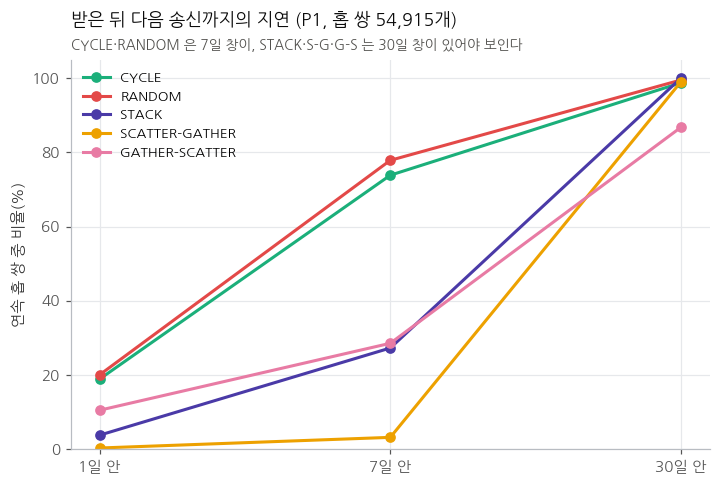

In [66]:
# 원본: notebooks/12 cell 3 오른쪽 패널(P1 지연). 바꾼 곳: 한 칸, 색(C_TYPE), 저장.
P1 = rd(RES / 'P1_패턴원문_연속홉_전달.csv').set_index('유형').reindex(CHAIN)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
cols = ['지연1일안', '지연7일안', '지연30일안']
x = np.arange(3)
for t in CHAIN:
    ax.plot(x, P1.loc[t, cols].to_numpy(dtype=float), marker='o', ms=6, lw=2, color=C_TYPE[t], label=t)
ax.set_xticks(x)
ax.set_xticklabels(['1일 안', '7일 안', '30일 안'])
ax.set_ylim(0, 105)
ax.set_ylabel('연속 홉 쌍 중 비율(%)')
ax.legend(frameon=False, fontsize=8.8, loc='upper left', ncol=1)
title(ax, f"받은 뒤 다음 송신까지의 지연 (P1, 홉 쌍 {int(P1['홉쌍'].sum()):,}개)", 'CYCLE·RANDOM 은 7일 창이, STACK·S-G·G-S 는 30일 창이 있어야 보인다')
savefig(fig, 'S5_5_전달지연_P1.png')

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/P2_패턴원문_계좌_통과비율.csv  (750 B · 5행)


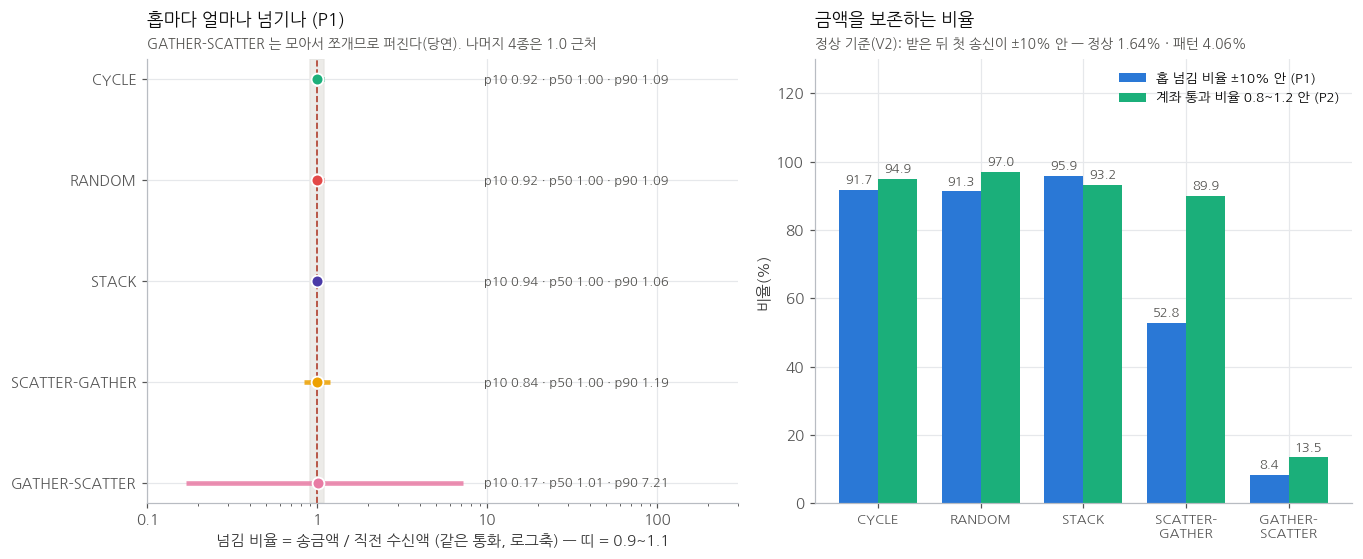

In [67]:
# 원본: notebooks/12 cell 5(P1·P2 금액 보존). 바꾼 곳: 색(C_TYPE), 왼쪽 글자 위치, 눈금 이름 줄바꿈, 오른쪽 부제(V2 정상 기준), 저장.
P2 = rd(RES / 'P2_패턴원문_계좌_통과비율.csv').set_index('유형').reindex(CHAIN)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), gridspec_kw={'width_ratios': [1.1, 1]})
ax = axes[0]
y = np.arange(len(CHAIN))[::-1]
ax.axvspan(0.9, 1.1, color=GRID, alpha=0.7, zorder=0)
ax.axvline(1.0, color=REF, lw=1.1, ls='--', zorder=1)
for yi, t in zip(y, CHAIN):
    r = P1.loc[t]
    ax.hlines(yi, r['비율p10'], r['비율p90'], color=C_TYPE[t], lw=3, alpha=0.85, zorder=2)
    ax.scatter([r['비율p50']], [yi], color=C_TYPE[t], s=60, zorder=3, edgecolor='white', linewidth=1.2)
    ax.text(9.5, yi, f"p10 {r['비율p10']:.2f} · p50 {r['비율p50']:.2f} · p90 {r['비율p90']:.2f}", va='center', fontsize=8.4, color=INK2)
ax.set_yticks(y)
ax.set_yticklabels(CHAIN, fontsize=9.6)
ax.set_xscale('log')
ax.set_xlim(0.1, 300)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v_, _: f'{v_:g}'))
ax.set_xlabel('넘김 비율 = 송금액 / 직전 수신액 (같은 통화, 로그축) — 띠 = 0.9~1.1')
title(ax, '홉마다 얼마나 넘기나 (P1)', 'GATHER-SCATTER 는 모아서 쪼개므로 퍼진다(당연). 나머지 4종은 1.0 근처')
ax = axes[1]
x = np.arange(len(CHAIN))
w = 0.38
b1 = ax.bar(x - w / 2, P1['비율0_9_1_1'], width=w, color=SERIES[0], label='홉 넘김 비율 ±10% 안 (P1)')
b2 = ax.bar(x + w / 2, P2['비율0_8_1_2'], width=w, color=SERIES[2], label='계좌 통과 비율 0.8~1.2 안 (P2)')
label_bars(ax, b1, dy=1.2); label_bars(ax, b2, dy=1.2)
ax.set_xticks(x)
ax.set_xticklabels([t.replace('-', '-\n') for t in CHAIN], fontsize=8.8)
ax.set_ylim(0, 130)
ax.set_ylabel('비율(%)')
ax.legend(frameon=False, fontsize=8.8, loc='upper right', ncol=1)
title(ax, '금액을 보존하는 비율', f"정상 기준(V2): 받은 뒤 첫 송신이 ±10% 안 — 정상 {v2.loc['정상', '±10% / 전체 수신(%)']:.2f}% · 패턴 {v2.loc['패턴 세탁', '±10% / 전체 수신(%)']:.2f}%")
fig.tight_layout()
savefig(fig, 'S5_6_금액보존_P1P2.png')

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/P3_패턴원문_체인내_통화전환.csv  (200 B · 5행)


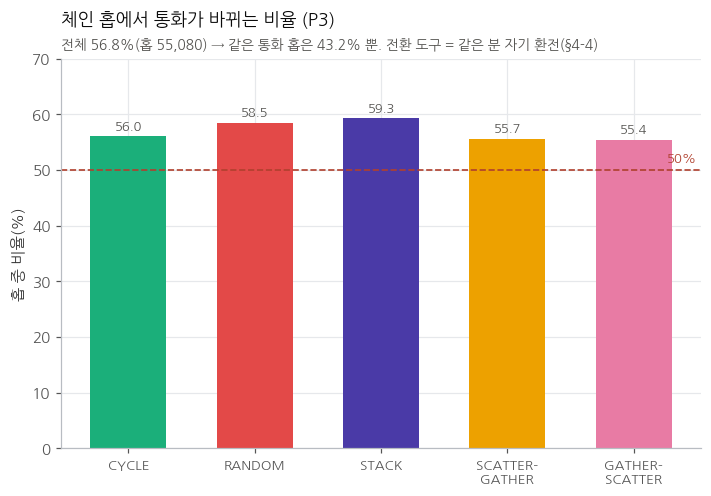

In [68]:
# 원본: notebooks/12 cell 7 오른쪽 패널(P3). 바꾼 곳: 한 칸, 색(C_TYPE), 눈금 이름 줄바꿈, 부제(값을 P3 에서 계산 — 원래 '약 42%'는 P1 홉 쌍 기준이라 정의가 달랐음), 저장.
P3 = rd(RES / 'P3_패턴원문_체인내_통화전환.csv').set_index('유형').reindex(CHAIN)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
x = np.arange(len(CHAIN))
bars = ax.bar(x, P3['통화전환비율'], color=[C_TYPE[t] for t in CHAIN], width=0.6)
label_bars(ax, bars, dy=0.8)
ax.axhline(50, color=REF, lw=1.1, ls='--')
ax.text(len(CHAIN) - 0.5, 51, '50%', ha='right', va='bottom', fontsize=8.6, color=REF)
ax.set_xticks(x)
ax.set_xticklabels([t.replace('-', '-\n') for t in CHAIN], fontsize=8.8)
ax.set_ylim(0, 70)
ax.set_ylabel('홉 중 비율(%)')
sw_all = (P3['홉수'] * P3['통화전환비율']).sum() / P3['홉수'].sum()      # (통합본) 부제 값을 P3 에서 계산
title(ax, '체인 홉에서 통화가 바뀌는 비율 (P3)',
      f"전체 {sw_all:.1f}%(홉 {int(P3['홉수'].sum()):,}) → 같은 통화 홉은 {100 - sw_all:.1f}% 뿐. 전환 도구 = 같은 분 자기 환전(§4-4)")
savefig(fig, 'S5_7_통화전환_P3.png')

**해석** (라벨을 알고 난 뒤의 모양)
- 같은 통화일 때 받은 금액의 ±10% 안으로 넘기는 홉: **CYCLE 91.72 · RANDOM 91.34 · STACK 95.91% · S-G 52.83% · G-S 8.38%.** "체인 4종 91~96%"는 틀린 요약이다(부록 C 정정 4). S-G 도 ±20% 로 넓히면 89.97% 다.
- 계좌 통과 비율(송신 합/수신 합)이 0.8~1.2 안인 비율은 CYCLE 94.9 · RANDOM 97.0 · STACK 93.2 · S-G 89.9 · G-S 13.5% 다.
- 체인 홉의 55.4~59.3%(전체 56.8%, 홉 55,080 분모 — P3)가 통화를 바꾼다. 곧 같은 통화 홉은 43.2% 다. P1 의 `통화같음비율`(전체 약 42.5%)은 연속 홉 **쌍**(54,915) 기준이라 정의가 다르다. 지연 p50 은 CYCLE 4,774분 · RANDOM 4,410 · STACK 18,496 · G-S 22,104 · S-G 25,124분이다. 전체 11.88일, 7일 안 37.0% · 30일 안 96.3%.
- FAN-OUT · FAN-IN · BIPARTITE 에는 연속 홉(받은 계좌가 다시 보냄)이 없다.
- **정상 기준(V2)**: 정상 계좌도 받은 뒤 첫 송신이 ±10% 안인 경우가 1.64% 있다(패턴 4.06 · 패턴 밖 3.61%). 정상 행이 훨씬 많으므로, 금액 일치만으로는 가를 수 없다.

### 5-6. 패턴 밖 세탁의 연결(A4) [저장 결과]
**질문**: 패턴 밖 세탁 87,610행은 서로 이어진 덩어리인가, 따로 떨어진 한 건인가? (다른 세탁 행과 계좌를 직접 공유하면 "연결")

읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A4_패턴밖세탁_연결여부.csv  (1,287 B · 6행)


,창,패턴 밖 세탁 분류,건수,패턴 밖 세탁 중(%),우리 허브 연루(%),결제수단 ACH(%),결제수단 Cheque(%),결제수단 Credit Card(%),결제수단 Cash(%)
0,같은 날,연결,26631,30.40,91.11,8.76,46.58,29.40,13.73
1,같은 날,단건,60979,69.60,0.09,96.61,1.40,0.03,0.01
2,±24h,연결,27472,31.36,88.51,11.26,45.32,28.54,13.33
3,±24h,단건,60138,68.64,0.00,96.70,1.35,0.01,0.00
4,±7일,연결,34602,39.50,70.27,29.05,36.22,22.66,10.59
5,±7일,단건,53008,60.50,0.00,96.57,1.37,0.01,0.00


읽음: /workspace/Final_preprocess/HI-Large_EDA/results/A4b_세탁_연결요소_크기.csv  (1,200 B · 22행)


,창(공백),세탁 행,연결요소 수,패턴 밖 세탁이 크기 1 요소,패턴 밖 세탁 소속 요소 크기 p50,p90,최대 요소 크기,최대 요소의 패턴 밖/패턴 행,패턴 밖만으로 된 요소(크기≥2),패턴과 섞인 요소
0,±24h,201273.0,139552.0,60138.0,1.0,10190.0,10190.0,8863/1327,1251.0,603.0
11,±7일,201273.0,92041.0,53008.0,1.0,30831.0,30831.0,19100/11731,3143.0,2454.0


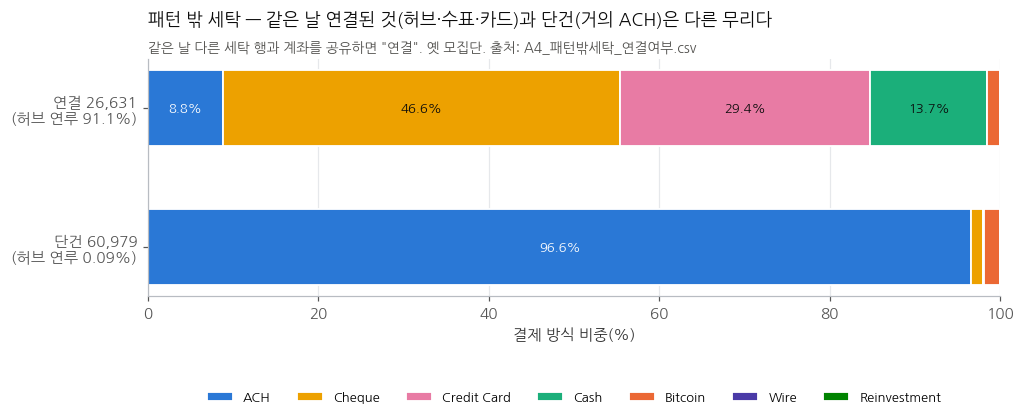

In [69]:
A4 = rd(RES / 'A4_패턴밖세탁_연결여부.csv')
display(A4[['창', '패턴 밖 세탁 분류', '건수', '패턴 밖 세탁 중(%)', '우리 허브 연루(%)', '결제수단 ACH(%)', '결제수단 Cheque(%)', '결제수단 Credit Card(%)', '결제수단 Cash(%)']].round(2))
A4b = rd(RES / 'A4b_세탁_연결요소_크기.csv'); display(A4b[A4b['세탁 행'].notna()].dropna(axis=1, how='all'))
a = A4[A4['창'] == '같은 날'].set_index('패턴 밖 세탁 분류')
fig, ax = plt.subplots(figsize=(10, 2.8)); y = np.arange(2)[::-1]; left = np.zeros(2)
for f in ['ACH', 'Cheque', 'Credit Card', 'Cash', 'Bitcoin', 'Wire', 'Reinvestment']:
    v = a.loc[['연결', '단건'], f'결제수단 {f}(%)'].to_numpy(dtype=float)
    ax.barh(y, v, left=left, color=C_FMT[f], height=0.55, edgecolor='white', linewidth=1.2, label=f)
    for yi, l_, vi in zip(y, left, v):
        if vi >= 6:
            ax.text(l_ + vi / 2, yi, f'{vi:.1f}%', ha='center', va='center', fontsize=8.5, color=ink_on(C_FMT[f]))
    left += v
ax.set_yticks(y); ax.set_yticklabels([f"연결 {int(a.loc['연결', '건수']):,}\n(허브 연루 {a.loc['연결', '우리 허브 연루(%)']:.1f}%)", f"단건 {int(a.loc['단건', '건수']):,}\n(허브 연루 {a.loc['단건', '우리 허브 연루(%)']:.2f}%)"])
ax.set_xlim(0, 100); ax.set_xlabel('결제 방식 비중(%)'); ax.legend(frameon=False, fontsize=8.5, ncol=7, loc='upper center', bbox_to_anchor=(0.5, -0.35))
title(ax, '패턴 밖 세탁 — 같은 날 연결된 것(허브·수표·카드)과 단건(거의 ACH)은 다른 무리다', '같은 날 다른 세탁 행과 계좌를 공유하면 "연결". 옛 모집단. 출처: A4_패턴밖세탁_연결여부.csv')
savefig(fig, 'S5_8_패턴밖_연결_A4.png')

**해석**
- 같은 날 기준으로 패턴 밖 세탁의 **30.4%(26,631)는 연결**, **69.6%(60,979)는 단건**이다.
- 연결된 쪽은 허브 연루 91.1% 이고 수표·카드·현금이 많다. 단건은 ACH 96.6% 다. 패턴 밖은 **한 가지 무리가 아니다.**
- ±24시간 공백으로 이은 최대 연결요소는 10,190행(패턴 밖 8,863 / 패턴 1,327)이다. 허브를 뺀 관계는 안 봤다(부록 B #8).

## §6 중복 — 두 기준이 섞여 정상 9,320행이 빠진다

**질문**: 중복 제거가 정말 완전히 같은 거래만 지우나? 지금 파이프라인에는 어떤 영향이 남아 있나?

원래 감사(`reprocess/dedup_audit.py`, 09-17)는 interim 파트의 9키를 해시로 줄여 후보만 정확히 비교한다. **꺼 두었다.** fix [D](되살린 행의 기간별 표)의 원래 코드는 `fix_20260927/code/fix_02_labels.py`(DuckDB·`/tmp` 라벨 필요)라 옮기지 않았다.

In [70]:
# [무거움 · 기본 꺼짐] 원본: HI-Large_EDA/reprocess/dedup_audit.py:2-129
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: OUT(reprocess/dedup) → OUT_NB
def _heavy_dedup():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    """HI-Large 중복 제거 감사 — 우리 파이프라인의 '완전 중복' 판정이 실제로 완전 중복만 지우는가.

    우리 코드(prep9/lowmem.py clean_rows)는 9개 키로 중복을 찾는다: 분 단위 시각, 송신·수신 계좌, 지급·수취 금액(센트로
    반올림한 정수), 결제수단, 두 통화, 라벨. 금액을 센트로 반올림하므로, 소수 셋째 자리 이하만 다른 거래(비트코인 등)도
    같은 거래로 볼 수 있다. 팀 결정(화두 11)은 "완전히 동일한 거래만 하나 남긴다"이다.

    이 스크립트는 공식 원본의 interim 파트(원본 순서)를 읽어
      A) 우리 키(센트 반올림)로 지워지는 행 수   → 파이프라인 기록(10,829)과 같아야 한다
      B) 금액을 반올림 없이(원본에서 읽은 실수 그대로) 비교했을 때 지워지는 행 수
    를 세고, A 에만 있는 행(= 실제로는 다른 거래인데 지워지는 행)을 원본 행 번호와 함께 저장한다.
    원본 행 번호는 CSV 데이터 행의 0부터 센 위치라, 태훈님 노트북의 edge_id 와 같은 번호 체계다.

    메모리: 키를 64비트 해시 한 열로 줄여(1.4 GB) 후보만 고른 뒤, 후보 행만 전체 값으로 정확히 비교한다.
    출력: dedup/dedup_audit_HI-Large.json, dedup/false_duplicates_HI-Large.csv, dedup/dup_groups_HI-Large.csv
    """
    import json
    import time
    from pathlib import Path

    import numpy as np
    import pandas as pd
    import pyarrow.parquet as pq

    INTERIM = Path('/workspace/processed_9class/_nb_scratch/interim/HI-Large')
    OUT = OUT_NB   # (통합본) 원래 reprocess/dedup — out/ 으로
    OUT.mkdir(exist_ok=True)
    t0 = time.time()
    KEYS9 = ['ts_epoch_min', 'src_id', 'dst_id', 'cents', 'recv_cents', 'fmt_code', 'pay_code', 'recv_code', 'is_pos']
    PRIMES = [0x9E3779B97F4A7C15, 0xC2B2AE3D27D4EB4F, 0x165667B19E3779F9, 0xD6E8FEB86659FD93,
              0xFF51AFD7ED558CCD, 0xC4CEB9FE1A85EC53, 0x94D049BB133111EB, 0xBF58476D1CE4E5B9, 0x2545F4914F6CDD1D]


    def log(m):
        print(f'[{time.time() - t0:7.1f}s] {m}', flush=True)


    import os
    man = json.loads((INTERIM / 'manifest.json').read_text())
    parts = sorted(INTERIM.glob('part-*.parquet'))
    n = int(man['n_rows'])
    LIMIT = int(os.environ.get('DEDUP_TEST_PARTS', '0'))      # 시험용: 앞 N 파트만
    if LIMIT:
        parts = parts[:LIMIT]
        n = sum(pq.ParquetFile(f).metadata.num_rows for f in parts)
        OUT = OUT / '_test'
        OUT.mkdir(exist_ok=True)
    h = np.empty(n, dtype=np.uint64)
    starts, pos = [], 0
    with np.errstate(over='ignore'):
        for f in parts:
            t = pq.read_table(f, columns=KEYS9)
            m = t.num_rows
            acc = np.zeros(m, dtype=np.uint64)
            for k, p in zip(KEYS9, PRIMES):
                v = t.column(k).to_numpy().astype(np.int64).view(np.uint64)
                acc = (acc ^ v) * np.uint64(p)
                acc ^= acc >> np.uint64(29)
            h[pos:pos + m] = acc
            starts.append(pos)
            pos += m
            del t, acc
    assert pos == n
    log(f'해시 {n:,}행')
    order = np.argsort(h, kind='stable')
    hs = h[order]
    same = np.zeros(n, dtype=bool)
    same[1:] = hs[1:] == hs[:-1]
    cand = np.zeros(n, dtype=bool)
    cand[order[same]] = True
    cand[order[np.flatnonzero(same) - 1]] = True
    cand_rows = np.flatnonzero(cand)
    del order, hs, same, cand, h
    log(f'해시가 겹치는 후보 {len(cand_rows):,}행')

    # 후보 행의 전체 값 읽기(파트별)
    starts = np.array(starts + [n])
    frames = []
    for i, f in enumerate(parts):
        sel = cand_rows[(cand_rows >= starts[i]) & (cand_rows < starts[i + 1])]
        if len(sel):
            t = pq.read_table(f).to_pandas().iloc[sel - starts[i]]
            t.insert(0, 'raw_row', sel)
            frames.append(t)
    c = pd.concat(frames, ignore_index=True).sort_values('raw_row')
    nodes = pd.read_parquet(INTERIM / 'nodes.parquet')['key'].to_numpy(dtype=object)
    voc = {k: pd.read_parquet(INTERIM / f'{k}.parquet')['key'].tolist() for k in ('fmt', 'pay', 'recv')}

    # A) 우리 키: 같은 9키 그룹에서 첫 행(원본 순서)만 남김 → 나머지는 지워짐
    c['dupA'] = c.duplicated(KEYS9, keep='first')
    # B) 정확 비교: 금액을 원본 실수값 그대로 추가
    KEYS_EXACT = KEYS9 + ['paid', 'recv']
    c['dupB'] = c.duplicated(KEYS_EXACT, keep='first')
    nA, nB = int(c.dupA.sum()), int(c.dupB.sum())
    false_dup = c[c.dupA & ~c.dupB].copy()
    # 지워진 행이 남은 행(같은 9키 그룹의 첫 행)과 금액이 어떻게 다른가
    first = c[~c.dupA].set_index(KEYS9)[['raw_row', 'paid', 'recv']].rename(
        columns={'raw_row': 'kept_raw_row', 'paid': 'kept_paid', 'recv': 'kept_recv'})
    false_dup = false_dup.join(first, on=KEYS9)
    for df_ in (false_dup,):
        df_['from_key'] = nodes[df_.src_id.to_numpy()]
        df_['to_key'] = nodes[df_.dst_id.to_numpy()]
        df_['payment_format'] = [voc['fmt'][i] for i in df_.fmt_code]
        df_['payment_currency'] = [voc['pay'][i] for i in df_.pay_code]
        df_['receiving_currency'] = [voc['recv'][i] for i in df_.recv_code]
        df_['timestamp'] = pd.to_datetime(df_.ts_epoch_min, unit='m')
    cols = ['raw_row', 'kept_raw_row', 'timestamp', 'from_key', 'to_key', 'paid', 'kept_paid', 'recv', 'kept_recv',
            'payment_currency', 'receiving_currency', 'payment_format', 'is_pos']
    false_dup[cols].to_csv(OUT / 'false_duplicates_HI-Large.csv', index=False)
    grp = c[c.dupA | c.duplicated(KEYS9, keep=False)].groupby(KEYS9).agg(
        rows=('raw_row', 'size'), first_row=('raw_row', 'min'), n_distinct_paid=('paid', 'nunique'),
        n_distinct_recv=('recv', 'nunique')).reset_index()
    grp.to_csv(OUT / 'dup_groups_HI-Large.csv', index=False)
    res = {
        'source': str(INTERIM), 'csv_size': man['csv_size'], 'rows': n,
        'removed_by_our_key_cents': nA,
        'removed_by_exact_amounts': nB,
        'false_duplicates': int(len(false_dup)),
        'false_duplicates_laundering': int(false_dup.is_pos.sum()),
        'removed_by_our_key_laundering': int(c.loc[c.dupA, 'is_pos'].sum()),
        'false_dup_by_payment_currency': false_dup.payment_currency.value_counts().to_dict(),
        'false_dup_by_payment_format': false_dup.payment_format.value_counts().to_dict(),
        'false_dup_max_abs_paid_diff': float((false_dup.paid - false_dup.kept_paid).abs().max()) if len(false_dup) else 0.0,
        'dup_groups_our_key': int(len(grp)),
        'note': '금액 비교는 CSV 에서 float64 로 읽은 값 기준. 원본 문자열 비교(태훈님 방식)와의 대조는 태훈님 duplicate_audit.csv 로 따로 한다.',
        'elapsed_s': round(time.time() - t0, 1),
    }
    (OUT / 'dedup_audit_HI-Large.json').write_text(json.dumps(res, ensure_ascii=False, indent=1))
    log('DEDUP AUDIT DONE ' + json.dumps({k: v for k, v in res.items() if k != 'note'}, ensure_ascii=False))


if HEAVY['dedup']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_dedup()
else:
    print("HEAVY['dedup'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['dedup'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


**[가벼움 · 실행 + 저장 결과]** 가짜 중복 목록(`false_duplicates_HI-Large.csv`, 1.45 MB)을 읽어 기간·통화·결제 방식별로 다시 세고, fix `D1` 과 대조한다.

In [71]:
DA = rj(EDA / 'reprocess/dedup/dedup_audit_HI-Large.json'); print({k: v for k, v in DA.items() if k not in ('note', 'source')})
FD = rd(EDA / 'reprocess/dedup/false_duplicates_HI-Large.csv', usecols=['timestamp', 'payment_currency', 'payment_format', 'is_pos'])
FD['day'] = pd.to_datetime(FD['timestamp']).dt.normalize()
PER = [('0_보정(08-01~08-07)', '2022-08-01', '2022-08-07'), ('1_train(08-08~09-27)', '2022-08-08', '2022-09-27'), ('2_val(09-28~10-14)', '2022-09-28', '2022-10-14'),
       ('3_test17(10-15~10-31)', '2022-10-15', '2022-10-31'), ('4_되살린5일(11-01~11-05)', '2022-11-01', '2022-11-05'), ('5_꼬리(11-06~)', '2022-11-06', '2023-12-31')]
cnt = pd.Series({n: int(((FD.day >= a) & (FD.day <= b)).sum()) for n, a, b in PER}, name='다시 셈')
D1 = rd(FRES / 'D1_되살린행_기간별.csv').set_index('기간')
cmp = pd.concat([cnt, D1['되살린_행'].reindex(cnt.index).rename('D1 저장')], axis=1); display(cmp)
print(f'가짜 중복 {len(FD):,}행 · 세탁 {int(FD.is_pos.sum())} · 통화 {FD.payment_currency.value_counts().to_dict()} · 결제 {FD.payment_format.value_counts().to_dict()}')
assert len(FD) == DA['false_duplicates'] and (cmp['다시 셈'] == cmp['D1 저장']).all()
display(D1)
print('■ 라벨 판별 행 수(fix D2)'); D2f = rd(FRES / 'D2_라벨수_전후대조.csv'); display(D2f[D2f['라벨판'].str.startswith(('0_', '1_'))].iloc[:, :7])

읽음: /workspace/Final_preprocess/HI-Large_EDA/reprocess/dedup/dedup_audit_HI-Large.json  (731 B)
{'csv_size': 17052760651, 'rows': 179702229, 'removed_by_our_key_cents': 10829, 'removed_by_exact_amounts': 150, 'false_duplicates': 10679, 'false_duplicates_laundering': 0, 'removed_by_our_key_laundering': 0, 'false_dup_by_payment_currency': {'Bitcoin': 10668, 'US Dollar': 11}, 'false_dup_by_payment_format': {'Bitcoin': 10668, 'ACH': 9, 'Wire': 2}, 'false_dup_max_abs_paid_diff': 0.009895000000000001, 'dup_groups_our_key': 10778, 'elapsed_s': 81.7}
읽음: /workspace/Final_preprocess/HI-Large_EDA/reprocess/dedup/false_duplicates_HI-Large.csv  (1,452,261 B · 10,679행)
읽음: /workspace/Final_preprocess/fix_20260927/results/D1_되살린행_기간별.csv  (595 B · 8행)


,다시 셈,D1 저장
0_보정(08-01~08-07),781,781
1_train(08-08~09-27),5615,5615
2_val(09-28~10-14),1933,1933
3_test17(10-15~10-31),1772,1772
4_되살린5일(11-01~11-05),578,578
5_꼬리(11-06~),0,0


가짜 중복 10,679행 · 세탁 0 · 통화 {'Bitcoin': 10668, 'US Dollar': 11} · 결제 {'Bitcoin': 10668, 'ACH': 9, 'Wire': 2}


,되살린_행,그중_세탁,Bitcoin,US_Dollar,기타통화,날짜수,대조_기록값,대조_출처
기간,,,,,,,,
0_보정(08-01~08-07),781,0,781,0,0,7,NaN,NaN
1_train(08-08~09-27),5615,0,5606,9,0,51,NaN,NaN
2_val(09-28~10-14),1933,0,1931,2,0,17,NaN,NaN
3_test17(10-15~10-31),1772,0,1772,0,0,17,NaN,NaN
4_되살린5일(11-01~11-05),578,0,578,0,0,5,NaN,NaN
5_꼬리(11-06~),0,0,0,0,0,0,NaN,NaN
합계(주 기간 97일),10679,0,10668,11,0,97,10679 (Bitcoin 10668 · US Dollar 11),reprocess/dedup/dedup_audit_HI-Large.json false_duplicates
85일(train+val+test17),9320,0,9309,11,0,85,9320,joined_stats.json rows_outside_my_population 합


■ 라벨 판별 행 수(fix D2)
읽음: /workspace/Final_preprocess/fix_20260927/results/D2_라벨수_전후대조.csv  (2,251 B · 18행)


,라벨판,기간,모집단_행,정상,세탁,패턴_세탁,패턴밖_세탁
0,0_옛(고치기 전),0_보정(08-01~08-07),14932226,14925020,7206,1795,5411
1,0_옛(고치기 전),1_train(08-08~09-27),91426514,91327582,98932,55837,43095
2,0_옛(고치기 전),2_val(09-28~10-14),33649784,33608813,40971,24280,16691
3,0_옛(고치기 전),3_test17(10-15~10-31),30407864,30366298,41566,24503,17063
4,0_옛(고치기 전),4_되살린5일(11-01~11-05),9234293,9221695,12598,7248,5350
5,0_옛(고치기 전),5_꼬리(11-06~),0,0,0,0,0
6,1_[D] 되살린 뒤(유형은 옛 파싱),0_보정(08-01~08-07),14933007,14925801,7206,1795,5411
7,1_[D] 되살린 뒤(유형은 옛 파싱),1_train(08-08~09-27),91432129,91333197,98932,55837,43095
8,1_[D] 되살린 뒤(유형은 옛 파싱),2_val(09-28~10-14),33651717,33610746,40971,24280,16691
9,1_[D] 되살린 뒤(유형은 옛 파싱),3_test17(10-15~10-31),30409636,30368070,41566,24503,17063


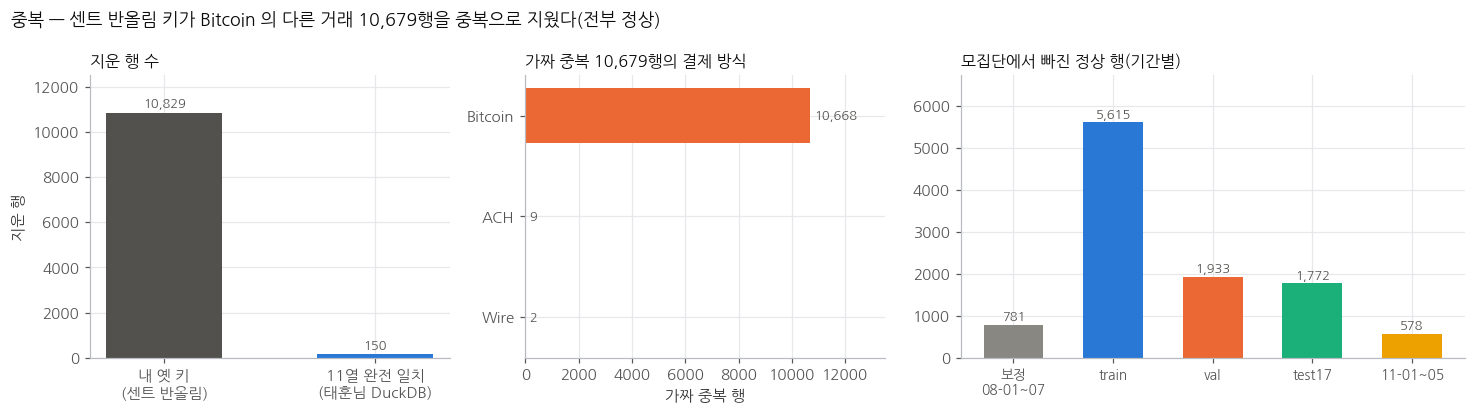

In [72]:
# 그림 6-1. 중복으로 지운 행 — 내 옛 키(센트 반올림) 10,829 vs 완전 일치 150
fig, axs = plt.subplots(1, 3, figsize=(13.5, 3.8), gridspec_kw={'width_ratios': [1, 1, 1.4]})
ax = axs[0]
v = [DA['removed_by_our_key_cents'], DA['removed_by_exact_amounts']]
bb = ax.bar([0, 1], v, color=[INK2, C_PAT], width=0.55); label_bars(ax, bb, fmt='{:,.0f}', dy=150)
ax.set_xticks([0, 1]); ax.set_xticklabels(['내 옛 키\n(센트 반올림)', '11열 완전 일치\n(태훈님 DuckDB)']); ax.set_ylim(0, 12500); ax.set_ylabel('지운 행')
ax.set_title('지운 행 수', loc='left', fontsize=10.5, color=INK)
ax = axs[1]
fc = FD.payment_format.value_counts()
bb = ax.barh(np.arange(len(fc))[::-1], fc.to_numpy(), color=[C_FMT[f] for f in fc.index], height=0.55); label_bars(ax, bb, fmt='{:,.0f}', dx=150, horiz=True)
ax.set_yticks(np.arange(len(fc))[::-1]); ax.set_yticklabels(fc.index); ax.set_xlim(0, 13500); ax.set_xlabel('가짜 중복 행')
ax.set_title(f'가짜 중복 {len(FD):,}행의 결제 방식', loc='left', fontsize=10.5, color=INK)
ax = axs[2]
pc = cmp['다시 셈'].iloc[:5]
bb = ax.bar(np.arange(5), pc.to_numpy(), color=[C_NORM, SC['train'], SC['val'], SC['test'], SERIES[3]], width=0.6); label_bars(ax, bb, fmt='{:,.0f}', dy=60)
ax.set_xticks(np.arange(5)); ax.set_xticklabels(['보정\n08-01~07', 'train', 'val', 'test17', '11-01~05'], fontsize=9); ax.set_ylim(0, pc.max() * 1.2)
ax.set_title('모집단에서 빠진 정상 행(기간별)', loc='left', fontsize=10.5, color=INK)
fig.suptitle('중복 — 센트 반올림 키가 Bitcoin 의 다른 거래 10,679행을 중복으로 지웠다(전부 정상)', x=0.01, ha='left', fontsize=11.5, color=INK)
fig.tight_layout(); savefig(fig, 'S6_1_중복.png')

**해석**
- 태훈님 DuckDB 기준(`drop_exact`, 원본 11칸 완전 일치)으로 지우면 중복은 **150행**뿐이다. 어느 기준으로 통일할지는 09-27 정정 보고서(`fix_20260927/보고서_어긋남정정_손은총_20260927.md`) §6 의 6번 "[D] 중복 제거 기준의 통일"로 **팀 결정 대기**다(부록 B).
- 내 옛 전처리는 금액을 센트로 반올림한 키를 써서 **10,829행**을 지웠다. 그중 **10,679행은 가짜 중복**이다(Bitcoin 10,668 · USD 11, 세탁 0, 금액 차 최대 0.0099). Bitcoin 은 1센트 미만 금액이 대부분이라 반올림하면 다른 거래가 같아진다(§4-2).
- 지금 라벨·채점 모집단은 옛 전처리에서 왔다. 그래서 **85일에서 정상 9,320행(train 5,615 · val 1,933 · test17 1,772)이 기록 없이 빠진다.** 되살림은 fix 정정안에만 있고, **현행(09-30 병합판 포함)에는 미적용**이다.
- 09-24 트리에서는 이 행을 넣어도 지표가 소수 다섯째 자리까지 같았다. 영향은 작지만, 행 수를 인용할 때 어느 모집단인지 적어야 한다.

## §7 분할 · 사전확률 · 시계 효과 (E1 · E3 · M1 · M3, 09-29 유효)

**질문**: 지금 분할(51/17/17)에서 세탁 비율과 유형 비중은 train → val → test 로 어떻게 움직이나? 입력 열이 날짜에 따라 저절로 커지는 "시계"인가? val·test 의 시도·계좌는 train 에 이미 나왔나?

### 7-1. 사전확률 · 유형 구성(E1)
원래 계산(`EDA_현황_20260929/_builders/build_E1.py`)은 하루 캐시 `/tmp/gnn36_full`(85일, 지금 없음)을 읽는다. **꺼 두었다.** 공통 머리(`common.py` HEAD) + 코드 셀 1~4 를 그대로 옮겼다.

In [73]:
# [무거움 · 기본 꺼짐] 원본: EDA_현황_20260929/_builders/common.py HEAD:7-52 + build_E1.py 코드 셀 1~4(:17-41 · :43-63 · :65-80 · :82-89)
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: HEAD 의 OUT = EDA/results 삭제(함수 첫 줄의 OUT = out/ 을 씀)
def _heavy_E1():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    import os
    for k in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
        os.environ[k] = '3'
    import sys, json, time, datetime
    from pathlib import Path
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np, pandas as pd, pyarrow.parquet as pq
    import tree9_lib as L
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt, matplotlib.font_manager as fm
    from IPython.display import Image, display

    T0 = time.time()
    EDA = Path('/workspace/Final_preprocess/EDA_현황_20260929'); FIG = OUT / '_figs'   # (통합본) OUT = 이 노트북 out/ (원래 EDA / 'results')
    FIG.mkdir(parents=True, exist_ok=True)
    CACHE = Path('/tmp/gnn36_full'); PL = Path('/tmp/tree9_work/db_full/pattern_labels.parquet')
    TG = Path('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928')
    a = L.anon_gib(); print(f'anon {a:.2f} GiB'); assert a < 15.0, 'anon 15 GiB 초과 — 멈춘다'
    SPLITS = ('train', 'val', 'test')
    SPLIT_OF = {d: s for s in SPLITS for d in L.days_of(s)}
    DAYS = sorted(SPLIT_OF)
    CN = L.CLASS_NAMES[:8]
    miss = [d for d in DAYS if not (CACHE / f'day={d}' / '_DONE').exists()]
    assert not miss, f'캐시 없음 {miss[:3]}'
    # 그림: 나눔고딕, dataviz 기본 팔레트(분할 3개 = 앞 3칸, 모든 쌍 색각 검증 통과)
    FONT = Path('/workspace/Final_preprocess/HI-Large_EDA/notebooks/_assets/NanumGothic-Regular.ttf')
    fm.fontManager.addfont(str(FONT))
    plt.rcParams.update({'font.family': fm.FontProperties(fname=str(FONT)).get_name(), 'axes.unicode_minus': False,
                         'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False,
                         'axes.edgecolor': '#b8bcc2', 'axes.labelcolor': '#333', 'xtick.color': '#555', 'ytick.color': '#555',
                         'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#e6e8eb', 'grid.linewidth': 0.8, 'lines.linewidth': 2})
    INK, MUTED = '#1f1f1f', '#666'
    SC = {'train': '#2a78d6', 'val': '#eb6834', 'test': '#1baf7a'}      # 분할 색(팔레트 1~3칸)
    SPLIT_KO = {'train': 'train 08-08~09-27', 'val': 'val 09-28~10-14', 'test': 'test 10-15~10-31'}
    def shade_splits(ax):
        """x 축이 날짜 번호(0~84)일 때 val·test 구간을 옅게 표시."""
        i_val, i_test = DAYS.index(L.days_of('val')[0]), DAYS.index(L.days_of('test')[0])
        ax.axvspan(i_val - 0.5, i_test - 0.5, color='#eb6834', alpha=0.06, lw=0)
        ax.axvspan(i_test - 0.5, len(DAYS) - 0.5, color='#1baf7a', alpha=0.06, lw=0)
        for i, t in ((0, 'train'), (i_val, 'val'), (i_test, 'test')):
            ax.text(i + 0.3, 0.98, t, transform=ax.get_xaxis_transform(), fontsize=9, color=MUTED, va='top')
    def day_ticks(ax, step=7):
        idx = list(range(0, len(DAYS), step)); ax.set_xticks(idx); ax.set_xticklabels([DAYS[i][5:] for i in idx], fontsize=8.5)
    def savefig(fig, name):
        p = FIG / name; fig.savefig(p, dpi=130, bbox_inches='tight'); plt.close(fig); display(Image(filename=str(p))); return p

    pl = pq.read_table(PL, columns=['edge_id', 'attempt_id']).to_pandas().sort_values('edge_id')
    PE, PA = pl['edge_id'].to_numpy(np.int64), pl['attempt_id'].to_numpy(np.int64)
    def attempt_of(eid):
        i = np.searchsorted(PE, eid); assert (PE[i] == eid).all(), '시도 번호를 못 찾은 패턴 행'
        return PA[i]
    WD = '월화수목금토일'
    rows, ATT = [], {s: {k: set() for k in range(8)} for s in SPLITS}
    for d in DAYS:
        p = CACHE / f'day={d}'
        y9 = np.load(p / 'y9.npy'); lab = np.load(p / 'labels.npy'); eid = np.load(p / 'target_ids.npy')
        r = dict(날짜=d, 분할=SPLIT_OF[d], 요일=WD[datetime.date.fromisoformat(d).weekday()], 전체거래=len(y9), 정상=int((y9 == 8).sum()),
                 패턴밖세탁=int(((y9 == -1) & (lab == 1)).sum()), 모집단밖정상=int(((y9 == -1) & (lab == 0)).sum()))
        for k in range(8):
            m = y9 == k; r[CN[k]] = int(m.sum())
            if m.any(): ATT[SPLIT_OF[d]][k].update(attempt_of(eid[m]).tolist())
        assert ((y9 == -1) | (y9 >= 0)).all() and ((y9 >= 0) <= (y9 <= 8)).all()
        rows.append(r)
    D = pd.DataFrame(rows)
    D['패턴'] = D[CN].sum(axis=1); D['채점행'] = D['정상'] + D['패턴']
    D['패턴비율_pct'] = 100 * D['패턴'] / D['채점행']
    D['세탁비율_패턴밖포함_pct'] = 100 * (D['패턴'] + D['패턴밖세탁']) / (D['채점행'] + D['패턴밖세탁'])
    assert (D['전체거래'] == D['채점행'] + D['패턴밖세탁'] + D['모집단밖정상']).all()
    D.to_csv(OUT / 'E1a_일별_라벨구성.csv', index=False, encoding='utf-8-sig')
    print(D[['날짜', '분할', '요일', '채점행', '패턴', '패턴비율_pct', '패턴밖세탁']].describe().round(4).to_string())
    print(f'{time.time()-T0:.0f}s')

    g = D.groupby('분할', sort=False)
    Ssum = g[['전체거래', '채점행', '정상', '패턴', '패턴밖세탁', '모집단밖정상'] + CN].sum().reindex(list(SPLITS))
    Ssum.insert(0, '일수', g.size().reindex(list(SPLITS)))
    chk = {r['split']: r for r in json.loads((TG / 'common/cache36_summary.json').read_text())['by_split']}
    for s in SPLITS:
        assert Ssum.loc[s, '채점행'] == chk[s]['kept'] and Ssum.loc[s, '패턴'] == chk[s]['pattern'] and Ssum.loc[s, '전체거래'] == chk[s]['targets'], s
    print('분할별 행 수가 cache36_summary.json 과 같다')
    Ssum['하루평균_채점행'] = (Ssum['채점행'] / Ssum['일수']).round(0)
    Ssum['패턴비율_pct'] = 100 * Ssum['패턴'] / Ssum['채점행']
    Ssum['패턴비율_train대비'] = Ssum['패턴비율_pct'] / Ssum.loc['train', '패턴비율_pct']
    Ssum['세탁비율_패턴밖포함_pct'] = 100 * (Ssum['패턴'] + Ssum['패턴밖세탁']) / (Ssum['채점행'] + Ssum['패턴밖세탁'])
    Ssum['패턴밖_비중_세탁중_pct'] = 100 * Ssum['패턴밖세탁'] / (Ssum['패턴'] + Ssum['패턴밖세탁'])
    Ssum['정상대_패턴'] = (Ssum['정상'] / Ssum['패턴']).round(0)
    Ssum['시도수'] = [len(set().union(*ATT[s].values())) for s in SPLITS]
    Ssum['시도당_패턴행'] = Ssum['패턴'] / Ssum['시도수']
    # 학습이 보는 사전확률(CSSMC r300 + 세탁 가중치 300): 정상 16,751,100 · 패턴 55,837
    n_n, n_p, w = 16_751_100, int(Ssum.loc['train', '패턴']), 300
    Ssum['참고_학습가중_세탁비중_pct'] = [100 * n_p * w / (n_n + n_p * w), np.nan, np.nan]
    Ssum.to_csv(OUT / 'E1b_분할별_사전확률.csv', encoding='utf-8-sig')
    with pd.option_context('display.width', 250, 'display.float_format', '{:.4f}'.format):
        print(Ssum.drop(columns=CN).T.to_string())

    rows = []
    for s in SPLITS:
        for k, c in enumerate(CN):
            n = int(Ssum.loc[s, c])
            rows.append(dict(분할=s, 유형=c, 행=n, 패턴중_비중_pct=100 * n / Ssum.loc[s, '패턴'],
                             채점행_백만건당=1e6 * n / Ssum.loc[s, '채점행'], 시도수=len(ATT[s][k]), 시도당_행=n / max(len(ATT[s][k]), 1)))
    T = pd.DataFrame(rows)
    piv = T.pivot(index='유형', columns='분할', values='패턴중_비중_pct')[list(SPLITS)].reindex(CN)
    piv['test-train_pp'] = piv['test'] - piv['train']
    rate = T.pivot(index='유형', columns='분할', values='채점행_백만건당')[list(SPLITS)].reindex(CN)
    rate['test÷train'] = rate['test'] / rate['train']
    T.to_csv(OUT / 'E1c_분할별_유형구성.csv', index=False, encoding='utf-8-sig')
    with pd.option_context('display.width', 200, 'display.float_format', '{:.2f}'.format):
        print('패턴 행 중 유형 비중(%)'); print(piv.to_string()); print()
        print('채점 행 백만 건당 유형 행 수'); print(rate.to_string()); print()
        print('유형별 시도 수'); print(T.pivot(index='유형', columns='분할', values='시도수')[list(SPLITS)].reindex(CN).to_string())

    D['주'] = [(datetime.date.fromisoformat(d) - datetime.date(2022, 8, 8)).days // 7 for d in D['날짜']]
    Wk = D.groupby('주').agg(시작=('날짜', 'first'), 끝=('날짜', 'last'), 일수=('날짜', 'size'), 채점행=('채점행', 'sum'), 패턴=('패턴', 'sum'), 패턴밖세탁=('패턴밖세탁', 'sum'))
    Wk['패턴비율_pct'] = 100 * Wk['패턴'] / Wk['채점행']
    Wk['분할'] = [','.join(sorted(set(D.loc[D['주'] == w, '분할']), key=SPLITS.index)) for w in Wk.index]
    Wk.to_csv(OUT / 'E1d_주별_패턴비율.csv', encoding='utf-8-sig')
    from scipy.stats import spearmanr
    rho = spearmanr(np.arange(len(D)), D['패턴비율_pct'])
    print(Wk.round(4).to_string()); print('날짜 번호 vs 일별 패턴비율 Spearman', round(rho.correlation, 3), 'p', f'{rho.pvalue:.1e}')


if HEAVY['E1']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_E1()
else:
    print("HEAVY['E1'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['E1'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [74]:
E1a = rd(ERES / 'E1a_일별_라벨구성.csv'); E1b = rd(ERES / 'E1b_분할별_사전확률.csv').set_index('분할')
E1c = rd(ERES / 'E1c_분할별_유형구성.csv'); E1d = rd(ERES / 'E1d_주별_패턴비율.csv')
show_b = ['일수', '채점행', '정상', '패턴', '패턴밖세탁', '모집단밖정상', '패턴비율_pct', '패턴비율_train대비', '세탁비율_패턴밖포함_pct', '시도수', '시도당_패턴행']
display(E1b[show_b].round(4))
piv = E1c.pivot(index='유형', columns='분할', values='패턴중_비중_pct')[list(SPLITS)].reindex(CLASS_NAMES)
piv['test-train_pp'] = piv['test'] - piv['train']
print('패턴 행 중 유형 비중(%)'); display(piv.round(2))
display(E1d.round(4))
# (통합본) 주말(토·일)의 날짜별 패턴 비율(10만 건당) — 해석 문장의 범위를 여기서 낸다
_we = E1a.assign(p10만=1000 * E1a['패턴비율_pct'])[E1a['요일'].isin(['토', '일'])]
_late = _we[(_we['날짜'] >= '2022-09-10') & (_we['날짜'] != '2022-10-30')]
_early = _we[_we['날짜'] < '2022-09-10']; _d30 = _we[_we['날짜'] == '2022-10-30'].iloc[0]
print(f"주말 10만 건당 패턴: train 앞 4주(08-13~09-04) {_early['p10만'].min():.1f}~{_early['p10만'].max():.1f} · "
      f"09-10 이후(10-30 제외) {_late['p10만'].min():.1f}~{_late['p10만'].max():.1f} · 10-30(일) {_d30['p10만']:.1f}(채점 행 {int(_d30['채점행']):,})")

읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E1a_일별_라벨구성.csv  (10,961 B · 85행)
읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E1b_분할별_사전확률.csv  (997 B · 3행)
읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E1c_분할별_유형구성.csv  (1,971 B · 24행)
읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E1d_주별_패턴비율.csv  (1,017 B · 13행)


,일수,채점행,정상,패턴,패턴밖세탁,모집단밖정상,패턴비율_pct,패턴비율_train대비,세탁비율_패턴밖포함_pct,시도수,시도당_패턴행
분할,,,,,,,,,,,
train,51,91383419,91327582,55837,43095,5615,0.0611,1.0000,0.1082,9466,5.8987
val,17,33633093,33608813,24280,16691,1933,0.0722,1.1815,0.1218,6784,3.5790
test,17,30390801,30366298,24503,17063,1772,0.0806,1.3195,0.1367,6816,3.5949


패턴 행 중 유형 비중(%)


분할,train,val,test,test-train_pp
유형,,,,
FAN-OUT,9.71,9.57,10.49,0.78
FAN-IN,10.24,9.82,9.48,-0.76
CYCLE,9.67,8.77,9.18,-0.49
SCATTER-GATHER,20.08,19.23,19.29,-0.80
GATHER-SCATTER,13.77,18.91,18.92,5.15
BIPARTITE,10.51,8.43,9.04,-1.47
STACK,18.07,18.15,16.94,-1.13
RANDOM,7.94,7.12,6.65,-1.29


,주,시작,끝,일수,채점행,패턴,패턴밖세탁,패턴비율_pct,분할
0,0,2022-08-08,2022-08-14,7,11989999,3675,5384,0.0307,train
1,1,2022-08-15,2022-08-21,7,12389993,5572,5561,0.0450,train
2,2,2022-08-22,2022-08-28,7,11988093,7146,5521,0.0596,train
3,3,2022-08-29,2022-09-04,7,14757894,8345,6008,0.0565,train
4,4,2022-09-05,2022-09-11,7,12006957,9380,6086,0.0781,train
5,5,2022-09-12,2022-09-18,7,12395982,9431,6265,0.0761,train
6,6,2022-09-19,2022-09-25,7,11996744,9554,6381,0.0796,train
7,7,2022-09-26,2022-10-02,7,14757040,9786,6576,0.0663,"train,val"
8,8,2022-10-03,2022-10-09,7,12001010,10103,6754,0.0842,val
9,9,2022-10-10,2022-10-16,7,12396824,9997,6941,0.0806,"val,test"


주말 10만 건당 패턴: train 앞 4주(08-13~09-04) 74.2~152.6 · 09-10 이후(10-30 제외) 155.7~180.9 · 10-30(일) 43.3(채점 행 3,242,866)


**7-1 그림**: `build_E1.py` 그림 셀(:91-119)을 옮겼다. 원래 PNG 두 장은 글자가 겹쳐(추가EDA md:6) 넣지 않고, **고친 생성기 코드로 CSV 에서 다시 그린다.** 필요한 `D · Ssum · piv` 는 E1a · E1b · E1c 에서 다시 만들고, `shade_splits · day_ticks` 는 `common.py:42-50` 을 빌드할 때 글자 그대로 읽어 옮겼다(`L.days_of` → `days_of`).

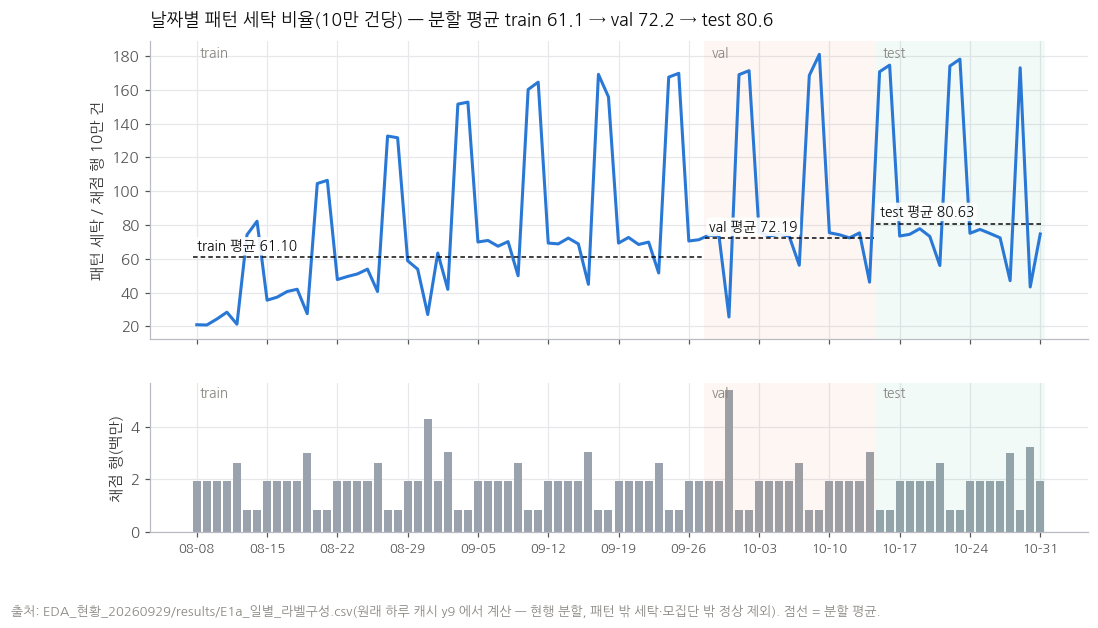

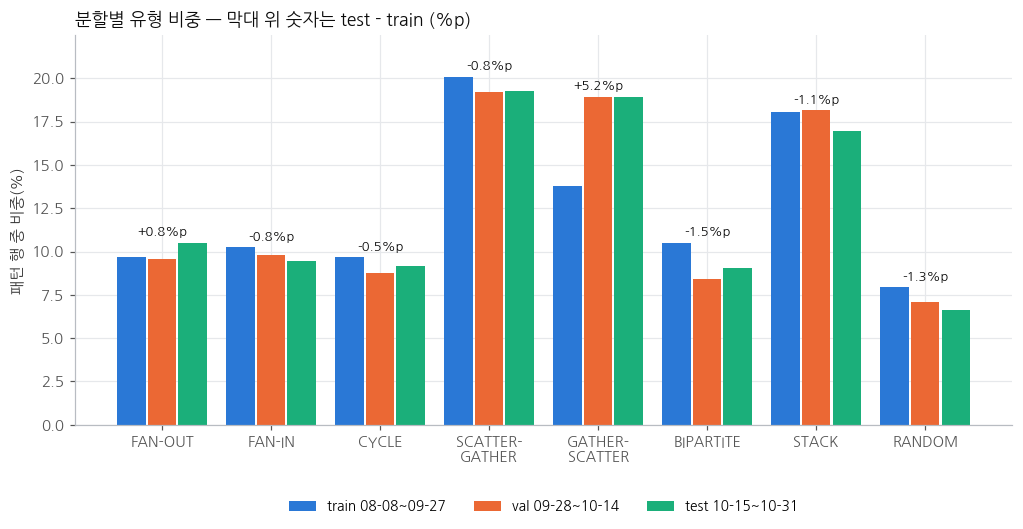

anon 5.24 GiB


In [75]:
# 원본: EDA_현황_20260929/_builders/common.py:42-50 (shade_splits · day_ticks, L.days_of → days_of)
def shade_splits(ax):
    """x 축이 날짜 번호(0~84)일 때 val·test 구간을 옅게 표시."""
    i_val, i_test = DAYS.index(days_of('val')[0]), DAYS.index(days_of('test')[0])
    ax.axvspan(i_val - 0.5, i_test - 0.5, color='#eb6834', alpha=0.06, lw=0)
    ax.axvspan(i_test - 0.5, len(DAYS) - 0.5, color='#1baf7a', alpha=0.06, lw=0)
    for i, t in ((0, 'train'), (i_val, 'val'), (i_test, 'test')):
        ax.text(i + 0.3, 0.98, t, transform=ax.get_xaxis_transform(), fontsize=9, color=MUTED, va='top')
def day_ticks(ax, step=7):
    idx = list(range(0, len(DAYS), step)); ax.set_xticks(idx); ax.set_xticklabels([DAYS[i][5:] for i in idx], fontsize=8.5)

D = E1a.copy(); Ssum = E1b; CN = CLASS_NAMES
assert list(D['날짜']) == DAYS

# 원본: build_E1.py 그림 셀(:91-119). 바꾼 곳: 분할 평균 이름표에 흰 바탕(선과 겹침 방지), 아래 출처 문구(CSV 에서 다시 그림), 저장 이름, 마지막 줄(tree9_lib 의 anon_gib → 이 노트북 것)
x = np.arange(len(D))
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
a1.plot(x, D['패턴비율_pct'] * 1000, color='#2a78d6', lw=2)
for s in SPLITS:
    m = (D['분할'] == s).to_numpy(); v = 1000 * Ssum.loc[s, '패턴비율_pct']
    a1.hlines(v, x[m][0] - 0.4, x[m][-1] + 0.4, color=INK, lw=1, ls=(0, (3, 2)))
    a1.text(x[m][0], v * 1.04, f'{s} 평균 {v:.2f}', fontsize=9, color=INK, va='bottom', zorder=5, bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9))
a1.set_ylabel('패턴 세탁 / 채점 행 10만 건'); shade_splits(a1)
_m = [1000 * Ssum.loc[s, '패턴비율_pct'] for s in SPLITS]
a1.set_title(f'날짜별 패턴 세탁 비율(10만 건당) — 분할 평균 train {_m[0]:.1f} → val {_m[1]:.1f} → test {_m[2]:.1f}', loc='left', fontsize=11.5, color=INK, pad=10)
a2.bar(x, D['채점행'] / 1e6, color='#9aa3ad', width=0.8)
a2.set_ylabel('채점 행(백만)'); shade_splits(a2); day_ticks(a2)
fig.text(0.01, -0.02, '출처: EDA_현황_20260929/results/E1a_일별_라벨구성.csv(원래 하루 캐시 y9 에서 계산 — 현행 분할, 패턴 밖 세탁·모집단 밖 정상 제외). 점선 = 분할 평균.', fontsize=8.5, color=MUTED)
savefig(fig, 'S7_1_E1_일별_패턴비율.png')

fig, ax = plt.subplots(figsize=(11, 4.6))
w_ = 0.26; xi = np.arange(len(CN))
for j, s in enumerate(SPLITS):
    vals = piv[s].to_numpy()
    ax.bar(xi + (j - 1) * (w_ + 0.02), vals, width=w_, color=SC[s], label=SPLIT_KO[s])
for i, c in enumerate(CN):
    d_ = piv.loc[c, 'test-train_pp']
    ax.text(i, max(piv.loc[c, list(SPLITS)]) + 0.4, f'{d_:+.1f}%p', ha='center', fontsize=8.5, color=INK)
ax.set_xticks(xi); ax.set_xticklabels([c.replace('-GATHER', '-\nGATHER').replace('-SCATTER', '-\nSCATTER') for c in CN], fontsize=9.5); ax.set_ylabel('패턴 행 중 비중(%)')
ax.set_ylim(0, piv[list(SPLITS)].to_numpy().max() * 1.12)
ax.legend(frameon=False, fontsize=9, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.16))
ax.set_title('분할별 유형 비중 — 막대 위 숫자는 test - train (%p)', loc='left', fontsize=11.5, color=INK)
savefig(fig, 'S7_2_E1_분할별_유형비중.png')
print(f'anon {anon_gib():.2f} GiB')

**해석**
- **패턴 비율: train 0.0611% · val 0.0722%(×1.18) · test 0.0806%(×1.32).** 오름의 대부분은 train 앞 4주(주별 0.031~0.060%)에서 온다. 09-05 이후는 0.066~0.085% 로 비슷하다. 08-01 에 데이터가 시작해 진행 중인 시도가 쌓이는 초기 구간으로 보인다(해석 — 활성 시도 수를 날짜별로 세지는 않음).
- 요일 효과가 크다. 주말은 거래가 적지만 패턴 수는 비슷해서 10만 건당 값이 튄다. **09-10 이후 주말은 약 156~181**(10-30 제외)이다. train 앞 4주의 주말은 74~153 으로 낮고, **10-30(일)은 거래가 324만 행으로 급증해 43** 이다(위 셀 출력).
- **유형 비중은 GATHER-SCATTER 만 크게 움직인다**: 13.8% → 18.9%(+5.2%p). 나머지는 ±1.5%p 안이다. 시도 수는 train 9,466 · val 6,784 · test 6,816 이다.
- 이 표는 **병합 전**(패턴 밖 제외) 정의다. 학습이 보는 사전확률 50%(CSSMC r300 + 가중치 300)도 병합 전 학습 기준이다. 09-30 병합판은 패턴 밖 43,095행을 가중치 1 로 따로 넣으므로 그 값이 맞지 않는다.

### 7-2. 라벨 병합판 비율과 최종 test22 [저장값에서 산술]
- **병합판**(09-29 결정): 패턴 밖 세탁을 정상 클래스 8 로 합친다. 그래서 9클래스 모집단 = 채점 행 + 패턴 밖 세탁(= R2 의 "고치기 전" 모집단 행)이다.
- **test22**(최종 평가만, 11-05 까지): test17 + 11-01~05. 11-01~05 는 fix `D2` 의 `4_되살린5일` 행에서 가져온다("되살린 5일"은 **기간 이름**이다. 옛 라벨판 = 중복 되살림 전).
- **11-01~05 입력은 아직 만들지 않았다**(세션상태 09-30: "11-01~05 입력 만들기 → 최종 모델만 채점"이 할 일). 그 5일에 어느 모집단을 쓸지(옛 라벨판 9,234,293행 / 중복 되살림판 9,234,871행 — DB 와 같음)도 정해지지 않았다. 그래서 아래 test22 표는 **두 가정을 나란히** 보인다.
- 저장값끼리 더하고 나눈 값이다. 결과는 `out/merged_prior.csv` · `out/test22_prior.csv` 에 남긴다.

In [76]:
Mg = pd.DataFrame({'모집단 행(채점+패턴 밖)': E1b['채점행'] + E1b['패턴밖세탁'], '패턴': E1b['패턴'], '패턴 밖(→ 정상 8)': E1b['패턴밖세탁']})
Mg['병합 전 패턴 비율_pct'] = E1b['패턴비율_pct']
Mg['병합판 패턴 비율_pct'] = 100 * Mg['패턴'] / Mg['모집단 행(채점+패턴 밖)']
Mg['병합판 정상 8 중 패턴 밖_pct'] = 100 * Mg['패턴 밖(→ 정상 8)'] / (Mg['모집단 행(채점+패턴 밖)'] - Mg['패턴'])
R2 = rd(FRES / 'R2_행수라벨_전후.csv'); r2 = R2[R2['시점'] == '고치기 전'].set_index('구간')
assert list(Mg['모집단 행(채점+패턴 밖)']) == [int(r2.loc['train', '모집단_행']), int(r2.loc['val', '모집단_행']), int(r2.loc['test(옛 17일)', '모집단_행'])]
print('■ 병합판 사전확률(현행 모집단 = 옛 라벨, 되살림 전)'); display(Mg.round(6))
Mg.rename_axis('분할').to_csv(OUT / 'merged_prior.csv', encoding='utf-8-sig'); print(f'저장: {OUT / "merged_prior.csv"}')

D2f = rd(FRES / 'D2_라벨수_전후대조.csv')
T22s = []
for tag, lab in (('(가) 옛 라벨판(현행 85일과 같은 규칙)', '0_옛(고치기 전)'), ('(나) 중복 되살림판(fix 정정안 최종, DB 와 같음)', '2_[D]+[G] 최종')):
    old = D2f[D2f['라벨판'] == lab].set_index('기간').drop(columns=['라벨판'])
    t17, t5 = old.loc['3_test17(10-15~10-31)'], old.loc['4_되살린5일(11-01~11-05)']
    T = pd.DataFrame({'test17(10-15~10-31)': t17, '11-01~05': t5, 'test22(10-15~11-05)': t17 + t5}).T
    T['병합 전 채점 행'] = T['모집단_행'] - T['패턴밖_세탁']
    T['병합 전 패턴 비율_pct'] = 100 * T['패턴_세탁'] / T['병합 전 채점 행']
    T['병합판 패턴 비율_pct'] = 100 * T['패턴_세탁'] / T['모집단_행']
    T22s.append(T.assign(가정=tag).set_index('가정', append=True).swaplevel())
T22 = pd.concat(T22s)
print('■ 최종 test22 — 11-01~05 의 모집단이 미정이라 두 가정을 나란히(세탁·패턴 수는 같고 정상 행만 다르다)')
display(T22[['모집단_행', '정상', '세탁', '패턴_세탁', '패턴밖_세탁', '병합 전 채점 행', '병합 전 패턴 비율_pct', '병합판 패턴 비율_pct']].round(4))
t22b = int(T22.loc[('(나) 중복 되살림판(fix 정정안 최종, DB 와 같음)', 'test22(10-15~11-05)'), '모집단_행'])
assert int(R2[(R2['시점'] == '고친 뒤') & R2['구간'].str.startswith('test')]['모집단_행'].iloc[0]) == t22b
T22.to_csv(OUT / 'test22_prior.csv', encoding='utf-8-sig'); print(f'저장: {OUT / "test22_prior.csv"} · (나)의 test22 모집단 = R2 "고친 뒤" test(고친 22일) 행과 같음')

읽음: /workspace/Final_preprocess/fix_20260927/results/R2_행수라벨_전후.csv  (676 B · 8행)
■ 병합판 사전확률(현행 모집단 = 옛 라벨, 되살림 전)


,모집단 행(채점+패턴 밖),패턴,패턴 밖(→ 정상 8),병합 전 패턴 비율_pct,병합판 패턴 비율_pct,병합판 정상 8 중 패턴 밖_pct
분할,,,,,,
train,91426514,55837,43095,0.061102,0.061073,0.047165
val,33649784,24280,16691,0.072191,0.072155,0.049638
test,30407864,24503,17063,0.080626,0.080581,0.056159


저장: /workspace/Final_preprocess/통합본_20260930/EDA_HI-Large/out/merged_prior.csv
읽음: /workspace/Final_preprocess/fix_20260927/results/D2_라벨수_전후대조.csv  (2,251 B · 18행)
■ 최종 test22 — 11-01~05 의 모집단이 미정이라 두 가정을 나란히(세탁·패턴 수는 같고 정상 행만 다르다)


모집단_행        정상     세탁  패턴_세탁  패턴밖_세탁  병합 전 채점 행  병합 전 패턴 비율_pct  병합판 패턴 비율_pct
가정                                                                                                                                      
(가) 옛 라벨판(현행 85일과 같은 규칙)         test17(10-15~10-31)  30407864  30366298  41566  24503   17063   30390801          0.0806         0.0806
                                 11-01~05              9234293   9221695  12598   7248    5350    9228943          0.0785         0.0785
                                 test22(10-15~11-05)  39642157  39587993  54164  31751   22413   39619744          0.0801         0.0801
(나) 중복 되살림판(fix 정정안 최종, DB 와 같음) test17(10-15~10-31)  30409636  30368070  41566  24503   17063   30392573          0.0806         0.0806
                                 11-01~05              9234871   9222273  12598   7248    5350    9229521          0.0785         0.0785
                                 test22(10-15~11-05)  39644507  39590343  54164  31751   22413   39622094          0.0801         0.0801

저장: /workspace/Final_preprocess/통합본_20260930/EDA_HI-Large/out/test22_prior.csv · (나)의 test22 모집단 = R2 "고친 뒤" test(고친 22일) 행과 같음


**해석**
- 병합판에서는 모집단이 패턴 밖만큼 커지므로 패턴 비율이 아주 조금 낮아진다(0.0001%p 미만). train → test 로 오르는 모양은 같다.
- 정상 클래스 8 안의 패턴 밖 비율은 train 약 0.047% · test 약 0.056% 다. 패턴 밖도 뒤로 갈수록 조금 많다.
- 11-01~05 는 옛 라벨판 9,234,293행 / 되살림판 9,234,871행이다(578행 차이 = 가짜 중복 되살림, §6). 세탁 12,598 · 패턴 7,248 은 두 판이 같다. 유형별로 785 · 683 · 542 · 1,431 · 1,426 · 662 · 1,212 · 507 이다.
- test22 모집단은 (가) 39,642,157 / (나) 39,644,507행이다. **어느 쪽을 쓸지는 미정**이다(11-01~05 입력을 만들 때 정한다). 패턴 비율은 소수 넷째 자리까지 같다.

### 7-3. 36피처(LightGBM 55열)의 시계 효과(E3)
원래 계산(`build_E3.py`)은 `/tmp/lgb55`(지금 없음)의 55열 행렬과 하루 캐시를 읽고 **보조 판별기**(결정적 LightGBM 200트리, 본 모델 아님)를 학습한다. **꺼 두었다.**

In [77]:
# [무거움 · 기본 꺼짐] 원본: EDA_현황_20260929/_builders/common.py HEAD:7-52 + build_E3.py 코드 셀 1~4(:21-41 · :43-60 · :62-81 · :83-107)
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: HEAD 의 OUT = EDA/results 삭제(함수 첫 줄의 OUT = out/ 을 씀)
def _heavy_E3():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    import os
    for k in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
        os.environ[k] = '3'
    import sys, json, time, datetime
    from pathlib import Path
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np, pandas as pd, pyarrow.parquet as pq
    import tree9_lib as L
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt, matplotlib.font_manager as fm
    from IPython.display import Image, display

    T0 = time.time()
    EDA = Path('/workspace/Final_preprocess/EDA_현황_20260929'); FIG = OUT / '_figs'   # (통합본) OUT = 이 노트북 out/ (원래 EDA / 'results')
    FIG.mkdir(parents=True, exist_ok=True)
    CACHE = Path('/tmp/gnn36_full'); PL = Path('/tmp/tree9_work/db_full/pattern_labels.parquet')
    TG = Path('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928')
    a = L.anon_gib(); print(f'anon {a:.2f} GiB'); assert a < 15.0, 'anon 15 GiB 초과 — 멈춘다'
    SPLITS = ('train', 'val', 'test')
    SPLIT_OF = {d: s for s in SPLITS for d in L.days_of(s)}
    DAYS = sorted(SPLIT_OF)
    CN = L.CLASS_NAMES[:8]
    miss = [d for d in DAYS if not (CACHE / f'day={d}' / '_DONE').exists()]
    assert not miss, f'캐시 없음 {miss[:3]}'
    # 그림: 나눔고딕, dataviz 기본 팔레트(분할 3개 = 앞 3칸, 모든 쌍 색각 검증 통과)
    FONT = Path('/workspace/Final_preprocess/HI-Large_EDA/notebooks/_assets/NanumGothic-Regular.ttf')
    fm.fontManager.addfont(str(FONT))
    plt.rcParams.update({'font.family': fm.FontProperties(fname=str(FONT)).get_name(), 'axes.unicode_minus': False,
                         'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False,
                         'axes.edgecolor': '#b8bcc2', 'axes.labelcolor': '#333', 'xtick.color': '#555', 'ytick.color': '#555',
                         'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#e6e8eb', 'grid.linewidth': 0.8, 'lines.linewidth': 2})
    INK, MUTED = '#1f1f1f', '#666'
    SC = {'train': '#2a78d6', 'val': '#eb6834', 'test': '#1baf7a'}      # 분할 색(팔레트 1~3칸)
    SPLIT_KO = {'train': 'train 08-08~09-27', 'val': 'val 09-28~10-14', 'test': 'test 10-15~10-31'}
    def shade_splits(ax):
        """x 축이 날짜 번호(0~84)일 때 val·test 구간을 옅게 표시."""
        i_val, i_test = DAYS.index(L.days_of('val')[0]), DAYS.index(L.days_of('test')[0])
        ax.axvspan(i_val - 0.5, i_test - 0.5, color='#eb6834', alpha=0.06, lw=0)
        ax.axvspan(i_test - 0.5, len(DAYS) - 0.5, color='#1baf7a', alpha=0.06, lw=0)
        for i, t in ((0, 'train'), (i_val, 'val'), (i_test, 'test')):
            ax.text(i + 0.3, 0.98, t, transform=ax.get_xaxis_transform(), fontsize=9, color=MUTED, va='top')
    def day_ticks(ax, step=7):
        idx = list(range(0, len(DAYS), step)); ax.set_xticks(idx); ax.set_xticklabels([DAYS[i][5:] for i in idx], fontsize=8.5)
    def savefig(fig, name):
        p = FIG / name; fig.savefig(p, dpi=130, bbox_inches='tight'); plt.close(fig); display(Image(filename=str(p))); return p

    from sklearn.metrics import roc_auc_score
    import lightgbm as lgb
    LG = Path('/tmp/lgb55/full')
    F55 = json.loads(Path('/workspace/Final_preprocess/HI-Large_EDA/us_cmp_20260922/arms/cssmc_r300_w300/run.json').read_text())['settings']['features'] + ['amt_z_pay_ccy']
    assert len(F55) == 55 and F55[38] == 'pair_prior_count'
    CUM4 = ['pair_prior_count', 'pair_history_count', 'reverse_history_count', 'pair_age_at_day_start']
    STEP = 20
    def open_split(s):
        if s == 'train':
            X = np.memmap(LG / 'subset_cssmc_r300/X.f32', np.float32, 'r'); y = np.load(LG / 'subset_cssmc_r300/y.npy')
        else:
            X = np.memmap(LG / f'{s}_X55.f32', np.float32, 'r'); y = np.load(LG / f'{s}_y9.npy')
        X = X.reshape(-1, 55); assert len(X) == len(y), (s, X.shape, y.shape); return X, y
    NS, PS = {}, {}
    for s in SPLITS:
        X, y = open_split(s)
        idx = np.arange(0, len(y), STEP); Xi = np.asarray(X[idx]); yi = y[idx]
        NS[s] = Xi[yi == 8]; PS[s] = np.asarray(X[np.flatnonzero(y < 8)])
        print(s, '전체', len(y), '· 정상', int((y == 8).sum()), '· 패턴', int((y < 8).sum()), '· 정상 표본', len(NS[s]), f'{time.time()-T0:.0f}s')
        del X, Xi
    assert int((np.load(LG / 'subset_cssmc_r300/y.npy') == 8).sum()) == 16_751_100

    def uauc(a, b):
        return float(roc_auc_score(np.r_[np.zeros(len(a)), np.ones(len(b))], np.r_[a, b]))
    rows = []
    for j, c in enumerate(F55):
        r = dict(열=c, 묶음=('송신 노드' if j < 19 else '수신 노드' if j < 38 else '엣지'))
        for s in SPLITS:
            v = NS[s][:, j]; r[f'{s}_중앙값'] = float(np.median(v)); r[f'{s}_p90'] = float(np.quantile(v, 0.9)); r[f'{s}_0비율'] = float((v == 0).mean())
        r['AUC_train_vs_val'] = uauc(NS['train'][:, j], NS['val'][:, j]); r['AUC_train_vs_test'] = uauc(NS['train'][:, j], NS['test'][:, j])
        r['AUC_val_vs_test'] = uauc(NS['val'][:, j], NS['test'][:, j])
        r['패턴_AUC_train_vs_test'] = uauc(PS['train'][:, j], PS['test'][:, j])
        r['패턴_train_중앙값'] = float(np.median(PS['train'][:, j])); r['패턴_test_중앙값'] = float(np.median(PS['test'][:, j]))
        rows.append(r)
    U = pd.DataFrame(rows); U['이동크기'] = (U['AUC_train_vs_test'] - 0.5).abs()
    U = U.sort_values('이동크기', ascending=False)
    U.to_csv(OUT / 'E3a_열별_분포이동.csv', index=False, encoding='utf-8-sig')
    with pd.option_context('display.width', 250, 'display.float_format', '{:.3f}'.format, 'display.max_columns', 30):
        print(U[['열', '묶음', 'train_중앙값', 'val_중앙값', 'test_중앙값', 'AUC_train_vs_val', 'AUC_train_vs_test', 'AUC_val_vs_test', '패턴_AUC_train_vs_test']].head(20).to_string(index=False))
    print('|AUC-0.5| ≥ 0.10 인 열', int((U['이동크기'] >= 0.10).sum()), '· ≥ 0.05', int((U['이동크기'] >= 0.05).sum()), f'· {time.time()-T0:.0f}s')

    P = dict(objective='binary', learning_rate=0.1, num_leaves=31, min_data_in_leaf=100, feature_fraction=1.0, bagging_fraction=1.0, bagging_freq=0,
             deterministic=True, force_row_wise=True, num_threads=3, seed=42, verbose=-1)
    def adversarial(a, b, cols, name):
        ci = [F55.index(c) for c in cols]
        X = np.vstack([a[:, ci], b[:, ci]]); y = np.r_[np.zeros(len(a)), np.ones(len(b))]
        ev = np.arange(len(y)) % 2 == 1                                   # 홀수 행 = 평가, 짝수 행 = 학습(무작위 없음)
        bst = lgb.train(P, lgb.Dataset(X[~ev], y[~ev], feature_name=[c.replace(' ', '_') for c in cols]), num_boost_round=200)
        auc = float(roc_auc_score(y[ev], bst.predict(X[ev])))
        gain = pd.Series(bst.feature_importance('gain'), index=cols); gain = (gain / gain.sum()).sort_values(ascending=False)
        print(f'{name}: 열 {len(cols)} · 행 {len(y):,} · 평가 AUC {auc:.4f} · gain 상위', gain.head(5).round(3).to_dict(), f'{time.time()-T0:.0f}s')
        return dict(판별=name, 열수=len(cols), 평가AUC=auc, gain_상위10=json.dumps(gain.head(10).round(4).to_dict(), ensure_ascii=False)), gain
    ADV, GAINS = [], {}
    for name, a, b, cols in (('train vs test · 55열', NS['train'], NS['test'], F55),
                             ('train vs val · 55열', NS['train'], NS['val'], F55),
                             ('val vs test · 55열', NS['val'], NS['test'], F55),
                             ('train vs test · 누적 4열 뺀 51열', NS['train'], NS['test'], [c for c in F55 if c not in CUM4]),
                             ('train vs test · 누적 4열만', NS['train'], NS['test'], CUM4)):
        r, g = adversarial(a, b, cols, name); ADV.append(r); GAINS[name] = g
    ADV = pd.DataFrame(ADV); ADV.to_csv(OUT / 'E3b_보조판별기_AUC.csv', index=False, encoding='utf-8-sig')
    print(ADV[['판별', '열수', '평가AUC']].to_string(index=False))

    SCH = pd.read_csv('/workspace/Final_preprocess/aml_feature_schema.csv', encoding='utf-8-sig')
    E17 = list(SCH.query("tensor=='edge'").sort_values('col_index')['feature']); assert E17[0] == 'pair_prior_count' and len(E17) == 17
    rows = []
    for d in DAYS:
        p = CACHE / f'day={d}'; y9 = np.load(p / 'y9.npy'); X = np.load(p / 'target_x.npy', mmap_mode='r')
        n, pt = y9 == 8, (y9 >= 0) & (y9 < 8)
        Xn = np.asarray(X[np.flatnonzero(n)]); Xp = np.asarray(X[np.flatnonzero(pt)])
        r = dict(날짜=d, 분할=SPLIT_OF[d], 정상행=int(n.sum()), 패턴행=int(pt.sum()))
        for j, c in enumerate(E17):
            r[f'정상_중앙값_{c}'] = float(np.median(Xn[:, j])); r[f'정상_p90_{c}'] = float(np.quantile(Xn[:, j], 0.9)); r[f'정상_0비율_{c}'] = float((Xn[:, j] == 0).mean())
            r[f'패턴_중앙값_{c}'] = float(np.median(Xp[:, j])) if len(Xp) else np.nan; r[f'패턴_0비율_{c}'] = float((Xp[:, j] == 0).mean()) if len(Xp) else np.nan
        rows.append(r); del X, Xn, Xp
    Dy = pd.DataFrame(rows); Dy.to_csv(OUT / 'E3c_엣지17열_날짜별.csv', index=False, encoding='utf-8-sig')
    from scipy.stats import spearmanr
    tr = (Dy['분할'] == 'train').to_numpy(); ix = np.arange(len(Dy))
    sp = []
    for c in E17:
        for kind in ('정상_중앙값', '정상_0비율', '패턴_0비율'):
            v = Dy[f'{kind}_{c}'].to_numpy()
            sp.append(dict(열=c, 지표=kind, rho_85일=spearmanr(ix, v).correlation, rho_train51일=spearmanr(ix[tr], v[tr]).correlation,
                           train첫주=float(np.nanmean(v[:7])), train끝주=float(np.nanmean(v[44:51])), test평균=float(np.nanmean(v[68:]))))
    SP = pd.DataFrame(sp); SP.to_csv(OUT / 'E3d_엣지열_날짜추세.csv', index=False, encoding='utf-8-sig')
    with pd.option_context('display.width', 220, 'display.float_format', '{:.3f}'.format):
        print(SP[SP['지표'] != '패턴_0비율'].sort_values('rho_85일', key=np.abs, ascending=False).head(16).to_string(index=False))
    print(f'{time.time()-T0:.0f}s')


if HEAVY['E3']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_E3()
else:
    print("HEAVY['E3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['E3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E3b_보조판별기_AUC.csv  (1,744 B · 5행)


,판별,열수,평가AUC
0,train vs test · 55열,55,0.9976
1,train vs val · 55열,55,0.9931
2,val vs test · 55열,55,0.9939
3,train vs test · 누적 4열 뺀 51열,51,0.8269
4,train vs test · 누적 4열만,4,0.9838


gain 상위(train vs test · 55열): {"pair_history_count": 0.5054, "pair_age_at_day_start": 0.1456, "dst_log_in_count": 0.0805, "pair_count_1h": 0.0571, "pair_prior_count": 0.0445, "src_log_out_count": 0.0417, "src_log_active_days": 0.0218, "pair_gap_minutes": 0.0194, "reverse_history_count": 0.0155, "src_log_out_neighbors": 0.0134}
읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E3a_열별_분포이동.csv  (15,439 B · 55행)


,열,묶음,train_중앙값,val_중앙값,test_중앙값,AUC_train_vs_val,AUC_train_vs_test,AUC_val_vs_test,패턴_AUC_train_vs_test
0,pair_history_count,엣지,3.932,4.691,5.030,0.726,0.781,0.614,0.508
1,pair_prior_count,엣지,3.932,4.700,5.030,0.726,0.780,0.613,0.508
2,src_log_active_days,송신 노드,3.296,3.434,3.434,0.654,0.659,0.505,0.562
3,dst_log_active_days,수신 노드,3.178,3.434,3.434,0.646,0.652,0.508,0.560
4,dst_log_in_count,수신 노드,4.174,4.290,4.290,0.585,0.587,0.501,0.529
5,pair_age_at_day_start,엣지,6.786,6.845,6.884,0.529,0.541,0.512,0.508
6,src_log_in_count,송신 노드,3.912,4.159,4.143,0.543,0.540,0.497,0.531
7,src_log_out_count,송신 노드,4.700,4.852,4.860,0.535,0.536,0.500,0.524
8,dst_log_entity_in_diversity,수신 노드,1.792,1.792,1.792,0.526,0.530,0.504,0.520
9,dst_log_in_neighbors,수신 노드,1.609,1.609,1.609,0.525,0.529,0.504,0.531


읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E3c_엣지17열_날짜별.csv  (104,028 B · 85행)
읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E3d_엣지열_날짜추세.csv  (6,026 B · 51행)


,열,지표,rho_85일,rho_train51일,train첫주,train끝주,test평균
0,pair_prior_count,정상_중앙값,0.881,0.954,3.017,4.652,4.898
24,pair_history_count,정상_중앙값,0.881,0.954,2.998,4.647,4.888
3,pair_gap_minutes,정상_중앙값,0.663,0.672,3.630,3.746,4.479
30,pair_age_at_day_start,정상_중앙값,0.483,0.465,6.803,6.837,7.133
33,same_entity,정상_중앙값,0.182,NaN,0.000,0.000,0.059
27,reverse_history_count,정상_중앙값,0.182,NaN,0.000,0.000,0.082
45,is_self_transfer,정상_중앙값,0.182,NaN,0.000,0.000,0.059
36,same_known_country,정상_중앙값,0.182,NaN,0.000,0.000,0.059


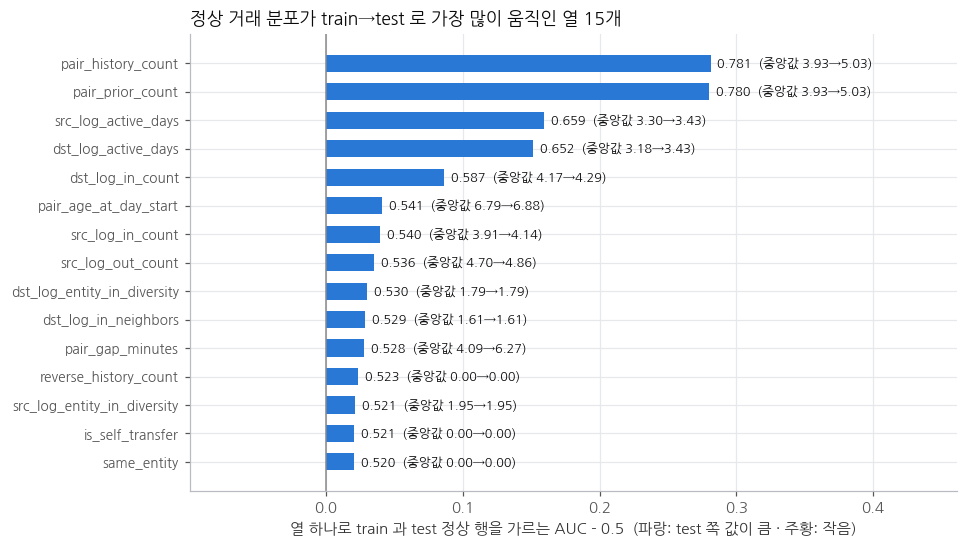

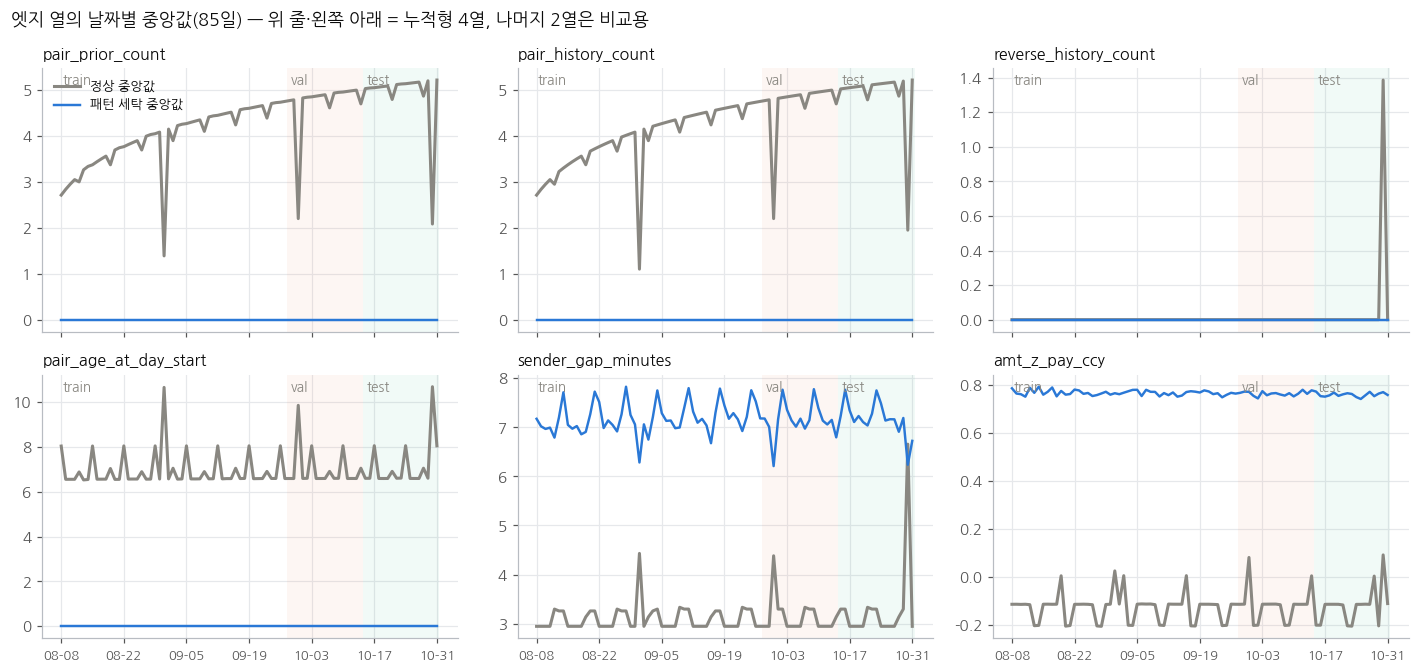

anon 5.25 GiB


In [78]:
E3b = rd(ERES / 'E3b_보조판별기_AUC.csv'); display(E3b[['판별', '열수', '평가AUC']].round(4))
print('gain 상위(train vs test · 55열):', E3b.loc[0, 'gain_상위10'])
U = rd(ERES / 'E3a_열별_분포이동.csv')
display(U[['열', '묶음', 'train_중앙값', 'val_중앙값', 'test_중앙값', 'AUC_train_vs_val', 'AUC_train_vs_test', 'AUC_val_vs_test', '패턴_AUC_train_vs_test']].head(12).round(3))
Dy = rd(ERES / 'E3c_엣지17열_날짜별.csv'); SP = rd(ERES / 'E3d_엣지열_날짜추세.csv')
display(SP[SP['지표'] == '정상_중앙값'].sort_values('rho_85일', key=np.abs, ascending=False).head(8).round(3))
CUM4 = ['pair_prior_count', 'pair_history_count', 'reverse_history_count', 'pair_age_at_day_start']
ix = np.arange(len(Dy)); assert list(Dy['날짜']) == DAYS

# 원본: build_E3.py 그림 셀(:109-131). 바꾼 곳: 저장 이름, 마지막 줄, 날짜별 그림의 색(정상 회색 · 패턴 파랑 — 이 노트북 규칙)
top = U.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.4))
col = np.where(top['AUC_train_vs_test'] >= 0.5, '#2a78d6', '#eb6834')
ax.barh(np.arange(len(top)), top['AUC_train_vs_test'] - 0.5, color=col, height=0.6)
for i, (v, m1, m3) in enumerate(zip(top['AUC_train_vs_test'], top['train_중앙값'], top['test_중앙값'])):
    ax.text((v - 0.5) + (0.005 if v >= 0.5 else -0.005), i, f'{v:.3f}  (중앙값 {m1:.2f}→{m3:.2f})', va='center', ha='left' if v >= 0.5 else 'right', fontsize=8.3, color=INK)
ax.axvline(0, color='#888', lw=1); ax.set_yticks(np.arange(len(top))); ax.set_yticklabels(top['열'], fontsize=9)
ax.set_xlabel('열 하나로 train 과 test 정상 행을 가르는 AUC - 0.5  (파랑: test 쪽 값이 큼 · 주황: 작음)')
ax.set_xlim(min(-0.02, (top['AUC_train_vs_test'] - 0.5).min() - 0.12), (top['AUC_train_vs_test'] - 0.5).max() + 0.18)
ax.set_title('정상 거래 분포가 train→test 로 가장 많이 움직인 열 15개', loc='left', fontsize=11.5, color=INK)
savefig(fig, 'S7_3_E3_열별_분포이동_상위15.png')

show = CUM4 + ['sender_gap_minutes', 'amt_z_pay_ccy']
fig, axs = plt.subplots(2, 3, figsize=(13, 6.2), sharex=True)
for ax, c in zip(axs.ravel(), show):
    ax.plot(ix, Dy[f'정상_중앙값_{c}'], color=C_NORM, lw=2, label='정상 중앙값')
    ax.plot(ix, Dy[f'패턴_중앙값_{c}'], color=C_PAT, lw=1.6, label='패턴 세탁 중앙값')
    shade_splits(ax); day_ticks(ax, 14); ax.set_title(c, loc='left', fontsize=10.5, color=INK)
axs[0, 0].legend(frameon=False, fontsize=8.5, loc='upper left')
fig.suptitle('엣지 열의 날짜별 중앙값(85일) — 위 줄·왼쪽 아래 = 누적형 4열, 나머지 2열은 비교용', x=0.01, ha='left', fontsize=11.5, color=INK)
fig.tight_layout()
savefig(fig, 'S7_4_E3_엣지열_날짜별추이.png')
print(f'anon {anon_gib():.2f} GiB')

**해석**
- 열만 보고 "train 행이냐 test 행이냐"를 맞히는 보조 판별기 AUC: **train vs test 0.998 · train vs val 0.993 · val vs test 0.994.** 누적 4열을 빼도 0.827, 누적 4열만으로 0.984 다. gain 의 50.5% 가 `pair_history_count` 다.
- 열 하나로도 `pair_history_count` · `pair_prior_count` 가 AUC 0.78 이다(정상 중앙값 3.93 → 5.03, log1p). **패턴 행에서는 같은 열이 0.51** 로 거의 안 움직인다. 패턴의 약 87% 가 값 0(처음 쌍)에 머물기 때문이다(§5-2).
- 정상 `pair_prior_count` 중앙값은 날짜와 Spearman 0.88(train 안 0.95)이다. **정상과 패턴을 가르는 누적 열의 간격이 시간이 갈수록 벌어진다.** 그래서 val → test 점수 차이를 원인 하나로 설명하지 않는다. 성능 영향은 미측정이다. 옛 41열로 잰 시계 AUC 는 대체됐다(부록 A).

### 7-4. 시도·계좌 겹침(M1 · M3)
원래 계산(`review_leakage_20260929/측정_M1_M3.ipynb` cell 1 · 3 · 5 · 7)은 하루 캐시를 날짜순으로 읽는다. **꺼 두었다.** 바꾼 곳: cell 1 의 `OUT = REV / 'results'` 한 줄.

In [79]:
# [무거움 · 기본 꺼짐] 원본: review_leakage_20260929/측정_M1_M3.ipynb cell 1 · 3 · 5 · 7
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: cell 1 의 OUT 줄 주석 처리
def _heavy_M1_M3():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    import os
    for k in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
        os.environ[k] = '3'
    import sys, json, time
    from pathlib import Path
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np
    import pandas as pd
    import pyarrow.parquet as pq
    import tree9_lib as L

    T0 = time.time()
    CACHE = Path('/tmp/gnn36_full')
    PL = Path('/tmp/tree9_work/db_full/pattern_labels.parquet')
    NM = Path('/tmp/tree9_work/db_full/node_mapping.parquet')
    REV = Path('/workspace/Final_preprocess/HI-Large_EDA/review_leakage_20260929')
    # OUT = REV / 'results'   ← (통합본) 함수 첫 줄의 OUT(out/)을 씀
    OUT.mkdir(parents=True, exist_ok=True)
    TG = Path('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928')

    a = L.anon_gib()
    print(f'anon {a:.2f} GiB')
    assert a < 15.0, 'anon 이 15 GiB 를 넘었다 — 프롬프트 §1-3 에 따라 측정하지 않는다'

    SPL = {s: L.days_of(s) for s in ('train', 'val', 'test')}
    missing = [d for s in SPL for d in SPL[s] if not (CACHE / f'day={d}' / '_DONE').exists()]
    HAVE_CACHE, HAVE_PL = (not missing), PL.exists()
    print('날짜 수', {s: len(v) for s, v in SPL.items()}, '· 빠진 캐시', len(missing), '· pattern_labels', HAVE_PL)
    CN = L.CLASS_NAMES[:8]
    N_NODE = pq.ParquetFile(NM).metadata.num_rows if NM.exists() else 3_000_000
    print('계좌 수(node_mapping 행)', N_NODE)

    assert HAVE_CACHE, f'캐시 없음 {missing[:3]} — M1·M2·M3 미측정(입력 없음)'
    pl = pq.read_table(PL, columns=['edge_id', 'attempt_id', 'pattern_type']).to_pandas() if HAVE_PL else None
    pat_eids = np.sort(pl['edge_id'].to_numpy(np.int64)) if HAVE_PL else np.empty(0, np.int64)
    print('pattern_labels 행', 0 if pl is None else len(pl), '· 시도 수', 0 if pl is None else pl['attempt_id'].nunique())

    seen_tr = np.zeros(N_NODE + 1, bool)       # train 날짜에 한 번이라도 등장
    seen_va = np.zeros(N_NODE + 1, bool)       # val 날짜에 등장
    seen_cum = np.zeros(N_NODE + 1, bool)      # 지금 읽는 날 이전 모든 날에 등장
    tr_pat_eid_any = []                        # train 날에 있는 패턴 거래 번호(y9 무관 — 모집단 밖 포함)
    tr_pat_eid_in = []                         # train 날에 있고 y9 0~7(학습에 실제로 들어간 패턴 행)
    tr_counts = np.zeros(9, np.int64)
    chk = {s: dict(targets=0, kept=0, pattern=0, excluded=0) for s in SPL}
    EV = {}                                    # val·test 행 배열
    maxnode = 0

    def isin_sorted(x, sorted_arr):
        i = np.minimum(np.searchsorted(sorted_arr, x), max(len(sorted_arr) - 1, 0))
        return (sorted_arr[i] == x) if len(sorted_arr) else np.zeros(len(x), bool)

    for split in ('train', 'val', 'test'):
        parts = dict(y9=[], s_tr=[], d_tr=[], s_cum=[], d_cum=[], s_trva=[], d_trva=[], ppc0=[], eid=[])
        for d in SPL[split]:
            p = CACHE / f'day={d}'
            y9 = np.load(p / 'y9.npy')
            src = np.load(p / 'target_src.npy'); dst = np.load(p / 'target_dst.npy')
            eid = np.load(p / 'target_ids.npy')
            maxnode = max(maxnode, int(src.max()), int(dst.max()))
            c = chk[split]
            c['targets'] += len(y9); c['kept'] += int((y9 >= 0).sum()); c['pattern'] += int(((y9 >= 0) & (y9 < 8)).sum()); c['excluded'] += int((y9 < 0).sum())
            if split == 'train':
                seen_tr[src] = True; seen_tr[dst] = True
                m = isin_sorted(eid, pat_eids)
                tr_pat_eid_any.append(eid[m]); tr_pat_eid_in.append(eid[m & (y9 >= 0) & (y9 < 8)])
                tr_counts += np.bincount(y9[y9 >= 0], minlength=9)
            else:
                k = y9 >= 0
                x0 = np.load(p / 'target_x.npy', mmap_mode='r')[:, 0]
                parts['y9'].append(y9[k]); parts['eid'].append(eid[k])
                parts['s_tr'].append(seen_tr[src[k]]); parts['d_tr'].append(seen_tr[dst[k]])
                parts['s_cum'].append(seen_cum[src[k]]); parts['d_cum'].append(seen_cum[dst[k]])
                trva = seen_tr | seen_va if split == 'test' else seen_tr
                parts['s_trva'].append(trva[src[k]]); parts['d_trva'].append(trva[dst[k]])
                parts['ppc0'].append(np.asarray(x0)[k] == 0)
                if split == 'val':
                    seen_va[src] = True; seen_va[dst] = True
            seen_cum[src] = True; seen_cum[dst] = True        # 그날 처리가 끝난 뒤에만 누적(같은 날은 '이전'이 아님)
            del y9, src, dst, eid
        if split != 'train':
            EV[split] = {k: np.concatenate(v) for k, v in parts.items()}
        print(split, chk[split], f'{time.time() - T0:.0f}s')

    assert maxnode <= N_NODE, (maxnode, N_NODE)
    S = json.loads((TG / 'common/cache36_summary.json').read_text())['by_split']
    for r in S:
        c = chk[r['split']]
        assert (c['targets'], c['kept'], c['pattern'], c['excluded']) == (r['targets'], r['kept'], r['pattern'], r['excluded']), (r, c)
    print('행 수가 cache36_summary.json 과 같다')
    tr_pat_eid_any = np.concatenate(tr_pat_eid_any); tr_pat_eid_in = np.concatenate(tr_pat_eid_in)
    print('train 패턴 행(학습 투입)', len(tr_pat_eid_in), '· train 유형별', dict(zip(L.CLASS_NAMES, tr_counts.tolist())))

    M1 = None
    if HAVE_PL:
        e2a = pl.set_index('edge_id')['attempt_id']
        e2t = pl.set_index('edge_id')['pattern_type']
        att_tr_any = set(e2a.reindex(tr_pat_eid_any).dropna().astype(np.int64).tolist())
        att_tr_in = set(e2a.reindex(tr_pat_eid_in).dropna().astype(np.int64).tolist())
        att_by = {}
        rows = []
        for split in ('val', 'test'):
            E = EV[split]
            pm = E['y9'] < 8
            eid, yy = E['eid'][pm], E['y9'][pm]
            att = e2a.reindex(eid)
            typ = e2t.reindex(eid)
            n_nomatch = int(att.isna().sum())
            att = att.to_numpy()
            name_mismatch = int((np.array(CN, dtype=object)[yy] != typ.to_numpy()).sum())
            print(split, '패턴 행', len(eid), '· 시도 번호 못 찾음', n_nomatch, '· y9 와 pattern_type 불일치', name_mismatch)
            att_by[split] = set(pd.Series(att).dropna().astype(np.int64).tolist())
            df = pd.DataFrame(dict(y9=yy, att=att))
            df['tr_any'] = df['att'].isin(att_tr_any); df['tr_in'] = df['att'].isin(att_tr_in)
            if split == 'test':
                df['va_any'] = df['att'].isin(att_by['val'])
            for k in list(range(8)) + ['전체']:
                g = df if k == '전체' else df[df['y9'] == k]
                ga = g.drop_duplicates('att')
                r = dict(split=split, 유형=('패턴 8종 전체' if k == '전체' else CN[k]), 패턴_행=len(g),
                         행비율_train_아무행=g['tr_any'].mean(), 행비율_train_학습행=g['tr_in'].mean(),
                         시도_수=len(ga), 시도비율_train_아무행=ga['tr_any'].mean(), 시도비율_train_학습행=ga['tr_in'].mean())
                if split == 'test':
                    r.update(행비율_val_아무행=g['va_any'].mean(), 행비율_train또는val=(g['tr_any'] | g['va_any']).mean())
                rows.append(r)
        M1 = pd.DataFrame(rows)
        M1.to_csv(OUT / 'M1_시도겹침.csv', index=False, encoding='utf-8-sig')
        with pd.option_context('display.width', 250, 'display.float_format', '{:.4f}'.format):
            print(M1.to_string(index=False))
    else:
        print('M1 미측정(입력 없음: pattern_labels.parquet)')

    rows = []
    for split in ('val', 'test'):
        E = EV[split]
        for k in list(range(9)) + ['패턴']:
            m = (E['y9'] < 8) if k == '패턴' else (E['y9'] == k)
            name = '패턴 8종 전체' if k == '패턴' else L.CLASS_NAMES[k] if k < 8 else '정상'
            s, d = E['s_tr'][m], E['d_tr'][m]
            r = dict(split=split, 구분=name, 행=int(m.sum()),
                     보낸계좌_train등장=s.mean(), 받은계좌_train등장=d.mean(), 둘중하나_train등장=(s | d).mean(), 둘다_train등장=(s & d).mean(),
                     둘다_처음_train기준=(~s & ~d).mean())
            if split == 'test':
                s2, d2 = E['s_trva'][m], E['d_trva'][m]
                r.update(둘중하나_trainval등장=(s2 | d2).mean(), 둘다_trainval등장=(s2 & d2).mean())
            s3, d3 = E['s_cum'][m], E['d_cum'][m]
            r.update(둘중하나_이전날등장=(s3 | d3).mean(), 둘다_이전날등장=(s3 & d3).mean())
            rows.append(r)
    M3 = pd.DataFrame(rows)
    M3.to_csv(OUT / 'M3_계좌겹침.csv', index=False, encoding='utf-8-sig')
    with pd.option_context('display.width', 250, 'display.float_format', '{:.4f}'.format):
        print(M3.to_string(index=False))


if HEAVY['M1_M3']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_M1_M3()
else:
    print("HEAVY['M1_M3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['M1_M3'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [80]:
M1 = rd(REV / 'M1_시도겹침.csv'); display(M1[['split', '유형', '패턴_행', '행비율_train_아무행', '시도_수', '시도비율_train_아무행', '행비율_val_아무행']].round(3))
M3 = rd(REV / 'M3_계좌겹침.csv'); display(M3[M3.구분.isin(['패턴 8종 전체', '정상'])][['split', '구분', '행', '둘중하나_train등장', '둘다_train등장', '둘다_처음_train기준', '둘다_이전날등장']].round(4))

읽음: /workspace/Final_preprocess/HI-Large_EDA/review_leakage_20260929/results/M1_시도겹침.csv  (2,313 B · 18행)


,split,유형,패턴_행,행비율_train_아무행,시도_수,시도비율_train_아무행,행비율_val_아무행
0,val,FAN-OUT,2323,0.628,799,0.526,NaN
1,val,FAN-IN,2385,0.680,806,0.566,NaN
2,val,CYCLE,2129,0.629,861,0.573,NaN
3,val,SCATTER-GATHER,4668,0.691,958,0.623,NaN
4,val,GATHER-SCATTER,4592,0.772,1208,0.683,NaN
5,val,BIPARTITE,2047,0.346,497,0.322,NaN
6,val,STACK,4408,0.630,922,0.602,NaN
7,val,RANDOM,1728,0.579,733,0.482,NaN
8,val,패턴 8종 전체,24280,0.646,6784,0.569,NaN
9,test,FAN-OUT,2571,0.226,839,0.237,0.623


읽음: /workspace/Final_preprocess/HI-Large_EDA/review_leakage_20260929/results/M3_계좌겹침.csv  (2,621 B · 20행)


,split,구분,행,둘중하나_train등장,둘다_train등장,둘다_처음_train기준,둘다_이전날등장
8,val,정상,33608813,0.9999,0.9997,0.0001,0.9998
9,val,패턴 8종 전체,24280,1.0000,0.9979,0.0000,0.9987
18,test,정상,30366298,0.9982,0.9977,0.0018,0.9979
19,test,패턴 8종 전체,24503,1.0000,0.9973,0.0000,0.9996


**해석**
- **test 패턴 행의 25.7%(val 64.6%)가 train 에서 본 시도**에 속한다. BIPARTITE 는 시도가 짧아(최대 17일) test 에서 0% 다. 날짜 분할에서 시도가 경계를 넘는 것은 정상이다(§2-3).
- 패턴 행의 두 계좌가 모두 train 에 나온 비율은 val 99.8 · test 99.7% 다. test 정상 행 중 두 계좌가 모두 처음인 비율은 0.176% 뿐이다. 계좌가 "외워졌는지"는 §8 의 기억 기준선으로 따로 본다.

### 7-5. 참고: 모델 입력에서 나온 데이터 사실(tgnn D2 · E1 · D5, 09-28~29 유효)
EDA 현황 §2-4 의 09-28~29 행(배치 몰림 · 0 채움 · 입력 크기 · 문맥 상한)이다. 전처리 통합본에도 해당한다. 원래 계산은 모두 하루 캐시 `/tmp/gnn36_full`(지금 없음)을 읽는다. **꺼 두었다.** 0 채움(tgnn E2)은 §5-2 표에 있다.

**(1) 학습 배치 구성(D2)** — `tgnn36_20260928/_builders/build_nb_D.py` 의 준비 셀 + H2 셀.

In [81]:
# [무거움 · 기본 꺼짐] 원본: tgnn36_20260928/_builders/build_nb_D.py 코드 셀 1(:22-34) · 3(:45-77)
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: D2 결과 쓰기 RES → OUT
def _heavy_D2_batch():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    import sys, json
    from pathlib import Path
    import numpy as np, pandas as pd
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import tree9_lib as L
    W = Path('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928'); RES = W / 'results'
    FC = Path('/tmp/gnn36_full'); B = 4096; TYPES = L.CLASS_NAMES[:8]
    CS = np.load(L.EDA / 'us_cmp_20260922/indices/cssmc_r300.npy')
    PL = pd.read_parquet('/tmp/tree9_work/db_full/pattern_labels.parquet').sort_values('edge_id')
    PE, PA = PL['edge_id'].to_numpy(), PL['attempt_id'].to_numpy()
    def attempt_of(e):
        i = np.minimum(np.searchsorted(PE, e), len(PE) - 1); return np.where(PE[i] == e, PA[i], -1)
    DAYS = L.days_of('train'); pd.set_option('display.width', 200)


    def batches(mode):
        rows, adj_same, adj_n, att_batches = [], 0, 0, {}
        for di, d in enumerate(DAYS):
            y = np.load(FC / f'day={d}' / 'y9.npy'); tid = np.load(FC / f'day={d}' / 'target_ids.npy')
            if mode == 'cssmc':
                q = np.minimum(np.searchsorted(CS, tid), len(CS) - 1); pos = np.flatnonzero(((y >= 0) & (y < 8)) | ((CS[q] == tid) & (y == 8)))
            else:
                pos = np.flatnonzero(y >= 0)
            ys, es = y[pos], tid[pos]; pm = ys < 8
            a = attempt_of(es[pm]); adj_same += int((a[1:] == a[:-1]).sum()); adj_n += max(len(a) - 1, 0)
            bidx = np.arange(len(pos)) // B
            for b in np.unique(bidx[pm]):
                for at in np.unique(a[bidx[pm] == b]): att_batches.setdefault(at, set()).add((di, int(b)))
            for b in range(bidx.max() + 1):
                sl = slice(b * B, min((b + 1) * B, len(pos))); yb = ys[sl]; p = yb[yb < 8]
                c = np.bincount(p, minlength=8); n = len(yb)
                rows.append(dict(day=d, b=b, n=n, p=len(p), top_type=TYPES[int(c.argmax())] if len(p) else '', top_share=c.max() / max(len(p), 1),
                                 n_att=len(np.unique(attempt_of(es[sl][yb < 8]))) if len(p) else 0, w_share=300 * len(p) / (300 * len(p) + n - len(p)),
                                 **{f'c_{t}': int(c[k]) for k, t in enumerate(TYPES)}))
        return pd.DataFrame(rows), adj_same / max(adj_n, 1), np.array([len(v) for v in att_batches.values()])

    OUTS = {}
    for mode in ('cssmc', 'full'):
        Bt, adj, span = batches(mode)
        pb = Bt[Bt.p > 0]; tot = Bt.p.sum(); srt = np.sort(Bt.p.to_numpy())[::-1]
        OUTS[mode] = dict(학습순서=mode, 배치수=len(Bt), 패턴행=int(tot), 배치당_패턴_평균=float(Bt.p.mean()), 중앙=float(Bt.p.median()),
            패턴0_배치비율=float((Bt.p == 0).mean()), 가중비중_1퍼미만_배치비율=float((Bt.w_share < .01).mean()), 가중비중_90퍼초과_배치비율=float((Bt.w_share > .9).mean()),
            상위1퍼_배치가_가진_패턴비율=float(srt[:max(1, len(srt) // 100)].sum() / tot), 상위5퍼_배치=float(srt[:max(1, len(srt) // 20)].sum() / tot),
            배치안_최다유형_비중_패턴가중평균=float((pb.top_share * pb.p).sum() / pb.p.sum()), 배치당_사건수_중앙=float(pb.n_att.median()),
            연속한_패턴행이_같은사건인_비율=float(adj), 사건당_걸친_배치수_중앙=float(np.median(span)), 사건당_걸친_배치수_p90=float(np.percentile(span, 90)))
        Bt.to_csv(OUT / f'D2_배치구성_{mode}.csv', index=False, encoding='utf-8-sig')
        print(json.dumps(OUTS[mode], ensure_ascii=False, indent=1))
    pd.DataFrame(OUTS.values()).to_csv(OUT / 'D2_배치구성_요약.csv', index=False, encoding='utf-8-sig')


if HEAVY['D2_batch']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_D2_batch()
else:
    print("HEAVY['D2_batch'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['D2_batch'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [82]:
D2s = rd(TRES / 'D2_배치구성_요약.csv').set_index('학습순서'); display(D2s.T)
print(f"분모: train 51일의 패턴 세탁 {int(D2s['패턴행'].iloc[0]):,}행(= R2 train 패턴 세탁, 병합 전 · y9 < 8). 패턴 밖 세탁은 세지 않는다.")

읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/results/D2_배치구성_요약.csv  (788 B · 2행)


학습순서,cssmc,full
배치수,4128.000000,22333.000000
패턴행,55837.000000,55837.000000
배치당_패턴_평균,13.526405,2.500201
중앙,1.000000,0.000000
패턴0_배치비율,0.289729,0.810997
가중비중_1퍼미만_배치비율,0.289729,0.810997
가중비중_90퍼초과_배치비율,0.012355,0.002284
상위1퍼_배치가_가진_패턴비율,0.784175,0.879506
상위5퍼_배치,0.884915,0.928130
배치안_최다유형_비중_패턴가중평균,0.268406,0.287390


분모: train 51일의 패턴 세탁 55,837행(= R2 train 패턴 세탁, 병합 전 · y9 < 8). 패턴 밖 세탁은 세지 않는다.


**(2) 문맥 10건 상한(E1)** — 받는 계좌마다 **받은 거래 최근 10건**만 이웃 문맥으로 쓴다. 분류할 거래의 받는 계좌가 이 상한에 걸린 비율을 잰다. 원래 계산은 `tgnn36_20260928/_builders/build_nb_E.py` 코드 셀(train 51일, 학습 행 = 패턴 세탁 + CSSMC 정상).

In [83]:
# [무거움 · 기본 꺼짐] 원본: tgnn36_20260928/_builders/build_nb_E.py 코드 셀(:14-36)
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: E1 결과 쓰기 RES → OUT
def _heavy_E_ctx():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    import sys; from pathlib import Path
    import numpy as np, pandas as pd
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA'); import tree9_lib as L
    FC = Path('/tmp/gnn36_full'); RES = Path('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/results')
    CS = np.load(L.EDA / 'us_cmp_20260922/indices/cssmc_r300.npy'); CL = L.CLASS_NAMES[:8] + ['정상(CSSMC)']
    acc = {k: dict(n=0, src_in0=0, dst_in0=0, src_in_sum=0, dst_in_sum=0, dst_in10=0, self_in_ctx=0) for k in range(9)}
    for d in L.days_of('train'):
        dd = FC / f'day={d}'
        y = np.load(dd / 'y9.npy'); tid = np.load(dd / 'target_ids.npy'); ts = np.load(dd / 'target_src.npy'); td = np.load(dd / 'target_dst.npy')
        cdst = np.load(dd / 'context_dst.npy'); cids = np.load(dd / 'context_ids.npy')
        q = np.minimum(np.searchsorted(CS, tid), len(CS) - 1); keep = ((y >= 0) & (y < 8)) | ((CS[q] == tid) & (y == 8))
        u, cnt = np.unique(cdst, return_counts=True)
        def indeg(n):
            i = np.minimum(np.searchsorted(u, n), len(u) - 1); return np.where(u[i] == n, cnt[i], 0)
        si, di = indeg(ts[keep]), indeg(td[keep]); yk = y[keep]
        inctx = np.isin(tid[keep], cids)
        for k in range(9):
            m = yk == k; a = acc[k]; a['n'] += int(m.sum()); a['src_in0'] += int((si[m] == 0).sum()); a['dst_in0'] += int((di[m] == 0).sum())
            a['src_in_sum'] += int(si[m].sum()); a['dst_in_sum'] += int(di[m].sum()); a['dst_in10'] += int((di[m] >= 10).sum()); a['self_in_ctx'] += int(inctx[m].sum())
    R = pd.DataFrame([dict(클래스=CL[k], 행=a['n'], 보낸계좌_받은문맥_평균=a['src_in_sum'] / a['n'], 보낸계좌_받은문맥0_비율=a['src_in0'] / a['n'],
                           받는계좌_받은문맥_평균=a['dst_in_sum'] / a['n'], 받는계좌_받은문맥0_비율=a['dst_in0'] / a['n'], 받는계좌_10건상한_비율=a['dst_in10'] / a['n'],
                           자기거래가_문맥에_있는_비율=a['self_in_ctx'] / a['n']) for k, a in acc.items()])
    R.to_csv(OUT / 'E1_구조가_보는것_train.csv', index=False, encoding='utf-8-sig'); print(R.round(3).to_string(index=False))


if HEAVY['E_ctx']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_E_ctx()
else:
    print("HEAVY['E_ctx'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['E_ctx'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [84]:
Ectx = rd(TRES / 'E1_구조가_보는것_train.csv').set_index('클래스'); display(Ectx.round(3))
pat_ = Ectx.drop(index='정상(CSSMC)')['받는계좌_10건상한_비율']
print(f"받는 계좌가 10건 상한에 걸린 비율: 정상(CSSMC) {100 * Ectx.loc['정상(CSSMC)', '받는계좌_10건상한_비율']:.1f}% · 패턴 8종 {100 * pat_.min():.1f}~{100 * pat_.max():.1f}%")

읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/results/E1_구조가_보는것_train.csv  (1,250 B · 9행)


,행,보낸계좌_받은문맥_평균,보낸계좌_받은문맥0_비율,받는계좌_받은문맥_평균,받는계좌_받은문맥0_비율,받는계좌_10건상한_비율,자기거래가_문맥에_있는_비율
클래스,,,,,,,
FAN-OUT,5423,8.391,0.003,7.606,0.0,0.610,1.000
FAN-IN,5718,7.439,0.009,8.809,0.0,0.723,1.000
CYCLE,5402,8.025,0.002,7.925,0.0,0.648,0.999
SCATTER-GATHER,11214,8.331,0.002,8.298,0.0,0.695,1.000
GATHER-SCATTER,7689,8.168,0.007,8.763,0.0,0.748,0.999
BIPARTITE,5869,7.308,0.012,7.599,0.0,0.605,1.000
STACK,10089,7.581,0.005,7.578,0.0,0.600,1.000
RANDOM,4433,7.905,0.002,7.775,0.0,0.627,1.000
정상(CSSMC),16751100,8.164,0.034,9.823,0.0,0.964,0.992


받는 계좌가 10건 상한에 걸린 비율: 정상(CSSMC) 96.4% · 패턴 8종 60.0~74.8%


**(3) 입력값 크기(D5)** — 하루 캐시 첫 train 날(08-08)의 노드 19열 · 엣지 17열 평균·표준편차·범위. 원래 계산은 `build_nb_D.py` 의 준비 셀 + H5 셀.

In [85]:
# [무거움 · 기본 꺼짐] 원본: tgnn36_20260928/_builders/build_nb_D.py 코드 셀 1(:22-34) · H5(:129-136)
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: D5 결과 쓰기 RES → OUT
def _heavy_D5():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    import sys, json
    from pathlib import Path
    import numpy as np, pandas as pd
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import tree9_lib as L
    W = Path('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928'); RES = W / 'results'
    FC = Path('/tmp/gnn36_full'); B = 4096; TYPES = L.CLASS_NAMES[:8]
    CS = np.load(L.EDA / 'us_cmp_20260922/indices/cssmc_r300.npy')
    PL = pd.read_parquet('/tmp/tree9_work/db_full/pattern_labels.parquet').sort_values('edge_id')
    PE, PA = PL['edge_id'].to_numpy(), PL['attempt_id'].to_numpy()
    def attempt_of(e):
        i = np.minimum(np.searchsorted(PE, e), len(PE) - 1); return np.where(PE[i] == e, PA[i], -1)
    DAYS = L.days_of('train'); pd.set_option('display.width', 200)


    dd = FC / f'day={DAYS[0]}'; sch = pd.read_csv('/workspace/Final_preprocess/aml_feature_schema.csv', encoding='utf-8-sig')
    nx, tx = np.load(dd / 'node_x.npy'), np.load(dd / 'target_x.npy')
    names = list(sch.query("tensor=='node'").sort_values('col_index').feature) + list(sch.query("tensor=='edge'").sort_values('col_index').feature)
    X = [nx[:, j] for j in range(19)] + [tx[:, j] for j in range(17)]
    H5 = pd.DataFrame(dict(열=names, 종류=['노드'] * 19 + ['엣지'] * 17, 평균=[float(x.mean()) for x in X], 표준편차=[float(x.std()) for x in X],
                           최소=[float(x.min()) for x in X], 최대=[float(x.max()) for x in X]))
    H5.to_csv(OUT / 'D5_입력값크기.csv', index=False, encoding='utf-8-sig'); print(H5.round(3).to_string(index=False))
    print('표준편차 최대/최소(0 제외):', round(H5.표준편차.max() / H5.표준편차[H5.표준편차 > 0].min(), 1))


if HEAVY['D5']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_D5()
else:
    print("HEAVY['D5'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['D5'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


In [86]:
D5 = rd(TRES / 'D5_입력값크기.csv'); display(D5.round(3))
sd = D5['표준편차']; cs = D5.loc[~D5['열'].str.startswith('type_'), '표준편차']      # type_ 6열은 0/1 표시 열
print(f"표준편차 최대/최소(0 제외): 전체 {sd.max() / sd[sd > 0].min():.0f}배 · 0/1 열(type_) 빼면 {cs.max() / cs[cs > 0].min():.0f}배({cs.min():.2f}~{cs.max():.2f})"
      f" · 최대값 {D5['최대'].max():.1f}({D5.loc[D5['최대'].idxmax(), '열']}) · GNN 입력 앞 정규화 없음")

읽음: /workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928/results/D5_입력값크기.csv  (3,033 B · 36행)


,열,종류,평균,표준편차,최소,최대
0,log_out_count,노드,1.382,1.041,0.000,13.197
1,log_in_count,노드,1.518,1.200,0.000,7.743
2,log_out_neighbors,노드,0.927,0.434,0.000,10.932
3,log_in_neighbors,노드,0.902,0.562,0.000,7.743
4,log_self_count,노드,0.617,0.461,0.000,4.111
5,log_reciprocal_neighbors,노드,0.006,0.068,0.000,1.792
6,mean_paid_currency_z,노드,0.403,0.823,-0.385,8.000
7,paid_outlier_fraction,노드,0.035,0.147,0.000,1.000
8,log_currency_count,노드,0.699,0.051,0.693,1.946
9,log_active_days,노드,1.374,0.649,0.693,2.197


표준편차 최대/최소(0 제외): 전체 850배 · 0/1 열(type_) 빼면 60배(0.05~3.02) · 최대값 13.2(log_out_count) · GNN 입력 앞 정규화 없음


**해석**
- (D2) **train 51일의 패턴 세탁 55,837행 기준**(병합 전, 패턴 밖 세탁은 세지 않음): 하루 안 edge_id 순서로 4,096행씩 자르면 **패턴 세탁이 0건인 배치**가 81.1%(전체 순서) · 29.0%(CSSMC 순서)다. 상위 1% 배치가 패턴 세탁의 88.0% · 78.4% 를 가진다. **패턴 세탁이 원본 행 순서상 몰려 있다.**
- 이어진 패턴 행이 같은 사건인 비율은 17% 뿐이다. 그래서 "한 배치에 한 사건·한 유형이 몰린다"는 추측은 철회됐다. 원본 행 순서의 구조는 부록 B #10.
- (E1) 받는 계좌가 **문맥 10건 상한에 걸린 비율은 정상 96.4% vs 패턴 60~75%** 다. 정상 계좌는 받은 거래가 많아 오래된 거래가 잘린다. 상한이 정상 쪽 문맥을 더 많이 자른다는 뜻이다. 성능 영향은 미측정이다.
- (D5) 입력 열의 크기가 크게 다르다. 연속 열 표준편차는 약 0.05~3.0(약 60배), 0/1 열까지 넣으면 약 850배다. GNN 입력 앞에 정규화가 없다. 같은 입력으로 태훈님 이진 모델이 AP 0.62 를 냈으므로 이것만으로 성능 원인이라 말할 수 없다(`보고서_TGNN_낮은성능_원인_손은총_20260929.md:17`, 미확인).
- 이 노트북 밖의 전처리 사실: **언더샘플링이 분포를 얼마나 바꾸나(09-22~24 KL, 유효)** 는 `us_cmp_20260922/results/D1_분포왜곡_요약.csv` · `D2_피처별_KL.csv` 에 있다. **[C] 받은 금액 열(09-27, 잠정·미결)** 은 `fix_20260927/results/R6_받은금액_중요도.csv` · 정정 보고서 §4-4 에 있다. 둘 다 전처리 통합본(`통합본_20260930/전처리/`)에서 다룬다.

## §8 계좌 재사용 (E2, 09-29 유효)

**질문**: 한 계좌가 여러 세탁 시도·여러 유형에 되풀이해 나오나? 얼마나 간격을 두고? 그렇다면 "train 에서 세탁에 쓰인 계좌면 세탁"이라는 **기억 규칙**은 얼마나 맞나?

### 8-1. 패턴 원문으로 본 계좌 재사용 [가벼움 · 실행]
원본: `build_E2.py` 1부 코드 셀 두 개(:19-46 · :47-73). 패턴 원문만 읽는다. 쓰기 `OUT` 은 이 노트북 `out/` 이다. 끝에서 저장된 E2a~E2d 와 대조한다.
- 저장표 `E2c` 는 **시도 수 상위 15개만** 자른 표다(`build_E2.py` 의 `acc.sort_values('시도수', ascending=False).head(15)`). 그래서 "시도 150개 이상"·"8종 모두" 계좌 수는 E2c 로 셀 수 없다. 대조 셀에서 `acc` 로 직접 센다.

In [87]:
# 원본: EDA_현황_20260929/_builders/build_E2.py 1부 첫 셀(:19-46)
PAT = Path('/workspace/IBM_AML_dataset/HI-Large_Patterns.txt')
recs, types, cur = [], [], None
with open(PAT) as f:
    for line in f:
        line = line.strip()
        if line.startswith('BEGIN LAUNDERING ATTEMPT'):
            types.append(line.split(' - ', 1)[1].split(':')[0].strip()); cur = len(types) - 1
        elif line.startswith('END LAUNDERING ATTEMPT'):
            cur = None
        elif line and cur is not None:
            p = line.split(','); recs.append((cur, p[0], p[1] + '|' + p[2], p[3] + '|' + p[4]))
Tx = pd.DataFrame(recs, columns=['시도', 'ts', 'src', 'dst']); Tx['유형'] = np.array(types)[Tx['시도']]
Tx['ts'] = pd.to_datetime(Tx['ts'], format='%Y/%m/%d %H:%M')
assert len(types) == 16_467 and len(Tx) == 137_936, (len(types), len(Tx))
print('시도', len(types), '· 거래', len(Tx), '· 유형별 시도', pd.Series(types).value_counts().to_dict())
Ast = Tx.groupby('시도').agg(유형=('유형', 'first'), 시작=('ts', 'min'), 끝=('ts', 'max'), 거래=('ts', 'size'))
# 계좌 × 시도 (보낸 쪽·받은 쪽 모두)
AP_ = pd.concat([Tx[['시도', '유형', 'src']].rename(columns={'src': '계좌'}).assign(역할='보냄'),
                 Tx[['시도', '유형', 'dst']].rename(columns={'dst': '계좌'}).assign(역할='받음')]).drop_duplicates(['계좌', '시도', '역할'])
acc = AP_.drop_duplicates(['계좌', '시도']).groupby('계좌').agg(시도수=('시도', 'nunique'), 유형수=('유형', 'nunique'))
bins = [0, 1, 2, 3, 5, 10, 10**9]; lab = ['1', '2', '3', '4~5', '6~10', '11+']
dist = pd.cut(acc['시도수'], bins=bins, labels=lab).value_counts().reindex(lab)
A1 = pd.DataFrame({'계좌수': dist, '비율_pct': 100 * dist / len(acc)})
multi = acc[acc['시도수'] >= 2]
print('패턴에 나온 계좌', len(acc), '· 2개 이상 시도에 나온 계좌', len(multi), f'({100*len(multi)/len(acc):.2f}%)',
      '· 그중 유형이 2종 이상', int((multi['유형수'] >= 2).sum()), '· 최대 시도 수', int(acc['시도수'].max()))
print(A1.round(3).to_string())
A1.to_csv(OUT / 'E2a_계좌별_시도수_분포.csv', encoding='utf-8-sig')

시도 16467 · 거래 137936 · 유형별 시도 {'BIPARTITE': 2109, 'STACK': 2096, 'CYCLE': 2086, 'SCATTER-GATHER': 2067, 'GATHER-SCATTER': 2054, 'FAN-OUT': 2040, 'FAN-IN': 2014, 'RANDOM': 2001}


패턴에 나온 계좌 115129 · 2개 이상 시도에 나온 계좌 15774 (13.70%) · 그중 유형이 2종 이상 13835 · 최대 시도 수 320
        계좌수  비율_pct
시도수                
1     99355  86.299
2     12738  11.064
3      1877   1.630
4~5     619   0.538
6~10    148   0.129
11+     392   0.340


In [88]:
# 원본: build_E2.py 1부 둘째 셀(:47-73)
# 시도 단위: 다른 시도와 계좌를 하나라도 공유하는가 / 거래 단위: 공유 계좌가 끼어 있는가
shared = set(multi.index)
AP_['공유계좌'] = AP_['계좌'].isin(shared)
att_sh = AP_.groupby('시도')['공유계좌'].any()
Tx['공유계좌_낌'] = Tx['src'].isin(shared) | Tx['dst'].isin(shared)
by_t = pd.DataFrame({'시도수': Ast.groupby('유형').size(),
                     '다른시도와_계좌공유_시도_pct': 100 * att_sh.groupby(Ast['유형']).mean(),
                     '공유계좌가_낀_거래_pct': 100 * Tx.groupby('유형')['공유계좌_낌'].mean()})
by_t.loc['전체'] = [len(Ast), 100 * att_sh.mean(), 100 * Tx['공유계좌_낌'].mean()]
# 공유 계좌가 나온 시도들의 유형이 같은가
same_type = multi['유형수'].eq(1).mean()
# 공유 계좌의 시도 간 간격: 시작 시각 순으로 이웃한 두 시도
g = AP_.drop_duplicates(['계좌', '시도'])[['계좌', '시도']].merge(Ast[['시작', '끝']], left_on='시도', right_index=True)
g = g[g['계좌'].isin(shared)].sort_values(['계좌', '시작'])
g['다음시작'] = g.groupby('계좌')['시작'].shift(-1)
gp = g.dropna(subset=['다음시작']).copy()
gp['간격_일'] = (gp['다음시작'] - gp['시작']).dt.total_seconds() / 86400
gp['겹침'] = gp['다음시작'] <= gp['끝']
gap_q = gp['간격_일'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(2).to_dict()
print(by_t.round(2).to_string()); print()
print(f'공유 계좌 중 모든 시도가 같은 유형인 비율 {100*same_type:.1f}%')
print('이웃한 두 시도의 시작 간격(일) 분위수', gap_q, f'· 앞 시도가 끝나기 전에 다음 시도가 시작한 비율 {100*gp["겹침"].mean():.1f}%')
by_t.to_csv(OUT / 'E2b_유형별_계좌공유.csv', encoding='utf-8-sig')
top = acc.sort_values('시도수', ascending=False).head(15)
top.to_csv(OUT / 'E2c_시도수_상위계좌.csv', encoding='utf-8-sig'); print(top.to_string())
json.dump(dict(계좌수=len(acc), 공유계좌=len(multi), 공유계좌_같은유형만_pct=100 * same_type, 간격_분위수_일=gap_q,
               겹침_pct=100 * float(gp['겹침'].mean()), 이웃쌍=len(gp)), open(OUT / 'E2d_계좌공유_요약.json', 'w'), ensure_ascii=False, indent=1)

                    시도수  다른시도와_계좌공유_시도_pct  공유계좌가_낀_거래_pct
유형                                                        
BIPARTITE        2109.0              93.36           49.51
CYCLE            2086.0              86.48           53.86
FAN-IN           2014.0              90.76           50.99
FAN-OUT          2040.0              91.72           50.66
GATHER-SCATTER   2054.0              98.05           52.82
RANDOM           2001.0              86.06           52.90
SCATTER-GATHER   2067.0              93.13           51.85
STACK            2096.0              96.04           48.36
전체              16467.0              91.98           51.28

공유 계좌 중 모든 시도가 같은 유형인 비율 12.3%
이웃한 두 시도의 시작 간격(일) 분위수 {0.1: 0.22, 0.25: 0.68, 0.5: 2.87, 0.75: 20.59, 0.9: 45.42} · 앞 시도가 끝나기 전에 다음 시도가 시작한 비율 72.0%
                    시도수  유형수
계좌                          
0272896|81BBEA160   320    8
0272142|81C393430   302    8
009340|804682F80    201    8
000|800ED43D0       198    8
0057107|824BF4150   198    

In [89]:
# (통합본) 다시 계산 = 저장된 E2a~E2d 인가
for f in ('E2a_계좌별_시도수_분포.csv', 'E2b_유형별_계좌공유.csv', 'E2c_시도수_상위계좌.csv'):
    a_, b_ = pd.read_csv(OUT / f, encoding='utf-8-sig'), rd(ERES / f)
    num = [c for c in b_.columns if pd.api.types.is_numeric_dtype(b_[c])]
    same_ = a_.shape == b_.shape and all((a_[c].astype(str) == b_[c].astype(str)).all() for c in b_.columns if c not in num) and max(maxdiff(a_[c], b_[c]) for c in num) < 1e-9
    print(f'{f}: 같음 {same_}'); assert same_
ja, jb = json.loads((OUT / 'E2d_계좌공유_요약.json').read_text()), rj(ERES / 'E2d_계좌공유_요약.json')
assert ja == jb; print('E2d_계좌공유_요약.json: 같음 True ·', jb)
# (통합본) 전체 계좌 표 acc 에서 직접 센다(E2c 는 상위 15개만 저장)
srt_ = acc['시도수'].sort_values(ascending=False).to_numpy()
n150, n8 = int((acc['시도수'] >= 150).sum()), int((acc['유형수'] == 8).sum())
print(f"시도 수 상위: 15위 {srt_[14]} · 16위 {srt_[15]} · 17위 {srt_[16]} → 150개 이상 시도에 나온 계좌 {n150}개 · E2c(상위 15) 최솟값 {int(top['시도수'].min())}")
print(f"8종 모두에 쓰인 계좌 {n8}개 · E2c 의 15개는 모두 8종: {bool((top['유형수'] == 8).all())}")

읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E2a_계좌별_시도수_분포.csv  (196 B · 6행)
E2a_계좌별_시도수_분포.csv: 같음 True
읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E2b_유형별_계좌공유.csv  (561 B · 9행)
E2b_유형별_계좌공유.csv: 같음 True
읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E2c_시도수_상위계좌.csv  (381 B · 15행)
E2c_시도수_상위계좌.csv: 같음 True
읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E2d_계좌공유_요약.json  (269 B)
E2d_계좌공유_요약.json: 같음 True · {'계좌수': 115129, '공유계좌': 15774, '공유계좌_같은유형만_pct': 12.292379865601623, '간격_분위수_일': {'0.1': 0.22, '0.25': 0.68, '0.5': 2.87, '0.75': 20.59, '0.9': 45.42}, '겹침_pct': 71.96200150489089, '이웃쌍': 42528}
시도 수 상위: 15위 151 · 16위 151 · 17위 149 → 150개 이상 시도에 나온 계좌 16개 · E2c(상위 15) 최솟값 151
8종 모두에 쓰인 계좌 289개 · E2c 의 15개는 모두 8종: True


### 8-2. 계좌 기억 기준선
원래 계산(`build_E2.py` 2부, :81-102 · :103-151)은 하루 캐시와 `/tmp/lgb55` 저장 확률을 읽는다(지금 없음). **꺼 두었다.**

In [90]:
# [무거움 · 기본 꺼짐] 원본: EDA_현황_20260929/_builders/common.py HEAD:7-52 + build_E2.py 2부 코드 셀 두 개(:81-102 · :103-151)
# 옮긴 방식: 원본 글자 그대로 + 함수로 감쌈. 바꾼 곳: HEAD 의 OUT = EDA/results 삭제(함수 첫 줄의 OUT = out/ 을 씀)
def _heavy_E2_part2():
    OUT = OUT_NB                       # (통합본) 이 함수의 쓰기는 모두 이 노트북 out/ 으로
    import os
    for k in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
        os.environ[k] = '3'
    import sys, json, time, datetime
    from pathlib import Path
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np, pandas as pd, pyarrow.parquet as pq
    import tree9_lib as L
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt, matplotlib.font_manager as fm
    from IPython.display import Image, display

    T0 = time.time()
    EDA = Path('/workspace/Final_preprocess/EDA_현황_20260929'); FIG = OUT / '_figs'   # (통합본) OUT = 이 노트북 out/ (원래 EDA / 'results')
    FIG.mkdir(parents=True, exist_ok=True)
    CACHE = Path('/tmp/gnn36_full'); PL = Path('/tmp/tree9_work/db_full/pattern_labels.parquet')
    TG = Path('/workspace/Final_preprocess/HI-Large_EDA/tgnn36_20260928')
    a = L.anon_gib(); print(f'anon {a:.2f} GiB'); assert a < 15.0, 'anon 15 GiB 초과 — 멈춘다'
    SPLITS = ('train', 'val', 'test')
    SPLIT_OF = {d: s for s in SPLITS for d in L.days_of(s)}
    DAYS = sorted(SPLIT_OF)
    CN = L.CLASS_NAMES[:8]
    miss = [d for d in DAYS if not (CACHE / f'day={d}' / '_DONE').exists()]
    assert not miss, f'캐시 없음 {miss[:3]}'
    # 그림: 나눔고딕, dataviz 기본 팔레트(분할 3개 = 앞 3칸, 모든 쌍 색각 검증 통과)
    FONT = Path('/workspace/Final_preprocess/HI-Large_EDA/notebooks/_assets/NanumGothic-Regular.ttf')
    fm.fontManager.addfont(str(FONT))
    plt.rcParams.update({'font.family': fm.FontProperties(fname=str(FONT)).get_name(), 'axes.unicode_minus': False,
                         'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False,
                         'axes.edgecolor': '#b8bcc2', 'axes.labelcolor': '#333', 'xtick.color': '#555', 'ytick.color': '#555',
                         'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#e6e8eb', 'grid.linewidth': 0.8, 'lines.linewidth': 2})
    INK, MUTED = '#1f1f1f', '#666'
    SC = {'train': '#2a78d6', 'val': '#eb6834', 'test': '#1baf7a'}      # 분할 색(팔레트 1~3칸)
    SPLIT_KO = {'train': 'train 08-08~09-27', 'val': 'val 09-28~10-14', 'test': 'test 10-15~10-31'}
    def shade_splits(ax):
        """x 축이 날짜 번호(0~84)일 때 val·test 구간을 옅게 표시."""
        i_val, i_test = DAYS.index(L.days_of('val')[0]), DAYS.index(L.days_of('test')[0])
        ax.axvspan(i_val - 0.5, i_test - 0.5, color='#eb6834', alpha=0.06, lw=0)
        ax.axvspan(i_test - 0.5, len(DAYS) - 0.5, color='#1baf7a', alpha=0.06, lw=0)
        for i, t in ((0, 'train'), (i_val, 'val'), (i_test, 'test')):
            ax.text(i + 0.3, 0.98, t, transform=ax.get_xaxis_transform(), fontsize=9, color=MUTED, va='top')
    def day_ticks(ax, step=7):
        idx = list(range(0, len(DAYS), step)); ax.set_xticks(idx); ax.set_xticklabels([DAYS[i][5:] for i in idx], fontsize=8.5)
    def savefig(fig, name):
        p = FIG / name; fig.savefig(p, dpi=130, bbox_inches='tight'); plt.close(fig); display(Image(filename=str(p))); return p

    N_NODE = pq.ParquetFile('/tmp/tree9_work/db_full/node_mapping.parquet').metadata.num_rows
    pl = pq.read_table(PL, columns=['edge_id', 'attempt_id']).to_pandas().sort_values('edge_id')
    PE, PA = pl['edge_id'].to_numpy(np.int64), pl['attempt_id'].to_numpy(np.int64)
    def load_split(s):
        ys, ss, ds, es = [], [], [], []
        for d in L.days_of(s):
            p = CACHE / f'day={d}'; y9 = np.load(p / 'y9.npy'); k = y9 >= 0
            ys.append(y9[k]); ss.append(np.load(p / 'target_src.npy')[k]); ds.append(np.load(p / 'target_dst.npy')[k]); es.append(np.load(p / 'target_ids.npy')[k])
        return [np.concatenate(v) for v in (ys, ss, ds, es)]
    Dd = {s: load_split(s) for s in SPLITS}
    assert max(int(Dd[s][1].max()) for s in SPLITS) < N_NODE and max(int(Dd[s][2].max()) for s in SPLITS) < N_NODE
    def dictionary(splits):
        cnt = np.zeros(N_NODE, np.int32); tc = np.zeros((N_NODE, 8), np.int32)
        for s in splits:
            y, sr, ds, _ = Dd[s]; m = y < 8
            for arr in (sr[m], ds[m]):
                np.add.at(cnt, arr, 1); np.add.at(tc, (arr, y[m].astype(np.int64)), 1)
        return cnt, tc
    DIC = {'train': dictionary(['train']), 'train+val': dictionary(['train', 'val'])}
    for k, (c, _) in DIC.items(): print(k, '사전 계좌 수', int((c > 0).sum()))
    seen_att = set(PA[np.searchsorted(PE, Dd['train'][3][Dd['train'][0] < 8])].tolist())
    print('train 에 행이 있는 시도', len(seen_att), f'{time.time()-T0:.0f}s')

    def memory_eval(s, key):
        y, sr, ds, eid = Dd[s]; cnt, tc = DIC[key]
        pos = y < 8; fs, fd = cnt[sr] > 0, cnt[ds] > 0; flag = fs | fd
        grade = (cnt[sr] + cnt[ds]).astype(np.float32)
        mt = np.where(fs, tc[sr].argmax(1), tc[ds].argmax(1)).astype(np.int8)
        tp = int((flag & pos).sum()); npr = int(flag.sum())
        r = dict(기준선=f'계좌 기억({key})', split=s, 세탁여부_AP=L.ap_binary(flag.astype(np.float32), pos), 세탁여부_AP_등급점수=L.ap_binary(grade, pos),
                 세탁으로_예측한_행=npr, 정밀도=tp / max(npr, 1), 재현율=tp / int(pos.sum()),
                 패턴행중_유형정답률=float((flag & (mt == y))[pos].mean()), 탐지된패턴중_유형정답률=float((mt == y)[pos & flag].mean()))
        # 본 시도 / 처음 보는 시도로 나눈 재현율(패턴 행)
        att = PA[np.searchsorted(PE, eid[pos])]; sn = np.isin(att, list(seen_att))
        r.update(본시도_행=int(sn.sum()), 본시도_재현율=float(flag[pos][sn].mean()) if sn.any() else np.nan,
                 처음시도_행=int((~sn).sum()), 처음시도_재현율=float(flag[pos][~sn].mean()) if (~sn).any() else np.nan,
                 처음시도_유형정답률=float((flag & (mt == y))[pos][~sn].mean()) if (~sn).any() else np.nan)
        return r
    def memory_topk(s, key, K):
        """경보 수를 모델과 같게: 등급 점수(두 계좌의 사전 횟수 합) 상위 K건만 '세탁'. 동점은 파일 순서(날짜·캐시 순)로 앞선 행 — 결정적이지만 임의."""
        y, sr, ds, _ = Dd[s]; cnt, tc = DIC[key]; pos = y < 8
        grade = cnt[sr] + cnt[ds]; o = np.argsort(-grade, kind='stable')[:K]; top = np.zeros(len(y), bool); top[o] = True
        fs = cnt[sr] > 0; mt = np.where(fs, tc[sr].argmax(1), tc[ds].argmax(1)).astype(np.int8)
        tp = int((top & pos).sum())
        return dict(기준선=f'계좌 기억({key}) · 상위 {K:,}건', split=s, 세탁으로_예측한_행=K, 정밀도=tp / K, 재현율=tp / int(pos.sum()),
                    패턴행중_유형정답률=float((top & (mt == y))[pos].mean()), 탐지된패턴중_유형정답률=float((mt == y)[pos & top].mean()),
                    K번째_등급점수=int(grade[o[-1]]), 동점경계_행수=int((grade == grade[o[-1]]).sum()))
    R = [memory_eval('val', 'train'), memory_eval('test', 'train'), memory_eval('test', 'train+val')]
    _K = {'val': 38_180, 'test': 37_094}          # LGB55 규칙300 이 '세탁'이라고 한 행 수(ACH1)
    R += [memory_topk('val', 'train', _K['val']), memory_topk('test', 'train', _K['test']), memory_topk('test', 'train+val', _K['test'])]
    # 모델·규칙 기준선과 나란히(같은 채점 행)
    m2 = pd.read_csv('/workspace/Final_preprocess/HI-Large_EDA/review_leakage_20260929/results/M2_규칙기준선.csv', encoding='utf-8-sig')
    b3 = pd.read_csv(TG / 'results/B3_지표.csv', encoding='utf-8-sig').query("rule=='규칙15_3'")
    ach = pd.read_csv('/workspace/Final_preprocess/HI-Large_EDA/review_leakage_20260929/results/ACH1_세탁여부AP_부분집합.csv', encoding='utf-8-sig').query("부분=='전체'")
    cols = ['세탁여부_AP', '세탁여부_argmax_정밀도', '세탁여부_argmax_재현율', '세탁으로_예측한_행', '패턴행중_유형정답률']
    for s in ('val', 'test'):
        r = m2.query("model=='규칙: pair_prior_count==0' and split==@s").iloc[0]
        R.append(dict(기준선='규칙: 처음 거래하는 계좌쌍', split=s, 세탁여부_AP=r['세탁여부_AP'], 정밀도=r['세탁여부_argmax_정밀도'], 재현율=r['세탁여부_argmax_재현율'],
                      세탁으로_예측한_행=r['세탁으로_예측한_행'], 패턴행중_유형정답률=r['패턴행중_유형정답률']))
        r = b3.query("split==@s").iloc[0]
        R.append(dict(기준선='모델: TGNN36 ep3', split=s, 세탁여부_AP=r['세탁여부_AP'], 정밀도=r['세탁여부_argmax_정밀도'], 재현율=r['세탁여부_argmax_재현율'],
                      세탁으로_예측한_행=r['세탁으로_예측한_행'], 패턴행중_유형정답률=r['패턴행중_유형정답률']))
        r = ach.query("모델=='LGB55 r299' and split==@s").iloc[0]
        P = np.load(Path('/tmp/lgb55/full') / f'r299_{s}_P.npy', mmap_mode='r'); yl = np.load(Path('/tmp/lgb55/full') / f'{s}_y9.npy')
        pred = np.asarray(P.argmax(1)); pos = yl < 8
        R.append(dict(기준선='모델: LGB55 규칙300(r299)', split=s, 세탁여부_AP=r['세탁여부_AP'], 정밀도=r['정밀도'], 재현율=r['재현율'],
                      세탁으로_예측한_행=r['세탁으로_예측'], 패턴행중_유형정답률=float((pred[pos] == yl[pos]).mean())))
        del P, pred
    Rm = pd.DataFrame(R)
    Rm.to_csv(OUT / 'E2e_계좌기억_기준선_비교.csv', index=False, encoding='utf-8-sig')
    with pd.option_context('display.width', 260, 'display.float_format', '{:.4f}'.format, 'display.max_columns', 20):
        print(Rm.to_string(index=False))


if HEAVY['E2_part2']:
    assert anon_gib() < 12.0, 'anon 12 GiB 이상 — 복구 연쇄와 겹치지 않게 멈춘다(통합본에서 더한 안전장치)'
    _heavy_E2_part2()
else:
    print("HEAVY['E2_part2'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.")

HEAVY['E2_part2'] 꺼짐 — 원래 계산은 건너뛴다. 아래 셀이 저장된 결과를 읽는다.


**[저장 결과]** `E2e_계좌기억_기준선_비교.csv`
- **val 행만 보인다.** 모델 행(TGNN36 ep3 · LGB55 r299)은 09-29 에 이미 계산된 **옛 모델(패턴 밖 제거판)** 값이다.
- 같은 파일의 test 행(09-29 옛 모델 값)은 "팔 비교는 val 만, test 는 최종 하나만 연다" 결정에 따라 **이 노트북에서 보이지 않는다**(`EDA_현황_20260929/results/E2e_계좌기억_기준선_비교.csv` 에 있음).
- `패턴행중_유형정답률` = 패턴 행 전체 분모(정상이라고 한 패턴 행은 오답). `탐지된패턴중_유형정답률` = **세탁이라고 한 패턴 행 중** 유형을 맞힌 비율(조건부).

In [91]:
E2e = rd(ERES / 'E2e_계좌기억_기준선_비교.csv')
c8 = ['기준선', '세탁으로_예측한_행', '정밀도', '재현율', '패턴행중_유형정답률', '탐지된패턴중_유형정답률', '본시도_재현율', '처음시도_재현율']
ev = E2e[E2e.split == 'val']
print(f"■ val (test 행 {int((E2e.split == 'test').sum())}개는 보이지 않음)"); display(ev[c8].round(4))
r_ = ev.set_index('기준선').loc['계좌 기억(train)']
print(f"계좌 기억(train), val: 세탁이라고 한 패턴 행 중 유형 정답 = 패턴행중_유형정답률 / 재현율 = {r_['패턴행중_유형정답률']:.4f} / {r_['재현율']:.4f} = {r_['패턴행중_유형정답률'] / r_['재현율']:.4f}"
      f" (저장 열 탐지된패턴중_유형정답률 {r_['탐지된패턴중_유형정답률']:.4f})")

읽음: /workspace/Final_preprocess/EDA_현황_20260929/results/E2e_계좌기억_기준선_비교.csv  (2,217 B · 12행)
■ val (test 행 7개는 보이지 않음)


,기준선,세탁으로_예측한_행,정밀도,재현율,패턴행중_유형정답률,탐지된패턴중_유형정답률,본시도_재현율,처음시도_재현율
0,계좌 기억(train),3004311,0.0056,0.6869,0.4565,0.6645,0.8509,0.3881
3,"계좌 기억(train) · 상위 38,180건",38180,0.1007,0.1583,0.0422,0.2667,NaN,NaN
6,규칙: 처음 거래하는 계좌쌍,774545,0.0272,0.8692,0.1654,NaN,NaN,NaN
7,모델: TGNN36 ep3,41760,0.5697,0.9799,0.1007,NaN,NaN,NaN
8,모델: LGB55 규칙300(r299),38180,0.6344,0.9976,0.3839,NaN,NaN,NaN


계좌 기억(train), val: 세탁이라고 한 패턴 행 중 유형 정답 = 패턴행중_유형정답률 / 재현율 = 0.4565 / 0.6869 = 0.6645 (저장 열 탐지된패턴중_유형정답률 0.6645)


그림 8-1 은 `build_E2.py` 그림 셀(:153-172)의 첫 그림을 옮겼다. 그림 8-2 는 같은 셀의 둘째 그림을 **val 행으로 바꿔** 다시 적었다(원래는 test).

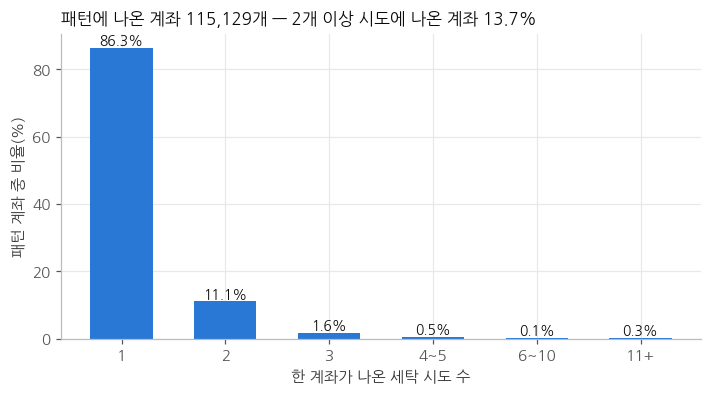

In [92]:
# 원본: build_E2.py 그림 셀 앞부분(:153-158). 바꾼 곳: 저장 이름
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(A1.index.astype(str), A1['비율_pct'], color='#2a78d6', width=0.6)
for i, v in enumerate(A1['비율_pct']): ax.text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=9, color=INK)
ax.set_xlabel('한 계좌가 나온 세탁 시도 수'); ax.set_ylabel('패턴 계좌 중 비율(%)')
ax.set_title(f'패턴에 나온 계좌 {len(acc):,}개 — 2개 이상 시도에 나온 계좌 {100*len(multi)/len(acc):.1f}%', loc='left', fontsize=11, color=INK)
savefig(fig, 'S8_1_E2_계좌별_시도수.png')

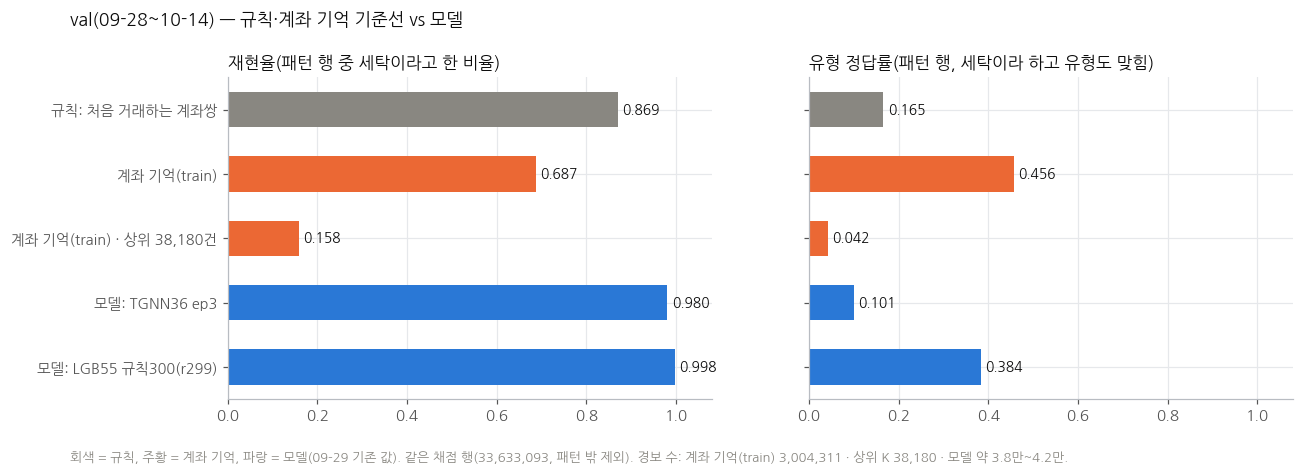

In [93]:
# build_E2.py 그림 셀 뒷부분(:160-172)을 val 로 바꿔 다시 적음(글자 그대로 옮긴 것이 아님) — 기억 사전은 train 만(val 에는 train+val 사전이 없음)

t = E2e[E2e['split'] == 'val'].set_index('기준선')
order = ['규칙: 처음 거래하는 계좌쌍', '계좌 기억(train)', '계좌 기억(train) · 상위 38,180건', '모델: TGNN36 ep3', '모델: LGB55 규칙300(r299)']
t = t.reindex(order)
fig, axs = plt.subplots(1, 2, figsize=(12.5, 3.8))
for ax, col, ttl in ((axs[0], '재현율', '재현율(패턴 행 중 세탁이라고 한 비율)'), (axs[1], '패턴행중_유형정답률', '유형 정답률(패턴 행, 세탁이라 하고 유형도 맞힘)')):
    v = t[col].to_numpy(); yy = np.arange(len(order))[::-1]
    ax.barh(yy, v, color=[C_NORM, SERIES[1], SERIES[1], SERIES[0], SERIES[0]], height=0.55)
    for yi, vi in zip(yy, v): ax.text(vi + 0.01, yi, f'{vi:.3f}', va='center', fontsize=9, color=INK)
    ax.set_yticks(yy); ax.set_yticklabels(order if ax is axs[0] else [''] * len(order), fontsize=9.5); ax.set_xlim(0, 1.08); ax.set_title(ttl, loc='left', fontsize=11, color=INK)
fig.suptitle('val(09-28~10-14) — 규칙·계좌 기억 기준선 vs 모델', x=0.01, y=1.04, ha='left', fontsize=11.5, color=INK)
fig.text(0.01, -0.04, f"회색 = 규칙, 주황 = 계좌 기억, 파랑 = 모델(09-29 기존 값). 같은 채점 행(33,633,093, 패턴 밖 제외). 경보 수: 계좌 기억(train) {int(t.loc['계좌 기억(train)', '세탁으로_예측한_행']):,} · 상위 K 38,180 · 모델 약 3.8만~4.2만.", fontsize=8.5, color=MUTED)
savefig(fig, 'S8_2_E2_계좌기억_vs_모델_val.png')

**해석**
- 패턴에 나온 계좌는 115,129개다. **13.7%(15,774)가 2개 이상 시도에 나오고**, 그중 87.7% 는 두 유형 이상에 걸친다.
- **시도 수 상위 15개 계좌(151~320개 시도)는 모두 8종에 걸친다.** 150개 이상 시도에 나온 계좌는 16개(15·16위가 151 로 같음, 17위 149)이고, 8종 모두에 쓰인 계좌는 289개다(위 셀 출력 — E2c 는 상위 15개만 저장). 생성기 흔적으로 보인다(해석).
- 시도의 92.0% 가 다른 시도와 계좌를 하나 이상 공유한다. 패턴 거래의 51.3% 에 공유 계좌가 끼어 있다. 이웃한 두 시도의 시작 간격은 중앙값 2.87일이고, 71.96% 는 앞 시도가 끝나기 전에 다음 시도가 시작된다.
- **기억 규칙을 모델과 같은 경보 수(val 38,180건)로 맞추면 정밀도 0.101 · 재현율 0.158 · 유형 정답 0.042** 다. 모델(val, 09-29 기존 값)은 재현율 0.98~1.00 이다. **모델은 계좌를 외워서 맞히는 수준이 아니다.**
- 다만 계좌 이력에는 유형 정보가 꽤 있다. 계좌 기억(train) 규칙이 **세탁이라고 한 패턴 행 중(조건부)** 유형을 맞힌 비율이 val 0.665 다(`탐지된패턴중_유형정답률` = 0.4565 / 0.6869, 위 셀). 패턴 행 전체 분모로는 0.456 이다. "최근 세탁 계좌의 유형 이력"은 유형 분류의 후보 신호다. 운영에서는 라벨이 늦게 확정된다는 문제가 있다(제안).

## 부록 A — 대체·철회된 EDA (코드 없음, 이유와 대체한 것만)

본문에는 이 항목들의 옛 수치를 쓰지 않았다. **Small 세트 EDA(8월 팀 EDA 재현, HI-Small 꼬리 등)는 사용자 지시로 이 노트북에서 뺐다.**

| 항목(날짜) | 상태 | 이유 | 대체한 것 |
|---|---|---|---|
| 08-25~09-11 파이프라인 누수 점검(옛 HI-Large "엄격 과거" 통과) | 대체됨 | 옛 파이프라인 | T4(노드 창 당일 포함, §1-4). 09-29 일 마감 결정으로 정당 |
| 09-07~10 옛 HI-Large 형태(행 60/20/20) · 꼬리 영향 | 대체됨 | 짧은 파일 · 옛 분할 | L0 · A0 · E1. 꼬리 비율 10.76%(세탁) · 17.60%(패턴)는 유효(§2-1) |
| 완결률 96.67/59.20/24.77% · 채점 가능 사건 360 → 2,901 · 19일 test 유형 검열 11.6배 | 대체됨 | 옛 19일 test | 현행 17/22일로는 다시 재지 않음 |
| 09-08 "유형별 최적 창" 표 | **철회** | 1건짜리 사건 비율을 되풀이한 값(실험타당성감사 3-1) | V1 지속시간 분포(§2-2) |
| 09-09 하루 알림 예산 0.1% | 대체됨 · 근거 없음 | 옛 분할, 0.1% 는 가정값 | 없음 |
| 09-11 cold-start 0.01~0.02% | 대체됨 | 옛 분할 | M3(§7-4) |
| 09-11 G-S 비중 이동(옛 분할) | 대체됨 | 옛 분할 | E1c 13.8 → 18.9%(§7-1) |
| 09-11 군집 축(옛 76열) | 대체됨 | 옛 피처 | us_cmp D1(54열 KL, 전처리 쪽) |
| 09-11~16 피처 성질(항등식 · VIF · 시계 AUC 0.990 · M4) | 대체됨 | 옛 41/81열 | E3(§7-3). "처음 쌍"·"워밍업" 사실은 유효 |
| 09-17 B6b 역방향 "정상 5.8%" | 대체됨 | 자기송금을 셈 | H1 · V4 0.60%(§5-4) |
| 09-17 4a · 4b · 4c(C1~C5, B9c) · G3 · G4 · H4(ACH 복원 AUC 0.83) | 대체됨 | 옛 31열 | 36피처로는 E3 만 잼 |
| 09-17~18 31열 충분성 판정 · 09-18 추가 피처 제안 A~G | 대체됨 | 36피처로 정해짐 | 데이터 근거(G · H · P)는 유효(§3~§5) |
| 09-18 전처리 결점 45건 | 잠정 | B그룹 16건 무효, 근거로 든 8월 문서가 폐기됨 | 다시 봐야 함 |
| V5 tb_amt_z 오차 · 통화 섞임 | 대체됨 | 열이 없어짐 | `amt_z_pay_ccy`(방식 다름) |
| V6 누적형 vs 30일 창 | 잠정 | 표본 · 옛 분할 | E3 |
| 09-21 40개 × 31열 대조, T6 · T7 | 대체됨 | 40개 기준 | 36개(09-28) |
| 09-22 "근접 선택이 경계 정상을 버린다" | **철회** | 09-24 검토 | us_cmp D1 KL 설명 |
| 09-27 [B] 노드 창 민감도(macro-AP 0.313 → 0.238) | **해결** | 09-29 일 마감 확정 | 노드 창 유지 |
| 09-28 "한 배치에 한 사건·한 유형" | **철회** | 이어진 패턴 행이 같은 사건인 비율 17%(D2) | D2(§7-5) |

## 부록 B — 안 한 EDA

출처: EDA 현황 §5. 09-29 에 #1 · #2 · #4 를 했다(→ E1 §7-1 · E2 §8 · E3 §7-3). #9 는 이 통합본에서 가벼운 계산으로 닫았다(§3-1). 나머지는 사용자 판단으로 멈추고 모델 작업으로 넘어갔다.

| # | 빈칸 | 왜 중요한가 | 어떻게 답하나 |
|---|---|---|---|
| 3 | 통화 보정 주간(08-01~07)의 대표성 | 36번째 피처 `amt_z_pay_ccy` 의 기준. 이력 피처가 비는 첫날이자 거래가 평소의 2.3배인 08-01 이 들어간 7일 | `currency_stats.parquet`(15행) vs A2c 분위수 |
| 5 | 거래 급증일(08-01 · 08-31 · 09-30 · 10-30 · 금요일) 구성 | "거래 많은 날 세탁 AP 하락"(fix §5-7) 원인 미확인. 일 마감 노드 창·하루 배치에 영향 | DuckDB 날짜 × 결제·통화·허브 |
| 6 | 0시 몰림과 같은 분 대량 거래(한 분 최대 653건) | 분 단위 엣지 피처·같은 분 문제([E])와 이어짐. 자정 일괄 거래일 수 있음(추정) | DuckDB 시각 × 결제 × 자기송금 |
| 7 | 정상 라벨 품질(숨은 양성) — 꼬리 정상 16,446 중 16,445 가 ACH | 있으면 9클래스 채점에서 숨은 양성이 정상으로 채점됨 | Patterns.txt 계좌 × DuckDB |
| 8 | 허브를 뺀 패턴 밖 세탁과 패턴 시도의 관계 | 병합판에서 패턴 밖이 정상 8 로 들어감. 운영에서 어느 클래스로 나올지 모름 | A4 · A4b 에 허브 제외 재집계 |
| 9 | ~~계좌 키 5개 차이(2,116,168 vs 2,116,163)~~ **해결(§3-1)** | 키 표기가 갈라진 것이 아니라 모집단 차이다. interim `nodes.parquet` 와 `account_stats.parquet` 의 key 차집합 5개(0126831_80AA5E731 · 008285_8094832F1 · 000_800338501 · 0112010_810E6B160 · 0226186_820786000)는 주 기간 거래가 없고, Patterns.txt 꼬리 거래(줄 66350 · 136745 · 141055 · 159558 · 179325, 11-07~12-10)에만 나온다 | 두 parquet 의 key 열 차집합 + 패턴 원문 검색(§3-1 셀) |
| 10 | 원본 행 순서의 구조("행의 48% 가 직전보다 과거"는 원 측정 미확인) | 배치가 edge_id 순서로 잘려 세탁이 몰림(§7-5). 순서 자체가 정보를 흘리는지 모름 | `labels_raw.npz` + DuckDB edge_id·timestamp |

**예전부터 남은 미결**
- 처음 쌍·자기 환전 짝이 생성기 습관인지 실제 행동인지는 데이터로 가를 수 없다(팀 판단).
- 특수 허브 처리 방식은 미결이다(팀 결정 대기). 패턴 밖 세탁의 이질성, W*(시도 안 같은 계좌 연속 거래 공백) 분포는 미측정이다.
- 09-10~11 EDA 후보 조사(99개 → 67개 검증, 결정가치 high 22개)는 **미완**이다. 일부만 닫혔다(EDA 현황 §2-1).
- 11-01~05(test22 의 뒤 5일) 입력은 아직 만들지 않았다. 그 5일의 모집단(옛 라벨판 / 중복 되살림판)도 미정이다(§7-2).
- 원래 측정을 찾지 못해 인용하지 않은 것: "행의 48% 가 직전보다 과거"(#10), 08-31 보고서의 "BIPARTITE 출발∩도착 0 · 최대 차수 1.0"(§2-4).
- 꼬리를 포함한 HI-Large 정식 전처리는 OOM 으로 한 번도 돌리지 못했다.
- V1~V8 수치는 옛 모집단·옛 분할 기준이다. 현행으로 다시 세지 않았다.
- 09-27 정정안 적용 여부는 팀 결정 대기다: 중복 기준(§6, 정정 보고서 §6 의 6번), 같은 분([E], §5-3), **[C] 받은 금액 열(잠정·미결 — 전처리 통합본 참고)**, 라벨 출처([G]). 이 가운데 **11-05(주 기간 끝)는 09-29 에 "최종 test 만 적용"으로, [B] 노드 창은 "일 마감"으로 결정**됐다.

## 부록 C — 정정 반영 내역 (EDA 현황 §4 의 5곳)

원 문서는 수정 금지라 여기 표로만 반영한다. **모두 결론을 뒤집지는 않는다.** 아래 셀이 맞는 값을 파일에서 다시 확인한다.

| # | 위치 | 틀린 것 | 맞는 것 |
|---|---|---|---|
| 1 | `/workspace/보고서_진행상황_손은총_20260910.md:36-50` | train · val · test 세 열 모두에서 행 이름 5개가 돌아가 있음(표의 "GATHER-SCATTER 5,743" 행은 CYCLE 등) | CYCLE 5,743 · G-S 8,186 · BIPARTITE 6,134 · STACK 10,446 · RANDOM 4,692(옛 짧은 파일 train). 최소 클래스는 STACK 이 아니라 **RANDOM** |
| 2 | 같은 보고서 :143-144 | "전체 세탁 양성의 17.6%" | 24,273/225,546 = **10.76%**(세탁 기준) · 24,273/137,936 = **17.60%**(패턴 행 기준) |
| 3 | `/workspace/0909_손은총_일지.md:224` | "26.9%(4,436건)" | **4,290(26.05%)** = 경계를 걸친 4,086 + 꼬리에서 시작한 204. 4,436 은 11-05 에 끝나 잘리지 않는 146건까지 센 값 |
| 4 | `/workspace/세션상태_손은총_20260917.md:7` | "체인 4종(CYCLE · RANDOM · STACK · S-G) ±10% 91~96%" | S-G 는 **52.83%**. 91~96% 는 CYCLE · RANDOM · STACK 셋만. S-G 도 ±20% 면 89.97% |
| 5 | us_cmp D3 요약 · 조사 문구 | "주말 약 83만 행"(규칙처럼) | 10-30(일) 3,243,922 · 월초·월말 급증 08-01 4,466,821 · 08-31 4,290,962 · 09-30 5,379,623 |

In [94]:
# 정정 1 — 옛 짧은 파일의 분할 표(09-11)에서 문서의 이름·값이 실제로 어느 유형인가
old = rd('/workspace/eda_split_label_table_HI-Large_20260911.csv').set_index('split')
tr = old.loc['tr', CLASS_NAMES].astype(int)
for name, v in {'GATHER-SCATTER': 5743, 'CYCLE': 8186, 'RANDOM': 6134, 'BIPARTITE': 10446, 'STACK': 4692}.items():
    print(f'  문서 "{name} {v:,}" → 실제 유형 {tr[tr == v].index.tolist()}')
print(f'  train 최소 클래스: {tr.idxmin()} {tr.min():,}')
# 정정 2
L0 = json.loads((RES / 'L0_labels.json').read_text()); L0s = pd.read_csv(RES / 'L0_labels_summary.csv').set_index('group')
tail = int(L0s.loc['패턴 세탁', '꼬리(제외)'])
print(f"정정 2: {tail:,}/{L0['laundering_rows']:,} = {100 * tail / L0['laundering_rows']:.2f}% · {tail:,}/{L0['pattern_rows']:,} = {100 * tail / L0['pattern_rows']:.2f}%")
# 정정 3
a2b = pd.read_csv(FRES / 'A2b_사건_기간_통계.csv', encoding='utf-8-sig').iloc[0]
v1 = pd.read_csv(RES / 'V1_사건지속시간_요약.csv'); tt = v1[v1.항목 == '꼬리에 거래가 걸친 시도'].iloc[0]
print(f"정정 3: 꼬리에 걸친 시도 {int(tt.분자):,}/{int(tt.분모):,} = {tt.비율_pct:.2f}% = 주기간에 시작해 꼬리에서 끝남 {int(a2b['주기간에_시작해_꼬리에서_끝난_사건']):,} + 꼬리에서 시작 {int(a2b['꼬리에서_시작한_사건']):,}")
assert int(tt.분자) == int(a2b['주기간에_시작해_꼬리에서_끝난_사건']) + int(a2b['꼬리에서_시작한_사건'])
# 정정 4
p1 = pd.read_csv(RES / 'P1_패턴원문_연속홉_전달.csv').set_index('유형')
print('정정 4: ±10% 안(비율0_9_1_1)', p1['비율0_9_1_1'].round(2).to_dict(), '· S-G ±20%', round(p1.loc['SCATTER-GATHER', '비율0_8_1_2'], 2))
# 정정 5
a0 = pd.read_csv(FRES / 'A0_일별_행수_세탁_165일.csv', encoding='utf-8-sig'); a0['day'] = pd.to_datetime(a0['day'])
for d_ in ('2022-08-01', '2022-08-31', '2022-09-30', '2022-10-30'):
    r_ = a0[a0.day == d_].iloc[0]; print(f"정정 5: {d_}({'월화수목금토일'[r_['day'].weekday()]}) {int(r_['rows']):,}행")

읽음: /workspace/eda_split_label_table_HI-Large_20260911.csv  (394 B · 3행)
  문서 "GATHER-SCATTER 5,743" → 실제 유형 ['CYCLE']
  문서 "CYCLE 8,186" → 실제 유형 ['GATHER-SCATTER']
  문서 "RANDOM 6,134" → 실제 유형 ['BIPARTITE']
  문서 "BIPARTITE 10,446" → 실제 유형 ['STACK']
  문서 "STACK 4,692" → 실제 유형 ['RANDOM']
  train 최소 클래스: RANDOM 4,692
정정 2: 24,273/225,546 = 10.76% · 24,273/137,936 = 17.60%
정정 3: 꼬리에 걸친 시도 4,290/16,467 = 26.05% = 주기간에 시작해 꼬리에서 끝남 4,086 + 꼬리에서 시작 204
정정 4: ±10% 안(비율0_9_1_1) {'CYCLE': 91.72, 'GATHER-SCATTER': 8.38, 'RANDOM': 91.34, 'SCATTER-GATHER': 52.83, 'STACK': 95.91} · S-G ±20% 89.97
정정 5: 2022-08-01(월) 4,466,821행
정정 5: 2022-08-31(수) 4,290,962행
정정 5: 2022-09-30(금) 5,379,623행
정정 5: 2022-10-30(일) 3,243,922행


### C-2. 이 통합본에서 새로 확인한 정정 (원 문서는 수정 금지 — 여기에만 적는다)

| # | 위치 | 틀린 것 | 맞는 것(근거) |
|---|---|---|---|
| 6 | EDA 현황 §1-4 · §1-8 · §5 #9 | "원문 키 2,116,168 vs bank0 키 2,116,163, 5개 차이 원인 미확인"("'011'/'0011' 로 갈라짐" 추정) | 키 종류가 아니라 **모집단** 차이. 2,116,163 = 주 기간 옛 모집단 활동 계좌(원문 키), 2,116,168 = 165일 전체. 5개는 꼬리에만 나오는 계좌(§3-1 셀) |
| 7 | EDA 현황 §3 의 1번 | "꼬리 68일(패턴 완결 거래만)" | 꼬리 40,719행 = 세탁 24,273(59.6%, 모두 패턴) + **정상 16,446**(거의 다 ACH). 세탁 중 868 은 꼬리에서 시작한 시도 204개의 거래(§1-2) |
| 8 | EDA 현황 §1-8 "처음 쌍(정상) 3.96%(09-15 M2)" | 정상 행 중 비율로 인용 | 3.96% 는 **전체 행**(정상+세탁) 중 비율이다. 정상 행 중으로는 3.90%, 패턴 87.95%(분모: 옛 짧은 파일 train − 08-01 = 103,327,281행, §5-2) |
| 9 | `추가EDA_E1-E3_결과_손은총_20260929.md:26` | "150~320개 시도·8종 모두에 쓰인 계좌 15개(E2c)" | E2c 는 상위 15개만 저장한 표다. 150개 이상 시도 계좌 16개, 8종 모두 289개, 상위 15개는 151~320개 시도(§8-1 셀) |
| 10 | `추가EDA_E1-E3_결과_손은총_20260929.md:19` | "주말 … 10만 건당 160~180" | 09-10 이후 주말(10-30 제외)만 약 156~181. train 앞 4주 주말 74~153, 10-30(일) 43(§7-1 셀) |

## 부록 D — 실행 기록
이 노트북이 쓴 파일(`out/` · `_figs/`)과 실행 시간·메모리.

**옮기지 않은 원래 계산과 그 이유**(나머지 원래 계산은 모두 무거운 셀로 옮겼다 — 설정 셀의 `HEAVY` 목록)

| 원래 코드 | 만든 결과 | 옮기지 않은 이유 |
|---|---|---|
| `HI-Large_EDA/extract_missing_rows.py` | 짧은 파일에 빠진 10,702행 | 비교 대상인 짧은 원본 파일을 09-17 에 지웠다 |
| `notebooks/08_31열_공백후보_검증.ipynb` cell 2 이후 | G1 · G2 · G3 · G4 · G5 · G6 · `_work/g08_targets_packed.npz` | cell 2 가 읽는 31열 행렬 폴더(`/tmp/claude-0/-workspace/a4a2120f-…/scratchpad/eda_cols`)가 지워졌다. 뒤 셀은 cell 2 의 변수에 기댄다. (G1~G4 를 모은 H1 표 조립은 §5-4 에서 다시 돌렸다) |
| `notebooks/13_V4_역방향이력_재검증.ipynb` | V4 | cell 1 · 3 이 같은 지워진 폴더의 `cols31.json` 을 읽는다 |
| `notebooks/20_태훈님코드_전체계산.ipynb` | T5f · 결합 파일 | `tree9_lib`(`/tmp/tree9_work/code`)를 import 하고 DuckDB 를 새로 짓는다(지금 재구축 중) |
| `fix_20260927/code/fix_02_labels.py` | D1 · D2 · G1~G3(fix) | `/tmp/tree9_work` 의 DuckDB·라벨을 읽고 `/tmp/fix_work` 에 큰 라벨 배열을 쓴다 |

In [95]:
assert OUT == NB_DIR / 'out' and FIG == NB_DIR / '_figs'
for d_ in (OUT, FIG):
    fs = sorted(p for p in d_.rglob('*') if p.is_file())
    print(f'■ {d_} — {len(fs)}개 · {sum(p.stat().st_size for p in fs) / 2**20:.1f} MB')
    for p in fs:
        print(f'   {p.relative_to(d_)}  {p.stat().st_size:,} B')
import resource
print(f'실행 {time.time() - T0:.0f}초 · 이 커널 최대 RSS {resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 2**10:.0f} MB · 컨테이너 anon {anon_gib():.2f} GiB')
print('무거운 셀 켜짐:', [k for k, v in HEAVY.items() if v] or '없음')

■ /workspace/Final_preprocess/통합본_20260930/EDA_HI-Large/out — 12개 · 0.5 MB
   E2a_계좌별_시도수_분포.csv  196 B
   E2b_유형별_계좌공유.csv  561 B
   E2c_시도수_상위계좌.csv  381 B
   E2d_계좌공유_요약.json  269 B
   H1_후보_종합표.csv  2,301 B
   P1_패턴원문_연속홉_전달.csv  1,245 B
   P2_패턴원문_계좌_통과비율.csv  750 B
   P3_패턴원문_체인내_통화전환.csv  200 B
   m9_attempt_speed.csv  510,955 B
   m9_window_fit.csv  855 B
   merged_prior.csv  426 B
   test22_prior.csv  1,461 B
■ /workspace/Final_preprocess/통합본_20260930/EDA_HI-Large/_figs — 30개 · 1.8 MB
   S1_1_165일_행수_세탁비율.png  83,291 B
   S1_2_주기간_끝_F1.png  51,677 B
   S1_3_요일별_하루거래.png  38,578 B
   S1_4_주별_세탁비율.png  56,063 B
   S2_1_유형별_주기간_꼬리.png  70,729 B
   S2_2_유형별_지속시간.png  91,240 B
   S2_3_창길이_m9.png  58,812 B
   S3_1_계좌순위_허브절벽.png  56,176 B
   S3_2_다통화계좌.png  46,528 B
   S3_3_소유주유형_G6.png  39,238 B
   S4_1_결제방식_구성.png  43,641 B
   S4_2_통화별_세탁비율.png  62,801 B
   S4_3_로그금액_분포.png  55,624 B
   S4_4_시각분포.png  55,406 B
   S4_5_처음통화_H2.png  51,337 B
   S5_1_넘기는속도_B5.png  50,802 B
   S5_2_처음쌍